# 📊 Project FORESIGHT

## AI-Powered Demand & Inventory Intelligence Platform

### Notebook 02: Exploratory Data Analysis

---

## 📌 Project Information

| Item | Details |
|---|---|
| **Author** | Mohit Kumar |
| **Internship** | Zidio Development |
| **Project Type** | End-to-End Data Analytics & Machine Learning Project |
| **Notebook Version** | 1.0 |
| **Status** | Completed |
| **Last Updated** | August 2026 |

<style>
@media print {

    /* Make dataframe tables fit printable page width */
    table.dataframe {
        width: 100% !important;
        max-width: 100% !important;
        font-size: 8pt !important;
        table-layout: auto !important;
    }

    /* Allow long table text to wrap */
    table.dataframe th,
    table.dataframe td {
        white-space: normal !important;
        overflow-wrap: anywhere !important;
        word-break: normal !important;
        padding: 3px 4px !important;
    }

    /* Prevent notebook output containers from clipping tables */
    div.output_area,
    div.output_subarea,
    div.output,
    div.jp-OutputArea-output {
        max-width: 100% !important;
        overflow: visible !important;
    }

    /* Prevent horizontal scrollbars from appearing in PDF */
    ::-webkit-scrollbar {
        display: none !important;
    }
}
</style>

---

# 🎯 1. Business Context and Notebook Objective

Retail demand changes across time, products, stores, prices, events, and seasonal periods. Without understanding these patterns, forecasting models and inventory recommendations may produce unreliable or misleading results.

Notebook 02 analyses the validated datasets created in Notebook 01 to identify the main demand, sales, pricing, product, store, calendar, and simulated inventory patterns within the 300 SKU-store development scope.

## Objectives

This notebook will:

- validate and integrate the processed project datasets;
- summarise the project’s main sales and inventory KPIs;
- analyse demand trends and seasonality;
- compare category, department, store, state, product, and SKU performance;
- identify top movers, slow movers, and dead-stock candidates;
- examine price, event, SNAP, and simulated inventory relationships;
- translate analytical findings into clear business insights and recommendations;
- export validated tables and figures for reporting and downstream project stages.

> **Important:** Inventory values used in this notebook are simulated and must be interpreted as analytical estimates rather than observed retailer stock records.

---

# 🧭 2. Notebook Workflow and Business Questions

Notebook 02 follows a focused exploratory workflow designed to understand historical demand, identify business risks and opportunities, and prepare reliable analytical outputs for feature engineering and forecasting.

## 2.1 Notebook Workflow

| Section | Focus |
|---|---|
| 3 | Notebook Setup |
| 4 | Load Processed Data and Confirm Input Integrity |
| 5 | Build the Integrated EDA Dataset |
| 6 | Executive KPI Overview |
| 7 | Demand Trends and Seasonality |
| 8 | Business Performance Analysis |
| 9 | Top Movers, Slow Movers, and Dead-Stock Candidates |
| 10 | Demand Drivers |
| 11 | Inventory and Demand Behaviour |
| 12 | Business Insights, Recommendations, and EDA Insight Memo |
| 13 | Export and Final Validation |
| 14 | Notebook Conclusion |

## 2.2 Core Business Questions

This notebook will answer:

1. How has demand changed over time?
2. When does demand usually increase or decrease?
3. Which categories, departments, stores, states, products, and SKUs perform best?
4. Which products are fast-moving, slow-moving, or possible dead-stock candidates?
5. How are price, events, promotions, and SNAP periods associated with demand?
6. Which products show stable, volatile, or intermittent demand?
7. Where does simulated inventory appear insufficient or excessive?
8. Which findings should influence forecasting and inventory planning?

## 2.3 Analytical Principles

- Use only the validated 300 SKU-store development scope.
- Avoid repeating the detailed engineering checks completed in Notebook 01.
- Create charts only when they answer a defined business question.
- Separate observed M5 data from simulated inventory information.
- Interpret relationships as associations unless causal evidence exists.
- Convert analytical findings into concise business insights and recommendations.

> **Scope boundary:** This notebook performs exploratory analysis only. Forecast features, model training, final risk scoring, and reorder calculations belong to later notebooks.

---

# ⚙️ 3. Notebook Setup

This section prepares a consistent and reproducible environment for exploratory analysis. It defines notebook settings, imports the required libraries, and establishes reusable project paths.

## Objectives

- configure the notebook environment;
- import libraries for data manipulation and visualisation;
- define processed-data and output directories;
- prepare consistent display and chart settings;
- confirm that the environment is ready for analysis.

---






## 3.1 Notebook Configuration

Non-critical warnings and notebook-wide display settings will be configured to keep outputs readable while preserving important validation messages.


In [1]:
import warnings

# Suppress non-critical warning messages.
warnings.filterwarnings("ignore")

print("✅ Section 3.1 completed: Notebook configuration applied.")

✅ Section 3.1 completed: Notebook configuration applied.


## 3.2 Import Required Libraries

The required libraries will support:

- file and directory management;
- data manipulation;
- numerical analysis;
- statistical summaries;
- data visualisation;
- enhanced notebook display.


In [2]:
# Standard Library

from pathlib import Path


# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualisation

import matplotlib.pyplot as plt
import seaborn as sns

# Notebook Utilities

from IPython.display import display

# ============================================================
# Display and Visualisation Configuration
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print("✅ Section 3.2 completed: Required libraries imported successfully.")

✅ Section 3.2 completed: Required libraries imported successfully.


### 📝 Library Summary

The required Python libraries were successfully imported and configured for Notebook 02. Each library supports a specific part of the exploratory data analysis workflow.

| Library | Purpose |
|----------|---------|
| **pandas** | Data loading, manipulation, aggregation, and analysis |
| **NumPy** | Numerical calculations and statistical operations |
| **Matplotlib** | Creation of analytical charts and figures |
| **Seaborn** | Statistical visualisation and consistent chart styling |
| **Pathlib** | Project directory and file-path management |
| **IPython.display** | Enhanced display of tables and notebook outputs |

The notebook environment is now prepared for data loading, exploratory analysis, visualisation, and output generation.

---
## 3.3 Project Directories and File Paths

Reusable paths will be defined for:

- processed input datasets;
- interim analytical datasets;
- exported summary tables;
- analytical figures;
- executive reports;
- notebook exports.

Using centralised paths avoids machine-specific file references and supports reproducibility.

In [3]:
# Identify the Project FORESIGHT root directory.
CURRENT_DIRECTORY = Path.cwd()

if CURRENT_DIRECTORY.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

# Data Directories

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"

# Report Directories

REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
EXECUTIVE_REPORT_DIR = REPORTS_DIR / "executive_report"
NOTEBOOK_EXPORT_DIR = REPORTS_DIR / "notebook_exports"


# Processed Input Files

SALES_FILE = PROCESSED_DATA_DIR / "sales_daily_final.csv"
CALENDAR_FILE = PROCESSED_DATA_DIR / "calendar_final.csv"
SKU_MASTER_FILE = PROCESSED_DATA_DIR / "sku_master_final.csv"
INVENTORY_FILE = PROCESSED_DATA_DIR / "inventory_snapshots_final.csv"
DEVELOPMENT_SCOPE_FILE = (
    PROCESSED_DATA_DIR / "development_sku_scope.csv"
)


# Main Notebook 02 Output

ANALYTICS_BASE_FILE = (
    INTERIM_DATA_DIR / "analytics_base_daily.parquet"
)


print("✅ Section 3.3 completed: Project paths configured successfully.")
print(f"Project root       : {PROJECT_ROOT}")
print(f"Processed data     : {PROCESSED_DATA_DIR}")
print(f"Interim data       : {INTERIM_DATA_DIR}")
print(f"Reports directory  : {REPORTS_DIR}")

✅ Section 3.3 completed: Project paths configured successfully.
Project root       : C:\Users\hp\Project FORESIGHT
Processed data     : C:\Users\hp\Project FORESIGHT\data\processed
Interim data       : C:\Users\hp\Project FORESIGHT\data\interim
Reports directory  : C:\Users\hp\Project FORESIGHT\reports


### 📝 Directory Configuration Summary

The Project FORESIGHT root directory was identified correctly as:

`C:\Users\hp\Project FORESIGHT`

The processed-data, interim-data, and reporting paths point to the expected project folders. Centralising these paths ensures that Notebook 02 can load inputs and export outputs without using repeated or machine-specific file references.

✅ Project directories and file paths are configured correctly.

---
## 3.4 Output Directory Preparation

Required output directories will be created through code where necessary.

This ensures that later exports do not fail because a destination folder is missing.

In [4]:
output_directories = {
    "Interim Data": INTERIM_DATA_DIR,
    "Summary Tables": TABLES_DIR,
    "Analytical Figures": FIGURES_DIR,
    "Executive Reports": EXECUTIVE_REPORT_DIR,
    "Notebook Exports": NOTEBOOK_EXPORT_DIR,
}

# Create required directories.
for directory_path in output_directories.values():
    directory_path.mkdir(parents=True, exist_ok=True)

# Prepare confirmation summary.
directory_summary = pd.DataFrame(
    [
        {
            "Directory": directory_name,
            "Path": str(directory_path),
            "Exists": directory_path.exists(),
        }
        for directory_name, directory_path in output_directories.items()
    ]
)

display(directory_summary)

assert directory_summary["Exists"].all(), (
    "One or more required output directories could not be created."
)

print("✅ Section 3.4 completed: Output directories are ready.")

,Directory,Path,Exists
0,Interim Data,C:\Users\hp\Project FORESIGHT\data\interim,True
1,Summary Tables,C:\Users\hp\Project FORESIGHT\reports\tables,True
2,Analytical Figures,C:\Users\hp\Project FORESIGHT\reports\figures,True
3,Executive Reports,C:\Users\hp\Project FORESIGHT\reports\executiv...,True
4,Notebook Exports,C:\Users\hp\Project FORESIGHT\reports\notebook...,True


✅ Section 3.4 completed: Output directories are ready.


### ✅ Notebook Setup Summary

Notebook 02 is now configured for reproducible exploratory analysis.

The following setup tasks were completed:

- non-critical warnings were suppressed;
- required analytical and visualisation libraries were imported;
- centralised project paths were defined;
- processed-data and output locations were configured;
- all required output directories were confirmed successfully.

The notebook environment is ready to load the validated datasets produced by Notebook 01.

✅ Section 3 is complete.

---

# 📂 4. Load Processed Data and Confirm Input Integrity

This section loads the validated datasets produced by Notebook 01 and performs a small set of handoff checks before exploratory analysis begins.

The detailed data-quality and engineering validation has already been completed in Notebook 01. Therefore, only checks required to protect the Notebook 02 workflow will be performed here.

## Input Datasets

- `sales_daily_final.csv`
- `calendar_final.csv`
- `sku_master_final.csv`
- `inventory_snapshots_final.csv`
- `development_sku_scope.csv`

## Objectives

- confirm that all required files are available;
- load the processed datasets;
- verify expected key columns;
- confirm the 300 SKU-store development scope;
- review dataset dimensions and date coverage;
- confirm readiness for analytical integration.

---






## 4.1 Confirm Required Input Files

The notebook will verify that each required processed file exists and is not empty before loading it.



In [5]:

required_input_files = {
    "Sales Daily": SALES_FILE,
    "Calendar": CALENDAR_FILE,
    "SKU Master": SKU_MASTER_FILE,
    "Inventory Snapshots": INVENTORY_FILE,
    "Development Scope": DEVELOPMENT_SCOPE_FILE,
}

input_file_summary = pd.DataFrame(
    [
        {
            "Dataset": dataset_name,
            "Filename": file_path.name,
            "Exists": file_path.exists(),
            "Size (MB)": (
                round(file_path.stat().st_size / (1024 ** 2), 2)
                if file_path.exists()
                else 0
            ),
            "Path": str(file_path),
        }
        for dataset_name, file_path in required_input_files.items()
    ]
)

display(input_file_summary)

missing_or_empty_files = input_file_summary[
    (~input_file_summary["Exists"])
    | (input_file_summary["Size (MB)"] <= 0)
]

assert missing_or_empty_files.empty, (
    "One or more required input files are missing or empty:\n"
    + missing_or_empty_files.to_string(index=False)
)

print("✅ Section 4.1 completed: All required input files are available.")

,Dataset,Filename,Exists,Size (MB),Path
0,Sales Daily,sales_daily_final.csv,True,24.41,C:\Users\hp\Project FORESIGHT\data\processed\s...
1,Calendar,calendar_final.csv,True,0.15,C:\Users\hp\Project FORESIGHT\data\processed\c...
2,SKU Master,sku_master_final.csv,True,3.66,C:\Users\hp\Project FORESIGHT\data\processed\s...
3,Inventory Snapshots,inventory_snapshots_final.csv,True,42.30,C:\Users\hp\Project FORESIGHT\data\processed\i...
4,Development Scope,development_sku_scope.csv,True,0.01,C:\Users\hp\Project FORESIGHT\data\processed\d...


✅ Section 4.1 completed: All required input files are available.


### 📝 Input File Summary

All five required Notebook 02 input files were found successfully in the processed-data directory.

| Dataset | File Size |
|---|---:|
| Sales Daily | 24.41 MB |
| Calendar | 0.15 MB |
| SKU Master | 3.66 MB |
| Inventory Snapshots | 42.30 MB |
| Development Scope | 0.01 MB |

The files are available and non-empty, so the notebook can proceed to load the validated datasets.

✅ Required input-file handoff check passed.

---
## 4.2 Load Processed Datasets

The validated datasets will be loaded into Pandas DataFrames without repeating the cleaning and engineering steps completed in Notebook 01.

---


In [6]:
# Load validated Notebook 01 outputs.
sales_daily_final = pd.read_csv(
    SALES_FILE,
    parse_dates=["date"],
)

calendar_final = pd.read_csv(
    CALENDAR_FILE,
    parse_dates=["date"],
)

sku_master_final = pd.read_csv(
    SKU_MASTER_FILE,
)

inventory_snapshots_final = pd.read_csv(
    INVENTORY_FILE,
    parse_dates=["date"],
)

development_scope = pd.read_csv(
    DEVELOPMENT_SCOPE_FILE,
)


# Prepare loading summary.
loaded_datasets = {
    "Sales Daily": sales_daily_final,
    "Calendar": calendar_final,
    "SKU Master": sku_master_final,
    "Inventory Snapshots": inventory_snapshots_final,
    "Development Scope": development_scope,
}

loading_summary = pd.DataFrame(
    [
        {
            "Dataset": dataset_name,
            "Rows": dataframe.shape[0],
            "Columns": dataframe.shape[1],
            "Memory (MB)": round(
                dataframe.memory_usage(deep=True).sum()
                / (1024 ** 2),
                2,
            ),
        }
        for dataset_name, dataframe in loaded_datasets.items()
    ]
)

display(loading_summary)

assert all(
    not dataframe.empty
    for dataframe in loaded_datasets.values()
), "One or more processed datasets loaded as empty."

print("✅ Section 4.2 completed: All processed datasets loaded successfully.")

,Dataset,Rows,Columns,Memory (MB)
0,Sales Daily,573900,6,36.12
1,Calendar,1969,22,0.38
2,SKU Master,30490,16,6.29
3,Inventory Snapshots,573900,17,88.69
4,Development Scope,300,1,0.01


✅ Section 4.2 completed: All processed datasets loaded successfully.


### 📝 Dataset Loading Summary

The four core business datasets and one internal scope-control file were loaded successfully.

| File Type | Dataset | Rows | Columns |
|---|---|---:|---:|
| Core Dataset | Sales Daily | 573,900 | 6 |
| Core Dataset | Calendar | 1,969 | 22 |
| Core Dataset | SKU Master | 30,490 | 16 |
| Core Dataset | Inventory Snapshots | 573,900 | 17 |
| Control File | Development Scope | 300 | 1 |

The four core datasets match the structure required for Project FORESIGHT. The development-scope file is used only to keep all notebooks restricted to the same approved 300 SKU-store series.

The `date` columns in the sales, calendar, and inventory datasets were loaded as datetime values, and no file loaded as empty.

✅ Core datasets and scope control are ready for the analytical-input integrity check.

## 4.3 Confirm Analytical Inputs

A concise integrity check will confirm:

- expected dataset dimensions;
- required date and identifier columns;
- 300 unique development-scope SKUs;
- available historical date range;
- readiness for integration.

> **Note:** This is an input handoff check, not a repetition of the complete Notebook 01 validation process.

In [7]:
# Prepare analytical-input integrity requirements

required_columns = {
    "Sales Daily": {
        "dataframe": sales_daily_final,
        "columns": ["date", "sku_id"],
    },
    "Calendar": {
        "dataframe": calendar_final,
        "columns": ["date"],
    },
    "SKU Master": {
        "dataframe": sku_master_final,
        "columns": ["sku_id"],
    },
    "Inventory Snapshots": {
        "dataframe": inventory_snapshots_final,
        "columns": ["date", "sku_id"],
    },
    "Development Scope": {
        "dataframe": development_scope,
        "columns": ["sku_id"],
    },
}


def make_integrity_record(check_name, condition, details):
    """Create one analytical-input integrity result."""
    return {
        "Check": check_name,
        "Status": "Passed" if condition else "Failed",
        "Details": details,
    }


print("Analytical-input integrity framework prepared.")
print(f"Datasets registered : {len(required_columns)}")

Analytical-input integrity framework prepared.
Datasets registered : 5


In [8]:
# Validate required columns and development-scope coverage

structural_checks = []

for dataset_name, dataset_info in required_columns.items():
    dataframe = dataset_info["dataframe"]
    expected_columns = dataset_info["columns"]

    missing_columns = [
        column
        for column in expected_columns
        if column not in dataframe.columns
    ]

    structural_checks.append(
        make_integrity_record(
            f"{dataset_name}: required columns",
            len(missing_columns) == 0,
            (
                "All required columns found"
                if not missing_columns
                else f"Missing: {missing_columns}"
            ),
        )
    )


scope_non_null = development_scope["sku_id"].notna().all()
scope_unique_count = development_scope["sku_id"].nunique()
scope_duplicate_count = development_scope["sku_id"].duplicated().sum()

structural_checks.append(
    make_integrity_record(
        "Development scope contains 300 unique SKU IDs",
        (
            len(development_scope) == 300
            and scope_unique_count == 300
            and scope_duplicate_count == 0
            and scope_non_null
        ),
        (
            f"Rows: {len(development_scope):,}; "
            f"Unique SKU IDs: {scope_unique_count:,}; "
            f"Duplicates: {scope_duplicate_count:,}"
        ),
    )
)


scope_sku_ids = set(development_scope["sku_id"])

coverage_checks = {
    "Sales Daily": scope_sku_ids.issubset(
        set(sales_daily_final["sku_id"])
    ),
    "SKU Master": scope_sku_ids.issubset(
        set(sku_master_final["sku_id"])
    ),
    "Inventory Snapshots": scope_sku_ids.issubset(
        set(inventory_snapshots_final["sku_id"])
    ),
}

for dataset_name, coverage_passed in coverage_checks.items():
    structural_checks.append(
        make_integrity_record(
            f"{dataset_name}: development-scope coverage",
            coverage_passed,
            "All 300 scope SKU IDs found",
        )
    )


print("Structural integrity checks prepared.")
print(f"Checks recorded : {len(structural_checks)}")

Structural integrity checks prepared.
Checks recorded : 9


In [9]:
# Validate dates, analytical keys and historical coverage

temporal_key_checks = []

date_columns = {
    "Sales": sales_daily_final["date"],
    "Calendar": calendar_final["date"],
    "Inventory": inventory_snapshots_final["date"],
}

for dataset_name, date_series in date_columns.items():
    temporal_key_checks.append(
        make_integrity_record(
            f"{dataset_name} date column is datetime",
            pd.api.types.is_datetime64_any_dtype(date_series),
            str(date_series.dtype),
        )
    )


sales_duplicate_keys = sales_daily_final.duplicated(
    subset=["sku_id", "date"]
).sum()

inventory_duplicate_keys = inventory_snapshots_final.duplicated(
    subset=["sku_id", "date"]
).sum()

temporal_key_checks.extend(
    [
        make_integrity_record(
            "Sales analytical key is unique",
            sales_duplicate_keys == 0,
            f"Duplicate sku_id-date keys: {sales_duplicate_keys:,}",
        ),
        make_integrity_record(
            "Inventory analytical key is unique",
            inventory_duplicate_keys == 0,
            f"Duplicate sku_id-date keys: {inventory_duplicate_keys:,}",
        ),
    ]
)


sales_start_date = sales_daily_final["date"].min()
sales_end_date = sales_daily_final["date"].max()
sales_date_count = sales_daily_final["date"].nunique()

temporal_key_checks.append(
    make_integrity_record(
        "Sales historical coverage is available",
        (
            pd.notna(sales_start_date)
            and pd.notna(sales_end_date)
            and sales_date_count > 0
        ),
        (
            f"{sales_start_date.date()} to "
            f"{sales_end_date.date()} "
            f"({sales_date_count:,} unique dates)"
        ),
    )
)


integrity_records = structural_checks + temporal_key_checks
analytical_input_check = pd.DataFrame(integrity_records)

display(analytical_input_check)

failed_checks = analytical_input_check[
    analytical_input_check["Status"] == "Failed"
].copy()

print("\nANALYTICAL INPUT INTEGRITY SUMMARY")
print("=" * 60)
print(f"Total checks : {len(analytical_input_check)}")
print(
    "Passed       : "
    f"{analytical_input_check['Status'].eq('Passed').sum()}"
)
print(f"Failed       : {len(failed_checks)}")

assert failed_checks.empty, (
    "Analytical-input integrity check failed:\n"
    + failed_checks.to_string(index=False)
)

print("\n✅ Section 4.3 completed: Analytical inputs confirmed.")
print("✅ Four core datasets and the scope-control file are ready.")

,Check,Status,Details
0,Sales Daily: required columns,Passed,All required columns found
1,Calendar: required columns,Passed,All required columns found
2,SKU Master: required columns,Passed,All required columns found
3,Inventory Snapshots: required columns,Passed,All required columns found
4,Development Scope: required columns,Passed,All required columns found
5,Development scope contains 300 unique SKU IDs,Passed,Rows: 300; Unique SKU IDs: 300; Duplicates: 0
6,Sales Daily: development-scope coverage,Passed,All 300 scope SKU IDs found
7,SKU Master: development-scope coverage,Passed,All 300 scope SKU IDs found
8,Inventory Snapshots: development-scope coverage,Passed,All 300 scope SKU IDs found
9,Sales date column is datetime,Passed,datetime64[us]



ANALYTICAL INPUT INTEGRITY SUMMARY
Total checks : 15
Passed       : 15
Failed       : 0

✅ Section 4.3 completed: Analytical inputs confirmed.
✅ Four core datasets and the scope-control file are ready.


### ✅ Analytical Input Integrity Summary

All analytical-input integrity checks passed successfully.

The validation confirmed that:

- all required key columns are available;
- the development-scope file contains 300 unique and non-null SKU-store identifiers;
- all 300 scope identifiers are present in the Sales Daily, SKU Master, and Inventory Snapshot datasets;
- the sales, calendar, and inventory date fields use valid datetime types;
- the `sku_id + date` key is unique in the sales and inventory datasets;
- historical sales coverage is available for exploratory analysis.

The four core business datasets and one internal scope-control file are ready for integration.

✅ Section 4 is complete.

---

# 🔗 5. Build the Integrated EDA Dataset

This section combines the processed project datasets into one analysis-ready table for exploratory analysis.

The integrated dataset will retain a clear daily SKU-store grain while adding calendar, product, pricing, and simulated inventory information.

## Objectives

- define the analytical grain;
- restrict the analysis to the approved 300 SKU-store scope;
- integrate sales, calendar, SKU, and inventory attributes;
- prevent duplicate or multiplied records during merging;
- confirm row-count and key consistency;
- prepare a reusable analytical dataset for the remaining EDA sections.

---

## 5.1 Define the Analytical Grain

The integrated EDA dataset will contain one row per SKU-store-date.

The expected composite key is:

`sku_id + date`


In [10]:
# Define the analytical grain and expected panel size

ANALYTICAL_KEY = ["sku_id", "date"]

scope_sku_count = development_scope["sku_id"].nunique()
historical_date_count = sales_daily_final["date"].nunique()

expected_daily_rows = (
    scope_sku_count * historical_date_count
)

print("Analytical grain defined successfully.")
print("Composite key     : sku_id + date")
print(f"SKU-store series : {scope_sku_count:,}")
print(f"Historical dates : {historical_date_count:,}")

Analytical grain defined successfully.
Composite key     : sku_id + date
SKU-store series : 300
Historical dates : 1,913


In [11]:
# Create the dataset-grain summary

grain_summary = pd.DataFrame(
    [
        {
            "Dataset": "Sales Daily",
            "Grain": "One row per SKU-store-date",
            "Rows": len(sales_daily_final),
            "Unique SKU IDs": (
                sales_daily_final["sku_id"].nunique()
            ),
            "Unique Dates": (
                sales_daily_final["date"].nunique()
            ),
            "Duplicate Keys": (
                sales_daily_final
                .duplicated(subset=ANALYTICAL_KEY)
                .sum()
            ),
        },
        {
            "Dataset": "Inventory Snapshots",
            "Grain": "One row per SKU-store-date",
            "Rows": len(inventory_snapshots_final),
            "Unique SKU IDs": (
                inventory_snapshots_final["sku_id"].nunique()
            ),
            "Unique Dates": (
                inventory_snapshots_final["date"].nunique()
            ),
            "Duplicate Keys": (
                inventory_snapshots_final
                .duplicated(subset=ANALYTICAL_KEY)
                .sum()
            ),
        },
        {
            "Dataset": "SKU Master",
            "Grain": "One row per SKU-store",
            "Rows": len(sku_master_final),
            "Unique SKU IDs": (
                sku_master_final["sku_id"].nunique()
            ),
            "Unique Dates": "Not applicable",
            "Duplicate Keys": (
                sku_master_final["sku_id"].duplicated().sum()
            ),
        },
        {
            "Dataset": "Calendar",
            "Grain": "One row per date",
            "Rows": len(calendar_final),
            "Unique SKU IDs": "Not applicable",
            "Unique Dates": calendar_final["date"].nunique(),
            "Duplicate Keys": (
                calendar_final["date"].duplicated().sum()
            ),
        },
    ]
)

display(grain_summary)

,Dataset,Grain,Rows,Unique SKU IDs,Unique Dates,Duplicate Keys
0,Sales Daily,One row per SKU-store-date,573900,300,1913,0
1,Inventory Snapshots,One row per SKU-store-date,573900,300,1913,0
2,SKU Master,One row per SKU-store,30490,30490,Not applicable,0
3,Calendar,One row per date,1969,Not applicable,1969,0


In [12]:
# Validate the analytical grain and complete daily panel

sales_duplicate_keys = (
    sales_daily_final
    .duplicated(subset=ANALYTICAL_KEY)
    .sum()
)

inventory_duplicate_keys = (
    inventory_snapshots_final
    .duplicated(subset=ANALYTICAL_KEY)
    .sum()
)

assert sales_duplicate_keys == 0, (
    "Duplicate sales analytical keys detected."
)

assert inventory_duplicate_keys == 0, (
    "Duplicate inventory analytical keys detected."
)

assert len(sales_daily_final) == expected_daily_rows, (
    f"Expected {expected_daily_rows:,} sales rows, "
    f"found {len(sales_daily_final):,}."
)

assert len(inventory_snapshots_final) == expected_daily_rows, (
    f"Expected {expected_daily_rows:,} inventory rows, "
    f"found {len(inventory_snapshots_final):,}."
)

print("✅ Analytical-grain validation passed.")

print("\nANALYTICAL GRAIN DEFINITION")
print("=" * 60)
print("Daily analytical grain : One row per SKU-store-date")
print("Composite key          : sku_id + date")
print(
    f"Development scope      : "
    f"{scope_sku_count:,} SKU-store series"
)
print(
    f"Historical dates       : "
    f"{historical_date_count:,}"
)
print(
    f"Expected daily rows    : "
    f"{expected_daily_rows:,}"
)

print(
    "\n✅ Section 5.1 completed: "
    "Analytical grain confirmed."
)

✅ Analytical-grain validation passed.

ANALYTICAL GRAIN DEFINITION
Daily analytical grain : One row per SKU-store-date
Composite key          : sku_id + date
Development scope      : 300 SKU-store series
Historical dates       : 1,913
Expected daily rows    : 573,900

✅ Section 5.1 completed: Analytical grain confirmed.


### 📝 Analytical Grain Summary

The core datasets follow the expected analytical structure:

| Dataset | Grain | Key Validation |
|---|---|---|
| Sales Daily | One row per SKU-store-date | 573,900 unique daily records |
| Inventory Snapshots | One row per SKU-store-date | 573,900 unique daily records |
| SKU Master | One row per SKU-store | 30,490 unique SKU-store records |
| Calendar | One row per date | 1,969 unique dates |

For Notebook 02, the integrated analytical dataset will use:

- **Grain:** one row per SKU-store-date;
- **Composite key:** `sku_id + date`;
- **Development scope:** 300 SKU-store series;
- **Historical coverage:** 1,913 sales dates;
- **Expected analytical rows:** 573,900.

No duplicate keys were detected in any core dataset.

✅ The analytical grain is clearly defined and ready for scope application.


---

## 5.2 Apply the Development Scope

The sales, SKU, and inventory records will be restricted to the 300 approved SKU-store identifiers listed in `development_sku_scope.csv`.

Using one consistent scope ensures that all KPIs, charts, and exported summaries describe the same analytical population.


In [13]:
# Prepare the approved SKU-store identifiers

scope_ids = (
    development_scope["sku_id"]
    .dropna()
    .drop_duplicates()
)

scope_id_set = set(scope_ids)
expected_scope_count = len(scope_ids)

print("Development scope prepared successfully.")
print(f"Approved SKU-store series : {expected_scope_count:,}")

Development scope prepared successfully.
Approved SKU-store series : 300


In [14]:
# Apply the development scope to the SKU-level datasets

sales_scope = sales_daily_final[
    sales_daily_final["sku_id"].isin(scope_id_set)
].copy()

sku_master_scope = sku_master_final[
    sku_master_final["sku_id"].isin(scope_id_set)
].copy()

inventory_scope = inventory_snapshots_final[
    inventory_snapshots_final["sku_id"].isin(scope_id_set)
].copy()


scope_application_summary = pd.DataFrame(
    [
        {
            "Dataset": "Sales Daily",
            "Original Rows": len(sales_daily_final),
            "Scoped Rows": len(sales_scope),
            "Scope SKU IDs": sales_scope["sku_id"].nunique(),
            "Rows Removed": (
                len(sales_daily_final) - len(sales_scope)
            ),
        },
        {
            "Dataset": "SKU Master",
            "Original Rows": len(sku_master_final),
            "Scoped Rows": len(sku_master_scope),
            "Scope SKU IDs": sku_master_scope["sku_id"].nunique(),
            "Rows Removed": (
                len(sku_master_final) - len(sku_master_scope)
            ),
        },
        {
            "Dataset": "Inventory Snapshots",
            "Original Rows": len(inventory_snapshots_final),
            "Scoped Rows": len(inventory_scope),
            "Scope SKU IDs": inventory_scope["sku_id"].nunique(),
            "Rows Removed": (
                len(inventory_snapshots_final)
                - len(inventory_scope)
            ),
        },
    ]
)

display(scope_application_summary)

,Dataset,Original Rows,Scoped Rows,Scope SKU IDs,Rows Removed
0,Sales Daily,573900,573900,300,0
1,SKU Master,30490,300,300,30190
2,Inventory Snapshots,573900,573900,300,0


In [15]:
# Validate development-scope consistency

expected_date_count = sales_scope["date"].nunique()

expected_daily_rows = (
    expected_scope_count * expected_date_count
)

assert expected_scope_count == 300, (
    f"Expected 300 scope identifiers, "
    f"found {expected_scope_count:,}."
)

assert set(sales_scope["sku_id"].unique()) == scope_id_set, (
    "Sales scope does not contain the exact approved SKU identifiers."
)

assert set(sku_master_scope["sku_id"].unique()) == scope_id_set, (
    "SKU Master scope does not contain the exact approved SKU identifiers."
)

assert set(inventory_scope["sku_id"].unique()) == scope_id_set, (
    "Inventory scope does not contain the exact approved SKU identifiers."
)

assert len(sku_master_scope) == expected_scope_count, (
    "SKU Master scope should contain one row per "
    "approved SKU-store series."
)

assert len(sales_scope) == expected_daily_rows, (
    f"Expected {expected_daily_rows:,} scoped sales rows, "
    f"found {len(sales_scope):,}."
)

assert len(inventory_scope) == expected_daily_rows, (
    f"Expected {expected_daily_rows:,} scoped inventory rows, "
    f"found {len(inventory_scope):,}."
)

print("✅ Development-scope validation passed.")

print("\nDEVELOPMENT SCOPE SUMMARY")
print("=" * 60)
print(
    f"Approved SKU-store series : "
    f"{expected_scope_count:,}"
)
print(
    f"Historical dates          : "
    f"{expected_date_count:,}"
)
print(
    f"Expected daily rows       : "
    f"{expected_daily_rows:,}"
)
print(
    f"Scoped SKU Master rows    : "
    f"{len(sku_master_scope):,}"
)

print(
    "\n✅ Section 5.2 completed: "
    "Development scope applied."
)

✅ Development-scope validation passed.

DEVELOPMENT SCOPE SUMMARY
Approved SKU-store series : 300
Historical dates          : 1,913
Expected daily rows       : 573,900
Scoped SKU Master rows    : 300

✅ Section 5.2 completed: Development scope applied.


### 📝 Development Scope Summary

The approved 300 SKU-store development scope was applied consistently across all SKU-level datasets.

| Dataset | Scoped Rows | Unique SKU IDs | Result |
|---|---:|---:|---|
| Sales Daily | 573,900 | 300 | Already within scope |
| SKU Master | 300 | 300 | Filtered from the complete master |
| Inventory Snapshots | 573,900 | 300 | Already within scope |

The Sales Daily and Inventory Snapshot datasets were created using the approved development scope in Notebook 01, so no rows were removed from them. The complete SKU Master contained all 30,490 available SKU-store combinations and was filtered to the corresponding 300 records required for Notebook 02.

The complete `sku_master_final.csv` remains preserved as the canonical master dataset, while `sku_master_scope` is the 300-row working version used for integration.

✅ The development scope is consistent and ready for dataset integration.


---

## 5.3 Integrate the Processed Datasets

The datasets will be combined using their validated business keys:

- sales and calendar through `date`;
- sales and SKU master through `sku_id`;
- sales and inventory snapshots through `sku_id` and `date`.

Only fields required for EDA, reporting, and later feature engineering will be retained.



In [16]:
# Initialise the analytical base from scoped daily sales

analytics_sales_base = sales_scope.copy()
base_row_count = len(analytics_sales_base)

print("Scoped sales base prepared successfully.")
print(f"Rows    : {len(analytics_sales_base):,}")
print(f"Columns : {analytics_sales_base.shape[1]:,}")

Scoped sales base prepared successfully.
Rows    : 573,900
Columns : 6


In [17]:
# Add calendar attributes using the date key

calendar_columns_to_add = ["date"] + [
    column
    for column in calendar_final.columns
    if column not in analytics_sales_base.columns
]

calendar_columns_before = analytics_sales_base.shape[1]

analytics_calendar_stage = analytics_sales_base.merge(
    calendar_final[calendar_columns_to_add],
    on="date",
    how="left",
    validate="many_to_one",
    indicator="_calendar_merge",
)

calendar_unmatched_rows = (
    analytics_calendar_stage["_calendar_merge"] == "left_only"
).sum()

analytics_calendar_stage = analytics_calendar_stage.drop(
    columns="_calendar_merge"
)

calendar_columns_added = (
    analytics_calendar_stage.shape[1]
    - calendar_columns_before
)

print("Calendar attributes integrated successfully.")
print(f"Columns added  : {calendar_columns_added:,}")
print(f"Unmatched rows : {calendar_unmatched_rows:,}")

Calendar attributes integrated successfully.
Columns added  : 21
Unmatched rows : 0


In [18]:
# Add scoped SKU Master attributes using the SKU key

sku_columns_to_add = ["sku_id"] + [
    column
    for column in sku_master_scope.columns
    if column not in analytics_calendar_stage.columns
]

sku_columns_before = analytics_calendar_stage.shape[1]

analytics_sku_stage = analytics_calendar_stage.merge(
    sku_master_scope[sku_columns_to_add],
    on="sku_id",
    how="left",
    validate="many_to_one",
    indicator="_sku_merge",
)

sku_unmatched_rows = (
    analytics_sku_stage["_sku_merge"] == "left_only"
).sum()

analytics_sku_stage = analytics_sku_stage.drop(
    columns="_sku_merge"
)

sku_columns_added = (
    analytics_sku_stage.shape[1] - sku_columns_before
)

print("SKU Master attributes integrated successfully.")
print(f"Columns added  : {sku_columns_added:,}")
print(f"Unmatched rows : {sku_unmatched_rows:,}")

SKU Master attributes integrated successfully.
Columns added  : 15
Unmatched rows : 0


In [19]:
# Add inventory attributes using the SKU-date key

inventory_columns_to_add = ["sku_id", "date"] + [
    column
    for column in inventory_scope.columns
    if column not in analytics_sku_stage.columns
]

inventory_columns_before = analytics_sku_stage.shape[1]

analytics_base_daily = analytics_sku_stage.merge(
    inventory_scope[inventory_columns_to_add],
    on=["sku_id", "date"],
    how="left",
    validate="one_to_one",
    indicator="_inventory_merge",
)

inventory_unmatched_rows = (
    analytics_base_daily["_inventory_merge"] == "left_only"
).sum()

analytics_base_daily = analytics_base_daily.drop(
    columns="_inventory_merge"
)

inventory_columns_added = (
    analytics_base_daily.shape[1] - inventory_columns_before
)

print("Inventory attributes integrated successfully.")
print(f"Columns added  : {inventory_columns_added:,}")
print(f"Unmatched rows : {inventory_unmatched_rows:,}")

Inventory attributes integrated successfully.
Columns added  : 14
Unmatched rows : 0


In [20]:
# Create and validate the dataset-integration summary

integration_summary = pd.DataFrame(
    [
        {
            "Integration Stage": "Scoped Sales Base",
            "Rows": len(analytics_sales_base),
            "Columns": analytics_sales_base.shape[1],
            "Columns Added": analytics_sales_base.shape[1],
            "Unmatched Rows": 0,
        },
        {
            "Integration Stage": "Calendar Added",
            "Rows": len(analytics_calendar_stage),
            "Columns": analytics_calendar_stage.shape[1],
            "Columns Added": calendar_columns_added,
            "Unmatched Rows": calendar_unmatched_rows,
        },
        {
            "Integration Stage": "SKU Master Added",
            "Rows": len(analytics_sku_stage),
            "Columns": analytics_sku_stage.shape[1],
            "Columns Added": sku_columns_added,
            "Unmatched Rows": sku_unmatched_rows,
        },
        {
            "Integration Stage": "Inventory Added",
            "Rows": len(analytics_base_daily),
            "Columns": analytics_base_daily.shape[1],
            "Columns Added": inventory_columns_added,
            "Unmatched Rows": inventory_unmatched_rows,
        },
    ]
)

display(integration_summary)

assert len(analytics_base_daily) == base_row_count, (
    "Dataset integration changed the expected row count."
)

assert calendar_unmatched_rows == 0, (
    f"Calendar integration produced "
    f"{calendar_unmatched_rows:,} unmatched rows."
)

assert sku_unmatched_rows == 0, (
    f"SKU Master integration produced "
    f"{sku_unmatched_rows:,} unmatched rows."
)

assert inventory_unmatched_rows == 0, (
    f"Inventory integration produced "
    f"{inventory_unmatched_rows:,} unmatched rows."
)

print("✅ Dataset-integration validation passed.")

print("\nDATASET INTEGRATION SUMMARY")
print("=" * 60)
print(f"Integrated rows       : {len(analytics_base_daily):,}")
print(f"Integrated columns    : {analytics_base_daily.shape[1]:,}")
print(
    "Unique SKU-store IDs : "
    f"{analytics_base_daily['sku_id'].nunique():,}"
)
print(
    "Historical dates     : "
    f"{analytics_base_daily['date'].nunique():,}"
)
print(
    "Duplicate keys       : "
    f"{analytics_base_daily.duplicated(ANALYTICAL_KEY).sum():,}"
)

print(
    "\n✅ Section 5.3 completed: "
    "Processed datasets integrated."
)

,Integration Stage,Rows,Columns,Columns Added,Unmatched Rows
0,Scoped Sales Base,573900,6,6,0
1,Calendar Added,573900,27,21,0
2,SKU Master Added,573900,42,15,0
3,Inventory Added,573900,56,14,0


✅ Dataset-integration validation passed.

DATASET INTEGRATION SUMMARY
Integrated rows       : 573,900
Integrated columns    : 56
Unique SKU-store IDs : 300
Historical dates     : 1,913
Duplicate keys       : 0

✅ Section 5.3 completed: Processed datasets integrated.


### 📝 Dataset Integration Summary

The four processed business datasets were integrated successfully at the defined daily analytical grain.

| Integration Stage | Rows | Columns Added | Unmatched Rows |
|---|---:|---:|---:|
| Scoped Sales Base | 573,900 | 6 | 0 |
| Calendar Added | 573,900 | 21 | 0 |
| SKU Master Added | 573,900 | 15 | 0 |
| Inventory Added | 573,900 | 14 | 0 |

The integration preserved all 573,900 sales records and produced a unified dataset containing 56 columns.

The final integrated dataset contains:

- 300 SKU-store series;
- 1,913 historical dates;
- no unmatched calendar, SKU Master, or inventory records;
- no duplicate `sku_id + date` keys;
- no unexpected row multiplication during merging.

✅ The processed datasets are integrated and ready for merge-integrity validation.

---

## 5.4 Confirm Merge Integrity

After integration, concise checks will confirm:

- expected row count;
- uniqueness of the analytical key;
- absence of unexpected row multiplication;
- successful matching of essential attributes;
- preservation of the historical date range.


In [21]:
# Prepare expected structure for merge-integrity validation

expected_row_count = len(sales_scope)
expected_scope_ids = set(scope_ids)
expected_dates = set(sales_scope["date"].dropna())

expected_column_set = (
    set(sales_scope.columns)
    | set(calendar_final.columns)
    | set(sku_master_scope.columns)
    | set(inventory_scope.columns)
)

actual_column_set = set(analytics_base_daily.columns)

missing_expected_columns = sorted(
    expected_column_set - actual_column_set
)

unexpected_columns = sorted(
    actual_column_set - expected_column_set
)


def make_merge_record(check_name, condition, details):
    """Create one merge-integrity validation result."""
    return {
        "Check": check_name,
        "Status": "Passed" if condition else "Failed",
        "Details": details,
    }


print("Merge-integrity framework prepared.")
print(f"Expected rows    : {expected_row_count:,}")
print(f"Expected columns : {len(expected_column_set):,}")

Merge-integrity framework prepared.
Expected rows    : 573,900
Expected columns : 56


In [22]:
# Validate rows, analytical keys and historical coverage

core_merge_checks = []

duplicate_key_count = (
    analytics_base_daily
    .duplicated(subset=ANALYTICAL_KEY)
    .sum()
)

missing_key_values = (
    analytics_base_daily[ANALYTICAL_KEY]
    .isna()
    .sum()
    .sum()
)

core_merge_checks.extend(
    [
        make_merge_record(
            "Integrated row count preserved",
            len(analytics_base_daily) == expected_row_count,
            (
                f"Expected: {expected_row_count:,}; "
                f"Found: {len(analytics_base_daily):,}"
            ),
        ),
        make_merge_record(
            "Composite analytical key is unique",
            duplicate_key_count == 0,
            (
                f"Duplicate sku_id-date keys: "
                f"{duplicate_key_count:,}"
            ),
        ),
        make_merge_record(
            "Composite analytical key is complete",
            missing_key_values == 0,
            f"Missing key values: {missing_key_values:,}",
        ),
    ]
)


integrated_scope_ids = set(
    analytics_base_daily["sku_id"].dropna()
)

integrated_dates = set(
    analytics_base_daily["date"].dropna()
)

core_merge_checks.extend(
    [
        make_merge_record(
            "Approved development scope preserved",
            integrated_scope_ids == expected_scope_ids,
            (
                f"Expected SKU IDs: {len(expected_scope_ids):,}; "
                f"Found: {len(integrated_scope_ids):,}"
            ),
        ),
        make_merge_record(
            "Historical date coverage preserved",
            integrated_dates == expected_dates,
            (
                f"Expected dates: {len(expected_dates):,}; "
                f"Found: {len(integrated_dates):,}"
            ),
        ),
        make_merge_record(
            "Historical date range preserved",
            (
                analytics_base_daily["date"].min()
                == sales_scope["date"].min()
                and analytics_base_daily["date"].max()
                == sales_scope["date"].max()
            ),
            (
                f"{analytics_base_daily['date'].min().date()} to "
                f"{analytics_base_daily['date'].max().date()}"
            ),
        ),
    ]
)

print("Core merge-integrity checks prepared.")
print(f"Checks recorded : {len(core_merge_checks)}")

Core merge-integrity checks prepared.
Checks recorded : 6


In [23]:
# Validate complete panel and integrated column structure

panel_column_checks = []

expected_dates_per_sku = len(expected_dates)
expected_skus_per_date = len(expected_scope_ids)

records_per_sku = (
    analytics_base_daily
    .groupby("sku_id")
    .size()
)

skus_per_date = (
    analytics_base_daily
    .groupby("date")["sku_id"]
    .nunique()
)

panel_column_checks.extend(
    [
        make_merge_record(
            "Every SKU contains complete daily history",
            records_per_sku.eq(expected_dates_per_sku).all(),
            (
                f"Expected records per SKU: "
                f"{expected_dates_per_sku:,}; "
                f"Observed range: "
                f"{records_per_sku.min():,}–"
                f"{records_per_sku.max():,}"
            ),
        ),
        make_merge_record(
            "Every date contains all scope SKUs",
            skus_per_date.eq(expected_skus_per_date).all(),
            (
                f"Expected SKUs per date: "
                f"{expected_skus_per_date:,}; "
                f"Observed range: "
                f"{skus_per_date.min():,}–"
                f"{skus_per_date.max():,}"
            ),
        ),
    ]
)

duplicate_column_count = (
    analytics_base_daily.columns
    .duplicated()
    .sum()
)

merge_suffix_columns = [
    column
    for column in analytics_base_daily.columns
    if column.endswith(("_x", "_y"))
]

panel_column_checks.extend(
    [
        make_merge_record(
            "All expected source columns are available",
            len(missing_expected_columns) == 0,
            (
                "No expected columns missing"
                if not missing_expected_columns
                else f"Missing: {missing_expected_columns}"
            ),
        ),
        make_merge_record(
            "No unexpected columns were introduced",
            len(unexpected_columns) == 0,
            (
                "No unexpected columns found"
                if not unexpected_columns
                else f"Unexpected: {unexpected_columns}"
            ),
        ),
        make_merge_record(
            "Integrated column names are unique",
            duplicate_column_count == 0,
            f"Duplicate column names: {duplicate_column_count:,}",
        ),
        make_merge_record(
            "No automatic merge-suffix columns remain",
            len(merge_suffix_columns) == 0,
            (
                "No _x or _y columns found"
                if not merge_suffix_columns
                else f"Found: {merge_suffix_columns}"
            ),
        ),
    ]
)

print("Panel and column checks prepared.")
print(f"Checks recorded : {len(panel_column_checks)}")

Panel and column checks prepared.
Checks recorded : 6


In [24]:
# Confirm preserved measures and display merge-integrity results

measure_checks = []

for measure_column in ["units_sold", "revenue"]:
    if measure_column in sales_scope.columns:
        source_total = sales_scope[measure_column].sum()

        integrated_total = (
            analytics_base_daily[measure_column].sum()
        )

        measure_checks.append(
            make_merge_record(
                f"{measure_column} total preserved",
                np.isclose(source_total, integrated_total),
                (
                    f"Source: {source_total:,.2f}; "
                    f"Integrated: {integrated_total:,.2f}"
                ),
            )
        )


merge_integrity_records = (
    core_merge_checks
    + panel_column_checks
    + measure_checks
)

merge_integrity_check = pd.DataFrame(
    merge_integrity_records
)

display(merge_integrity_check)

failed_merge_checks = merge_integrity_check[
    merge_integrity_check["Status"] == "Failed"
].copy()

print("\nMERGE INTEGRITY SUMMARY")
print("=" * 60)
print(f"Total checks : {len(merge_integrity_check)}")
print(
    "Passed       : "
    f"{merge_integrity_check['Status'].eq('Passed').sum()}"
)
print(f"Failed       : {len(failed_merge_checks)}")

assert failed_merge_checks.empty, (
    "Merge-integrity validation failed:\n"
    + failed_merge_checks.to_string(index=False)
)

print("\n✅ Section 5.4 completed: Merge integrity confirmed.")
print(
    "✅ The integrated analytical dataset "
    "is structurally reliable."
)

,Check,Status,Details
0,Integrated row count preserved,Passed,"Expected: 573,900; Found: 573,900"
1,Composite analytical key is unique,Passed,Duplicate sku_id-date keys: 0
2,Composite analytical key is complete,Passed,Missing key values: 0
3,Approved development scope preserved,Passed,Expected SKU IDs: 300; Found: 300
4,Historical date coverage preserved,Passed,"Expected dates: 1,913; Found: 1,913"
5,Historical date range preserved,Passed,2011-01-29 to 2016-04-24
6,Every SKU contains complete daily history,Passed,"Expected records per SKU: 1,913; Observed rang..."
7,Every date contains all scope SKUs,Passed,Expected SKUs per date: 300; Observed range: 3...
8,All expected source columns are available,Passed,No expected columns missing
9,No unexpected columns were introduced,Passed,No unexpected columns found



MERGE INTEGRITY SUMMARY
Total checks : 14
Passed       : 14
Failed       : 0

✅ Section 5.4 completed: Merge integrity confirmed.
✅ The integrated analytical dataset is structurally reliable.


### ✅ Merge Integrity Summary

The integrated analytical dataset passed all 14 merge-integrity checks.

The validation confirmed that:

- all 573,900 expected records were preserved;
- the `sku_id + date` composite key is complete and unique;
- all 300 approved SKU-store series are retained;
- the full 1,913-day history from 29 January 2011 to 24 April 2016 is preserved;
- every SKU has a complete daily history;
- every date contains all 300 scope identifiers;
- all expected source columns are available;
- no duplicate, unexpected, or automatic merge-suffix columns were introduced;
- total units sold and revenue remain unchanged after integration.

✅ The integrated analytical dataset is complete, consistent, and structurally reliable.


---

## 5.5 Prepare and Export the Analytical Base

The validated integrated dataset will be stored as:

`data/interim/analytics_base_daily.parquet`

This dataset will support the remaining Notebook 02 analyses and provide a reusable foundation for downstream project stages.

> **Important:** Inventory-related fields in the integrated dataset are simulated and will remain clearly identified as analytical estimates.

In [25]:
# Prepare the final analytical dataset

analytics_base_daily = (
    analytics_base_daily
    .sort_values(["sku_id", "date"])
    .reset_index(drop=True)
)

final_row_count = len(analytics_base_daily)
final_column_count = analytics_base_daily.shape[1]
final_sku_count = analytics_base_daily["sku_id"].nunique()
final_date_count = analytics_base_daily["date"].nunique()

final_duplicate_keys = (
    analytics_base_daily
    .duplicated(subset=ANALYTICAL_KEY)
    .sum()
)

final_memory_mb = (
    analytics_base_daily
    .memory_usage(deep=True)
    .sum()
    / (1024 ** 2)
)

print("Analytical base prepared successfully.")
print(f"Rows             : {final_row_count:,}")
print(f"Columns          : {final_column_count:,}")
print(f"SKU-store series : {final_sku_count:,}")
print(f"Historical dates : {final_date_count:,}")

Analytical base prepared successfully.
Rows             : 573,900
Columns          : 56
SKU-store series : 300
Historical dates : 1,913


In [26]:
# Validate the analytical base before export

assert final_row_count == 573_900, (
    f"Expected 573,900 rows, "
    f"found {final_row_count:,}."
)

assert final_sku_count == 300, (
    f"Expected 300 SKU-store series, "
    f"found {final_sku_count:,}."
)

assert final_date_count == 1_913, (
    f"Expected 1,913 historical dates, "
    f"found {final_date_count:,}."
)

assert final_duplicate_keys == 0, (
    f"Duplicate sku_id-date keys found: "
    f"{final_duplicate_keys:,}."
)

assert (
    analytics_base_daily[ANALYTICAL_KEY]
    .notna()
    .all()
    .all()
), "Missing values detected in the analytical key."

assert analytics_base_daily.columns.is_unique, (
    "Duplicate column names detected."
)

print("✅ Pre-export analytical-base validation passed.")

✅ Pre-export analytical-base validation passed.


In [27]:
# Export and verify the analytical base

ANALYTICS_BASE_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

try:
    analytics_base_daily.to_parquet(
        ANALYTICS_BASE_FILE,
        index=False,
        compression="snappy",
    )
except ImportError as error:
    raise ImportError(
        "Parquet export requires the pyarrow package. "
        "Install it using: pip install pyarrow"
    ) from error

assert ANALYTICS_BASE_FILE.exists(), (
    "The analytical-base file was not created."
)

assert ANALYTICS_BASE_FILE.stat().st_size > 0, (
    "The analytical-base file is empty."
)

exported_keys = pd.read_parquet(
    ANALYTICS_BASE_FILE,
    columns=ANALYTICAL_KEY,
)

exported_duplicate_keys = exported_keys.duplicated(
    subset=ANALYTICAL_KEY
).sum()

assert len(exported_keys) == final_row_count, (
    "Exported row count does not match "
    "the prepared dataset."
)

assert exported_duplicate_keys == 0, (
    "Duplicate analytical keys detected "
    "in the exported file."
)

export_file_size_mb = (
    ANALYTICS_BASE_FILE.stat().st_size / (1024 ** 2)
)

print("✅ Analytical-base export verification passed.")
print(f"Exported rows : {len(exported_keys):,}")
print(f"File size     : {export_file_size_mb:,.2f} MB")

✅ Analytical-base export verification passed.
Exported rows : 573,900
File size     : 4.60 MB


In [28]:
# Display the analytical-base export summary

analytical_base_export_summary = pd.DataFrame(
    [
        {
            "Dataset": "Analytics Base Daily",
            "Grain": "One row per SKU-store-date",
            "Rows": final_row_count,
            "Columns": final_column_count,
            "Unique SKU IDs": final_sku_count,
            "Unique Dates": final_date_count,
            "Duplicate Keys": final_duplicate_keys,
            "Memory (MB)": round(final_memory_mb, 2),
            "File Size (MB)": round(
                export_file_size_mb,
                2,
            ),
        }
    ]
)

display(analytical_base_export_summary)

print("\nANALYTICAL BASE EXPORT SUMMARY")
print("=" * 60)
print(f"Export path      : {ANALYTICS_BASE_FILE}")
print(f"Rows             : {final_row_count:,}")
print(f"Columns          : {final_column_count:,}")
print(f"SKU-store series : {final_sku_count:,}")
print(f"Historical dates : {final_date_count:,}")
print(
    f"File size        : "
    f"{export_file_size_mb:,.2f} MB"
)

print(
    "\n✅ Section 5.5 completed: "
    "Analytical base prepared and exported."
)

print(
    "✅ Exported file successfully passed "
    "the verification checks."
)

,Dataset,Grain,Rows,Columns,Unique SKU IDs,Unique Dates,Duplicate Keys,Memory (MB),File Size (MB)
0,Analytics Base Daily,One row per SKU-store-date,573900,56,300,1913,0,314.07,4.60



ANALYTICAL BASE EXPORT SUMMARY
Export path      : C:\Users\hp\Project FORESIGHT\data\interim\analytics_base_daily.parquet
Rows             : 573,900
Columns          : 56
SKU-store series : 300
Historical dates : 1,913
File size        : 4.60 MB

✅ Section 5.5 completed: Analytical base prepared and exported.
✅ Exported file successfully passed the verification checks.


### 💾 Analytical Base Export Summary

The integrated analytical base was prepared, validated, and exported successfully.

| Attribute | Result |
|---|---:|
| Analytical grain | One row per SKU-store-date |
| Rows | 573,900 |
| Columns | 56 |
| SKU-store series | 300 |
| Historical dates | 1,913 |
| Duplicate keys | 0 |
| In-memory size | 314.07 MB |
| Exported file size | 4.60 MB |

The dataset was exported to:

`data/interim/analytics_base_daily.parquet`

The final verification confirmed that the exported file exists, is not empty, preserves all expected rows, and retains a unique `sku_id + date` analytical key.

Parquet is a compressed binary format, so it must be viewed using `pd.read_parquet()` rather than Jupyter’s text editor.

✅ The analytical base is verified and ready for exploratory data analysis.

✅ Section 5 is complete.

---

# 📊 6. Executive KPI Overview

This section provides a concise summary of the historical sales, revenue, product coverage, and simulated inventory position within the approved 300 SKU-store development scope.

The KPI overview establishes a common business baseline before detailed trend, product, store, and inventory analyses are performed.

## Objectives

- summarise the historical analysis period;
- calculate headline demand and revenue metrics;
- measure product, store, category, and geographic coverage;
- review average demand and pricing indicators;
- summarise key simulated inventory measures;
- create an executive-level KPI table for reporting and dashboard development.

---

## 6.1 Historical Coverage

This subsection will summarise:

- analysis start date;
- analysis end date;
- number of historical days;
- number of available weeks, months, and years;
- number of active SKU-store series.



In [29]:
# Calculate historical coverage measures

historical_dates = (
    analytics_base_daily[["date"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

analysis_start_date = historical_dates["date"].min()
analysis_end_date = historical_dates["date"].max()

historical_day_count = historical_dates["date"].nunique()

calendar_span_days = (
    analysis_end_date - analysis_start_date
).days + 1

historical_week_count = (
    historical_dates["date"]
    .dt.to_period("W-SUN")
    .nunique()
)

historical_month_count = (
    historical_dates["date"]
    .dt.to_period("M")
    .nunique()
)

historical_year_count = (
    historical_dates["date"]
    .dt.year
    .nunique()
)

active_sku_store_count = (
    analytics_base_daily["sku_id"]
    .nunique()
)

expected_panel_rows = (
    historical_day_count * active_sku_store_count
)

actual_panel_rows = len(analytics_base_daily)

print("Historical coverage measures calculated.")
print(
    f"Analysis period : "
    f"{analysis_start_date.date()} to "
    f"{analysis_end_date.date()}"
)
print(f"Historical days : {historical_day_count:,}")
print(f"SKU-store series: {active_sku_store_count:,}")

Historical coverage measures calculated.
Analysis period : 2011-01-29 to 2016-04-24
Historical days : 1,913
SKU-store series: 300


In [30]:
# Create the executive historical-coverage table

historical_coverage_summary = pd.DataFrame(
    [
        {
            "KPI": "Analysis Start Date",
            "Value": analysis_start_date.strftime("%d %B %Y"),
            "Business Meaning": (
                "Beginning of the historical analysis period"
            ),
        },
        {
            "KPI": "Analysis End Date",
            "Value": analysis_end_date.strftime("%d %B %Y"),
            "Business Meaning": (
                "Latest date included in the analysis"
            ),
        },
        {
            "KPI": "Historical Days",
            "Value": f"{historical_day_count:,}",
            "Business Meaning": (
                "Unique daily observations available"
            ),
        },
        {
            "KPI": "Observed Calendar Weeks",
            "Value": f"{historical_week_count:,}",
            "Business Meaning": (
                "Weekly periods represented in the data"
            ),
        },
        {
            "KPI": "Observed Calendar Months",
            "Value": f"{historical_month_count:,}",
            "Business Meaning": (
                "Monthly periods represented in the data"
            ),
        },
        {
            "KPI": "Observed Calendar Years",
            "Value": f"{historical_year_count:,}",
            "Business Meaning": (
                "Calendar years represented in the data"
            ),
        },
        {
            "KPI": "Active SKU-Store Series",
            "Value": f"{active_sku_store_count:,}",
            "Business Meaning": (
                "Approved product-store series under analysis"
            ),
        },
    ]
)

display(historical_coverage_summary)

,KPI,Value,Business Meaning
0,Analysis Start Date,29 January 2011,Beginning of the historical analysis period
1,Analysis End Date,24 April 2016,Latest date included in the analysis
2,Historical Days,"1,913",Unique daily observations available
3,Observed Calendar Weeks,274,Weekly periods represented in the data
4,Observed Calendar Months,64,Monthly periods represented in the data
5,Observed Calendar Years,6,Calendar years represented in the data
6,Active SKU-Store Series,300,Approved product-store series under analysis


In [31]:
# Validate historical coverage and complete panel structure

assert pd.notna(analysis_start_date), (
    "Analysis start date is missing."
)

assert pd.notna(analysis_end_date), (
    "Analysis end date is missing."
)

assert historical_day_count == calendar_span_days, (
    "The historical date sequence is not continuous."
)

assert historical_day_count == 1_913, (
    f"Expected 1,913 historical days, "
    f"found {historical_day_count:,}."
)

assert active_sku_store_count == 300, (
    f"Expected 300 SKU-store series, "
    f"found {active_sku_store_count:,}."
)

assert actual_panel_rows == expected_panel_rows, (
    f"Expected {expected_panel_rows:,} complete panel rows, "
    f"found {actual_panel_rows:,}."
)

print("✅ Historical-coverage validation passed.")

print("\nHISTORICAL COVERAGE SUMMARY")
print("=" * 60)
print(
    "Analysis period         : "
    f"{analysis_start_date.date()} to "
    f"{analysis_end_date.date()}"
)
print(f"Historical days         : {historical_day_count:,}")
print(f"Observed calendar weeks : {historical_week_count:,}")
print(f"Observed calendar months: {historical_month_count:,}")
print(f"Observed calendar years : {historical_year_count:,}")
print(f"Active SKU-store series : {active_sku_store_count:,}")
print(f"Complete panel rows     : {actual_panel_rows:,}")

print(
    "\n✅ Section 6.1 completed: "
    "Historical coverage confirmed."
)

✅ Historical-coverage validation passed.

HISTORICAL COVERAGE SUMMARY
Analysis period         : 2011-01-29 to 2016-04-24
Historical days         : 1,913
Observed calendar weeks : 274
Observed calendar months: 64
Observed calendar years : 6
Active SKU-store series : 300
Complete panel rows     : 573,900

✅ Section 6.1 completed: Historical coverage confirmed.


### 📝 Historical Coverage Summary

The approved development scope contains a complete and continuous historical panel from **29 January 2011 to 24 April 2016**.

| Coverage Measure | Result |
|---|---:|
| Historical Days | 1,913 |
| Observed Calendar Weeks | 274 |
| Observed Calendar Months | 64 |
| Observed Calendar Years | 6 |
| Active SKU-Store Series | 300 |
| Complete Panel Rows | 573,900 |

Every SKU-store series contains the full daily history, with no missing dates in the analysis period. The dataset therefore provides sufficient multi-year coverage for trend, seasonality, product-performance, and demand-behaviour analysis.

✅ Historical coverage is complete and suitable for exploratory analysis.

---
## 6.2 Sales and Revenue KPIs

This subsection measures the commercial scale and average demand level of the approved 300 SKU-store development scope.

The analysis calculates:

- total units sold and historical revenue;
- average daily and weekly demand;
- weighted average realised selling price;
- estimated gross margin based on the assumption-driven cost and margin fields created in Notebook 01.

> **Note:** Revenue and margin are reported in generic currency units because the source data does not define an official currency. Estimated gross margin is assumption-based and should not be interpreted as observed accounting profit.

In [32]:
# Prepare daily and weekly commercial summaries

daily_commercial_summary = (
    analytics_base_daily
    .groupby("date", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
    )
)

weekly_commercial_summary = (
    analytics_base_daily
    .groupby("wm_yr_wk", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
    )
)

print("Commercial summaries prepared successfully.")
print(f"Daily periods  : {len(daily_commercial_summary):,}")
print(f"Weekly periods : {len(weekly_commercial_summary):,}")

Commercial summaries prepared successfully.
Daily periods  : 1,913
Weekly periods : 274


In [33]:
# Calculate headline sales and revenue KPIs

total_units_sold = analytics_base_daily["units_sold"].sum()
total_revenue = analytics_base_daily["revenue"].sum()

average_daily_demand = (
    daily_commercial_summary["units_sold"].mean()
)

average_weekly_demand = (
    weekly_commercial_summary["units_sold"].mean()
)

weighted_average_selling_price = (
    total_revenue / total_units_sold
)

estimated_gross_margin_value = (
    analytics_base_daily["units_sold"]
    .mul(analytics_base_daily["estimated_gross_margin"])
    .sum()
)

assert total_units_sold > 0, (
    "Total units sold must be greater than zero."
)

assert total_revenue > 0, (
    "Total revenue must be greater than zero."
)

assert len(daily_commercial_summary) == historical_day_count, (
    "Daily commercial coverage does not match "
    "historical coverage."
)

assert len(weekly_commercial_summary) == historical_week_count, (
    "Weekly commercial coverage does not match "
    "historical coverage."
)

assert np.isclose(
    daily_commercial_summary["units_sold"].sum(),
    total_units_sold,
), "Daily unit totals do not reconcile."

assert np.isclose(
    daily_commercial_summary["revenue"].sum(),
    total_revenue,
), "Daily revenue totals do not reconcile."

assert weighted_average_selling_price > 0, (
    "Weighted average selling price must be positive."
)

assert estimated_gross_margin_value >= 0, (
    "Estimated gross margin value cannot be negative."
)

print("✅ Sales and revenue KPI validation passed.")

✅ Sales and revenue KPI validation passed.


In [34]:
# Create the executive sales and revenue KPI table

sales_revenue_kpi_summary = pd.DataFrame(
    [
        {
            "KPI": "Total Units Sold",
            "Value": f"{total_units_sold:,.0f}",
            "Unit": "Units",
            "Business Meaning": (
                "Total historical customer demand"
            ),
        },
        {
            "KPI": "Total Revenue",
            "Value": f"{total_revenue:,.2f}",
            "Unit": "Currency Units",
            "Business Meaning": (
                "Total historical sales value"
            ),
        },
        {
            "KPI": "Average Daily Demand",
            "Value": f"{average_daily_demand:,.2f}",
            "Unit": "Units per Day",
            "Business Meaning": (
                "Average demand across each observed day"
            ),
        },
        {
            "KPI": "Average Weekly Demand",
            "Value": f"{average_weekly_demand:,.2f}",
            "Unit": "Units per Week",
            "Business Meaning": (
                "Average demand across each observed retail week"
            ),
        },
        {
            "KPI": "Weighted Average Selling Price",
            "Value": f"{weighted_average_selling_price:,.2f}",
            "Unit": "Currency Units per Unit",
            "Business Meaning": (
                "Average realised selling price weighted by units sold"
            ),
        },
        {
            "KPI": "Estimated Gross Margin Value",
            "Value": f"{estimated_gross_margin_value:,.2f}",
            "Unit": "Currency Units",
            "Business Meaning": (
                "Assumption-based margin using units sold "
                "and estimated per-unit margin"
            ),
        },
    ]
)

display(sales_revenue_kpi_summary)

print("\nSALES AND REVENUE KPI SUMMARY")
print("=" * 60)
print(f"Total units sold              : {total_units_sold:,.0f}")
print(f"Total revenue                 : {total_revenue:,.2f}")
print(f"Average daily demand          : {average_daily_demand:,.2f}")
print(f"Average weekly demand         : {average_weekly_demand:,.2f}")
print(
    "Weighted average sell price  : "
    f"{weighted_average_selling_price:,.2f}"
)
print(
    "Estimated gross margin value : "
    f"{estimated_gross_margin_value:,.2f}"
)

print(
    "\n✅ Section 6.2 completed: "
    "Sales and revenue KPIs calculated."
)

,KPI,Value,Unit,Business Meaning
0,Total Units Sold,"573,932",Units,Total historical customer demand
1,Total Revenue,"1,720,316.59",Currency Units,Total historical sales value
2,Average Daily Demand,300.02,Units per Day,Average demand across each observed day
3,Average Weekly Demand,"2,094.64",Units per Week,Average demand across each observed retail week
4,Weighted Average Selling Price,3.00,Currency Units per Unit,Average realised selling price weighted by uni...
5,Estimated Gross Margin Value,"542,429.18",Currency Units,Assumption-based margin using units sold and e...



SALES AND REVENUE KPI SUMMARY
Total units sold              : 573,932
Total revenue                 : 1,720,316.59
Average daily demand          : 300.02
Average weekly demand         : 2,094.64
Weighted average sell price  : 3.00
Estimated gross margin value : 542,429.18

✅ Section 6.2 completed: Sales and revenue KPIs calculated.


### Sales and Revenue KPI Summary

The approved 300 SKU-store scope generated **573,932 units sold** and **1,720,316.59 currency units in revenue** between January 2011 and April 2016.

| Commercial KPI | Result |
|---|---:|
| Total Units Sold | 573,932 |
| Total Revenue | 1,720,316.59 |
| Average Daily Demand | 300.02 units |
| Average Weekly Demand | 2,094.64 units |
| Weighted Average Selling Price | 3.00 per unit |
| Estimated Gross Margin | 542,429.18 |

Historical demand averaged approximately **300 units per day** and **2,095 units per retail week**. The weighted average selling price of **3.00 per unit** represents the realised average price after accounting for sales volume.

The estimated gross margin is assumption-based and was calculated using the estimated per-unit margin created in Notebook 01. It provides an analytical approximation of commercial value rather than audited accounting profit.

✅ Section 6.2 is complete.

---
## 6.3 Product and Business Coverage

This subsection measures the organisational and product coverage represented within the approved 300 SKU-store development scope.

The coverage summary will report the number of:

- SKU-store series;
- unique products;
- categories;
- departments;
- stores;
- states.

These measures provide context for interpreting the commercial and inventory KPIs presented in the remaining analysis.

In [35]:
# Calculate product and business coverage KPIs

sku_store_series_count = analytics_base_daily["sku_id"].nunique()
unique_product_count = analytics_base_daily["item_id"].nunique()
category_count = analytics_base_daily["category"].nunique()
department_count = analytics_base_daily["department"].nunique()
store_count = analytics_base_daily["store_id"].nunique()
state_count = analytics_base_daily["state_id"].nunique()

sku_hierarchy_columns = [
    "item_id",
    "category",
    "department",
    "store_id",
    "state_id",
]

sku_hierarchy_cardinality = (
    analytics_base_daily
    .groupby("sku_id")[sku_hierarchy_columns]
    .nunique()
)

print("Coverage KPIs calculated successfully.")
print(f"SKU-store series : {sku_store_series_count:,}")
print(f"Unique products  : {unique_product_count:,}")

Coverage KPIs calculated successfully.
SKU-store series : 300
Unique products  : 30


In [36]:
# Validate product and business coverage

assert sku_store_series_count == 300, (
    f"Expected 300 SKU-store series, "
    f"found {sku_store_series_count:,}."
)

assert unique_product_count > 0, "No products were identified."
assert category_count > 0, "No categories were identified."
assert department_count > 0, "No departments were identified."
assert store_count > 0, "No stores were identified."
assert state_count > 0, "No states were identified."

assert (
    sku_hierarchy_cardinality <= 1
).all().all(), (
    "One or more SKU IDs map to inconsistent "
    "product or geographic attributes."
)

print("✅ Product and business coverage validation passed.")

✅ Product and business coverage validation passed.


In [37]:
# Create and display the business coverage summary

business_coverage_summary = pd.DataFrame(
    [
        {
            "Coverage Measure": "SKU-Store Series",
            "Value": sku_store_series_count,
            "Business Meaning": (
                "Product-store combinations included in the analysis"
            ),
        },
        {
            "Coverage Measure": "Unique Products",
            "Value": unique_product_count,
            "Business Meaning": (
                "Distinct products represented in the scope"
            ),
        },
        {
            "Coverage Measure": "Categories",
            "Value": category_count,
            "Business Meaning": (
                "Major product groups represented"
            ),
        },
        {
            "Coverage Measure": "Departments",
            "Value": department_count,
            "Business Meaning": (
                "Detailed product divisions represented"
            ),
        },
        {
            "Coverage Measure": "Stores",
            "Value": store_count,
            "Business Meaning": (
                "Retail locations represented"
            ),
        },
        {
            "Coverage Measure": "States",
            "Value": state_count,
            "Business Meaning": (
                "Geographic markets represented"
            ),
        },
    ]
)

display(business_coverage_summary)

print("\nPRODUCT AND BUSINESS COVERAGE SUMMARY")
print("=" * 60)
print(f"SKU-store series : {sku_store_series_count:,}")
print(f"Unique products  : {unique_product_count:,}")
print(f"Categories       : {category_count:,}")
print(f"Departments      : {department_count:,}")
print(f"Stores           : {store_count:,}")
print(f"States           : {state_count:,}")

print(
    "\n✅ Section 6.3 completed: "
    "Product and business coverage confirmed."
)

,Coverage Measure,Value,Business Meaning
0,SKU-Store Series,300,Product-store combinations included in the ana...
1,Unique Products,30,Distinct products represented in the scope
2,Categories,3,Major product groups represented
3,Departments,3,Detailed product divisions represented
4,Stores,10,Retail locations represented
5,States,3,Geographic markets represented



PRODUCT AND BUSINESS COVERAGE SUMMARY
SKU-store series : 300
Unique products  : 30
Categories       : 3
Departments      : 3
Stores           : 10
States           : 3

✅ Section 6.3 completed: Product and business coverage confirmed.


### Product and Business Coverage Summary

The approved development scope contains **300 SKU-store series**, representing **30 unique products** distributed across **3 categories**, **3 departments**, **10 stores**, and **3 states**.

Each SKU-store series maps consistently to one product hierarchy and geographic profile, confirming that the scoped dataset is suitable for category, department, store, and state-level analysis.

| Coverage Measure | Result |
|---|---:|
| SKU-Store Series | 300 |
| Unique Products | 30 |
| Categories | 3 |
| Departments | 3 |
| Stores | 10 |
| States | 3 |

✅ Section 6.3 is complete.

---
## 6.4 Simulated Inventory KPIs

This subsection provides a high-level view of the simulated inventory position associated with the approved development scope.

The inventory overview will summarise:

- average inventory on hand per SKU-store-date record;
- average inventory on order per SKU-store-date record;
- estimated inventory value at the latest available snapshot;
- historical low-stock observations;
- historical excess-stock observations;
- historical stockout observations, where available.

> **Important:** Inventory records were simulated in Notebook 01 using documented assumptions. These KPIs support analytical development and must not be interpreted as observed retailer inventory values.

In [38]:
# Calculate simulated inventory KPIs

latest_inventory_date = analytics_base_daily["date"].max()

latest_inventory_snapshot = analytics_base_daily.loc[
    analytics_base_daily["date"].eq(latest_inventory_date)
].copy()

average_inventory_on_hand = (
    analytics_base_daily["closing_stock"].mean()
)

average_inventory_on_order = (
    analytics_base_daily["on_order_units"].mean()
)

latest_inventory_value = (
    latest_inventory_snapshot["estimated_inventory_value"].sum()
)

inventory_status_counts = (
    analytics_base_daily["inventory_status"]
    .value_counts()
)

low_stock_observations = int(
    inventory_status_counts.get("Low Stock", 0)
)

excess_stock_observations = int(
    inventory_status_counts.get("Overstock", 0)
)

stockout_observations = int(
    inventory_status_counts.get("Stockout", 0)
)

print("Simulated inventory KPIs calculated successfully.")
print(f"Latest snapshot date : {latest_inventory_date.date()}")
print(f"Latest snapshot rows : {len(latest_inventory_snapshot):,}")
print(f"Inventory statuses   : {len(inventory_status_counts):,}")

Simulated inventory KPIs calculated successfully.
Latest snapshot date : 2016-04-24
Latest snapshot rows : 300
Inventory statuses   : 4


In [39]:
# Validate simulated inventory KPI calculations

expected_status_observations = len(analytics_base_daily)

actual_status_observations = int(
inventory_status_counts.sum()
)

assert len(latest_inventory_snapshot) == active_sku_store_count, (
f"Expected {active_sku_store_count:,} rows in the latest snapshot, "
f"found {len(latest_inventory_snapshot):,}."
)

assert actual_status_observations == expected_status_observations, (
"Inventory-status observations do not match "
"the analytical-base row count."
)

assert average_inventory_on_hand >= 0, (
"Average inventory on hand cannot be negative."
)

assert average_inventory_on_order >= 0, (
"Average inventory on order cannot be negative."
)

assert latest_inventory_value >= 0, (
"Latest estimated inventory value cannot be negative."
)

assert low_stock_observations >= 0, (
"Low-stock observations cannot be negative."
)

assert excess_stock_observations >= 0, (
"Overstock observations cannot be negative."
)

assert stockout_observations >= 0, (
"Stockout observations cannot be negative."
)

print("✅ Simulated inventory KPI validation passed.")


✅ Simulated inventory KPI validation passed.


In [40]:
# Create the executive simulated-inventory KPI table

simulated_inventory_kpi_summary = pd.DataFrame(
    [
        {
            "KPI": "Average Inventory on Hand",
            "Value": f"{average_inventory_on_hand:,.2f}",
            "Unit": "Units per SKU-Store-Date",
            "Business Meaning": (
                "Average simulated closing stock across historical records"
            ),
        },
        {
            "KPI": "Average Inventory on Order",
            "Value": f"{average_inventory_on_order:,.2f}",
            "Unit": "Units per SKU-Store-Date",
            "Business Meaning": (
                "Average simulated units awaiting receipt"
            ),
        },
        {
            "KPI": "Latest Estimated Inventory Value",
            "Value": f"{latest_inventory_value:,.2f}",
            "Unit": "Currency Units",
            "Business Meaning": (
                "Estimated inventory value at the latest snapshot"
            ),
        },
        {
            "KPI": "Low-Stock Observations",
            "Value": f"{low_stock_observations:,}",
            "Unit": "Historical Records",
            "Business Meaning": (
                "Historical records classified as Low Stock"
            ),
        },
        {
            "KPI": "Excess-Stock Observations",
            "Value": f"{excess_stock_observations:,}",
            "Unit": "Historical Records",
            "Business Meaning": (
                "Historical records classified as Overstock"
            ),
        },
        {
            "KPI": "Stockout Observations",
            "Value": f"{stockout_observations:,}",
            "Unit": "Historical Records",
            "Business Meaning": (
                "Historical records classified as Stockout"
            ),
        },
    ]
)

display(simulated_inventory_kpi_summary)

print("\nSIMULATED INVENTORY KPI SUMMARY")
print("=" * 60)
print(f"Latest snapshot date          : {latest_inventory_date.date()}")
print(f"Average inventory on hand     : {average_inventory_on_hand:,.2f}")
print(f"Average inventory on order    : {average_inventory_on_order:,.2f}")
print(f"Latest inventory value        : {latest_inventory_value:,.2f}")
print(f"Low-stock observations        : {low_stock_observations:,}")
print(f"Excess-stock observations     : {excess_stock_observations:,}")
print(f"Stockout observations         : {stockout_observations:,}")

print(
    "\n✅ Section 6.4 completed: "
    "Simulated inventory KPIs calculated."
)

,KPI,Value,Unit,Business Meaning
0,Average Inventory on Hand,19.00,Units per SKU-Store-Date,Average simulated closing stock across histori...
1,Average Inventory on Order,4.81,Units per SKU-Store-Date,Average simulated units awaiting receipt
2,Latest Estimated Inventory Value,"14,170.55",Currency Units,Estimated inventory value at the latest snapshot
3,Low-Stock Observations,"67,528",Historical Records,Historical records classified as Low Stock
4,Excess-Stock Observations,"223,381",Historical Records,Historical records classified as Overstock
5,Stockout Observations,"15,318",Historical Records,Historical records classified as Stockout



SIMULATED INVENTORY KPI SUMMARY
Latest snapshot date          : 2016-04-24
Average inventory on hand     : 19.00
Average inventory on order    : 4.81
Latest inventory value        : 14,170.55
Low-stock observations        : 67,528
Excess-stock observations     : 223,381
Stockout observations         : 15,318

✅ Section 6.4 completed: Simulated inventory KPIs calculated.


### Simulated Inventory KPI Summary

The simulated inventory dataset provides a high-level view of historical stock conditions across the approved 300 SKU-store development scope.

| Inventory KPI | Result |
|---|---:|
| Average Inventory on Hand | 19.00 units per SKU-store-date |
| Average Inventory on Order | 4.81 units per SKU-store-date |
| Latest Estimated Inventory Value | 14,170.55 currency units |
| Low-Stock Observations | 67,528 |
| Excess-Stock Observations | 223,381 |
| Stockout Observations | 15,318 |

The latest inventory snapshot contains all **300 SKU-store series** as of **24 April 2016**, with an estimated total inventory value of **14,170.55 currency units**.

Across the complete historical dataset, **Overstock** was the most frequent inventory-risk condition, followed by **Low Stock** and **Stockout** observations. These counts represent historical SKU-store-date records rather than unique products, stores, or incidents.

> **Important:** All inventory measures are simulated and assumption-based. They support analytical development and should not be interpreted as observed retailer inventory or audited financial values.

✅ Section 6.4 is complete.

---
## 6.5 Executive KPI Summary

This subsection will consolidate the most important historical coverage, commercial performance, business coverage, and simulated inventory measures into one executive-level KPI table.

The resulting summary will support stakeholder reporting and later dashboard development.

The final table will be exported as:

`reports/tables/02_eda_kpi_summary.csv`

In [41]:
# Consolidate executive KPIs from Sections 6.1–6.4

def make_executive_kpi(group, kpi, value, unit, meaning):
    """Create one executive KPI record."""
    return {
        "KPI Group": group,
        "KPI": kpi,
        "Value": value,
        "Unit": unit,
        "Business Meaning": meaning,
    }


executive_kpi_records = [
    make_executive_kpi(
        "Historical Coverage",
        "Analysis Start Date",
        analysis_start_date.strftime("%Y-%m-%d"),
        "Date",
        "Beginning of the historical analysis period",
    ),
    make_executive_kpi(
        "Historical Coverage",
        "Analysis End Date",
        analysis_end_date.strftime("%Y-%m-%d"),
        "Date",
        "Latest date included in the analysis",
    ),
    make_executive_kpi(
        "Historical Coverage",
        "Historical Days",
        historical_day_count,
        "Days",
        "Unique daily periods available for analysis",
    ),
    make_executive_kpi(
        "Historical Coverage",
        "Observed Calendar Weeks",
        historical_week_count,
        "Weeks",
        "Weekly periods represented in the dataset",
    ),
    make_executive_kpi(
        "Historical Coverage",
        "Observed Calendar Months",
        historical_month_count,
        "Months",
        "Monthly periods represented in the dataset",
    ),
    make_executive_kpi(
        "Historical Coverage",
        "Observed Calendar Years",
        historical_year_count,
        "Years",
        "Calendar years represented in the dataset",
    ),
    make_executive_kpi(
        "Commercial Performance",
        "Total Units Sold",
        round(total_units_sold, 0),
        "Units",
        "Total historical customer demand",
    ),
    make_executive_kpi(
        "Commercial Performance",
        "Total Revenue",
        round(total_revenue, 2),
        "Currency Units",
        "Total historical sales value",
    ),
    make_executive_kpi(
        "Commercial Performance",
        "Average Daily Demand",
        round(average_daily_demand, 2),
        "Units per Day",
        "Average demand across each observed day",
    ),
    make_executive_kpi(
        "Commercial Performance",
        "Average Weekly Demand",
        round(average_weekly_demand, 2),
        "Units per Week",
        "Average demand across each observed retail week",
    ),
    make_executive_kpi(
        "Commercial Performance",
        "Weighted Average Selling Price",
        round(weighted_average_selling_price, 2),
        "Currency Units per Unit",
        "Average realised selling price weighted by units sold",
    ),
    make_executive_kpi(
        "Commercial Performance",
        "Estimated Gross Margin Value",
        round(estimated_gross_margin_value, 2),
        "Currency Units",
        "Assumption-based estimated commercial margin",
    ),
    make_executive_kpi(
        "Business Coverage",
        "SKU-Store Series",
        analytics_base_daily["sku_id"].nunique(),
        "Series",
        "Approved product-store combinations under analysis",
    ),
    make_executive_kpi(
        "Business Coverage",
        "Unique Products",
        analytics_base_daily["item_id"].nunique(),
        "Products",
        "Distinct products represented in the scope",
    ),
    make_executive_kpi(
        "Business Coverage",
        "Categories",
        analytics_base_daily["category"].nunique(),
        "Categories",
        "Product categories represented in the scope",
    ),
    make_executive_kpi(
        "Business Coverage",
        "Departments",
        analytics_base_daily["department"].nunique(),
        "Departments",
        "Product departments represented in the scope",
    ),
    make_executive_kpi(
        "Business Coverage",
        "Stores",
        analytics_base_daily["store_id"].nunique(),
        "Stores",
        "Retail stores represented in the scope",
    ),
    make_executive_kpi(
        "Business Coverage",
        "States",
        analytics_base_daily["state_id"].nunique(),
        "States",
        "Geographic states represented in the scope",
    ),
    make_executive_kpi(
        "Simulated Inventory",
        "Average Inventory on Hand",
        round(average_inventory_on_hand, 2),
        "Units per SKU-Store-Date",
        "Average simulated closing stock across historical records",
    ),
    make_executive_kpi(
        "Simulated Inventory",
        "Average Inventory on Order",
        round(average_inventory_on_order, 2),
        "Units per SKU-Store-Date",
        "Average simulated units awaiting receipt",
    ),
    make_executive_kpi(
        "Simulated Inventory",
        "Latest Estimated Inventory Value",
        round(latest_inventory_value, 2),
        "Currency Units",
        "Estimated inventory value at the latest snapshot",
    ),
    make_executive_kpi(
        "Simulated Inventory",
        "Low-Stock Observations",
        low_stock_observations,
        "Historical Records",
        "Historical records classified as Low Stock",
    ),
    make_executive_kpi(
        "Simulated Inventory",
        "Excess-Stock Observations",
        excess_stock_observations,
        "Historical Records",
        "Historical records classified as Overstock",
    ),
    make_executive_kpi(
        "Simulated Inventory",
        "Stockout Observations",
        stockout_observations,
        "Historical Records",
        "Historical records classified as Stockout",
    ),
]

eda_kpi_summary = pd.DataFrame(executive_kpi_records)

print("Executive KPI records consolidated successfully.")
print(f"Total KPIs  : {len(eda_kpi_summary)}")
print(f"KPI groups  : {eda_kpi_summary['KPI Group'].nunique()}")

Executive KPI records consolidated successfully.
Total KPIs  : 24
KPI groups  : 4


In [42]:
# Validate the executive KPI summary

expected_kpi_groups = {
    "Historical Coverage",
    "Commercial Performance",
    "Business Coverage",
    "Simulated Inventory",
}

required_kpi_columns = [
    "KPI Group",
    "KPI",
    "Value",
    "Unit",
    "Business Meaning",
]

missing_kpi_columns = [
    column
    for column in required_kpi_columns
    if column not in eda_kpi_summary.columns
]

duplicate_kpis = eda_kpi_summary.duplicated(
    subset=["KPI Group", "KPI"]
).sum()

missing_kpi_values = (
    eda_kpi_summary[required_kpi_columns]
    .isna()
    .sum()
    .sum()
)

actual_kpi_groups = set(
    eda_kpi_summary["KPI Group"].unique()
)

assert len(eda_kpi_summary) == 24, (
    f"Expected 24 executive KPIs, "
    f"found {len(eda_kpi_summary):,}."
)

assert not missing_kpi_columns, (
    f"Missing KPI columns: {missing_kpi_columns}"
)

assert actual_kpi_groups == expected_kpi_groups, (
    "Executive KPI groups do not match "
    "the expected four groups."
)

assert duplicate_kpis == 0, (
    f"Duplicate KPI records found: {duplicate_kpis:,}."
)

assert missing_kpi_values == 0, (
    f"Missing KPI values found: {missing_kpi_values:,}."
)

print("✅ Executive KPI summary validation passed.")

✅ Executive KPI summary validation passed.


In [43]:
# Export and verify the executive KPI summary

EDA_KPI_SUMMARY_FILE = (
    TABLES_DIR / "02_eda_kpi_summary.csv"
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

eda_kpi_summary.to_csv(
    EDA_KPI_SUMMARY_FILE,
    index=False,
)

assert EDA_KPI_SUMMARY_FILE.exists(), (
    "The executive KPI summary file was not created."
)

assert EDA_KPI_SUMMARY_FILE.stat().st_size > 0, (
    "The executive KPI summary file is empty."
)

exported_kpi_summary = pd.read_csv(
    EDA_KPI_SUMMARY_FILE
)

assert len(exported_kpi_summary) == len(eda_kpi_summary), (
    "Exported KPI row count does not match "
    "the prepared summary."
)

assert list(exported_kpi_summary.columns) == list(
    eda_kpi_summary.columns
), "Exported KPI columns do not match the prepared summary."

print("✅ Executive KPI summary export verification passed.")
print(f"Exported KPIs : {len(exported_kpi_summary):,}")
print(f"Export path   : {EDA_KPI_SUMMARY_FILE}")

✅ Executive KPI summary export verification passed.
Exported KPIs : 24
Export path   : C:\Users\hp\Project FORESIGHT\reports\tables\02_eda_kpi_summary.csv


In [44]:
# Summarise the validated executive KPI register by KPI group
executive_kpi_group_summary = (
    eda_kpi_summary
    .groupby(
        "KPI Group",
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "Number of KPIs",
        }
    )
)

# Display only the compact group-level summary
display(executive_kpi_group_summary)

print(
    "✅ Section 6.5 completed: "
    "Executive KPI summary created, validated, and exported."
)
print(f"Total executive KPIs: {len(eda_kpi_summary):,}")

,KPI Group,Number of KPIs
0,Business Coverage,6
1,Commercial Performance,6
2,Historical Coverage,6
3,Simulated Inventory,6


✅ Section 6.5 completed: Executive KPI summary created, validated, and exported.
Total executive KPIs: 24


### Executive KPI Summary

The executive KPI table consolidates **24 headline measures** across four analytical areas:

| KPI Group | Number of KPIs |
|---|---:|
| Historical Coverage | 6 |
| Commercial Performance | 6 |
| Business Coverage | 6 |
| Simulated Inventory | 6 |
| **Total** | **24** |

The summary combines historical coverage, sales and revenue performance, product and organisational coverage, and simulated inventory conditions into one stakeholder-ready table.

The final KPI table was successfully exported to:

`reports/tables/02_eda_kpi_summary.csv`

This file can be reused in the final EDA memo, executive reporting, and later dashboard development.

> **Important:** Revenue is reported in generic currency units, while margin and inventory measures are assumption-based and should not be interpreted as audited accounting or observed retailer values.

✅ Section 6.5 is complete.  
✅ Section 6: Executive KPI Overview is complete.

---

# 📈 7. Demand Trends and Seasonality

This section examines how customer demand changes over time and identifies recurring calendar patterns within the approved development scope.

Understanding trend and seasonality is essential for selecting suitable forecasting features, validation periods, and baseline models in later notebooks.

## Business Question

**How has demand changed over time, and when does demand usually increase or decrease?**

## Objectives

- analyse daily, weekly, monthly, and yearly demand trends;
- identify major peaks, declines, and turning points;
- compare demand across days of the week;
- evaluate weekday and weekend behaviour;
- examine monthly, quarterly, and seasonal patterns;
- translate recurring patterns into forecasting and inventory-planning implications.

---

## 7.1 Daily Demand Trend

Daily units sold will be aggregated across the development scope to identify:

- short-term demand fluctuations;
- unusually high or low demand days;
- visible trend changes;
- potential event-related spikes.

Daily variation will be interpreted carefully because individual-day movements may contain substantial noise.







In [45]:
# Prepare daily demand trend data

daily_demand_trend = (
    analytics_base_daily
    .groupby("date", as_index=False)
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
    )
    .sort_values("date")
    .reset_index(drop=True)
)

daily_demand_trend["demand_7_day_average"] = (
    daily_demand_trend["units_sold"]
    .rolling(window=7, min_periods=1)
    .mean()
)

daily_demand_trend["demand_28_day_average"] = (
    daily_demand_trend["units_sold"]
    .rolling(window=28, min_periods=1)
    .mean()
)

print("Daily demand trend data prepared successfully.")
print(f"Daily observations : {len(daily_demand_trend):,}")
print(
    "Analysis period    : "
    f"{daily_demand_trend['date'].min().date()} to "
    f"{daily_demand_trend['date'].max().date()}"
)
print(
    "Total units sold   : "
    f"{daily_demand_trend['units_sold'].sum():,.0f}"
)

Daily demand trend data prepared successfully.
Daily observations : 1,913
Analysis period    : 2011-01-29 to 2016-04-24
Total units sold   : 573,932


In [46]:
# Validate the daily demand trend dataset

daily_duplicate_dates = (
    daily_demand_trend["date"]
    .duplicated()
    .sum()
)

daily_missing_values = (
    daily_demand_trend[
        [
            "date",
            "units_sold",
            "revenue",
            "demand_7_day_average",
            "demand_28_day_average",
        ]
    ]
    .isna()
    .sum()
    .sum()
)

assert len(daily_demand_trend) == historical_day_count, (
    f"Expected {historical_day_count:,} daily observations, "
    f"found {len(daily_demand_trend):,}."
)

assert daily_duplicate_dates == 0, (
    f"Duplicate daily dates found: {daily_duplicate_dates:,}."
)

assert daily_missing_values == 0, (
    f"Missing daily trend values found: {daily_missing_values:,}."
)

assert np.isclose(
    daily_demand_trend["units_sold"].sum(),
    total_units_sold,
), "Daily demand totals do not reconcile."

assert np.isclose(
    daily_demand_trend["revenue"].sum(),
    total_revenue,
), "Daily revenue totals do not reconcile."

assert daily_demand_trend["date"].is_monotonic_increasing, (
    "Daily demand dates are not in chronological order."
)

print("✅ Daily demand trend validation passed.")
print(
    "Demand range : "
    f"{daily_demand_trend['units_sold'].min():,.0f} to "
    f"{daily_demand_trend['units_sold'].max():,.0f} units per day"
)

✅ Daily demand trend validation passed.
Demand range : 0 to 683 units per day


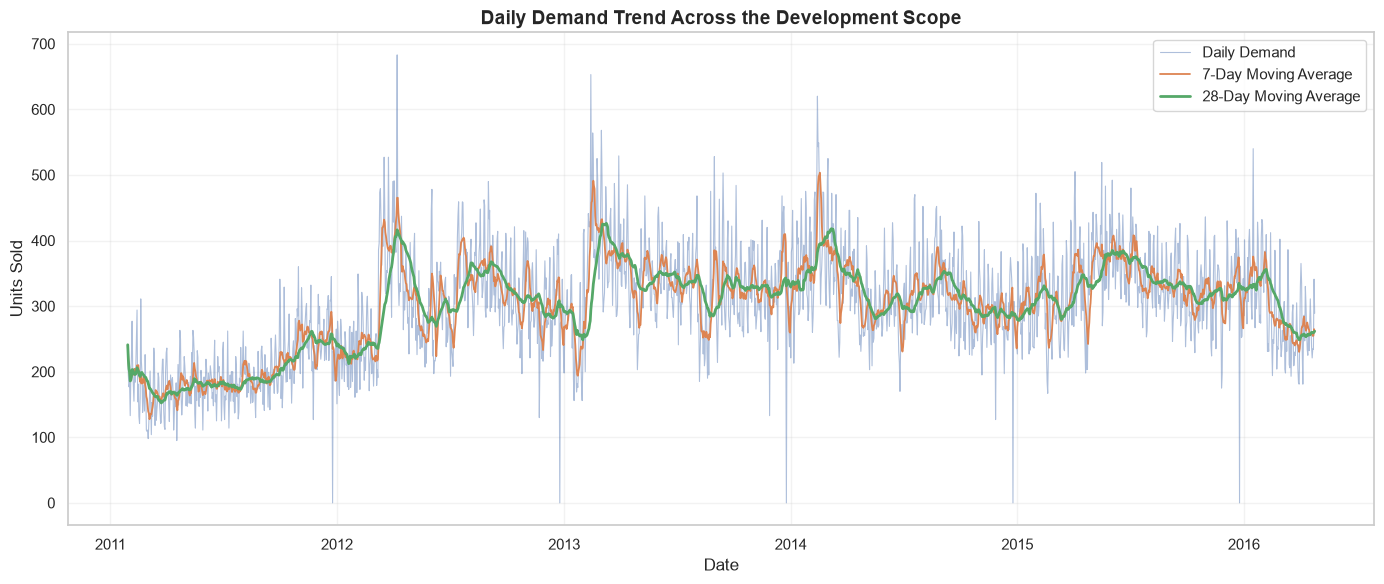

✅ Daily demand trend figure created successfully.
Figure path : C:\Users\hp\Project FORESIGHT\reports\figures\02_1_daily_demand_trend.png


In [47]:
# Visualise daily demand and rolling-average trends

DAILY_DEMAND_FIGURE = (
    FIGURES_DIR / "02_1_daily_demand_trend.png"
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_demand_trend["date"],
    daily_demand_trend["units_sold"],
    linewidth=0.8,
    alpha=0.45,
    label="Daily Demand",
)

ax.plot(
    daily_demand_trend["date"],
    daily_demand_trend["demand_7_day_average"],
    linewidth=1.3,
    label="7-Day Moving Average",
)

ax.plot(
    daily_demand_trend["date"],
    daily_demand_trend["demand_28_day_average"],
    linewidth=2.0,
    label="28-Day Moving Average",
)

ax.set_title(
    "Daily Demand Trend Across the Development Scope",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    DAILY_DEMAND_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("✅ Daily demand trend figure created successfully.")
print(f"Figure path : {DAILY_DEMAND_FIGURE}")

### Daily Demand Trend Summary

Daily demand fluctuates substantially across the historical period. The **7-day moving average** highlights short-term movement, while the **28-day moving average** shows the broader demand direction more clearly.

Demand increased from the lower levels observed in 2011 and remained generally higher from 2012 onward, although several temporary spikes and sharp declines occurred. Isolated zero-demand days should be investigated separately before being treated as normal demand behaviour.

The high daily variability indicates that weekly aggregation and calendar-based features may provide a more stable foundation for forecasting and inventory planning than individual daily observations.

> The dataset ends on **24 April 2016**, so the apparent decline in 2016 represents only a partial year.

✅ Section 7.1 is complete.


---

## 7.2 Weekly Demand Trend

Daily demand will be aggregated to weekly level to provide a clearer view of:

- medium-term demand direction;
- recurring weekly behaviour;
- sustained growth or decline;
- periods of unusual demand.

Weekly analysis is especially important because Project FORESIGHT will produce weekly demand forecasts.


In [48]:
# Prepare weekly demand trend data

weekly_demand_trend = (
    analytics_base_daily
    .groupby("wm_yr_wk", as_index=False)
    .agg(
        week_start_date=("date", "min"),
        week_end_date=("date", "max"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        observed_days=("date", "nunique"),
    )
    .sort_values("week_start_date")
    .reset_index(drop=True)
)

weekly_demand_trend["demand_4_week_average"] = (
    weekly_demand_trend["units_sold"]
    .rolling(window=4, min_periods=1)
    .mean()
)

weekly_demand_trend["demand_13_week_average"] = (
    weekly_demand_trend["units_sold"]
    .rolling(window=13, min_periods=1)
    .mean()
)

print("Weekly demand trend data prepared successfully.")
print(f"Weekly observations : {len(weekly_demand_trend):,}")
print(
    "Analysis period     : "
    f"{weekly_demand_trend['week_start_date'].min().date()} to "
    f"{weekly_demand_trend['week_end_date'].max().date()}"
)
print(
    "Total units sold    : "
    f"{weekly_demand_trend['units_sold'].sum():,.0f}"
)

Weekly demand trend data prepared successfully.
Weekly observations : 274
Analysis period     : 2011-01-29 to 2016-04-24
Total units sold    : 573,932


In [49]:
# Validate the weekly demand trend dataset

weekly_demand_trend["is_complete_week"] = (
    weekly_demand_trend["observed_days"].eq(7)
)

weekly_duplicate_ids = (
    weekly_demand_trend["wm_yr_wk"]
    .duplicated()
    .sum()
)

complete_week_count = int(
    weekly_demand_trend["is_complete_week"].sum()
)

partial_week_count = int(
    (~weekly_demand_trend["is_complete_week"]).sum()
)

assert len(weekly_demand_trend) == historical_week_count, (
    f"Expected {historical_week_count:,} weekly observations, "
    f"found {len(weekly_demand_trend):,}."
)

assert weekly_duplicate_ids == 0, (
    f"Duplicate retail-week identifiers found: "
    f"{weekly_duplicate_ids:,}."
)

assert weekly_demand_trend["week_start_date"].is_monotonic_increasing, (
    "Weekly demand records are not in chronological order."
)

assert weekly_demand_trend["observed_days"].between(1, 7).all(), (
    "Weekly records contain an invalid number of observed days."
)

assert np.isclose(
    weekly_demand_trend["units_sold"].sum(),
    total_units_sold,
), "Weekly demand totals do not reconcile."

assert np.isclose(
    weekly_demand_trend["revenue"].sum(),
    total_revenue,
), "Weekly revenue totals do not reconcile."

print("✅ Weekly demand trend validation passed.")
print(f"Complete weeks : {complete_week_count:,}")
print(f"Partial weeks  : {partial_week_count:,}")
print(
    "Weekly demand range : "
    f"{weekly_demand_trend['units_sold'].min():,.0f} to "
    f"{weekly_demand_trend['units_sold'].max():,.0f} units"
)

✅ Weekly demand trend validation passed.
Complete weeks : 273
Partial weeks  : 1
Weekly demand range : 630 to 3,397 units


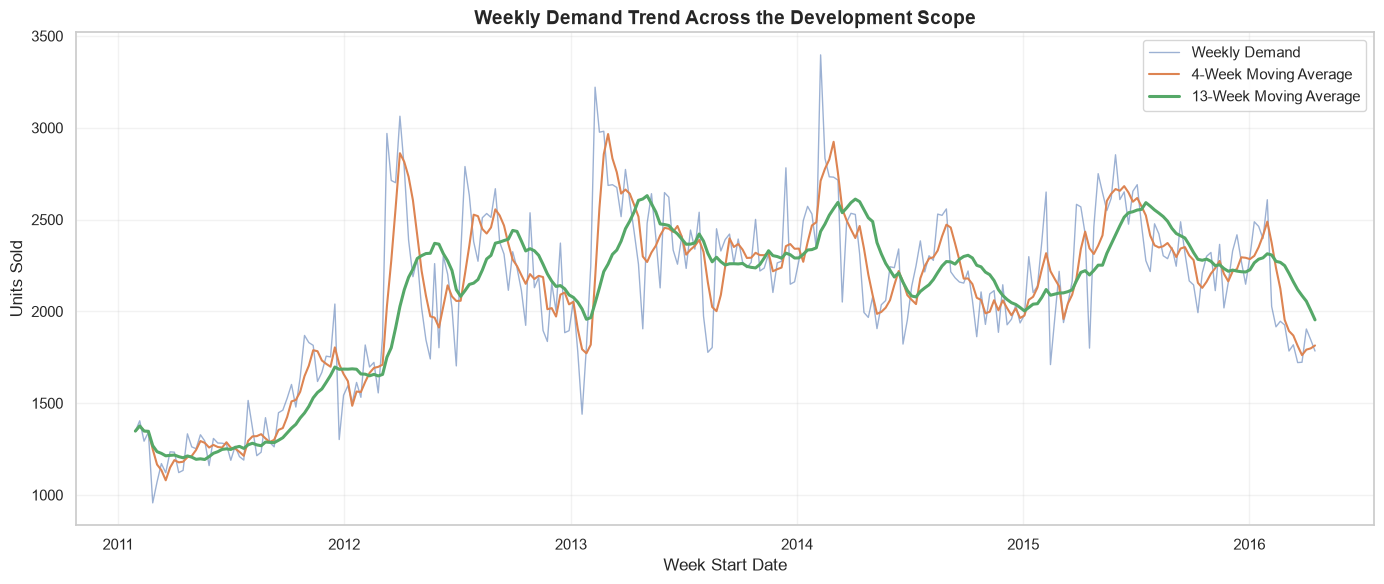

✅ Weekly demand trend figure created successfully.
Complete weeks plotted : 273
Partial weeks excluded : 1
Figure path            : C:\Users\hp\Project FORESIGHT\reports\figures\02_2_weekly_demand_trend.png


In [50]:
# Keep only complete weeks for fair trend comparison
weekly_demand_plot = (
    weekly_demand_trend.loc[
        weekly_demand_trend["is_complete_week"]
    ]
    .copy()
    .sort_values("week_start_date")
    .reset_index(drop=True)
)

# Recalculate moving averages without the partial week
weekly_demand_plot["demand_4_week_average"] = (
    weekly_demand_plot["units_sold"]
    .rolling(window=4, min_periods=1)
    .mean()
)

weekly_demand_plot["demand_13_week_average"] = (
    weekly_demand_plot["units_sold"]
    .rolling(window=13, min_periods=1)
    .mean()
)

# Define the output figure path
WEEKLY_DEMAND_FIGURE = (
    FIGURES_DIR / "02_2_weekly_demand_trend.png"
)

# Create the weekly demand chart
fig, ax = plt.subplots(figsize=(14, 6))

# Plot observed weekly demand
ax.plot(
    weekly_demand_plot["week_start_date"],
    weekly_demand_plot["units_sold"],
    linewidth=1.0,
    alpha=0.55,
    label="Weekly Demand",
)

# Plot the short-term trend
ax.plot(
    weekly_demand_plot["week_start_date"],
    weekly_demand_plot["demand_4_week_average"],
    linewidth=1.5,
    label="4-Week Moving Average",
)

# Plot the broader quarterly trend
ax.plot(
    weekly_demand_plot["week_start_date"],
    weekly_demand_plot["demand_13_week_average"],
    linewidth=2.2,
    label="13-Week Moving Average",
)

# Add chart labels and formatting
ax.set_title(
    "Weekly Demand Trend Across the Development Scope",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Week Start Date")
ax.set_ylabel("Units Sold")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

# Save the chart for reporting
fig.savefig(
    WEEKLY_DEMAND_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm the chart output
print("✅ Weekly demand trend figure created successfully.")
print(f"Complete weeks plotted : {len(weekly_demand_plot):,}")
print(f"Partial weeks excluded : {partial_week_count:,}")
print(f"Figure path            : {WEEKLY_DEMAND_FIGURE}")

### Weekly Demand Trend Summary

Weekly aggregation provides a clearer view of sustained demand movement than the highly variable daily series.

Demand increased substantially from the lower weekly levels observed in 2011 and remained generally higher from 2012 onward. However, the trend was not continuously upward; several recurring peaks were followed by periods of normalisation or decline.

The **4-week moving average** captures short-term movement, while the **13-week moving average** highlights the broader quarterly demand direction. These recurring changes support the use of lag, rolling-average, and seasonal calendar features in the weekly forecasting models.

The single partial week was excluded from the chart to ensure that all displayed weekly totals represent comparable seven-day periods.

> The apparent decline in 2016 should be interpreted cautiously because the dataset ends on **24 April 2016**.

✅ Section 7.2 is complete.

---

## 7.3 Monthly Demand Trend

Monthly demand will be analysed to identify:

- longer-term business movement;
- strong and weak months;
- recurring monthly peaks;
- possible seasonal demand cycles.

In [51]:
# Create a monthly period for each daily observation
monthly_demand_source = daily_demand_trend.copy()

monthly_demand_source["month"] = (
    monthly_demand_source["date"]
    .dt.to_period("M")
)

# Aggregate demand and revenue by month
monthly_demand_trend = (
    monthly_demand_source
    .groupby("month", as_index=False)
    .agg(
        month_start_date=("date", "min"),
        month_end_date=("date", "max"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        observed_days=("date", "nunique"),
    )
    .sort_values("month_start_date")
    .reset_index(drop=True)
)

# Identify complete and partial calendar months
monthly_demand_trend["calendar_days"] = (
    monthly_demand_trend["month"]
    .dt.days_in_month
)

monthly_demand_trend["is_complete_month"] = (
    monthly_demand_trend["observed_days"]
    .eq(monthly_demand_trend["calendar_days"])
)

# Calculate short- and long-term monthly trends
monthly_demand_trend["demand_3_month_average"] = (
    monthly_demand_trend["units_sold"]
    .rolling(window=3, min_periods=1)
    .mean()
)

monthly_demand_trend["demand_12_month_average"] = (
    monthly_demand_trend["units_sold"]
    .rolling(window=12, min_periods=1)
    .mean()
)

# Confirm the prepared monthly dataset
print("Monthly demand trend data prepared successfully.")
print(f"Monthly observations : {len(monthly_demand_trend):,}")
print(
    "Analysis period      : "
    f"{monthly_demand_trend['month_start_date'].min().date()} to "
    f"{monthly_demand_trend['month_end_date'].max().date()}"
)
print(
    "Total units sold     : "
    f"{monthly_demand_trend['units_sold'].sum():,.0f}"
)

Monthly demand trend data prepared successfully.
Monthly observations : 64
Analysis period      : 2011-01-29 to 2016-04-24
Total units sold     : 573,932


In [52]:
# Count complete and partial calendar months
complete_month_count = int(
    monthly_demand_trend["is_complete_month"].sum()
)

partial_month_count = int(
    (~monthly_demand_trend["is_complete_month"]).sum()
)

# Check for duplicate monthly periods
monthly_duplicate_periods = (
    monthly_demand_trend["month"]
    .duplicated()
    .sum()
)

# Check required monthly fields for missing values
monthly_missing_values = (
    monthly_demand_trend[
        [
            "month",
            "month_start_date",
            "month_end_date",
            "units_sold",
            "revenue",
            "observed_days",
            "calendar_days",
            "demand_3_month_average",
            "demand_12_month_average",
        ]
    ]
    .isna()
    .sum()
    .sum()
)

# Validate monthly coverage and structure
assert len(monthly_demand_trend) == historical_month_count, (
    f"Expected {historical_month_count:,} monthly observations, "
    f"found {len(monthly_demand_trend):,}."
)

assert monthly_duplicate_periods == 0, (
    f"Duplicate monthly periods found: "
    f"{monthly_duplicate_periods:,}."
)

assert monthly_missing_values == 0, (
    f"Missing monthly trend values found: "
    f"{monthly_missing_values:,}."
)

assert monthly_demand_trend["month_start_date"].is_monotonic_increasing, (
    "Monthly demand records are not in chronological order."
)

# Confirm observed days are valid for each month
assert (
    monthly_demand_trend["observed_days"]
    .le(monthly_demand_trend["calendar_days"])
    .all()
), "Observed days exceed the number of calendar days."

# Reconcile monthly totals with the complete dataset
assert np.isclose(
    monthly_demand_trend["units_sold"].sum(),
    total_units_sold,
), "Monthly demand totals do not reconcile."

assert np.isclose(
    monthly_demand_trend["revenue"].sum(),
    total_revenue,
), "Monthly revenue totals do not reconcile."

# Display validation results
print("✅ Monthly demand trend validation passed.")
print(f"Complete months : {complete_month_count:,}")
print(f"Partial months  : {partial_month_count:,}")
print(
    "Monthly demand range : "
    f"{monthly_demand_trend['units_sold'].min():,.0f} to "
    f"{monthly_demand_trend['units_sold'].max():,.0f} units"
)

✅ Monthly demand trend validation passed.
Complete months : 62
Partial months  : 2
Monthly demand range : 613 to 11,972 units


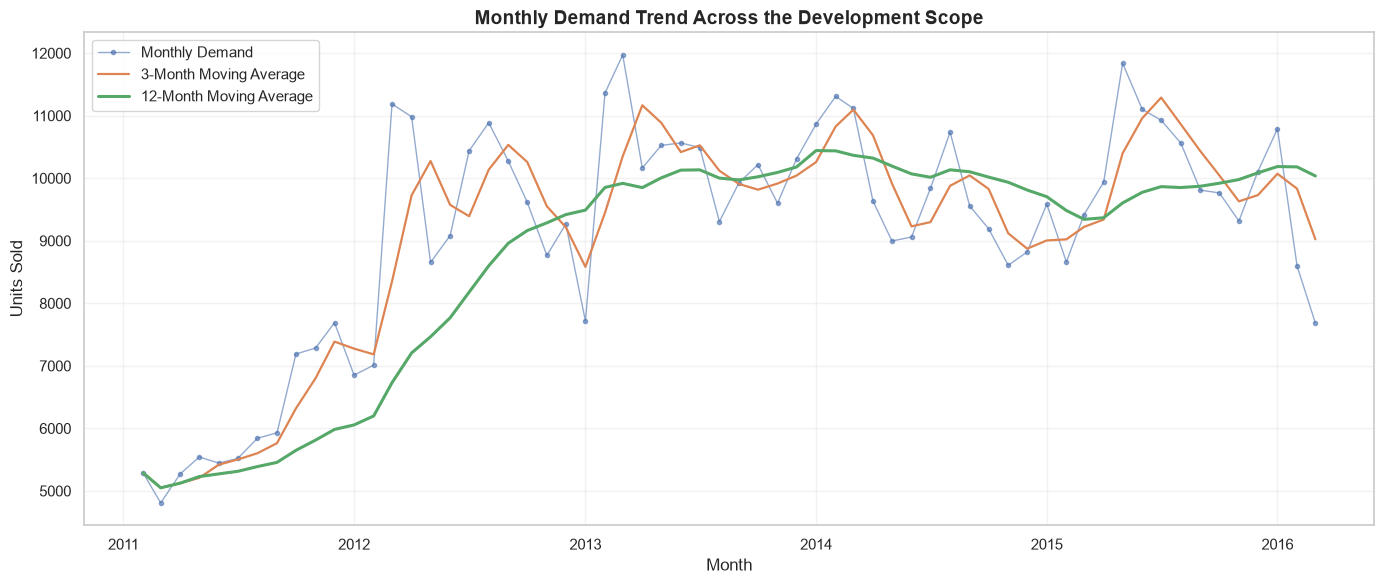

✅ Monthly demand trend figure created successfully.
Complete months plotted : 62
Partial months excluded : 2
Figure path             : C:\Users\hp\Project FORESIGHT\reports\figures\02_3_monthly_demand_trend.png


In [53]:
# Keep only complete months for fair comparison
monthly_demand_plot = (
    monthly_demand_trend.loc[
        monthly_demand_trend["is_complete_month"]
    ]
    .copy()
    .sort_values("month_start_date")
    .reset_index(drop=True)
)

# Recalculate moving averages after excluding partial months
monthly_demand_plot["demand_3_month_average"] = (
    monthly_demand_plot["units_sold"]
    .rolling(window=3, min_periods=1)
    .mean()
)

monthly_demand_plot["demand_12_month_average"] = (
    monthly_demand_plot["units_sold"]
    .rolling(window=12, min_periods=1)
    .mean()
)

# Define the figure output path
MONTHLY_DEMAND_FIGURE = (
    FIGURES_DIR / "02_3_monthly_demand_trend.png"
)

# Create the monthly demand chart
fig, ax = plt.subplots(figsize=(14, 6))

# Plot observed monthly demand
ax.plot(
    monthly_demand_plot["month_start_date"],
    monthly_demand_plot["units_sold"],
    marker="o",
    markersize=3,
    linewidth=1.0,
    alpha=0.60,
    label="Monthly Demand",
)

# Plot the short-term monthly trend
ax.plot(
    monthly_demand_plot["month_start_date"],
    monthly_demand_plot["demand_3_month_average"],
    linewidth=1.6,
    label="3-Month Moving Average",
)

# Plot the broader annual trend
ax.plot(
    monthly_demand_plot["month_start_date"],
    monthly_demand_plot["demand_12_month_average"],
    linewidth=2.2,
    label="12-Month Moving Average",
)

# Add chart labels and formatting
ax.set_title(
    "Monthly Demand Trend Across the Development Scope",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Month")
ax.set_ylabel("Units Sold")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

# Save the chart for reporting
fig.savefig(
    MONTHLY_DEMAND_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm the chart output
print("✅ Monthly demand trend figure created successfully.")
print(f"Complete months plotted : {len(monthly_demand_plot):,}")
print(f"Partial months excluded : {partial_month_count:,}")
print(f"Figure path             : {MONTHLY_DEMAND_FIGURE}")

### Monthly Demand Trend Summary

Monthly aggregation confirms a substantial increase in demand from 2011 into 2012. From 2012 onward, demand remained at a generally higher level but continued to experience recurring peaks and declines.

The **3-month moving average** highlights short-term changes, while the **12-month moving average** indicates that the broader demand level became relatively stable after the initial growth period. This supports the inclusion of monthly and annual seasonal features in later forecasting models.

January 2011 and April 2016 were excluded because they contain incomplete monthly coverage, ensuring that all displayed monthly totals are directly comparable.

> The final decline should be interpreted cautiously because the chart includes complete months only through **March 2016**.

✅ Section 7.3 is complete.


---

## 7.4 Yearly Demand Comparison

Yearly demand totals and average demand levels will be compared across the available historical period.

The analysis will consider that incomplete years may not be directly comparable with complete years.


In [54]:
# Create calendar-year fields for daily demand
yearly_demand_source = daily_demand_trend.copy()

yearly_demand_source["year"] = (
    yearly_demand_source["date"].dt.year
)

# Aggregate demand and revenue by calendar year
yearly_demand_comparison = (
    yearly_demand_source
    .groupby("year", as_index=False)
    .agg(
        period_start_date=("date", "min"),
        period_end_date=("date", "max"),
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        observed_days=("date", "nunique"),
    )
    .sort_values("year")
    .reset_index(drop=True)
)

# Calculate the expected number of days in each year
yearly_demand_comparison["calendar_days"] = (
    pd.to_datetime(
        yearly_demand_comparison["year"].astype(str)
        + "-12-31"
    )
    .dt.dayofyear
)

# Identify complete and partial calendar years
yearly_demand_comparison["is_complete_year"] = (
    yearly_demand_comparison["observed_days"]
    .eq(yearly_demand_comparison["calendar_days"])
)

# Calculate daily averages for fair comparison
yearly_demand_comparison["average_daily_demand"] = (
    yearly_demand_comparison["units_sold"]
    / yearly_demand_comparison["observed_days"]
)

yearly_demand_comparison["average_daily_revenue"] = (
    yearly_demand_comparison["revenue"]
    / yearly_demand_comparison["observed_days"]
)

# Summarise yearly coverage
complete_year_count = int(
    yearly_demand_comparison["is_complete_year"].sum()
)

partial_year_count = int(
    (~yearly_demand_comparison["is_complete_year"]).sum()
)

print("Yearly demand comparison prepared successfully.")
print(f"Yearly observations : {len(yearly_demand_comparison):,}")
print(f"Complete years      : {complete_year_count:,}")
print(f"Partial years       : {partial_year_count:,}")
print(
    "Total units sold   : "
    f"{yearly_demand_comparison['units_sold'].sum():,.0f}"
)

Yearly demand comparison prepared successfully.
Yearly observations : 6
Complete years      : 4
Partial years       : 2
Total units sold   : 573,932


In [55]:
# Label each year by data coverage
yearly_demand_comparison["coverage_status"] = np.where(
    yearly_demand_comparison["is_complete_year"],
    "Complete",
    "Partial",
)

# Check for duplicate years and missing values
duplicate_years = (
    yearly_demand_comparison["year"]
    .duplicated()
    .sum()
)

required_yearly_columns = [
    "year",
    "units_sold",
    "revenue",
    "observed_days",
    "calendar_days",
    "average_daily_demand",
    "average_daily_revenue",
    "coverage_status",
]

missing_yearly_values = (
    yearly_demand_comparison[required_yearly_columns]
    .isna()
    .sum()
    .sum()
)

# Validate yearly structure and reconciled totals
assert len(yearly_demand_comparison) == historical_year_count, (
    f"Expected {historical_year_count:,} yearly observations, "
    f"found {len(yearly_demand_comparison):,}."
)

assert duplicate_years == 0, (
    f"Duplicate calendar years found: {duplicate_years:,}."
)

assert missing_yearly_values == 0, (
    f"Missing yearly comparison values found: "
    f"{missing_yearly_values:,}."
)

assert yearly_demand_comparison["year"].is_monotonic_increasing, (
    "Yearly demand records are not in chronological order."
)

assert (
    yearly_demand_comparison["observed_days"]
    .le(yearly_demand_comparison["calendar_days"])
    .all()
), "Observed days exceed the number of calendar days."

assert np.isclose(
    yearly_demand_comparison["units_sold"].sum(),
    total_units_sold,
), "Yearly demand totals do not reconcile."

assert np.isclose(
    yearly_demand_comparison["revenue"].sum(),
    total_revenue,
), "Yearly revenue totals do not reconcile."

# Prepare a readable comparison table
yearly_demand_display = yearly_demand_comparison[
    [
        "year",
        "units_sold",
        "average_daily_demand",
        "observed_days",
        "coverage_status",
    ]
].copy()

yearly_demand_display.columns = [
    "Year",
    "Total Units Sold",
    "Average Daily Demand",
    "Observed Days",
    "Coverage",
]

yearly_demand_display["Average Daily Demand"] = (
    yearly_demand_display["Average Daily Demand"].round(2)
)

display(yearly_demand_display)

print("✅ Yearly demand comparison validation passed.")
print(f"Complete years : {complete_year_count:,}")
print(f"Partial years  : {partial_year_count:,}")

,Year,Total Units Sold,Average Daily Demand,Observed Days,Coverage
0,2011,66429,197.12,337,Partial
1,2012,113018,308.79,366,Complete
2,2013,122152,334.66,365,Complete
3,2014,117735,322.56,365,Complete
4,2015,121032,331.59,365,Complete
5,2016,33566,291.88,115,Partial


✅ Yearly demand comparison validation passed.
Complete years : 4
Partial years  : 2


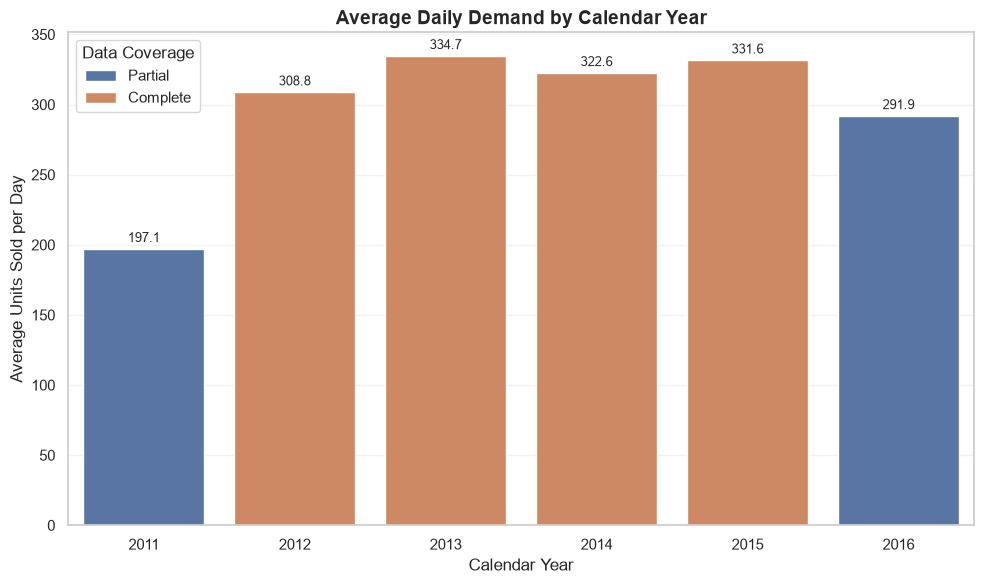

✅ Yearly demand comparison figure created successfully.
Years displayed : 6
Complete years  : 4
Partial years   : 2
Figure path     : C:\Users\hp\Project FORESIGHT\reports\figures\02_4_yearly_average_daily_demand.png


In [56]:
# Define the yearly comparison figure path
YEARLY_DEMAND_FIGURE = (
    FIGURES_DIR / "02_4_yearly_average_daily_demand.png"
)

# Create a bar chart using average daily demand
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=yearly_demand_display,
    x="Year",
    y="Average Daily Demand",
    hue="Coverage",
    dodge=False,
    ax=ax,
)

# Add demand values above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=9,
    )

# Add chart labels and formatting
ax.set_title(
    "Average Daily Demand by Calendar Year",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Calendar Year")
ax.set_ylabel("Average Units Sold per Day")
ax.legend(title="Data Coverage")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

# Save the chart for reporting
fig.savefig(
    YEARLY_DEMAND_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm the chart output
print("✅ Yearly demand comparison figure created successfully.")
print(f"Years displayed : {len(yearly_demand_display):,}")
print(f"Complete years  : {complete_year_count:,}")
print(f"Partial years   : {partial_year_count:,}")
print(f"Figure path     : {YEARLY_DEMAND_FIGURE}")

### Yearly Demand Comparison Summary

Average daily demand increased sharply from the partial 2011 period and remained at a substantially higher level during the complete years from 2012 to 2015.

Among the complete years, **2013 recorded the highest average daily demand at 334.7 units**, while 2012 recorded the lowest at 308.8 units. Demand declined moderately in 2014 and recovered in 2015, indicating fluctuation around a relatively stable higher demand level rather than continuous yearly growth.

The values for **2011 and 2016** should be interpreted cautiously because both years contain partial historical coverage.

✅ Section 7.4 is complete.

---

## 7.5 Day-of-Week Pattern

Average demand will be compared across calendar weekdays to identify whether particular days consistently experience higher or lower sales.


In [57]:
# Create weekday fields from each calendar date
day_of_week_source = daily_demand_trend.copy()

day_of_week_source["weekday_number"] = (
    day_of_week_source["date"].dt.dayofweek
)

day_of_week_source["day_of_week"] = (
    day_of_week_source["date"].dt.day_name()
)

# Define the correct Monday-to-Sunday order
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

# Summarise demand and revenue by weekday
day_of_week_summary = (
    day_of_week_source
    .groupby(
        ["weekday_number", "day_of_week"],
        as_index=False,
    )
    .agg(
        observed_days=("date", "nunique"),
        total_units_sold=("units_sold", "sum"),
        average_daily_demand=("units_sold", "mean"),
        total_revenue=("revenue", "sum"),
        average_daily_revenue=("revenue", "mean"),
    )
    .sort_values("weekday_number")
    .reset_index(drop=True)
)

# Apply a readable weekday order
day_of_week_summary["day_of_week"] = pd.Categorical(
    day_of_week_summary["day_of_week"],
    categories=weekday_order,
    ordered=True,
)

# Confirm the prepared weekday summary
print("Day-of-week demand summary prepared successfully.")
print(f"Weekdays represented : {len(day_of_week_summary):,}")
print(
    "Observed day range  : "
    f"{day_of_week_summary['observed_days'].min():,} to "
    f"{day_of_week_summary['observed_days'].max():,}"
)
print(
    "Average demand range: "
    f"{day_of_week_summary['average_daily_demand'].min():,.2f} to "
    f"{day_of_week_summary['average_daily_demand'].max():,.2f}"
)

Day-of-week demand summary prepared successfully.
Weekdays represented : 7
Observed day range  : 273 to 274
Average demand range: 268.80 to 360.50


In [58]:
# Check for duplicate weekday records
duplicate_weekdays = (
    day_of_week_summary["day_of_week"]
    .duplicated()
    .sum()
)

# Check required fields for missing values
weekday_required_columns = [
    "weekday_number",
    "day_of_week",
    "observed_days",
    "total_units_sold",
    "average_daily_demand",
    "total_revenue",
    "average_daily_revenue",
]

missing_weekday_values = (
    day_of_week_summary[weekday_required_columns]
    .isna()
    .sum()
    .sum()
)

# Confirm the correct weekday sequence
actual_weekday_order = (
    day_of_week_summary["day_of_week"]
    .astype(str)
    .tolist()
)

# Validate weekday structure and totals
assert len(day_of_week_summary) == 7, (
    f"Expected 7 weekdays, "
    f"found {len(day_of_week_summary):,}."
)

assert duplicate_weekdays == 0, (
    f"Duplicate weekday records found:, "
    f"found {len(day_of_week_summary):,}."
)

assert duplicate_weekdays == 0, (
    f"Duplicate weekday records found: "
    f"{duplicate_weekdays:,}."
)

assert missing_weekday_values == 0, (
    f"Missing weekday summary values found: "
    f"{missing_weekday_values:,}."
)

assert actual_weekday_order == weekday_order, (
    "Weekdays are not arranged from Monday to Sunday."
)

assert day_of_week_summary["observed_days"].sum() == historical_day_count, (
    "Weekday observations do not match historical coverage."
)

assert np.isclose(
    day_of_week_summary["total_units_sold"].sum(),
    total_units_sold,
), "Weekday demand totals do not reconcile."

assert np.isclose(
    day_of_week_summary["total_revenue"].sum(),
    total_revenue,
), "Weekday revenue totals do not reconcile."

# Identify the highest- and lowest-demand weekdays
highest_demand_weekday = day_of_week_summary.loc[
    day_of_week_summary["average_daily_demand"].idxmax()
]

lowest_demand_weekday = day_of_week_summary.loc[
    day_of_week_summary["average_daily_demand"].idxmin()
]

# Prepare a readable weekday comparison table
day_of_week_display = day_of_week_summary[
    [
        "day_of_week",
        "observed_days",
        "total_units_sold",
        "average_daily_demand",
    ]
].copy()

day_of_week_display.columns = [
    "Day of Week",
    "Observed Days",
    "Total Units Sold",
    "Average Daily Demand",
]

day_of_week_display["Average Daily Demand"] = (
    day_of_week_display["Average Daily Demand"].round(2)
)

display(day_of_week_display)

# Display validation and key findings
print("✅ Day-of-week demand validation passed.")
print(
    "Highest-demand day : "
    f"{highest_demand_weekday['day_of_week']} "
    f"({highest_demand_weekday['average_daily_demand']:,.2f} units)"
)
print(
    "Lowest-demand day  : "
    f"{lowest_demand_weekday['day_of_week']} "
    f"({lowest_demand_weekday['average_daily_demand']:,.2f} units)"
)

,Day of Week,Observed Days,Total Units Sold,Average Daily Demand
0,Monday,273,76254,279.32
1,Tuesday,273,73382,268.80
2,Wednesday,273,74612,273.30
3,Thursday,273,74002,271.07
4,Friday,273,84484,309.47
5,Saturday,274,98777,360.50
6,Sunday,274,92421,337.30


✅ Day-of-week demand validation passed.
Highest-demand day : Saturday (360.50 units)
Lowest-demand day  : Tuesday (268.80 units)


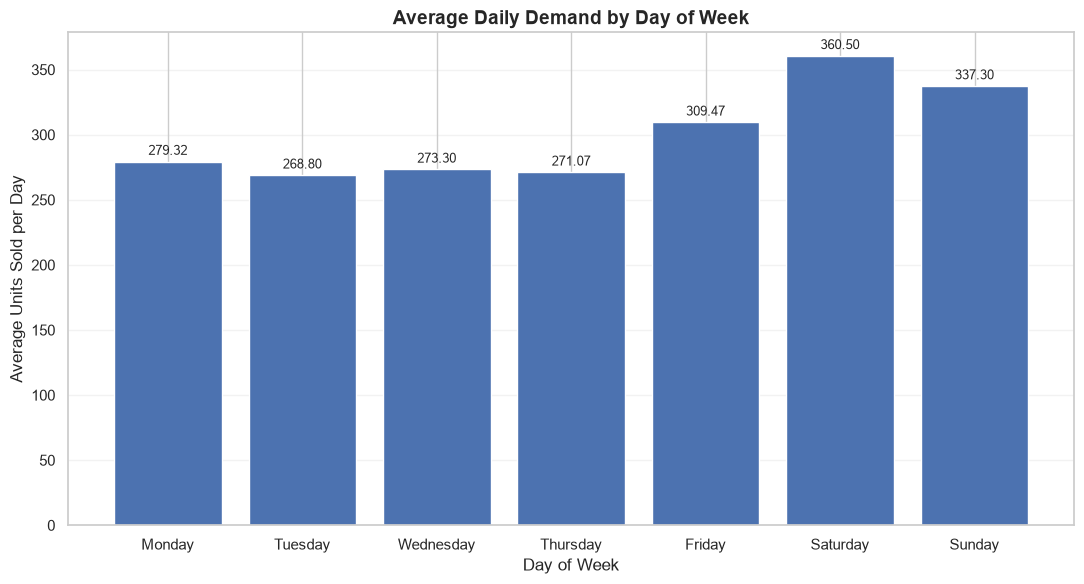

✅ Day-of-week demand figure created successfully.
Highest-demand day : Saturday (360.50 units)
Lowest-demand day  : Tuesday (268.80 units)
Figure path        : C:\Users\hp\Project FORESIGHT\reports\figures\02_5_day_of_week_demand_pattern.png


In [59]:
# Define the weekday-pattern figure path
DAY_OF_WEEK_FIGURE = (
    FIGURES_DIR / "02_5_day_of_week_demand_pattern.png"
)

# Create the weekday demand chart
fig, ax = plt.subplots(figsize=(11, 6))

# Plot average daily demand from Monday to Sunday
bars = ax.bar(
    day_of_week_display["Day of Week"],
    day_of_week_display["Average Daily Demand"],
)

# Add demand values above each bar
ax.bar_label(
    bars,
    fmt="%.2f",
    padding=3,
    fontsize=9,
)

# Add chart title and axis labels
ax.set_title(
    "Average Daily Demand by Day of Week",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Units Sold per Day")

# Improve readability
ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

# Save the chart for reporting
fig.savefig(
    DAY_OF_WEEK_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm the generated output
print("✅ Day-of-week demand figure created successfully.")
print(
    "Highest-demand day : "
    f"{highest_demand_weekday['day_of_week']} "
    f"({highest_demand_weekday['average_daily_demand']:,.2f} units)"
)
print(
    "Lowest-demand day  : "
    f"{lowest_demand_weekday['day_of_week']} "
    f"({lowest_demand_weekday['average_daily_demand']:,.2f} units)"
)
print(f"Figure path        : {DAY_OF_WEEK_FIGURE}")

### Day-of-Week Demand Summary

Demand follows a clear weekly pattern. Average daily demand remains relatively stable from Monday to Thursday, increases on Friday, and reaches its highest level during the weekend.

**Saturday recorded the highest average demand at 360.50 units**, followed by Sunday at 337.30 units. **Tuesday recorded the lowest average demand at 268.80 units.**

This pattern suggests that weekday information should be included as a forecasting feature. Inventory and replenishment planning should also account for the higher demand expected on Fridays and weekends.

✅ Section 7.5 is complete.

---

## 7.6 Weekday versus Weekend Demand

Demand during weekdays and weekends will be compared using:

- total units sold;
- average daily demand;
- revenue, where appropriate.

The comparison will use averages as well as totals because weekdays and weekends contain different numbers of observations.


In [60]:
# Classify each date as a weekday or weekend
weekday_weekend_source = day_of_week_source.copy()

weekday_weekend_source["day_type"] = np.where(
    weekday_weekend_source["weekday_number"].isin([5, 6]),
    "Weekend",
    "Weekday",
)

# Summarise demand and revenue for each day type
weekday_weekend_summary = (
    weekday_weekend_source
    .groupby("day_type", as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        total_units_sold=("units_sold", "sum"),
        average_daily_demand=("units_sold", "mean"),
        total_revenue=("revenue", "sum"),
        average_daily_revenue=("revenue", "mean"),
    )
)

# Arrange the comparison in a logical order
day_type_order = ["Weekday", "Weekend"]

weekday_weekend_summary["day_type"] = pd.Categorical(
    weekday_weekend_summary["day_type"],
    categories=day_type_order,
    ordered=True,
)

weekday_weekend_summary = (
    weekday_weekend_summary
    .sort_values("day_type")
    .reset_index(drop=True)
)

# Confirm the prepared comparison
print("Weekday and weekend demand summary prepared successfully.")
print(f"Comparison groups : {len(weekday_weekend_summary):,}")
print(
    "Observed days     : "
    f"{weekday_weekend_summary['observed_days'].sum():,}"
)
print(
    "Total units sold  : "
    f"{weekday_weekend_summary['total_units_sold'].sum():,.0f}"
)

Weekday and weekend demand summary prepared successfully.
Comparison groups : 2
Observed days     : 1,913
Total units sold  : 573,932


In [61]:
# Check for duplicate day-type records
duplicate_day_types = (
    weekday_weekend_summary["day_type"]
    .duplicated()
    .sum()
)

# Check required fields for missing values
comparison_columns = [
    "day_type",
    "observed_days",
    "total_units_sold",
    "average_daily_demand",
    "total_revenue",
    "average_daily_revenue",
]

missing_comparison_values = (
    weekday_weekend_summary[comparison_columns]
    .isna()
    .sum()
    .sum()
)

# Confirm the expected Weekday–Weekend order
actual_day_type_order = (
    weekday_weekend_summary["day_type"]
    .astype(str)
    .tolist()
)

# Validate structure and reconcile totals
assert len(weekday_weekend_summary) == 2, (
    f"Expected 2 comparison groups, "
    f"found {len(weekday_weekend_summary):,}."
)

assert duplicate_day_types == 0, (
    f"Duplicate day-type records found: "
    f"{duplicate_day_types:,}."
)

assert missing_comparison_values == 0, (
    f"Missing comparison values found: "
    f"{missing_comparison_values:,}."
)

assert actual_day_type_order == day_type_order, (
    "Day types are not arranged as Weekday and Weekend."
)

assert (
    weekday_weekend_summary["observed_days"].sum()
    == historical_day_count
), "Observed days do not match historical coverage."

assert np.isclose(
    weekday_weekend_summary["total_units_sold"].sum(),
    total_units_sold,
), "Demand totals do not reconcile."

assert np.isclose(
    weekday_weekend_summary["total_revenue"].sum(),
    total_revenue,
), "Revenue totals do not reconcile."

# Extract average demand for each group
weekday_average_demand = (
    weekday_weekend_summary.loc[
        weekday_weekend_summary["day_type"] == "Weekday",
        "average_daily_demand",
    ]
    .iloc[0]
)

weekend_average_demand = (
    weekday_weekend_summary.loc[
        weekday_weekend_summary["day_type"] == "Weekend",
        "average_daily_demand",
    ]
    .iloc[0]
)

# Calculate the weekend demand uplift
weekend_demand_uplift_pct = (
    (
        weekend_average_demand
        / weekday_average_demand
    )
    - 1
) * 100

# Prepare a readable comparison table
weekday_weekend_display = weekday_weekend_summary[
    [
        "day_type",
        "observed_days",
        "total_units_sold",
        "average_daily_demand",
        "total_revenue",
        "average_daily_revenue",
    ]
].copy()

weekday_weekend_display.columns = [
    "Day Type",
    "Observed Days",
    "Total Units Sold",
    "Average Daily Demand",
    "Total Revenue",
    "Average Daily Revenue",
]

# Round averages for presentation
weekday_weekend_display[
    "Average Daily Demand"
] = weekday_weekend_display[
    "Average Daily Demand"
].round(2)

weekday_weekend_display[
    "Average Daily Revenue"
] = weekday_weekend_display[
    "Average Daily Revenue"
].round(2)

display(weekday_weekend_display)

# Display validation and key comparison
print("✅ Weekday versus weekend validation passed.")
print(
    f"Weekday average demand : "
    f"{weekday_average_demand:,.2f} units"
)
print(
    f"Weekend average demand : "
    f"{weekend_average_demand:,.2f} units"
)
print(
    f"Weekend demand uplift  : "
    f"{weekend_demand_uplift_pct:,.2f}%"
)

,Day Type,Observed Days,Total Units Sold,Average Daily Demand,Total Revenue,Average Daily Revenue
0,Weekday,1365,382734,280.39,"1,128,420.81",826.68
1,Weekend,548,191198,348.90,"591,895.78","1,080.10"


✅ Weekday versus weekend validation passed.
Weekday average demand : 280.39 units
Weekend average demand : 348.90 units
Weekend demand uplift  : 24.43%


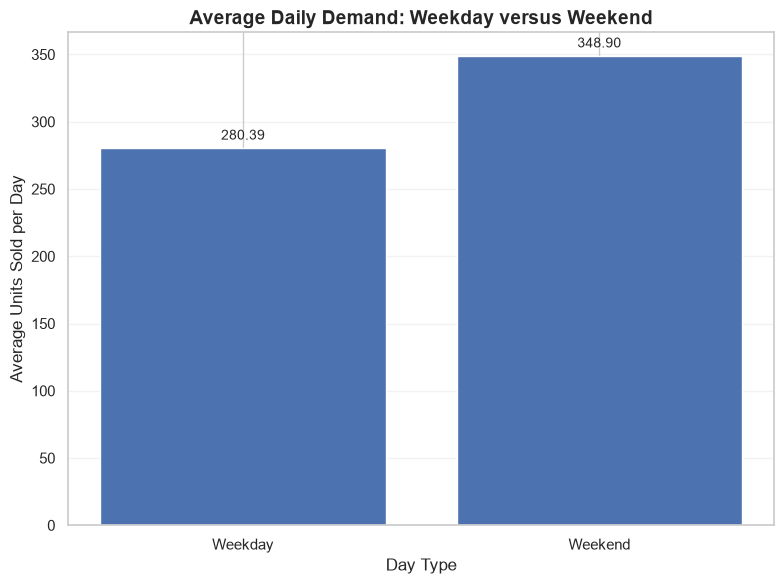

✅ Weekday versus weekend figure created successfully.
Weekday average demand : 280.39 units
Weekend average demand : 348.90 units
Weekend demand uplift  : 24.43%
Figure path            : C:\Users\hp\Project FORESIGHT\reports\figures\02_6_weekday_weekend_demand.png


In [62]:
# Define the comparison figure path
WEEKDAY_WEEKEND_FIGURE = (
    FIGURES_DIR / "02_6_weekday_weekend_demand.png"
)

# Create the average-demand comparison chart
fig, ax = plt.subplots(figsize=(8, 6))

# Plot average daily demand for both groups
bars = ax.bar(
    weekday_weekend_display["Day Type"],
    weekday_weekend_display["Average Daily Demand"],
)

# Display exact demand values above the bars
ax.bar_label(
    bars,
    fmt="%.2f",
    padding=4,
    fontsize=10,
)

# Add the chart title and axis labels
ax.set_title(
    "Average Daily Demand: Weekday versus Weekend",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Day Type")
ax.set_ylabel("Average Units Sold per Day")

# Improve chart readability
ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    WEEKDAY_WEEKEND_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm the figure and key result
print("✅ Weekday versus weekend figure created successfully.")
print(f"Weekday average demand : {weekday_average_demand:,.2f} units")
print(f"Weekend average demand : {weekend_average_demand:,.2f} units")
print(f"Weekend demand uplift  : {weekend_demand_uplift_pct:,.2f}%")
print(f"Figure path            : {WEEKDAY_WEEKEND_FIGURE}")

### Weekday versus Weekend Demand Summary

Average weekend demand reached **348.90 units per day**, compared with **280.39 units per weekday**, representing a **24.43% weekend uplift**.

Although weekdays generated more total units because they contain more observed days, weekends consistently produced stronger demand on a per-day basis. Average daily revenue also increased from **826.68 currency units on weekdays** to **1,080.10 currency units on weekends**.

This pattern supports the use of a weekend indicator in forecasting models. Replenishment and staffing decisions should also account for the stronger demand expected on Saturdays and Sundays.

✅ Section 7.6 is complete.


---

## 7.7 Monthly, Quarterly, and Seasonal Patterns

Demand will be summarised by:

- month;
- quarter;
- defined calendar season.

These summaries will help identify recurring demand periods that may later support calendar and seasonality features.


In [63]:
# Create recurring calendar fields from daily demand
calendar_pattern_source = daily_demand_trend.copy()

calendar_pattern_source["month_number"] = (
    calendar_pattern_source["date"].dt.month
)

calendar_pattern_source["month_name"] = (
    calendar_pattern_source["date"].dt.month_name()
)

calendar_pattern_source["quarter"] = (
    "Q"
    + calendar_pattern_source["date"]
    .dt.quarter
    .astype(str)
)

# Define meteorological calendar seasons
season_conditions = [
    calendar_pattern_source["month_number"].isin([12, 1, 2]),
    calendar_pattern_source["month_number"].isin([3, 4, 5]),
    calendar_pattern_source["month_number"].isin([6, 7, 8]),
    calendar_pattern_source["month_number"].isin([9, 10, 11]),
]

season_labels = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn",
]

calendar_pattern_source["season"] = np.select(
    season_conditions,
    season_labels,
    default="Unknown",
)

# Define logical display orders
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

quarter_order = ["Q1", "Q2", "Q3", "Q4"]

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn",
]

# Summarise recurring monthly demand
monthly_pattern_summary = (
    calendar_pattern_source
    .groupby(
        ["month_number", "month_name"],
        as_index=False,
    )
    .agg(
        observed_days=("date", "nunique"),
        total_units_sold=("units_sold", "sum"),
        average_daily_demand=("units_sold", "mean"),
        total_revenue=("revenue", "sum"),
        average_daily_revenue=("revenue", "mean"),
    )
    .sort_values("month_number")
    .reset_index(drop=True)
)

# Summarise recurring quarterly demand
quarterly_pattern_summary = (
    calendar_pattern_source
    .groupby("quarter", as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        total_units_sold=("units_sold", "sum"),
        average_daily_demand=("units_sold", "mean"),
        total_revenue=("revenue", "sum"),
        average_daily_revenue=("revenue", "mean"),
    )
)

quarterly_pattern_summary["quarter"] = pd.Categorical(
    quarterly_pattern_summary["quarter"],
    categories=quarter_order,
    ordered=True,
)

quarterly_pattern_summary = (
    quarterly_pattern_summary
    .sort_values("quarter")
    .reset_index(drop=True)
)

# Summarise recurring seasonal demand
seasonal_pattern_summary = (
    calendar_pattern_source
    .groupby("season", as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        total_units_sold=("units_sold", "sum"),
        average_daily_demand=("units_sold", "mean"),
        total_revenue=("revenue", "sum"),
        average_daily_revenue=("revenue", "mean"),
    )
)

seasonal_pattern_summary["season"] = pd.Categorical(
    seasonal_pattern_summary["season"],
    categories=season_order,
    ordered=True,
)

seasonal_pattern_summary = (
    seasonal_pattern_summary
    .sort_values("season")
    .reset_index(drop=True)
)

# Confirm the prepared calendar summaries
print("Calendar-pattern summaries prepared successfully.")
print(f"Months represented   : {len(monthly_pattern_summary):,}")
print(f"Quarters represented : {len(quarterly_pattern_summary):,}")
print(f"Seasons represented  : {len(seasonal_pattern_summary):,}")
print(
    "Total units covered : "
    f"{monthly_pattern_summary['total_units_sold'].sum():,.0f}"
)

Calendar-pattern summaries prepared successfully.
Months represented   : 12
Quarters represented : 4
Seasons represented  : 4
Total units covered : 573,932


In [64]:
# Define the fields required in each calendar summary
pattern_value_columns = [
    "observed_days",
    "total_units_sold",
    "average_daily_demand",
    "total_revenue",
    "average_daily_revenue",
]

# Check for duplicate calendar groups
duplicate_months = monthly_pattern_summary["month_name"].duplicated().sum()
duplicate_quarters = quarterly_pattern_summary["quarter"].duplicated().sum()
duplicate_seasons = seasonal_pattern_summary["season"].duplicated().sum()

# Check for missing analytical values
missing_pattern_values = (
    monthly_pattern_summary[pattern_value_columns].isna().sum().sum()
    + quarterly_pattern_summary[pattern_value_columns].isna().sum().sum()
    + seasonal_pattern_summary[pattern_value_columns].isna().sum().sum()
)

# Confirm the intended calendar order
actual_month_order = monthly_pattern_summary["month_name"].tolist()

actual_quarter_order = [
    str(value)
    for value in quarterly_pattern_summary["quarter"]
]

actual_season_order = [
    str(value)
    for value in seasonal_pattern_summary["season"]
]

# Validate summary structure
assert len(monthly_pattern_summary) == 12, (
    f"Expected 12 months, found {len(monthly_pattern_summary):,}."
)

assert len(quarterly_pattern_summary) == 4, (
    f"Expected 4 quarters, found {len(quarterly_pattern_summary):,}."
)

assert len(seasonal_pattern_summary) == 4, (
    f"Expected 4 seasons, found {len(seasonal_pattern_summary):,}."
)

assert duplicate_months == 0, (
    f"Duplicate month records found: {duplicate_months:,}."
)

assert duplicate_quarters == 0, (
    f"Duplicate quarter records found: {duplicate_quarters:,}."
)

assert duplicate_seasons == 0, (
    f"Duplicate season records found: {duplicate_seasons:,}."
)

assert missing_pattern_values == 0, (
    f"Missing calendar-pattern values found: "
    f"{missing_pattern_values:,}."
)

assert actual_month_order == month_order, (
    "Months are not arranged from January to December."
)

assert actual_quarter_order == quarter_order, (
    "Quarters are not arranged from Q1 to Q4."
)

assert actual_season_order == season_order, (
    "Seasons are not arranged in the defined order."
)

assert "Unknown" not in set(calendar_pattern_source["season"]), (
    "Some dates were not assigned to a valid season."
)

# Reconcile demand totals for every summary
for summary_name, summary_data in {
    "Monthly": monthly_pattern_summary,
    "Quarterly": quarterly_pattern_summary,
    "Seasonal": seasonal_pattern_summary,
}.items():
    assert np.isclose(
        summary_data["total_units_sold"].sum(),
        total_units_sold,
    ), f"{summary_name} demand totals do not reconcile."

    assert np.isclose(
        summary_data["total_revenue"].sum(),
        total_revenue,
    ), f"{summary_name} revenue totals do not reconcile."

# Identify the strongest and weakest recurring periods
highest_demand_month = monthly_pattern_summary.loc[
    monthly_pattern_summary["average_daily_demand"].idxmax()
]

lowest_demand_month = monthly_pattern_summary.loc[
    monthly_pattern_summary["average_daily_demand"].idxmin()
]

highest_demand_quarter = quarterly_pattern_summary.loc[
    quarterly_pattern_summary["average_daily_demand"].idxmax()
]

lowest_demand_quarter = quarterly_pattern_summary.loc[
    quarterly_pattern_summary["average_daily_demand"].idxmin()
]

highest_demand_season = seasonal_pattern_summary.loc[
    seasonal_pattern_summary["average_daily_demand"].idxmax()
]

lowest_demand_season = seasonal_pattern_summary.loc[
    seasonal_pattern_summary["average_daily_demand"].idxmin()
]

# Prepare concise display tables
monthly_pattern_display = monthly_pattern_summary[
    ["month_name", "observed_days", "average_daily_demand"]
].copy()

monthly_pattern_display.columns = [
    "Month",
    "Observed Days",
    "Average Daily Demand",
]

quarterly_pattern_display = quarterly_pattern_summary[
    ["quarter", "observed_days", "average_daily_demand"]
].copy()

quarterly_pattern_display.columns = [
    "Quarter",
    "Observed Days",
    "Average Daily Demand",
]

seasonal_pattern_display = seasonal_pattern_summary[
    ["season", "observed_days", "average_daily_demand"]
].copy()

seasonal_pattern_display.columns = [
    "Season",
    "Observed Days",
    "Average Daily Demand",
]

# Round demand values for presentation
for display_table in [
    monthly_pattern_display,
    quarterly_pattern_display,
    seasonal_pattern_display,
]:
    display_table["Average Daily Demand"] = (
        display_table["Average Daily Demand"].round(2)
    )

display(monthly_pattern_display)
display(quarterly_pattern_display)
display(seasonal_pattern_display)

# Display validation and key findings
print("✅ Calendar-pattern validation passed.")
print(
    "Highest-demand month   : "
    f"{highest_demand_month['month_name']} "
    f"({highest_demand_month['average_daily_demand']:,.2f} units)"
)
print(
    "Lowest-demand month    : "
    f"{lowest_demand_month['month_name']} "
    f"({lowest_demand_month['average_daily_demand']:,.2f} units)"
)
print(
    "Highest-demand quarter : "
    f"{highest_demand_quarter['quarter']} "
    f"({highest_demand_quarter['average_daily_demand']:,.2f} units)"
)
print(
    "Lowest-demand quarter  : "
    f"{lowest_demand_quarter['quarter']} "
    f"({lowest_demand_quarter['average_daily_demand']:,.2f} units)"
)
print(
    "Highest-demand season  : "
    f"{highest_demand_season['season']} "
    f"({highest_demand_season['average_daily_demand']:,.2f} units)"
)
print(
    "Lowest-demand season   : "
    f"{lowest_demand_season['season']} "
    f"({lowest_demand_season['average_daily_demand']:,.2f} units)"
)

,Month,Observed Days,Average Daily Demand
0,January,158,293.80
1,February,170,307.25
2,March,186,302.07
3,April,174,301.64
4,May,155,293.92
5,June,150,301.69
6,July,155,304.61
7,August,155,305.39
8,September,150,303.31
9,October,155,296.64


,Quarter,Observed Days,Average Daily Demand
0,Q1,514,301.24
1,Q2,479,299.16
2,Q3,460,304.45
3,Q4,460,295.10


,Season,Observed Days,Average Daily Demand
0,Winter,483,299.89
1,Spring,515,299.47
2,Summer,460,303.92
3,Autumn,455,296.82


✅ Calendar-pattern validation passed.
Highest-demand month   : February (307.25 units)
Lowest-demand month    : November (290.50 units)
Highest-demand quarter : Q3 (304.45 units)
Lowest-demand quarter  : Q4 (295.10 units)
Highest-demand season  : Summer (303.92 units)
Lowest-demand season   : Autumn (296.82 units)


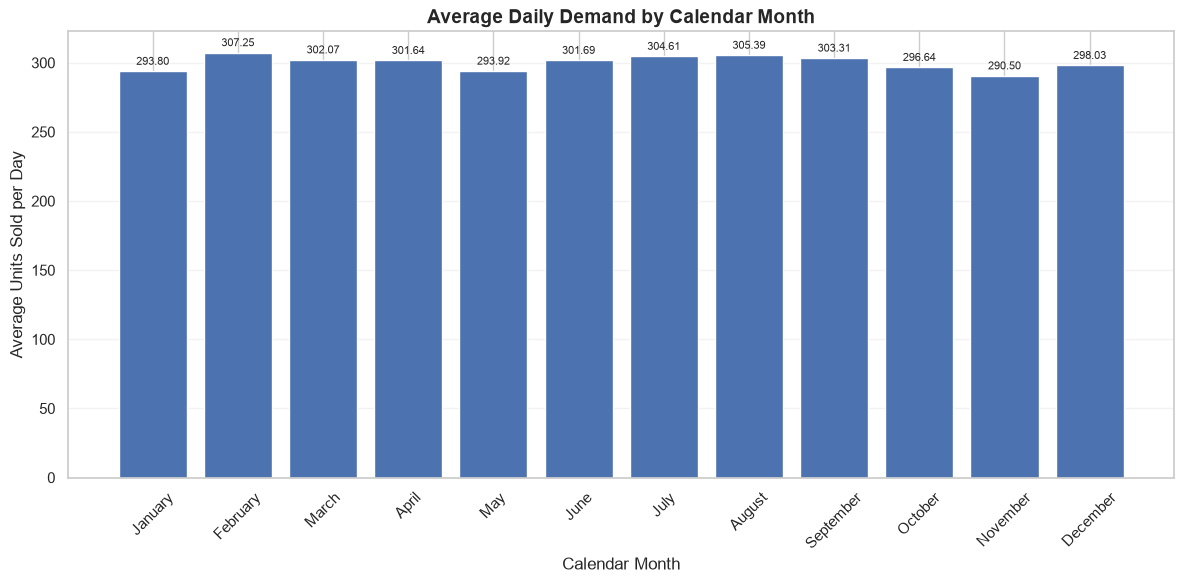

✅ Monthly demand-pattern figure created successfully.
Highest-demand month : February (307.25 units)
Lowest-demand month  : November (290.50 units)
Figure path          : C:\Users\hp\Project FORESIGHT\reports\figures\02_7_monthly_demand_pattern.png


In [65]:
# Define the monthly-pattern figure path
MONTHLY_PATTERN_FIGURE = (
    FIGURES_DIR / "02_7_monthly_demand_pattern.png"
)

# Create the recurring monthly demand chart
fig, ax = plt.subplots(figsize=(12, 6))

# Plot average daily demand for each month
bars = ax.bar(
    monthly_pattern_display["Month"],
    monthly_pattern_display["Average Daily Demand"],
)

# Add exact demand values above the bars
ax.bar_label(
    bars,
    fmt="%.2f",
    padding=3,
    fontsize=8,
)

# Add chart title and axis labels
ax.set_title(
    "Average Daily Demand by Calendar Month",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Calendar Month")
ax.set_ylabel("Average Units Sold per Day")

# Rotate month labels for readability
ax.tick_params(
    axis="x",
    rotation=45,
)

# Improve chart readability
ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    MONTHLY_PATTERN_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm the chart and key findings
print("✅ Monthly demand-pattern figure created successfully.")
print(
    "Highest-demand month : "
    f"{highest_demand_month['month_name']} "
    f"({highest_demand_month['average_daily_demand']:,.2f} units)"
)
print(
    "Lowest-demand month  : "
    f"{lowest_demand_month['month_name']} "
    f"({lowest_demand_month['average_daily_demand']:,.2f} units)"
)
print(f"Figure path          : {MONTHLY_PATTERN_FIGURE}")

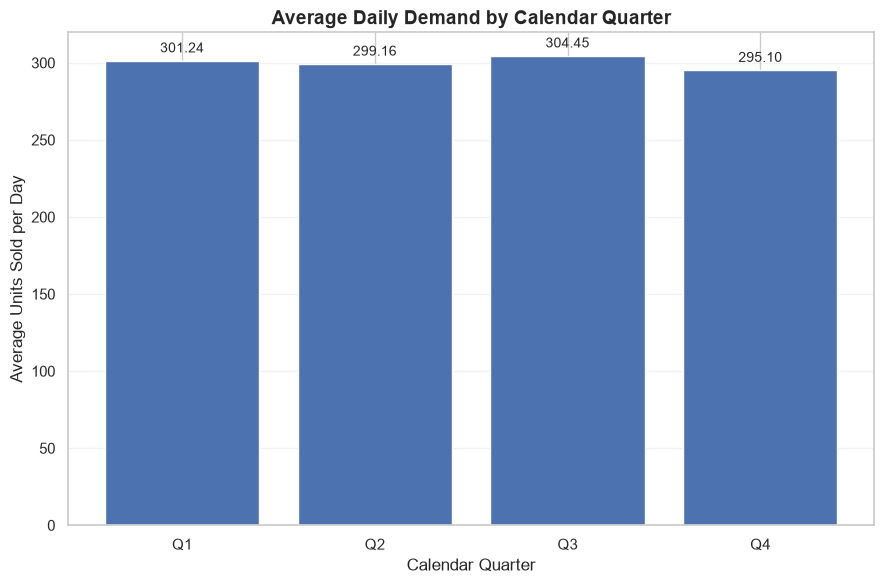

✅ Quarterly demand-pattern figure created successfully.
Highest-demand quarter : Q3 (304.45 units)
Lowest-demand quarter  : Q4 (295.10 units)
Figure path            : C:\Users\hp\Project FORESIGHT\reports\figures\02_8_quarterly_demand_pattern.png


In [66]:
# Define the quarterly-pattern figure path
QUARTERLY_PATTERN_FIGURE = (
    FIGURES_DIR / "02_8_quarterly_demand_pattern.png"
)

# FIGURES_DIR / "07_ Create the quarterly demand chart
fig, ax = plt.subplots(figsize=(9, 6))

# Plot average daily demand for Q1 to Q4
bars = ax.bar(
    quarterly_pattern_display["Quarter"].astype(str),
    quarterly_pattern_display["Average Daily Demand"],
)

# Add exact demand values above each bar
ax.bar_label(
    bars,
    fmt="%.2f",
    padding=4,
    fontsize=10,
)

# Add the chart title and axis labels
ax.set_title(
    "Average Daily Demand by Calendar Quarter",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Calendar Quarter")
ax.set_ylabel("Average Units Sold per Day")

# Improve chart readability
ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    QUARTERLY_PATTERN_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm the chart and key findings
print("✅ Quarterly demand-pattern figure created successfully.")
print(
    "Highest-demand quarter : "
    f"{highest_demand_quarter['quarter']} "
    f"({highest_demand_quarter['average_daily_demand']:,.2f} units)"
)
print(
    "Lowest-demand quarter  : "
    f"{lowest_demand_quarter['quarter']} "
    f"({lowest_demand_quarter['average_daily_demand']:,.2f} units)"
)
print(f"Figure path            : {QUARTERLY_PATTERN_FIGURE}")

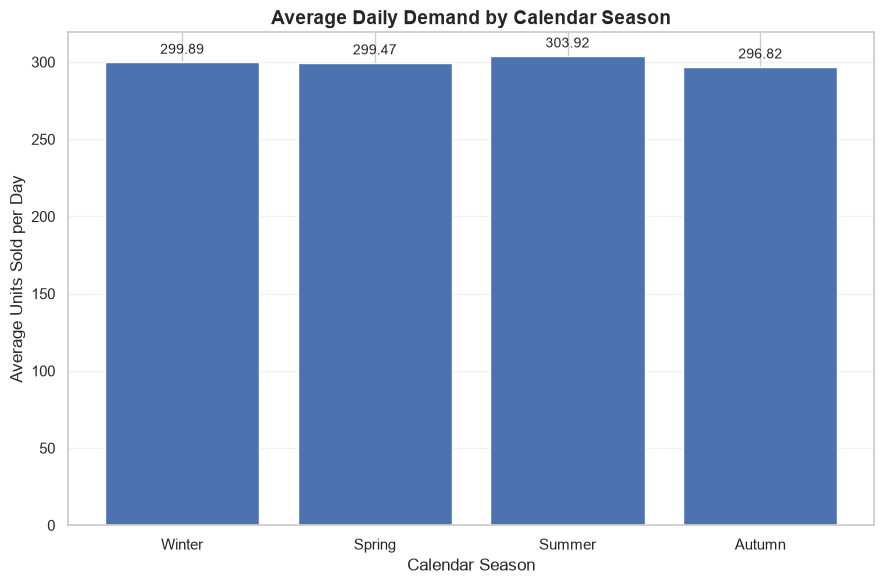

✅ Seasonal demand-pattern figure created successfully.
Highest-demand season : Summer (303.92 units)
Lowest-demand season  : Autumn (296.82 units)
Figure path           : C:\Users\hp\Project FORESIGHT\reports\figures\02_9_seasonal_demand_pattern.png


In [67]:
# Define the seasonal-pattern figure path
SEASONAL_PATTERN_FIGURE = (
    FIGURES_DIR / "02_9_seasonal_demand_pattern.png"
)

# Create the seasonal demand chart
fig, ax = plt.subplots(figsize=(9, 6))

# Plot average daily demand for each season
bars = ax.bar(
    seasonal_pattern_display["Season"].astype(str),
    seasonal_pattern_display["Average Daily Demand"],
)

# Add exact demand values above each bar
ax.bar_label(
    bars,
    fmt="%.2f",
    padding=4,
    fontsize=10,
)

# Add the chart title and axis labels
ax.set_title(
    "Average Daily Demand by Calendar Season",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Calendar Season")
ax.set_ylabel("Average Units Sold per Day")

# Improve chart readability
ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    SEASONAL_PATTERN_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm the chart and key findings
print("✅ Seasonal demand-pattern figure created successfully.")
print(
    "Highest-demand season : "
    f"{highest_demand_season['season']} "
    f"({highest_demand_season['average_daily_demand']:,.2f} units)"
)
print(
    "Lowest-demand season  : "
    f"{lowest_demand_season['season']} "
    f"({lowest_demand_season['average_daily_demand']:,.2f} units)"
)
print(f"Figure path           : {SEASONAL_PATTERN_FIGURE}")

### Monthly, Quarterly, and Seasonal Pattern Summary

Recurring calendar patterns are present, although their differences are moderate.

**February** recorded the highest monthly average demand at **307.25 units per day**, while **November** recorded the lowest at **290.50 units**. At the quarterly level, **Q3** was strongest at **304.45 units per day**, while **Q4** was weakest at **295.10 units**. **Summer** recorded the highest seasonal demand at **303.92 units per day**, compared with **296.82 units during Autumn**.

These results support including month, quarter, and season features in forecasting models. However, their demand differences are smaller than the weekday and weekend effects, so they should be treated as supporting rather than dominant demand drivers.

✅ Section 7.7 is complete.

---

## 7.8 Trend and Seasonality Summary

The most important findings from this section will be documented using:

- analytical observation;
- business interpretation;
- forecasting implication;
- inventory-planning implication.

> **Interpretation rule:** Historical patterns describe observed associations and recurring behaviour. They do not guarantee that the same pattern will continue unchanged in future periods.

In [68]:
# Keep complete years for fair annual comparison
complete_years_summary = yearly_demand_comparison.loc[
    yearly_demand_comparison["is_complete_year"]
].copy()

# Identify the strongest and weakest complete years
highest_demand_year = complete_years_summary.loc[
    complete_years_summary["average_daily_demand"].idxmax()
]

lowest_demand_year = complete_years_summary.loc[
    complete_years_summary["average_daily_demand"].idxmin()
]

# Measure the strongest recurring demand differences
weekday_demand_gap = (
    highest_demand_weekday["average_daily_demand"]
    - lowest_demand_weekday["average_daily_demand"]
)

monthly_demand_gap = (
    highest_demand_month["average_daily_demand"]
    - lowest_demand_month["average_daily_demand"]
)

seasonal_demand_gap = (
    highest_demand_season["average_daily_demand"]
    - lowest_demand_season["average_daily_demand"]
)

# Confirm the key comparison measures
print("Trend and seasonality findings prepared successfully.")
print(
    "Strongest complete year : "
    f"{int(highest_demand_year['year'])} "
    f"({highest_demand_year['average_daily_demand']:,.2f} units/day)"
)
print(
    "Weakest complete year   : "
    f"{int(lowest_demand_year['year'])} "
    f"({lowest_demand_year['average_daily_demand']:,.2f} units/day)"
)
print(f"Weekday demand gap       : {weekday_demand_gap:,.2f} units/day")
print(f"Monthly demand gap       : {monthly_demand_gap:,.2f} units/day")
print(f"Seasonal demand gap      : {seasonal_demand_gap:,.2f} units/day")

Trend and seasonality findings prepared successfully.
Strongest complete year : 2013 (334.66 units/day)
Weakest complete year   : 2012 (308.79 units/day)
Weekday demand gap       : 91.70 units/day
Monthly demand gap       : 16.75 units/day
Seasonal demand gap      : 7.11 units/day


In [69]:
# Create stakeholder-ready trend and seasonality findings

trend_seasonality_summary = pd.DataFrame(
    [
        {
            "Finding": "Long-Term Demand Level",
            "Analytical Observation": (
                "Demand increased from the lower levels observed in 2011 "
                "and remained generally higher from 2012 onward."
            ),
            "Business Interpretation": (
                "The business moved to a higher demand level, but demand "
                "did not continue growing consistently every year."
            ),
            "Forecasting Implication": (
                "Models should include trend and rolling-demand features "
                "rather than assume constant growth."
            ),
            "Inventory-Planning Implication": (
                "Replenishment levels should reflect recent demand trends "
                "instead of relying on the earliest historical average."
            ),
        },
        {
            "Finding": "Complete-Year Comparison",
            "Analytical Observation": (
                f"{int(highest_demand_year['year'])} recorded the highest "
                f"complete-year average demand at "
                f"{highest_demand_year['average_daily_demand']:,.2f} units "
                f"per day, compared with "
                f"{lowest_demand_year['average_daily_demand']:,.2f} units "
                f"in {int(lowest_demand_year['year'])}."
            ),
            "Business Interpretation": (
                "Annual demand fluctuated around a relatively stable higher "
                "level between 2012 and 2015."
            ),
            "Forecasting Implication": (
                "Year-based features may capture structural differences, "
                "but yearly growth should not be assumed."
            ),
            "Inventory-Planning Implication": (
                "Annual inventory plans should allow for moderate demand "
                "variation rather than continuous expansion."
            ),
        },
        {
            "Finding": "Weekly Demand Cycle",
            "Analytical Observation": (
                f"Weekend demand was {weekend_demand_uplift_pct:,.2f}% "
                f"higher than weekday demand. "
                f"{highest_demand_weekday['day_of_week']} was strongest, "
                f"while {lowest_demand_weekday['day_of_week']} was weakest."
            ),
            "Business Interpretation": (
                "Customer demand is concentrated more heavily on Fridays "
                "and weekends."
            ),
            "Forecasting Implication": (
                "Weekday, weekend, and day-of-week indicators should be "
                "included as important calendar features."
            ),
            "Inventory-Planning Implication": (
                "Stock availability and replenishment should be strengthened "
                "before the weekend demand peak."
            ),
        },
        {
            "Finding": "Monthly and Quarterly Pattern",
            "Analytical Observation": (
                f"{highest_demand_month['month_name']} recorded the highest "
                f"monthly average demand, while "
                f"{lowest_demand_month['month_name']} recorded the lowest. "
                f"{highest_demand_quarter['quarter']} was the strongest "
                f"quarter."
            ),
            "Business Interpretation": (
                "Recurring calendar patterns exist, but their differences "
                "are smaller than the weekly demand effect."
            ),
            "Forecasting Implication": (
                "Month and quarter features should support the model, but "
                "should not be treated as the dominant demand drivers."
            ),
            "Inventory-Planning Implication": (
                "Seasonal adjustments should be moderate and combined with "
                "recent demand and weekday patterns."
            ),
        },
        {
            "Finding": "Seasonal Pattern",
            "Analytical Observation": (
                f"{highest_demand_season['season']} recorded the highest "
                f"seasonal average demand, while "
                f"{lowest_demand_season['season']} recorded the lowest. "
                f"The difference was {seasonal_demand_gap:,.2f} units per day."
            ),
            "Business Interpretation": (
                "Seasonality is present, although the overall seasonal "
                "difference is relatively mild."
            ),
            "Forecasting Implication": (
                "Season indicators may provide incremental predictive value "
                "alongside stronger lag and weekly calendar features."
            ),
            "Inventory-Planning Implication": (
                "Seasonal inventory changes should remain proportionate to "
                "the relatively small observed demand difference."
            ),
        },
    ]
)

# Display a concise preparation confirmation
print("Trend and seasonality summary prepared successfully.")
print(f"Findings documented : {len(trend_seasonality_summary):,}")
print(
    "Summary fields      : "
    f"{trend_seasonality_summary.shape[1]:,}"
)

Trend and seasonality summary prepared successfully.
Findings documented : 5
Summary fields      : 5


In [70]:
# Define the required summary fields
required_summary_columns = [
    "Finding",
    "Analytical Observation",
    "Business Interpretation",
    "Forecasting Implication",
    "Inventory-Planning Implication",
]

# Check for missing columns, duplicate findings, and blank values
missing_summary_columns = [
    column
    for column in required_summary_columns
    if column not in trend_seasonality_summary.columns
]

duplicate_findings = (
    trend_seasonality_summary["Finding"]
    .duplicated()
    .sum()
)

missing_summary_values = (
    trend_seasonality_summary[required_summary_columns]
    .isna()
    .sum()
    .sum()
)

blank_summary_values = (
    trend_seasonality_summary[required_summary_columns]
    .astype(str)
    .apply(lambda column: column.str.strip().eq(""))
    .sum()
    .sum()
)

# Validate the consolidated findings
assert len(trend_seasonality_summary) == 5, (
    f"Expected 5 findings, "
    f"found {len(trend_seasonality_summary):,}."
)

assert not missing_summary_columns, (
    f"Missing summary columns: {missing_summary_columns}"
)

assert duplicate_findings == 0, (
    f"Duplicate findings found: {duplicate_findings:,}."
)

assert missing_summary_values == 0, (
    f"Missing summary values found: "
    f"{missing_summary_values:,}."
)

assert blank_summary_values == 0, (
    f"Blank summary values found: "
    f"{blank_summary_values:,}."
)

# Confirm successful completion without redisplaying
# the full text-heavy findings register
print("✅ Trend and seasonality summary validation passed.")
print(f"Validated findings : {len(trend_seasonality_summary):,}")
print(f"Validated fields   : {len(required_summary_columns):,}")
print(
    "✅ Section 7.8 completed: "
    "Trend and seasonality findings consolidated."
)

✅ Trend and seasonality summary validation passed.
Validated findings : 5
Validated fields   : 5
✅ Section 7.8 completed: Trend and seasonality findings consolidated.


### Trend and Seasonality Summary

Demand increased from the lower levels observed in 2011 and remained generally higher from 2012 onward, although no continuous yearly growth pattern was observed.

The strongest recurring effect was the weekly cycle: weekend demand was **24.43% higher** than weekday demand, with Saturday recording the highest average demand. Monthly, quarterly, and seasonal differences were present but comparatively moderate.

These findings support using trend, lag, rolling-average, weekday, weekend, month, quarter, and season features in later forecasting models. Inventory planning should place greater emphasis on recent demand and weekend peaks than on broad seasonal adjustments.

> Historical patterns describe observed associations and may not continue unchanged in future periods.

✅ Section 7.8 is complete.  
✅ Section 7: Demand Trends and Seasonality is complete.

---

# 🏪 8. Business Performance Analysis

This section compares business performance across product hierarchies, stores, states, products, and SKU-store combinations.

The purpose is to identify which parts of the business generate the strongest demand and revenue, and where weaker performance may require further investigation.

## Business Question

**Which categories, departments, stores, states, products, and SKU-store combinations perform best or worst?**

## Objectives

- compare demand and revenue across categories and departments;
- evaluate store and state performance;
- measure product and SKU-store contribution;
- identify consistently strong and weak business segments;
- distinguish high-demand performance from high-revenue performance;
- prepare business-level summary tables for reporting and dashboards.


---

## 8.1 Category Performance

Categories will be compared using:

- total units sold;
- total revenue;
- average daily demand;
- revenue contribution;
- estimated gross margin, where available.

This analysis will show which broad product groups contribute most to the business.



In [71]:
# Prepare the financial contribution for each record
category_performance_source = analytics_base_daily.copy()

category_performance_source[
    "estimated_margin_value"
] = (
    category_performance_source["units_sold"]
    * category_performance_source["estimated_gross_margin"]
)

# Aggregate demand and financial performance by category
category_performance_summary = (
    category_performance_source
    .groupby("category", as_index=False)
    .agg(
        active_sku_series=("sku_id", "nunique"),
        observed_days=("date", "nunique"),
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        estimated_gross_margin=("estimated_margin_value", "sum"),
    )
)

# Calculate average daily demand
category_performance_summary[
    "average_daily_demand"
] = (
    category_performance_summary["total_units_sold"]
    / category_performance_summary["observed_days"]
)

# Calculate contribution percentages
category_performance_summary[
    "demand_contribution_pct"
] = (
    category_performance_summary["total_units_sold"]
    / total_units_sold
    * 100
)

category_performance_summary[
    "revenue_contribution_pct"
] = (
    category_performance_summary["total_revenue"]
    / total_revenue
    * 100
)

# Rank categories by demand and revenue
category_performance_summary[
    "demand_rank"
] = (
    category_performance_summary["total_units_sold"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

category_performance_summary[
    "revenue_rank"
] = (
    category_performance_summary["total_revenue"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Arrange categories by total demand
category_performance_summary = (
    category_performance_summary
    .sort_values(
        "total_units_sold",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Confirm the prepared category summary
print("Category performance summary prepared successfully.")
print(
    f"Categories analysed : "
    f"{len(category_performance_summary):,}"
)
print(
    f"Total units covered : "
    f"{category_performance_summary['total_units_sold'].sum():,.0f}"
)
print(
    f"Total revenue covered: "
    f"{category_performance_summary['total_revenue'].sum():,.2f}"
)

Category performance summary prepared successfully.
Categories analysed : 3
Total units covered : 573,932
Total revenue covered: 1,720,316.59


In [72]:
# Calculate total estimated margin across all categories
total_category_margin = (
    category_performance_summary["estimated_gross_margin"].sum()
)

# Add estimated-margin contribution
category_performance_summary[
    "margin_contribution_pct"
] = (
    category_performance_summary["estimated_gross_margin"]
    / total_category_margin
    * 100
)

# Check summary quality
duplicate_categories = (
    category_performance_summary["category"]
    .duplicated()
    .sum()
)

missing_category_values = (
    category_performance_summary
    .isna()
    .sum()
    .sum()
)

# Validate category coverage and reconciliations
assert len(category_performance_summary) == 3, (
    f"Expected 3 categories, "
    f"found {len(category_performance_summary):,}."
)

assert duplicate_categories == 0, (
    f"Duplicate category records found: "
    f"{duplicate_categories:,}."
)

assert missing_category_values == 0, (
    f"Missing category values found: "
    f"{missing_category_values:,}."
)

assert np.isclose(
    category_performance_summary["total_units_sold"].sum(),
    total_units_sold,
), "Category demand totals do not reconcile."

assert np.isclose(
    category_performance_summary["total_revenue"].sum(),
    total_revenue,
), "Category revenue totals do not reconcile."

assert np.isclose(
    category_performance_summary[
        "demand_contribution_pct"
    ].sum(),
    100,
), "Demand contribution does not total 100%."

assert np.isclose(
    category_performance_summary[
        "revenue_contribution_pct"
    ].sum(),
    100,
), "Revenue contribution does not total 100%."

assert np.isclose(
    category_performance_summary[
        "margin_contribution_pct"
    ].sum(),
    100,
), "Margin contribution does not total 100%."

# Identify leading and weakest categories
highest_demand_category = category_performance_summary.loc[
    category_performance_summary["total_units_sold"].idxmax()
]

lowest_demand_category = category_performance_summary.loc[
    category_performance_summary["total_units_sold"].idxmin()
]

highest_revenue_category = category_performance_summary.loc[
    category_performance_summary["total_revenue"].idxmax()
]

lowest_revenue_category = category_performance_summary.loc[
    category_performance_summary["total_revenue"].idxmin()
]

# Prepare a concise presentation table
category_performance_display = (
    category_performance_summary[
        [
            "category",
            "active_sku_series",
            "total_units_sold",
            "average_daily_demand",
            "demand_contribution_pct",
            "total_revenue",
            "revenue_contribution_pct",
            "estimated_gross_margin",
            "margin_contribution_pct",
            "demand_rank",
            "revenue_rank",
        ]
    ]
    .copy()
)

category_performance_display.columns = [
    "Category",
    "Active SKU Series",
    "Total Units Sold",
    "Average Daily Demand",
    "Demand Contribution (%)",
    "Total Revenue",
    "Revenue Contribution (%)",
    "Estimated Gross Margin",
    "Margin Contribution (%)",
    "Demand Rank",
    "Revenue Rank",
]

# Round presentation values
rounding_rules = {
    "Average Daily Demand": 2,
    "Demand Contribution (%)": 2,
    "Total Revenue": 2,
    "Revenue Contribution (%)": 2,
    "Estimated Gross Margin": 2,
    "Margin Contribution (%)": 2,
}

category_performance_display = (
    category_performance_display.round(rounding_rules)
)

display(category_performance_display)

# Display validation and key findings
print("✅ Category performance validation passed.")
print(
    "Highest-demand category : "
    f"{highest_demand_category['category']} "
    f"({highest_demand_category['total_units_sold']:,.0f} units)"
)
print(
    "Lowest-demand category  : "
    f"{lowest_demand_category['category']} "
    f"({lowest_demand_category['total_units_sold']:,.0f} units)"
)
print(
    "Highest-revenue category: "
    f"{highest_revenue_category['category']} "
    f"({highest_revenue_category['total_revenue']:,.2f})"
)
print(
    "Lowest-revenue category : "
    f"{lowest_revenue_category['category']} "
    f"({lowest_revenue_category['total_revenue']:,.2f})"
)

,Category,Active SKU Series,Total Units Sold,Average Daily Demand,Demand Contribution (%),Total Revenue,Revenue Contribution (%),Estimated Gross Margin,Margin Contribution (%),Demand Rank,Revenue Rank
0,FOODS,100,235002,122.84,40.95,"586,096.99",34.07,"189,357.70",34.91,1,2
1,HOBBIES,100,195456,102.17,34.06,"417,160.26",24.25,"129,560.98",23.89,2,3
2,HOUSEHOLD,100,143474,75.00,25.00,"717,059.34",41.68,"223,510.50",41.21,3,1


✅ Category performance validation passed.
Highest-demand category : FOODS (235,002 units)
Lowest-demand category  : HOUSEHOLD (143,474 units)
Highest-revenue category: HOUSEHOLD (717,059.34)
Lowest-revenue category : HOBBIES (417,160.26)


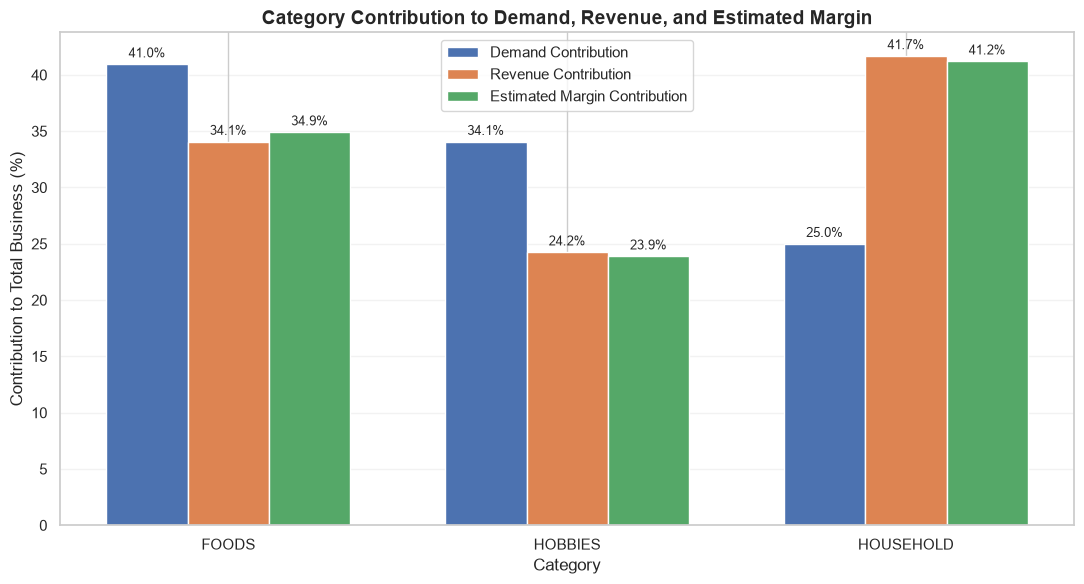

✅ Category contribution figure created successfully.
Demand leader  : FOODS
Revenue leader : HOUSEHOLD
Figure path    : C:\Users\hp\Project FORESIGHT\reports\figures\02_10_category_contribution_comparison.png


In [73]:
# Define the category-performance figure path
CATEGORY_PERFORMANCE_FIGURE = (
    FIGURES_DIR / "02_10_category_contribution_comparison.png"
)

# Prepare category labels and bar positions
category_labels = (
    category_performance_display["Category"]
    .astype(str)
    .tolist()
)

bar_positions = np.arange(len(category_labels))
bar_width = 0.24

# Create the contribution comparison chart
fig, ax = plt.subplots(figsize=(11, 6))

demand_bars = ax.bar(
    bar_positions - bar_width,
    category_performance_display["Demand Contribution (%)"],
    width=bar_width,
    label="Demand Contribution",
)

revenue_bars = ax.bar(
    bar_positions,
    category_performance_display["Revenue Contribution (%)"],
    width=bar_width,
    label="Revenue Contribution",
)

margin_bars = ax.bar(
    bar_positions + bar_width,
    category_performance_display["Margin Contribution (%)"],
    width=bar_width,
    label="Estimated Margin Contribution",
)

# Add percentage labels above the bars
ax.bar_label(
    demand_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=9,
)

ax.bar_label(
    revenue_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=9,
)

ax.bar_label(
    margin_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=9,
)

# Add chart title and axis labels
ax.set_title(
    "Category Contribution to Demand, Revenue, and Estimated Margin",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Category")
ax.set_ylabel("Contribution to Total Business (%)")

# Apply category labels
ax.set_xticks(bar_positions)
ax.set_xticklabels(category_labels)

# Improve chart readability
ax.legend()
ax.grid(
    axis="y",
    alpha=0.25,
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    CATEGORY_PERFORMANCE_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm successful figure creation
print("✅ Category contribution figure created successfully.")
print(
    "Demand leader  : "
    f"{highest_demand_category['category']}"
)
print(
    "Revenue leader : "
    f"{highest_revenue_category['category']}"
)
print(f"Figure path    : {CATEGORY_PERFORMANCE_FIGURE}")

### Category Performance Summary

- **Demand leader:** FOODS contributed **41.0% of total units sold** but only **34.1% of total revenue**.

- **Revenue leader:** HOUSEHOLD contributed just **25.0% of demand** but generated the highest revenue contribution at **41.7%**.

- **Lower-value category:** HOBBIES contributed **34.1% of demand** but only **24.2% of revenue**.

- **Key insight:** High sales volume does not necessarily produce the highest revenue or margin.

- **Margin pattern:** Estimated-margin contribution broadly follows revenue, with **HOUSEHOLD first, FOODS second, and HOBBIES third**.

- **Business implication:** Use FOODS to support volume, protect HOUSEHOLD as the strongest financial contributor, and investigate HOBBIES for **pricing, product mix, and margin improvement**.

> Estimated margins are assumption-based because unit costs were estimated rather than obtained from accounting records.

✅ Section 8.1: Category Performance is complete.


---

## 8.2 Department Performance

Departments will be evaluated using demand, revenue, and contribution measures.

Department-level analysis provides a more detailed view than category-level analysis and helps identify strong or weak product groups within each category.

In [74]:
# Prepare the department-level analytical source
department_performance_source = analytics_base_daily.copy()

# Calculate estimated margin contribution for each record
department_performance_source["estimated_margin_value"] = (
    department_performance_source["units_sold"]
    * department_performance_source["estimated_gross_margin"]
)

# Aggregate performance by department
department_performance_summary = (
    department_performance_source
    .groupby("department", as_index=False)
    .agg(
        active_sku_series=("sku_id", "nunique"),
        observed_days=("date", "nunique"),
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        estimated_gross_margin=("estimated_margin_value", "sum"),
    )
)

# Calculate average daily demand
department_performance_summary["average_daily_demand"] = (
    department_performance_summary["total_units_sold"]
    / department_performance_summary["observed_days"]
)

# Calculate the average revenue generated per unit
department_performance_summary["average_revenue_per_unit"] = (
    department_performance_summary["total_revenue"]
    / department_performance_summary["total_units_sold"]
)

# Calculate contribution percentages
department_performance_summary["demand_contribution_pct"] = (
    department_performance_summary["total_units_sold"]
    / total_units_sold
    * 100
)

department_performance_summary["revenue_contribution_pct"] = (
    department_performance_summary["total_revenue"]
    / total_revenue
    * 100
)

# Rank departments by demand and revenue
department_performance_summary["demand_rank"] = (
    department_performance_summary["total_units_sold"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

department_performance_summary["revenue_rank"] = (
    department_performance_summary["total_revenue"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Arrange departments by total demand
department_performance_summary = (
    department_performance_summary
    .sort_values("total_units_sold", ascending=False)
    .reset_index(drop=True)
)

# Confirm the prepared department summary
print("Department performance summary prepared successfully.")
print(
    f"Departments analysed : "
    f"{len(department_performance_summary):,}"
)
print(
    f"Total units covered  : "
    f"{department_performance_summary['total_units_sold'].sum():,.0f}"
)
print(
    f"Total revenue covered: "
    f"{department_performance_summary['total_revenue'].sum():,.2f}"
)

Department performance summary prepared successfully.
Departments analysed : 3
Total units covered  : 573,932
Total revenue covered: 1,720,316.59


In [75]:
# Calculate total estimated margin across departments
total_department_margin = (
    department_performance_summary["estimated_gross_margin"].sum()
)

# Calculate estimated-margin contribution
department_performance_summary["margin_contribution_pct"] = (
    department_performance_summary["estimated_gross_margin"]
    / total_department_margin
    * 100
)

# Check for duplicate departments and missing values
duplicate_departments = (
    department_performance_summary["department"]
    .duplicated()
    .sum()
)

missing_department_values = (
    department_performance_summary
    .isna()
    .sum()
    .sum()
)

# Validate department coverage
assert len(department_performance_summary) == 3, (
    f"Expected 3 departments, "
    f"found {len(department_performance_summary):,}."
)

assert duplicate_departments == 0, (
    f"Duplicate department records found: "
    f"{duplicate_departments:,}."
)

assert missing_department_values == 0, (
    f"Missing department values found: "
    f"{missing_department_values:,}."
)

# Reconcile demand and revenue totals
assert np.isclose(
    department_performance_summary["total_units_sold"].sum(),
    total_units_sold,
), "Department demand totals do not reconcile."

assert np.isclose(
    department_performance_summary["total_revenue"].sum(),
    total_revenue,
), "Department revenue totals do not reconcile."

# Validate contribution percentages
assert np.isclose(
    department_performance_summary[
        "demand_contribution_pct"
    ].sum(),
    100,
), "Demand contribution does not total 100%."

assert np.isclose(
    department_performance_summary[
        "revenue_contribution_pct"
    ].sum(),
    100,
), "Revenue contribution does not total 100%."

assert np.isclose(
    department_performance_summary[
        "margin_contribution_pct"
    ].sum(),
    100,
), "Margin contribution does not total 100%."

# Identify leading and weakest departments
highest_demand_department = department_performance_summary.loc[
    department_performance_summary["total_units_sold"].idxmax()
]

lowest_demand_department = department_performance_summary.loc[
    department_performance_summary["total_units_sold"].idxmin()
]

highest_revenue_department = department_performance_summary.loc[
    department_performance_summary["total_revenue"].idxmax()
]

lowest_revenue_department = department_performance_summary.loc[
    department_performance_summary["total_revenue"].idxmin()
]

highest_unit_value_department = department_performance_summary.loc[
    department_performance_summary[
        "average_revenue_per_unit"
    ].idxmax()
]

# Prepare a concise presentation table
department_performance_display = (
    department_performance_summary[
        [
            "department",
            "active_sku_series",
            "total_units_sold",
            "average_daily_demand",
            "demand_contribution_pct",
            "total_revenue",
            "average_revenue_per_unit",
            "revenue_contribution_pct",
            "estimated_gross_margin",
            "margin_contribution_pct",
            "demand_rank",
            "revenue_rank",
        ]
    ]
    .copy()
)

department_performance_display.columns = [
    "Department",
    "Active SKU Series",
    "Total Units Sold",
    "Average Daily Demand",
    "Demand Contribution (%)",
    "Total Revenue",
    "Average Revenue per Unit",
    "Revenue Contribution (%)",
    "Estimated Gross Margin",
    "Margin Contribution (%)",
    "Demand Rank",
    "Revenue Rank",
]

# Round presentation values
rounding_rules = {
    "Average Daily Demand": 2,
    "Demand Contribution (%)": 2,
    "Total Revenue": 2,
    "Average Revenue per Unit": 2,
    "Revenue Contribution (%)": 2,
    "Estimated Gross Margin": 2,
    "Margin Contribution (%)": 2,
}

department_performance_display = (
    department_performance_display.round(rounding_rules)
)

display(department_performance_display)

# Display validation and key findings
print("✅ Department performance validation passed.")
print(
    "Highest-demand department : "
    f"{highest_demand_department['department']} "
    f"({highest_demand_department['total_units_sold']:,.0f} units)"
)
print(
    "Lowest-demand department  : "
    f"{lowest_demand_department['department']} "
    f"({lowest_demand_department['total_units_sold']:,.0f} units)"
)
print(
    "Highest-revenue department: "
    f"{highest_revenue_department['department']} "
    f"({highest_revenue_department['total_revenue']:,.2f})"
)
print(
    "Lowest-revenue department : "
    f"{lowest_revenue_department['department']} "
    f"({lowest_revenue_department['total_revenue']:,.2f})"
)
print(
    "Highest revenue per unit  : "
    f"{highest_unit_value_department['department']} "
    f"({highest_unit_value_department['average_revenue_per_unit']:,.2f})"
)

,Department,Active SKU Series,Total Units Sold,Average Daily Demand,Demand Contribution (%),Total Revenue,Average Revenue per Unit,Revenue Contribution (%),Estimated Gross Margin,Margin Contribution (%),Demand Rank,Revenue Rank
0,FOODS_1,100,235002,122.84,40.95,"586,096.99",2.49,34.07,"189,357.70",34.91,1,2
1,HOBBIES_1,100,195456,102.17,34.06,"417,160.26",2.13,24.25,"129,560.98",23.89,2,3
2,HOUSEHOLD_1,100,143474,75.00,25.00,"717,059.34",5.00,41.68,"223,510.50",41.21,3,1


✅ Department performance validation passed.
Highest-demand department : FOODS_1 (235,002 units)
Lowest-demand department  : HOUSEHOLD_1 (143,474 units)
Highest-revenue department: HOUSEHOLD_1 (717,059.34)
Lowest-revenue department : HOBBIES_1 (417,160.26)
Highest revenue per unit  : HOUSEHOLD_1 (5.00)


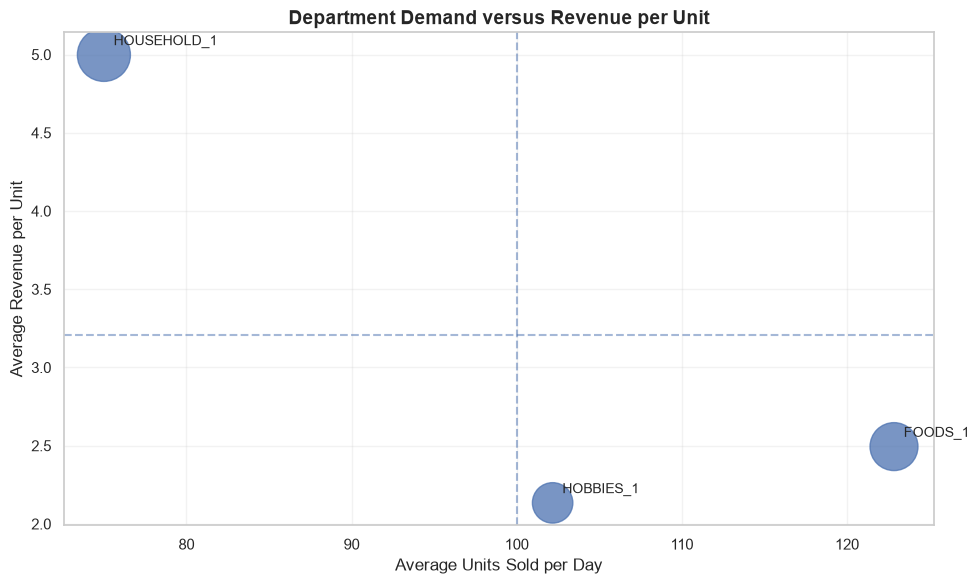

✅ Department demand-value figure created successfully.
Demand leader     : FOODS_1
Unit-value leader : HOUSEHOLD_1
Figure path       : C:\Users\hp\Project FORESIGHT\reports\figures\02_11_department_demand_value_comparison.png


In [76]:
# Define the department-performance figure path
DEPARTMENT_PERFORMANCE_FIGURE = (
    FIGURES_DIR / "02_11_department_demand_value_comparison.png"
)

# Prepare chart values
department_chart_data = department_performance_summary.copy()

point_sizes = (
    department_chart_data["revenue_contribution_pct"] * 35
)

# Create the demand-versus-value chart
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    department_chart_data["average_daily_demand"],
    department_chart_data["average_revenue_per_unit"],
    s=point_sizes,
    alpha=0.75,
)

# Add department labels
for _, row in department_chart_data.iterrows():
    ax.annotate(
        row["department"],
        (
            row["average_daily_demand"],
            row["average_revenue_per_unit"],
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
    )

# Add reference lines using department averages
ax.axvline(
    department_chart_data["average_daily_demand"].mean(),
    linestyle="--",
    alpha=0.5,
)

ax.axhline(
    department_chart_data["average_revenue_per_unit"].mean(),
    linestyle="--",
    alpha=0.5,
)

# Add chart title and labels
ax.set_title(
    "Department Demand versus Revenue per Unit",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Average Units Sold per Day")
ax.set_ylabel("Average Revenue per Unit")

ax.grid(alpha=0.25)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    DEPARTMENT_PERFORMANCE_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm figure creation
print("✅ Department demand-value figure created successfully.")
print(
    "Demand leader     : "
    f"{highest_demand_department['department']}"
)
print(
    "Unit-value leader : "
    f"{highest_unit_value_department['department']}"
)
print(f"Figure path       : {DEPARTMENT_PERFORMANCE_FIGURE}")

### Department Performance Summary

- **Demand leader:** FOODS_1 contributed **40.95% of total units sold** and **34.07% of total revenue**.

- **Revenue leader:** HOUSEHOLD_1 contributed only **25.00% of demand** but generated the highest revenue contribution at **41.68%**.

- **Highest unit value:** HOUSEHOLD_1 earned **5.00 revenue units per item**, compared with **2.49** for FOODS_1 and **2.13** for HOBBIES_1.

- **Weakest financial conversion:** HOBBIES_1 contributed **34.06% of demand** but only **24.25% of revenue**.

- **Margin pattern:** Estimated-margin rankings broadly follow revenue rankings, with **HOUSEHOLD_1 contributing the most estimated margin**.

- **Scope note:** Each category currently contains only one department, so department findings closely mirror category findings.

- **Business implication:** Prioritise FOODS_1 for volume, protect HOUSEHOLD_1 for financial value, and review HOBBIES_1 for **pricing, product mix, and margin improvement**.

> Estimated margins are assumption-based because actual product-cost data was unavailable.

✅ Section 8.2: Department Performance is complete.

---

## 8.3 Store Performance

Stores will be compared using:

- total units sold;
- total revenue;
- average daily demand;
- number of active SKU series;
- contribution to overall business performance.

The analysis will help identify stores with unusually strong or weak demand patterns.



In [77]:
# Prepare the store-level analytical source
store_performance_source = analytics_base_daily.copy()

# Identify the available store column
if "store_id" in store_performance_source.columns:
    store_field = "store_id"
elif "store" in store_performance_source.columns:
    store_field = "store"
else:
    raise KeyError("No store column was found.")

# Identify the available state column
if "state" in store_performance_source.columns:
    state_field = "state"
elif "state_id" in store_performance_source.columns:
    state_field = "state_id"
else:
    raise KeyError("No state column was found.")

# Calculate estimated margin for each record
store_performance_source["estimated_margin_value"] = (
    store_performance_source["units_sold"]
    * store_performance_source["estimated_gross_margin"]
)

# Aggregate performance by store and state
store_performance_summary = (
    store_performance_source
    .groupby(
        [store_field, state_field],
        as_index=False,
    )
    .agg(
        active_sku_series=("sku_id", "nunique"),
        observed_days=("date", "nunique"),
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        estimated_gross_margin=("estimated_margin_value", "sum"),
    )
)

# Standardise the store and state column names
store_performance_summary = (
    store_performance_summary
    .rename(
        columns={
            store_field: "store_id",
            state_field: "state",
        }
    )
)

# Calculate average daily demand
store_performance_summary["average_daily_demand"] = (
    store_performance_summary["total_units_sold"]
    / store_performance_summary["observed_days"]
)

# Calculate average revenue per unit
store_performance_summary["average_revenue_per_unit"] = (
    store_performance_summary["total_revenue"]
    / store_performance_summary["total_units_sold"]
)

# Calculate contribution percentages
store_performance_summary["demand_contribution_pct"] = (
    store_performance_summary["total_units_sold"]
    / total_units_sold
    * 100
)

store_performance_summary["revenue_contribution_pct"] = (
    store_performance_summary["total_revenue"]
    / total_revenue
    * 100
)

# Rank stores by demand and revenue
store_performance_summary["demand_rank"] = (
    store_performance_summary["total_units_sold"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

store_performance_summary["revenue_rank"] = (
    store_performance_summary["total_revenue"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Arrange stores by total demand
store_performance_summary = (
    store_performance_summary
    .sort_values(
        "total_units_sold",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Confirm the prepared store summary
print("Store performance summary prepared successfully.")
print(f"Stores analysed        : {len(store_performance_summary):,}")
print(
    "States represented     : "
    f"{store_performance_summary['state'].nunique():,}"
)
print(
    "Total units covered    : "
    f"{store_performance_summary['total_units_sold'].sum():,.0f}"
)
print(
    "Total revenue covered  : "
    f"{store_performance_summary['total_revenue'].sum():,.2f}"
)

Store performance summary prepared successfully.
Stores analysed        : 10
States represented     : 3
Total units covered    : 573,932
Total revenue covered  : 1,720,316.59


In [78]:
# Calculate total estimated margin across stores
total_store_margin = (
    store_performance_summary["estimated_gross_margin"].sum()
)

# Calculate estimated-margin contribution
store_performance_summary["margin_contribution_pct"] = (
    store_performance_summary["estimated_gross_margin"]
    / total_store_margin
    * 100
)

# Check for duplicate stores and missing values
duplicate_stores = (
    store_performance_summary["store_id"]
    .duplicated()
    .sum()
)

missing_store_values = (
    store_performance_summary
    .isna()
    .sum()
    .sum()
)

# Validate store coverage
assert len(store_performance_summary) == 10, (
    f"Expected 10 stores, "
    f"found {len(store_performance_summary):,}."
)

assert store_performance_summary["state"].nunique() == 3, (
    "Expected stores from 3 states."
)

assert duplicate_stores == 0, (
    f"Duplicate store records found: {duplicate_stores:,}."
)

assert missing_store_values == 0, (
    f"Missing store values found: {missing_store_values:,}."
)

assert (
    store_performance_summary["active_sku_series"] > 0
).all(), "A store contains no active SKU series."

# Reconcile demand, revenue, and margin totals
assert np.isclose(
    store_performance_summary["total_units_sold"].sum(),
    total_units_sold,
), "Store demand totals do not reconcile."

assert np.isclose(
    store_performance_summary["total_revenue"].sum(),
    total_revenue,
), "Store revenue totals do not reconcile."

assert np.isclose(
    store_performance_summary["estimated_gross_margin"].sum(),
    total_store_margin,
), "Store margin totals do not reconcile."

# Validate contribution percentages
for contribution_column in [
    "demand_contribution_pct",
    "revenue_contribution_pct",
    "margin_contribution_pct",
]:
    assert np.isclose(
        store_performance_summary[contribution_column].sum(),
        100,
    ), f"{contribution_column} does not total 100%."

# Identify leading and weakest stores
highest_demand_store = store_performance_summary.loc[
    store_performance_summary["total_units_sold"].idxmax()
]

lowest_demand_store = store_performance_summary.loc[
    store_performance_summary["total_units_sold"].idxmin()
]

highest_revenue_store = store_performance_summary.loc[
    store_performance_summary["total_revenue"].idxmax()
]

lowest_revenue_store = store_performance_summary.loc[
    store_performance_summary["total_revenue"].idxmin()
]

highest_unit_value_store = store_performance_summary.loc[
    store_performance_summary[
        "average_revenue_per_unit"
    ].idxmax()
]

# Prepare a presentation table
store_performance_display = (
    store_performance_summary[
        [
            "store_id",
            "state",
            "active_sku_series",
            "total_units_sold",
            "average_daily_demand",
            "demand_contribution_pct",
            "total_revenue",
            "average_revenue_per_unit",
            "revenue_contribution_pct",
            "estimated_gross_margin",
            "margin_contribution_pct",
            "demand_rank",
            "revenue_rank",
        ]
    ]
    .copy()
)

store_performance_display.columns = [
    "Store",
    "State",
    "Active SKU Series",
    "Total Units Sold",
    "Average Daily Demand",
    "Demand Contribution (%)",
    "Total Revenue",
    "Average Revenue per Unit",
    "Revenue Contribution (%)",
    "Estimated Gross Margin",
    "Margin Contribution (%)",
    "Demand Rank",
    "Revenue Rank",
]

# Round presentation values
store_performance_display = (
    store_performance_display.round(
        {
            "Average Daily Demand": 2,
            "Demand Contribution (%)": 2,
            "Total Revenue": 2,
            "Average Revenue per Unit": 2,
            "Revenue Contribution (%)": 2,
            "Estimated Gross Margin": 2,
            "Margin Contribution (%)": 2,
        }
    )
)

display(store_performance_display)

# Display validation and key findings
print("✅ Store performance validation passed.")
print(
    "Highest-demand store : "
    f"{highest_demand_store['store_id']} "
    f"({highest_demand_store['total_units_sold']:,.0f} units)"
)
print(
    "Lowest-demand store  : "
    f"{lowest_demand_store['store_id']} "
    f"({lowest_demand_store['total_units_sold']:,.0f} units)"
)
print(
    "Highest-revenue store: "
    f"{highest_revenue_store['store_id']} "
    f"({highest_revenue_store['total_revenue']:,.2f})"
)
print(
    "Lowest-revenue store : "
    f"{lowest_revenue_store['store_id']} "
    f"({lowest_revenue_store['total_revenue']:,.2f})"
)
print(
    "Highest revenue/unit : "
    f"{highest_unit_value_store['store_id']} "
    f"({highest_unit_value_store['average_revenue_per_unit']:,.2f})"
)

,Store,State,Active SKU Series,Total Units Sold,Average Daily Demand,Demand Contribution (%),Total Revenue,Average Revenue per Unit,Revenue Contribution (%),Estimated Gross Margin,Margin Contribution (%),Demand Rank,Revenue Rank
0,CA_3,CA,30,96898,50.65,16.88,"282,961.17",2.92,16.45,"87,779.19",16.18,1,1
1,CA_2,CA,30,69948,36.56,12.19,"238,962.37",3.42,13.89,"75,296.93",13.88,2,2
2,CA_1,CA,30,69797,36.49,12.16,"198,176.11",2.84,11.52,"62,399.34",11.50,3,3
3,WI_1,WI,30,59923,31.32,10.44,"181,013.98",3.02,10.52,"57,529.74",10.61,4,4
4,TX_2,TX,30,56753,29.67,9.89,"167,006.06",2.94,9.71,"53,037.94",9.78,5,5
5,WI_2,WI,30,50987,26.65,8.88,"141,120.32",2.77,8.20,"44,523.03",8.21,6,7
6,WI_3,WI,30,47762,24.97,8.32,"144,361.95",3.02,8.39,"45,422.80",8.37,7,6
7,TX_3,TX,30,43846,22.92,7.64,"135,255.43",3.08,7.86,"43,140.12",7.95,8,8
8,TX_1,TX,30,42275,22.10,7.37,"120,268.34",2.84,6.99,"38,118.11",7.03,9,9
9,CA_4,CA,30,35743,18.68,6.23,"111,190.86",3.11,6.46,"35,181.98",6.49,10,10


✅ Store performance validation passed.
Highest-demand store : CA_3 (96,898 units)
Lowest-demand store  : CA_4 (35,743 units)
Highest-revenue store: CA_3 (282,961.17)
Lowest-revenue store : CA_4 (111,190.86)
Highest revenue/unit : CA_2 (3.42)


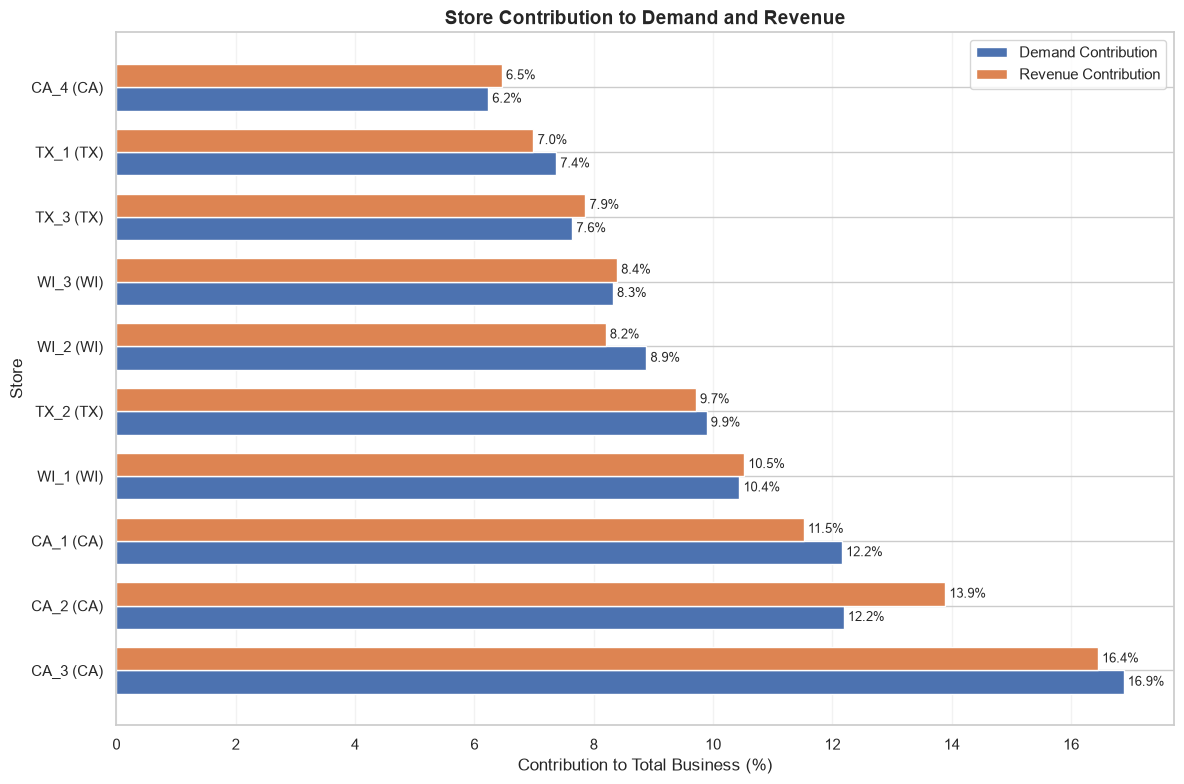

✅ Store contribution figure created successfully.
Demand leader     : CA_3
Revenue leader    : CA_3
Revenue/unit leader: CA_2
Figure path       : C:\Users\hp\Project FORESIGHT\reports\figures\02_12_store_contribution_comparison.png


In [79]:
# Define the store-performance figure path
STORE_PERFORMANCE_FIGURE = (
    FIGURES_DIR / "02_12_store_contribution_comparison.png"
)

# Prepare chart data in demand-rank order
store_chart_data = (
    store_performance_display
    .sort_values("Demand Rank")
    .reset_index(drop=True)
)

store_positions = np.arange(len(store_chart_data))
bar_height = 0.36

# Create the contribution comparison chart
fig, ax = plt.subplots(figsize=(12, 8))

demand_bars = ax.barh(
    store_positions - bar_height / 2,
    store_chart_data["Demand Contribution (%)"],
    height=bar_height,
    label="Demand Contribution",
)

revenue_bars = ax.barh(
    store_positions + bar_height / 2,
    store_chart_data["Revenue Contribution (%)"],
    height=bar_height,
    label="Revenue Contribution",
)

# Add percentage labels to the bars
ax.bar_label(
    demand_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=9,
)

ax.bar_label(
    revenue_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=9,
)

# Add store labels
store_labels = (
    store_chart_data["Store"].astype(str)
    + " ("
    + store_chart_data["State"].astype(str)
    + ")"
)

ax.set_yticks(store_positions)
ax.set_yticklabels(store_labels)

# Keep the highest-ranked store at the top
ax.invert_yaxis()

# Add chart title the highest-ranked store at the top
ax.invert_yaxis()

# Add chart title and axis labels
ax.set_title(
    "Store Contribution to Demand and Revenue",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Contribution to Total Business (%)")
ax.set_ylabel("Store")

# Improve chart readability
ax.legend()
ax.grid(
    axis="x",
    alpha=0.25,
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    STORE_PERFORMANCE_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm successful figure creation
print("✅ Store contribution figure created successfully.")
print(
    "Demand leader     : "
    f"{highest_demand_store['store_id']}"
)
print(
    "Revenue leader    : "
    f"{highest_revenue_store['store_id']}"
)
print(
    "Revenue/unit leader: "
    f"{highest_unit_value_store['store_id']}"
)
print(f"Figure path       : {STORE_PERFORMANCE_FIGURE}")

### Store Performance Summary

- **Demand leader:** CA_3 recorded the highest demand with **96,898 units**, contributing **16.88%** of total units sold.

- **Revenue leader:** CA_3 also generated the highest revenue at **282,961.17**, contributing **16.45%** of total revenue.

- **Highest unit value:** CA_2 recorded the highest average revenue per unit at **3.42**, which explains why its revenue contribution exceeded its demand contribution.

- **Lowest-performing store:** CA_4 recorded the lowest demand at **35,743 units** and the lowest revenue at **111,190.86**.

- **SKU coverage:** Every store contained **30 active SKU series**, so store-level performance differences were not caused by unequal product coverage.

- **Geographic pattern:** California stores occupied the top three positions for demand and revenue, suggesting stronger overall performance in California.

- **Ranking consistency:** Demand and revenue rankings were generally similar, although WI_2 and WI_3 changed positions because of differences in revenue generated per unit.

- **Business implication:** CA_3 should be treated as a high-priority store for stock availability and replenishment. CA_4 requires further investigation into demand, local market conditions, pricing, and product-level performance.

> Estimated margin findings remain assumption-based because actual unit-cost data was unavailable.

✅ Section 8.3: Store Performance is complete.


---

## 8.4 State Performance

State-level demand and revenue will be compared across the available geographic regions.

Differences will be interpreted alongside the number of stores and SKU-store series represented in each state.

In [80]:
# Aggregate store performance by state
state_performance_summary = (
    store_performance_summary
    .groupby("state", as_index=False)
    .agg(
        store_count=("store_id", "nunique"),
        active_sku_series=("active_sku_series", "sum"),
        observed_days=("observed_days", "max"),
        total_units_sold=("total_units_sold", "sum"),
        total_revenue=("total_revenue", "sum"),
        estimated_gross_margin=(
            "estimated_gross_margin",
            "sum",
        ),
    )
)

# Calculate total average daily demand
state_performance_summary["average_daily_demand"] = (
    state_performance_summary["total_units_sold"]
    / state_performance_summary["observed_days"]
)

# Calculate average daily demand per store
state_performance_summary[
    "average_daily_demand_per_store"
] = (
    state_performance_summary["total_units_sold"]
    / (
        state_performance_summary["observed_days"]
        * state_performance_summary["store_count"]
    )
)

# Calculate average revenue per unit
state_performance_summary["average_revenue_per_unit"] = (
    state_performance_summary["total_revenue"]
    / state_performance_summary["total_units_sold"]
)

# Calculate demand contribution
state_performance_summary["demand_contribution_pct"] = (
    state_performance_summary["total_units_sold"]
    / total_units_sold
    * 100
)

# Calculate revenue contribution
state_performance_summary["revenue_contribution_pct"] = (
    state_performance_summary["total_revenue"]
    / total_revenue
    * 100
)

# Rank states by demand
state_performance_summary["demand_rank"] = (
    state_performance_summary["total_units_sold"]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

# Rank states by revenue
state_performance_summary["revenue_rank"] = (
    state_performance_summary["total_revenue"]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

# Arrange states by total demand
state_performance_summary = (
    state_performance_summary
    .sort_values(
        "total_units_sold",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Confirm the prepared state summary
print("State performance summary prepared successfully.")
print(
    f"States analysed        : "
    f"{len(state_performance_summary):,}"
)
print(
    "Stores covered         : "
    f"{state_performance_summary['store_count'].sum():,}"
)
print(
    "SKU series covered     : "
    f"{state_performance_summary['active_sku_series'].sum():,}"
)
print(
    "Total units covered    : "
    f"{state_performance_summary['total_units_sold'].sum():,.0f}"
)
print(
    "Total revenue covered  : "
    f"{state_performance_summary['total_revenue'].sum():,.2f}"
)

State performance summary prepared successfully.
States analysed        : 3
Stores covered         : 10
SKU series covered     : 300
Total units covered    : 573,932
Total revenue covered  : 1,720,316.59


In [81]:
# Calculate total estimated margin across states
total_state_margin = (
    state_performance_summary["estimated_gross_margin"].sum()
)

# Calculate estimated-margin contribution
state_performance_summary["margin_contribution_pct"] = (
    state_performance_summary["estimated_gross_margin"]
    / total_state_margin
    * 100
)

# Check for duplicate states and missing values
duplicate_states = (
    state_performance_summary["state"]
    .duplicated()
    .sum()
)

missing_state_values = (
    state_performance_summary
    .isna()
    .sum()
    .sum()
)

# Validate state coverage
assert len(state_performance_summary) == 3, (
    f"Expected 3 states, found "
    f"{len(state_performance_summary):,}."
)

assert state_performance_summary["store_count"].sum() == 10, (
    "State store counts do not total 10."
)

assert (
    state_performance_summary["active_sku_series"].sum()
    == 300
), "State SKU-series counts do not total 300."

assert duplicate_states == 0, (
    f"Duplicate state records found: "
    f"{duplicate_states:,}."
)

assert missing_state_values == 0, (
    f"Missing state values found: "
    f"{missing_state_values:,}."
)

# Reconcile business totals
assert np.isclose(
    state_performance_summary["total_units_sold"].sum(),
    total_units_sold,
), "State demand totals do not reconcile."

assert np.isclose(
    state_performance_summary["total_revenue"].sum(),
    total_revenue,
), "State revenue totals do not reconcile."

# Validate contribution percentages
for contribution_column in [
    "demand_contribution_pct",
    "revenue_contribution_pct",
    "margin_contribution_pct",
]:
    assert np.isclose(
        state_performance_summary[contribution_column].sum(),
        100,
    ), f"{contribution_column} does not total 100%."

# Identify leading and weakest states
highest_demand_state = state_performance_summary.loc[
    state_performance_summary["total_units_sold"].idxmax()
]

lowest_demand_state = state_performance_summary.loc[
    state_performance_summary["total_units_sold"].idxmin()
]

highest_revenue_state = state_performance_summary.loc[
    state_performance_summary["total_revenue"].idxmax()
]

lowest_revenue_state = state_performance_summary.loc[
    state_performance_summary["total_revenue"].idxmin()
]

highest_demand_per_store_state = state_performance_summary.loc[
    state_performance_summary[
        "average_daily_demand_per_store"
    ].idxmax()
]

# Prepare a concise presentation table
state_performance_display = (
    state_performance_summary[
        [
            "state",
            "store_count",
            "active_sku_series",
            "total_units_sold",
            "average_daily_demand",
            "average_daily_demand_per_store",
            "demand_contribution_pct",
            "total_revenue",
            "average_revenue_per_unit",
            "revenue_contribution_pct",
            "estimated_gross_margin",
            "margin_contribution_pct",
            "demand_rank",
            "revenue_rank",
        ]
    ]
    .copy()
)

state_performance_display.columns = [
    "State",
    "Store Count",
    "Active SKU Series",
    "Total Units Sold",
    "Average Daily Demand",
    "Average Daily Demand per Store",
    "Demand Contribution (%)",
    "Total Revenue",
    "Average Revenue per Unit",
    "Revenue Contribution (%)",
    "Estimated Gross Margin",
    "Margin Contribution (%)",
    "Demand Rank",
    "Revenue Rank",
]

# Round presentation values
state_performance_display = (
    state_performance_display.round(
        {
            "Average Daily Demand": 2,
            "Average Daily Demand per Store": 2,
            "Demand Contribution (%)": 2,
            "Total Revenue": 2,
            "Average Revenue per Unit": 2,
            "Revenue Contribution (%)": 2,
            "Estimated Gross Margin": 2,
            "Margin Contribution (%)": 2,
        }
    )
)

display(state_performance_display)

# Display validation and key findings
print("✅ State performance validation passed.")
print(
    "Highest-demand state     : "
    f"{highest_demand_state['state']} "
    f"({highest_demand_state['total_units_sold']:,.0f} units)"
)
print(
    "Lowest-demand state      : "
    f"{lowest_demand_state['state']} "
    f"({lowest_demand_state['total_units_sold']:,.0f} units)"
)
print(
    "Highest-revenue state    : "
    f"{highest_revenue_state['state']} "
    f"({highest_revenue_state['total_revenue']:,.2f})"
)
print(
    "Lowest-revenue state     : "
    f"{lowest_revenue_state['state']} "
    f"({lowest_revenue_state['total_revenue']:,.2f})"
)
print(
    "Highest demand per store : "
    f"{highest_demand_per_store_state['state']} "
    f"({highest_demand_per_store_state['average_daily_demand_per_store']:,.2f} "
    "units/day/store)"
)

,State,Store Count,Active SKU Series,Total Units Sold,Average Daily Demand,Average Daily Demand per Store,Demand Contribution (%),Total Revenue,Average Revenue per Unit,Revenue Contribution (%),Estimated Gross Margin,Margin Contribution (%),Demand Rank,Revenue Rank
0,CA,4,120,272386,142.39,35.60,47.46,"831,290.51",3.05,48.32,"260,657.44",48.05,1,1
1,WI,3,90,158672,82.94,27.65,27.65,"466,496.25",2.94,27.12,"147,475.57",27.19,2,2
2,TX,3,90,142874,74.69,24.90,24.89,"422,529.83",2.96,24.56,"134,296.17",24.76,3,3


✅ State performance validation passed.
Highest-demand state     : CA (272,386 units)
Lowest-demand state      : TX (142,874 units)
Highest-revenue state    : CA (831,290.51)
Lowest-revenue state     : TX (422,529.83)
Highest demand per store : CA (35.60 units/day/store)


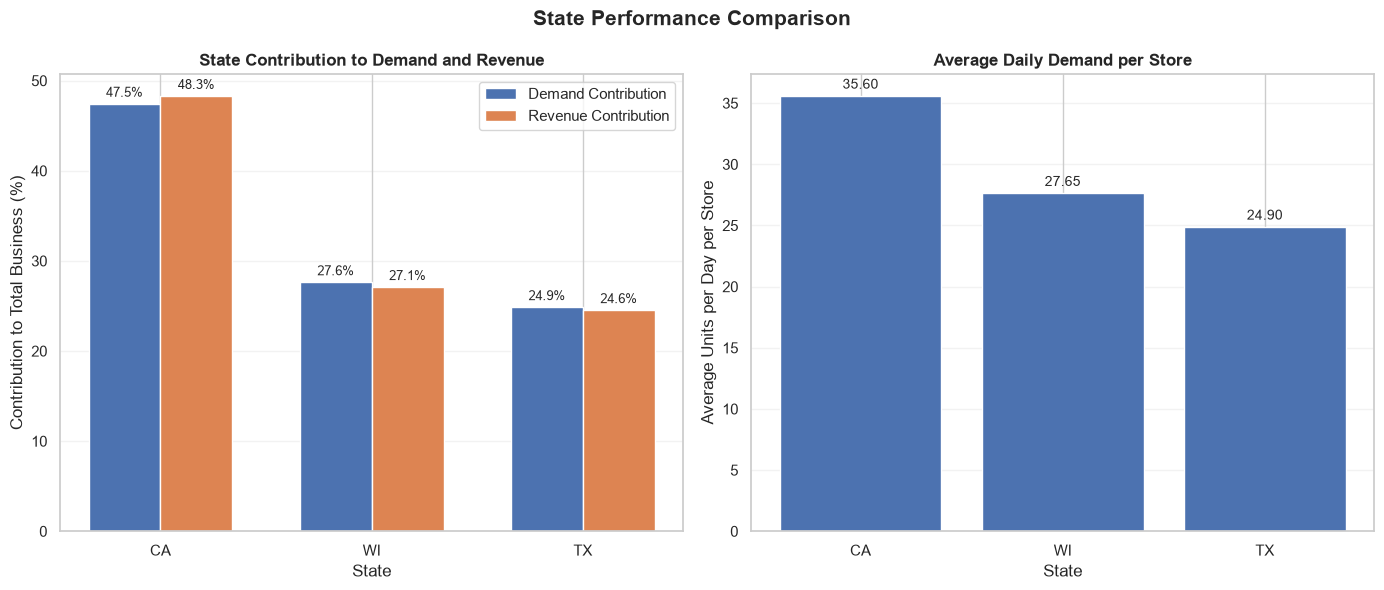

✅ State performance figure created successfully.
Total-demand leader    : CA
Revenue leader         : CA
Demand-per-store leader: CA
Figure path           : C:\Users\hp\Project FORESIGHT\reports\figures\02_13_state_performance_comparison.png


In [82]:
# Define the state-performance figure path
STATE_PERFORMANCE_FIGURE = (
    FIGURES_DIR / "02_13_state_performance_comparison.png"
)

# Prepare chart positions
state_labels = state_performance_display["State"].astype(str)
state_positions = np.arange(len(state_labels))
bar_width = 0.34

# Create total and normalised state comparisons
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

# Plot demand and revenue contribution
demand_bars = axes[0].bar(
    state_positions - bar_width / 2,
    state_performance_display["Demand Contribution (%)"],
    width=bar_width,
    label="Demand Contribution",
)

revenue_bars = axes[0].bar(
    state_positions + bar_width / 2,
    state_performance_display["Revenue Contribution (%)"],
    width=bar_width,
    label="Revenue Contribution",
)

axes[0].bar_label(
    demand_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=9,
)

axes[0].bar_label(
    revenue_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=9,
)

axes[0].set_title(
    "State Contribution to Demand and Revenue",
    fontweight="bold",
)

axes[0].set_xlabel("State")
axes[0].set_ylabel("Contribution to Total Business (%)")
axes[0].set_xticks(state_positions)
axes[0].set_xticklabels(state_labels)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

# Plot average daily demand per store
per_store_bars = axes[1].bar(
    state_labels,
    state_performance_display[
        "Average Daily Demand per Store"
    ],
)

axes[1].bar_label(
    per_store_bars,
    fmt="%.2f",
    padding=3,
    fontsize=10,
)

axes[1].set_title(
    "Average Daily Demand per Store",
    fontweight="bold",
)

axes[1].set_xlabel("State")
axes[1].set_ylabel("Average Units per Day per Store")
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle(
    "State Performance Comparison",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    STATE_PERFORMANCE_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm figure creation
print("✅ State performance figure created successfully.")
print(
    "Total-demand leader    : "
    f"{highest_demand_state['state']}"
)
print(
    "Revenue leader         : "
    f"{highest_revenue_state['state']}"
)
print(
    "Demand-per-store leader: "
    f"{highest_demand_per_store_state['state']}"
)
print(f"Figure path           : {STATE_PERFORMANCE_FIGURE}")

### State Performance Summary

- **Overall leader:** California contributed **47.46% of total demand** and **48.32% of total revenue**.

- **Highest store productivity:** California also recorded the highest average daily demand per store at **35.60 units**.

- **Second position:** Wisconsin contributed **27.65% of demand** and **27.12% of revenue**, with **27.65 units per day per store**.

- **Lowest performance:** Texas contributed **24.89% of demand** and **24.56% of revenue**, with the lowest store-level demand at **24.90 units per day**.

- **Revenue efficiency:** Average revenue per unit was similar across states, ranging from **2.94 to 3.05**, so demand volume is the main driver of state-level revenue differences.

- **Key insight:** California’s leadership is not explained only by having more stores; its stores also perform better individually.

- **Business implication:** Maintain strong stock availability in California, investigate successful CA store practices, and review demand-generation opportunities in Texas.

> Estimated margin values remain assumption-based because actual unit-cost data was unavailable.

✅ Section 8.4: State Performance is complete.

---

## 8.5 Product Performance

Individual products will be evaluated using:

- total demand;
- total revenue;
- average selling price;
- active selling days;
- average daily demand;
- estimated financial contribution.

This analysis will identify products that contribute strongly or weakly to overall performance.

In [83]:
# Prepare the product-level analytical source
product_performance_source = analytics_base_daily.copy()

# Identify the available product column
product_candidates = [
    "item_id",
    "product_id",
    "product",
    "item",
]

product_field = next(
    (
        column
        for column in product_candidates
        if column in product_performance_source.columns
    ),
    None,
)

if product_field is None:
    raise KeyError(
        "No product identifier column was found. "
        f"Checked: {product_candidates}"
    )

# Calculate estimated margin for each record
product_performance_source["estimated_margin_value"] = (
    product_performance_source["units_sold"]
    * product_performance_source["estimated_gross_margin"]
)

# Mark days on which the product recorded positive sales
product_performance_source["is_active_selling_day"] = (
    product_performance_source["units_sold"] > 0
)

# Aggregate performance by product
product_performance_summary = (
    product_performance_source
    .groupby(product_field, as_index=False)
    .agg(
        category=("category", "first"),
        department=("department", "first"),
        store_count=("store_id", "nunique"),
        sku_store_series=("sku_id", "nunique"),
        observed_days=("date", "nunique"),
        active_selling_days=(
            "is_active_selling_day",
            "sum",
        ),
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        estimated_gross_margin=(
            "estimated_margin_value",
            "sum",
        ),
    )
    .rename(columns={product_field: "product_id"})
)

# Calculate average daily demand
product_performance_summary["average_daily_demand"] = (
    product_performance_summary["total_units_sold"]
    / product_performance_summary["observed_days"]
)

# Calculate average selling price
product_performance_summary["average_selling_price"] = (
    product_performance_summary["total_revenue"]
    / product_performance_summary["total_units_sold"]
)

# Calculate selling-day frequency
product_performance_summary["selling_day_frequency_pct"] = (
    product_performance_summary["active_selling_days"]
    / product_performance_summary["observed_days"]
    * 100
)

# Calculate demand and revenue contributions
product_performance_summary["demand_contribution_pct"] = (
    product_performance_summary["total_units_sold"]
    / total_units_sold
    * 100
)

product_performance_summary["revenue_contribution_pct"] = (
    product_performance_summary["total_revenue"]
    / total_revenue
    * 100
)

# Rank products by demand and revenue
product_performance_summary["demand_rank"] = (
    product_performance_summary["total_units_sold"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

product_performance_summary["revenue_rank"] = (
    product_performance_summary["total_revenue"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Arrange products by total demand
product_performance_summary = (
    product_performance_summary
    .sort_values(
        "total_units_sold",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Confirm the prepared product summary
print("Product performance summary prepared successfully.")
print(f"Product field used     : {product_field}")
print(
    f"Products analysed      : "
    f"{len(product_performance_summary):,}"
)
print(
    "Stores represented     : "
    f"{product_performance_summary['store_count'].max():,}"
)
print(
    "Total units covered    : "
    f"{product_performance_summary['total_units_sold'].sum():,.0f}"
)
print(
    "Total revenue covered  : "
    f"{product_performance_summary['total_revenue'].sum():,.2f}"
)

Product performance summary prepared successfully.
Product field used     : item_id
Products analysed      : 30
Stores represented     : 10
Total units covered    : 573,932
Total revenue covered  : 1,720,316.59


In [84]:
# Aggregate product demand across stores for each calendar day
product_daily_activity = (
    product_performance_source
    .groupby(
        [product_field, "date"],
        as_index=False,
    )
    .agg(
        product_daily_units=("units_sold", "sum"),
    )
)

# Mark calendar days with positive product demand
product_daily_activity["is_active_selling_day"] = (
    product_daily_activity["product_daily_units"] > 0
)

# Count active calendar days for each product
product_active_days = (
    product_daily_activity
    .groupby(product_field, as_index=False)
    .agg(
        corrected_active_selling_days=(
            "is_active_selling_day",
            "sum",
        ),
        observed_days_check=("date", "nunique"),
    )
    .rename(columns={product_field: "product_id"})
)

# Replace the earlier store-day count
product_performance_summary = (
    product_performance_summary
    .drop(columns=["active_selling_days"])
    .merge(
        product_active_days,
        on="product_id",
        how="left",
        validate="one_to_one",
    )
    .rename(
        columns={
            "corrected_active_selling_days":
                "active_selling_days"
        }
    )
)

# Confirm observed-day consistency
assert (
    product_performance_summary["observed_days"]
    == product_performance_summary["observed_days_check"]
).all(), "Product observed-day counts do not match."

# Recalculate selling-day frequency
product_performance_summary["selling_day_frequency_pct"] = (
    product_performance_summary["active_selling_days"]
    / product_performance_summary["observed_days"]
    * 100
)

# Remove the temporary validation field
product_performance_summary = (
    product_performance_summary
    .drop(columns=["observed_days_check"])
)

# Validate the corrected frequency
assert (
    product_performance_summary["selling_day_frequency_pct"]
    .between(0, 100)
    .all()
), "Selling-day frequency must remain between 0% and 100%."

print("✅ Product selling-day activity corrected successfully.")
print(
    "Minimum selling-day frequency : "
    f"{product_performance_summary['selling_day_frequency_pct'].min():,.2f}%"
)
print(
    "Maximum selling-day frequency : "
    f"{product_performance_summary['selling_day_frequency_pct'].max():,.2f}%"
)

✅ Product selling-day activity corrected successfully.
Minimum selling-day frequency : 31.21%
Maximum selling-day frequency : 99.48%


In [85]:
# Calculate total estimated margin across products
total_product_margin = (
    product_performance_summary["estimated_gross_margin"].sum()
)

# Calculate estimated-margin contribution
product_performance_summary["margin_contribution_pct"] = (
    product_performance_summary["estimated_gross_margin"]
    / total_product_margin
    * 100
)

# Check product-summary quality
duplicate_products = (
    product_performance_summary["product_id"]
    .duplicated()
    .sum()
)

missing_product_values = (
    product_performance_summary
    .isna()
    .sum()
    .sum()
)

# Validate product coverage
assert len(product_performance_summary) == 30, (
    f"Expected 30 products, "
    f"found {len(product_performance_summary):,}."
)

assert duplicate_products == 0, (
    f"Duplicate product records found: "
    f"{duplicate_products:,}."
)

assert missing_product_values == 0, (
    f"Missing product values found: "
    f"{missing_product_values:,}."
)

assert (
    product_performance_summary["total_units_sold"] > 0
).all(), "A product contains zero total demand."

assert (
    product_performance_summary["active_selling_days"]
    <= product_performance_summary["observed_days"]
).all(), "Active selling days exceed observed days."

assert (
    product_performance_summary["selling_day_frequency_pct"]
    .between(0, 100)
    .all()
), "Selling-day frequency must remain between 0% and 100%."

# Reconcile demand, revenue, and margin totals
assert np.isclose(
    product_performance_summary["total_units_sold"].sum(),
    total_units_sold,
), "Product demand totals do not reconcile."

assert np.isclose(
    product_performance_summary["total_revenue"].sum(),
    total_revenue,
), "Product revenue totals do not reconcile."

assert np.isclose(
    product_performance_summary[
        "estimated_gross_margin"
    ].sum(),
    total_product_margin,
), "Product margin totals do not reconcile."

# Validate contribution percentages
for contribution_column in [
    "demand_contribution_pct",
    "revenue_contribution_pct",
    "margin_contribution_pct",
]:
    assert np.isclose(
        product_performance_summary[
            contribution_column
        ].sum(),
        100,
    ), f"{contribution_column} does not total 100%."

# Identify key product-performance leaders
highest_demand_product = product_performance_summary.loc[
    product_performance_summary["total_units_sold"].idxmax()
]

lowest_demand_product = product_performance_summary.loc[
    product_performance_summary["total_units_sold"].idxmin()
]

highest_revenue_product = product_performance_summary.loc[
    product_performance_summary["total_revenue"].idxmax()
]

lowest_revenue_product = product_performance_summary.loc[
    product_performance_summary["total_revenue"].idxmin()
]

highest_price_product = product_performance_summary.loc[
    product_performance_summary[
        "average_selling_price"
    ].idxmax()
]

highest_frequency_product = product_performance_summary.loc[
    product_performance_summary[
        "selling_day_frequency_pct"
    ].idxmax()
]

lowest_frequency_product = product_performance_summary.loc[
    product_performance_summary[
        "selling_day_frequency_pct"
    ].idxmin()
]

# Prepare the product-ranking table
product_performance_display = (
    product_performance_summary[
        [
            "product_id",
            "category",
            "department",
            "store_count",
            "total_units_sold",
            "average_daily_demand",
            "active_selling_days",
            "selling_day_frequency_pct",
            "total_revenue",
            "average_selling_price",
            "revenue_contribution_pct",
            "estimated_gross_margin",
            "margin_contribution_pct",
            "demand_rank",
            "revenue_rank",
        ]
    ]
    .copy()
)

# Rename fields for presentation
product_performance_display.columns = [
    "Product",
    "Category",
    "Department",
    "Store Count",
    "Total Units Sold",
    "Average Daily Demand",
    "Active Selling Days",
    "Selling-Day Frequency (%)",
    "Total Revenue",
    "Average Selling Price",
    "Revenue Contribution (%)",
    "Estimated Gross Margin",
    "Margin Contribution (%)",
    "Demand Rank",
    "Revenue Rank",
]

# Round presentation values
product_performance_display = (
    product_performance_display.round(
        {
            "Average Daily Demand": 2,
            "Selling-Day Frequency (%)": 2,
            "Total Revenue": 2,
            "Average Selling Price": 2,
            "Revenue Contribution (%)": 2,
            "Estimated Gross Margin": 2,
            "Margin Contribution (%)": 2,
        }
    )
)

# Display the ten highest-demand products
display(product_performance_display.head(10))

# Display validation and key findings
print("✅ Product performance validation passed.")

print(
    "Highest-demand product   : "
    f"{highest_demand_product['product_id']} "
    f"({highest_demand_product['total_units_sold']:,.0f} units)"
)

print(
    "Lowest-demand product    : "
    f"{lowest_demand_product['product_id']} "
    f"({lowest_demand_product['total_units_sold']:,.0f} units)"
)

print(
    "Highest-revenue product  : "
    f"{highest_revenue_product['product_id']} "
    f"({highest_revenue_product['total_revenue']:,.2f})"
)

print(
    "Lowest-revenue product   : "
    f"{lowest_revenue_product['product_id']} "
    f"({lowest_revenue_product['total_revenue']:,.2f})"
)

print(
    "Highest-priced product   : "
    f"{highest_price_product['product_id']} "
    f"({highest_price_product['average_selling_price']:,.2f})"
)

print(
    "Highest selling frequency: "
    f"{highest_frequency_product['product_id']} "
    f"({highest_frequency_product['selling_day_frequency_pct']:,.2f}%)"
)

print(
    "Lowest selling frequency : "
    f"{lowest_frequency_product['product_id']} "
    f"({lowest_frequency_product['selling_day_frequency_pct']:,.2f}%)"
)

,Product,Category,Department,Store Count,Total Units Sold,Average Daily Demand,Active Selling Days,Selling-Day Frequency (%),Total Revenue,Average Selling Price,Revenue Contribution (%),Estimated Gross Margin,Margin Contribution (%),Demand Rank,Revenue Rank
0,FOODS_1_004,FOODS,FOODS_1,10,129481,67.68,1366,71.41,"235,998.02",1.82,13.72,"76,393.79",14.08,1,1
1,HOBBIES_1_008,HOBBIES,HOBBIES_1,10,87645,45.82,1711,89.44,"41,573.46",0.47,2.42,"13,146.75",2.42,2,15
2,HOBBIES_1_004,HOBBIES,HOBBIES_1,10,39175,20.48,1900,99.32,"176,967.84",4.52,10.29,"54,453.25",10.04,3,3
3,HOUSEHOLD_1_007,HOUSEHOLD,HOUSEHOLD_1,10,36078,18.86,1700,88.87,"54,163.44",1.50,3.15,"16,500.60",3.04,4,10
4,HOUSEHOLD_1_004,HOUSEHOLD,HOUSEHOLD_1,10,31060,16.24,1719,89.86,"69,724.06",2.24,4.05,"22,052.60",4.07,5,7
5,FOODS_1_005,FOODS,FOODS_1,10,22914,11.98,1467,76.69,"76,448.78",3.34,4.44,"24,288.84",4.48,6,6
6,FOODS_1_006,FOODS,FOODS_1,10,22320,11.67,1903,99.48,"49,012.57",2.20,2.85,"16,516.80",3.04,7,12
7,HOUSEHOLD_1_005,HOUSEHOLD,HOUSEHOLD_1,10,18066,9.44,1658,86.67,"181,181.03",10.03,10.53,"57,343.14",10.57,8,2
8,HOBBIES_1_009,HOBBIES,HOBBIES_1,10,15657,8.18,1871,97.80,"27,002.52",1.72,1.57,"8,181.81",1.51,9,21
9,HOUSEHOLD_1_006,HOUSEHOLD,HOUSEHOLD_1,10,14632,7.65,1588,83.01,"101,747.92",6.95,5.91,"30,580.88",5.64,10,4


✅ Product performance validation passed.
Highest-demand product   : FOODS_1_004 (129,481 units)
Lowest-demand product    : HOBBIES_1_003 (1,435 units)
Highest-revenue product  : FOODS_1_004 (235,998.02)
Lowest-revenue product   : HOBBIES_1_003 (4,252.89)
Highest-priced product   : HOUSEHOLD_1_009 (17.97)
Highest selling frequency: FOODS_1_006 (99.48%)
Lowest selling frequency : HOBBIES_1_003 (31.21%)


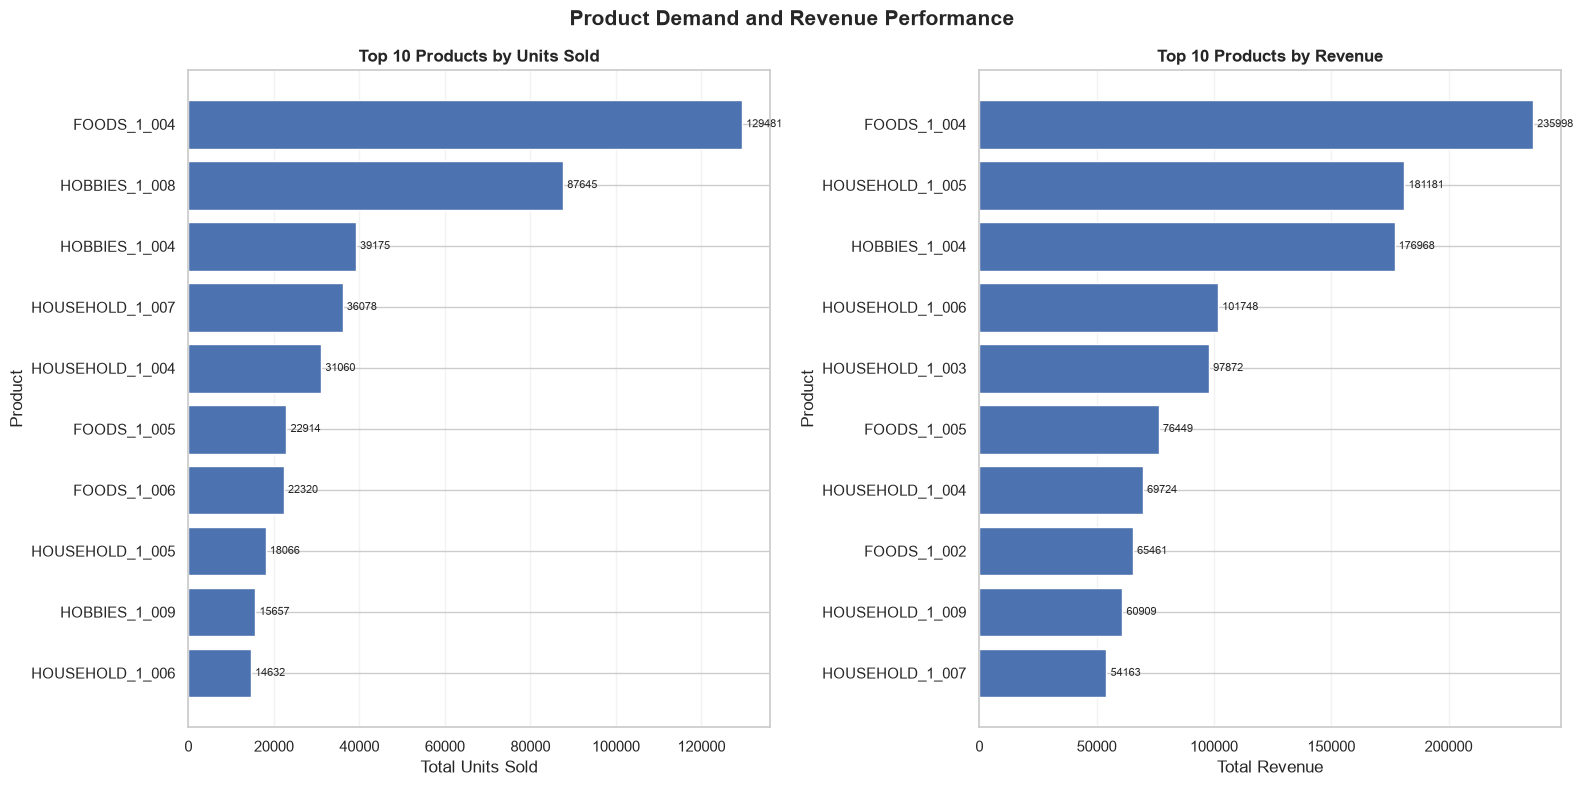

✅ Product performance figure created successfully.
Demand leader  : FOODS_1_004
Revenue leader : FOODS_1_004
Figure path    : C:\Users\hp\Project FORESIGHT\reports\figures\02_14_top_product_performance.png


In [86]:
# Define the product-performance figure path
PRODUCT_PERFORMANCE_FIGURE = (
    FIGURES_DIR / "02_14_top_product_performance.png"
)

# Select the ten leading products by demand
top_demand_products = (
    product_performance_summary
    .nlargest(10, "total_units_sold")
    .sort_values("total_units_sold")
)

# Select the ten leading products by revenue
top_revenue_products = (
    product_performance_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

# Create demand and revenue ranking charts
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8),
)

# Plot the top products by demand
demand_bars = axes[0].barh(
    top_demand_products["product_id"],
    top_demand_products["total_units_sold"],
)

axes[0].bar_label(
    demand_bars,
    fmt="%.0f",
    padding=3,
    fontsize=8,
)

axes[0].set_title(
    "Top 10 Products by Units Sold",
    fontweight="bold",
)

axes[0].set_xlabel("Total Units Sold")
axes[0].set_ylabel("Product")
axes[0].grid(axis="x", alpha=0.25)

# Plot the top products by revenue
revenue_bars = axes[1].barh(
    top_revenue_products["product_id"],
    top_revenue_products["total_revenue"],
)

axes[1].bar_label(
    revenue_bars,
    fmt="%.0f",
    padding=3,
    fontsize=8,
)

axes[1].set_title(
    "Top 10 Products by Revenue",
    fontweight="bold",
)

axes[1].set_xlabel("Total Revenue")
axes[1].set_ylabel("Product")
axes[1].grid(axis="x", alpha=0.25)

# Add the overall figure title
fig.suptitle(
    "Product Demand and Revenue Performance",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    PRODUCT_PERFORMANCE_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm successful figure creation
print("✅ Product performance figure created successfully.")
print(
    "Demand leader  : "
    f"{highest_demand_product['product_id']}"
)
print(
    "Revenue leader : "
    f"{highest_revenue_product['product_id']}"
)
print(f"Figure path    : {PRODUCT_PERFORMANCE_FIGURE}")

### Product Performance Summary

- **Overall leader:** FOODS_1_004 ranked first in both demand and revenue, with **129,481 units sold** and **235,998.02 in revenue**.

- **Demand concentration:** FOODS_1_004 alone contributed approximately **22.6% of total units sold**, indicating substantial dependence on one product.

- **Volume–value difference:** HOBBIES_1_008 ranked second in demand with **87,645 units**, but its low average selling price of **0.47** limited its financial contribution.

- **High-value product:** HOUSEHOLD_1_005 ranked only eighth in demand but second in revenue because of its higher average selling price of **10.03**.

- **Highest price:** HOUSEHOLD_1_009 recorded the highest average selling price at **17.97**.

- **Most consistent seller:** FOODS_1_006 recorded demand on **99.48% of observed days**.

- **Weakest product:** HOBBIES_1_003 recorded the lowest demand, revenue, and selling frequency, with only **1,435 units sold** and activity on **31.21% of days**.

- **Business implication:** Protect availability for FOODS_1_004, distinguish high-volume products from high-value products, and investigate HOBBIES_1_003 for possible repositioning, reduced inventory, or discontinuation.

> Estimated margin results remain assumption-based because actual product-cost data was unavailable.

✅ Section 8.5: Product Performance is complete.

---

## 8.6 SKU-Store Performance

Performance will also be examined at the SKU-store level, which is the core analytical grain used throughout Project FORESIGHT.

This helps distinguish whether a product performs consistently across stores or depends heavily on particular locations.

In [87]:
# Prepare the SKU-store analytical source
sku_store_performance_source = analytics_base_daily.copy()

# Identify the available state column
if "state" in sku_store_performance_source.columns:
    sku_state_field = "state"
elif "state_id" in sku_store_performance_source.columns:
    sku_state_field = "state_id"
else:
    raise KeyError("No state column was found.")

# Calculate record-level estimated margin
sku_store_performance_source["estimated_margin_value"] = (
    sku_store_performance_source["units_sold"]
    * sku_store_performance_source["estimated_gross_margin"]
)

# Mark days with positive sales
sku_store_performance_source["is_active_selling_day"] = (
    sku_store_performance_source["units_sold"] > 0
)

# Aggregate performance at the SKU-store grain
sku_store_performance_summary = (
    sku_store_performance_source
    .groupby("sku_id", as_index=False)
    .agg(
        product_id=(product_field, "first"),
        store_id=("store_id", "first"),
        state=(sku_state_field, "first"),
        category=("category", "first"),
        department=("department", "first"),
        observed_days=("date", "nunique"),
        active_selling_days=("is_active_selling_day", "sum"),
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        estimated_gross_margin=(
            "estimated_margin_value",
            "sum",
        ),
    )
)

# Calculate average daily demand
sku_store_performance_summary["average_daily_demand"] = (
    sku_store_performance_summary["total_units_sold"]
    / sku_store_performance_summary["observed_days"]
)

# Calculate average selling price
sku_store_performance_summary["average_selling_price"] = (
    sku_store_performance_summary["total_revenue"]
    / sku_store_performance_summary["total_units_sold"]
)

# Calculate selling-day frequency
sku_store_performance_summary["selling_day_frequency_pct"] = (
    sku_store_performance_summary["active_selling_days"]
    / sku_store_performance_summary["observed_days"]
    * 100
)

# Calculate business contribution percentages
sku_store_performance_summary["demand_contribution_pct"] = (
    sku_store_performance_summary["total_units_sold"]
    / total_units_sold
    * 100
)

sku_store_performance_summary["revenue_contribution_pct"] = (
    sku_store_performance_summary["total_revenue"]
    / total_revenue
    * 100
)

# Rank SKU-store series by demand
sku_store_performance_summary["demand_rank"] = (
    sku_store_performance_summary["total_units_sold"]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

# Rank SKU-store series by revenue
sku_store_performance_summary["revenue_rank"] = (
    sku_store_performance_summary["total_revenue"]
    .rank(
        method="dense",
        ascending=False,
    )
    .astype(int)
)

# Arrange SKU-store series by total demand
sku_store_performance_summary = (
    sku_store_performance_summary
    .sort_values(
        "total_units_sold",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Confirm the prepared summary
print("SKU-store performance summary prepared successfully.")
print(f"State field used          : {sku_state_field}")
print(
    "SKU-store series analysed: "
    f"{len(sku_store_performance_summary):,}"
)
print(
    "Products represented     : "
    f"{sku_store_performance_summary['product_id'].nunique():,}"
)
print(
    "Stores represented       : "
    f"{sku_store_performance_summary['store_id'].nunique():,}"
)
print(
    "Total units covered      : "
    f"{sku_store_performance_summary['total_units_sold'].sum():,.0f}"
)
print(
    "Total revenue covered    : "
    f"{sku_store_performance_summary['total_revenue'].sum():,.2f}"
)

SKU-store performance summary prepared successfully.
State field used          : state_id
SKU-store series analysed: 300
Products represented     : 30
Stores represented       : 10
Total units covered      : 573,932
Total revenue covered    : 1,720,316.59


In [88]:
# Calculate total estimated margin
total_sku_store_margin = (
    sku_store_performance_summary[
        "estimated_gross_margin"
    ].sum()
)

# Calculate estimated-margin contribution
sku_store_performance_summary[
    "margin_contribution_pct"
] = (
    sku_store_performance_summary[
        "estimated_gross_margin"
    ]
    / total_sku_store_margin
    * 100
)

# Check summary quality
duplicate_sku_series = (
    sku_store_performance_summary["sku_id"]
    .duplicated()
    .sum()
)

duplicate_product_store_pairs = (
    sku_store_performance_summary[
        ["product_id", "store_id"]
    ]
    .duplicated()
    .sum()
)

missing_sku_store_values = (
    sku_store_performance_summary
    .isna()
    .sum()
    .sum()
)

# Validate analytical coverage
assert len(sku_store_performance_summary) == 300, (
    f"Expected 300 SKU-store series, found "
    f"{len(sku_store_performance_summary):,}."
)

assert duplicate_sku_series == 0, (
    f"Duplicate SKU identifiers found: "
    f"{duplicate_sku_series:,}."
)

assert duplicate_product_store_pairs == 0, (
    f"Duplicate product-store pairs found: "
    f"{duplicate_product_store_pairs:,}."
)

assert (
    sku_store_performance_summary[
        "product_id"
    ].nunique()
    == 30
), "Expected 30 products."

assert (
    sku_store_performance_summary[
        "store_id"
    ].nunique()
    == 10
), "Expected 10 stores."

assert missing_sku_store_values == 0, (
    f"Missing values found: "
    f"{missing_sku_store_values:,}."
)

assert (
    sku_store_performance_summary[
        "total_units_sold"
    ] > 0
).all(), "A SKU-store series contains zero demand."

assert (
    sku_store_performance_summary[
        "active_selling_days"
    ]
    <= sku_store_performance_summary[
        "observed_days"
    ]
).all(), "Active selling days exceed observed days."

assert (
    sku_store_performance_summary[
        "selling_day_frequency_pct"
    ]
    .between(0, 100)
    .all()
), "Selling-day frequency must remain between 0% and 100%."

# Reconcile business totals
assert np.isclose(
    sku_store_performance_summary[
        "total_units_sold"
    ].sum(),
    total_units_sold,
), "SKU-store demand totals do not reconcile."

assert np.isclose(
    sku_store_performance_summary[
        "total_revenue"
    ].sum(),
    total_revenue,
), "SKU-store revenue totals do not reconcile."

# Validate contribution percentages
for contribution_column in [
    "demand_contribution_pct",
    "revenue_contribution_pct",
    "margin_contribution_pct",
]:
    assert np.isclose(
        sku_store_performance_summary[
            contribution_column
        ].sum(),
        100,
    ), f"{contribution_column} does not total 100%."

# Identify leading and weakest SKU-store series
highest_demand_sku_store = (
    sku_store_performance_summary.loc[
        sku_store_performance_summary[
            "total_units_sold"
        ].idxmax()
    ]
)

lowest_demand_sku_store = (
    sku_store_performance_summary.loc[
        sku_store_performance_summary[
            "total_units_sold"
        ].idxmin()
    ]
)

highest_revenue_sku_store = (
    sku_store_performance_summary.loc[
        sku_store_performance_summary[
            "total_revenue"
        ].idxmax()
    ]
)

lowest_revenue_sku_store = (
    sku_store_performance_summary.loc[
        sku_store_performance_summary[
            "total_revenue"
        ].idxmin()
    ]
)

highest_frequency_sku_store = (
    sku_store_performance_summary.loc[
        sku_store_performance_summary[
            "selling_day_frequency_pct"
        ].idxmax()
    ]
)

lowest_frequency_sku_store = (
    sku_store_performance_summary.loc[
        sku_store_performance_summary[
            "selling_day_frequency_pct"
        ].idxmin()
    ]
)

# Prepare a concise presentation table
sku_store_performance_display = (
    sku_store_performance_summary[
        [
            "sku_id",
            "product_id",
            "store_id",
            "state",
            "category",
            "total_units_sold",
            "average_daily_demand",
            "active_selling_days",
            "selling_day_frequency_pct",
            "total_revenue",
            "average_selling_price",
            "revenue_contribution_pct",
            "estimated_gross_margin",
            "margin_contribution_pct",
            "demand_rank",
            "revenue_rank",
        ]
    ]
    .copy()
)

sku_store_performance_display.columns = [
    "SKU-Store Series",
    "Product",
    "Store",
    "State",
    "Category",
    "Total Units Sold",
    "Average Daily Demand",
    "Active Selling Days",
    "Selling-Day Frequency (%)",
    "Total Revenue",
    "Average Selling Price",
    "Revenue Contribution (%)",
    "Estimated Gross Margin",
    "Margin Contribution (%)",
    "Demand Rank",
    "Revenue Rank",
]

# Round presentation values
sku_store_performance_display = (
    sku_store_performance_display.round(
        {
            "Average Daily Demand": 2,
            "Selling-Day Frequency (%)": 2,
            "Total Revenue": 2,
            "Average Selling Price": 2,
            "Revenue Contribution (%)": 2,
            "Estimated Gross Margin": 2,
            "Margin Contribution (%)": 2,
        }
    )
)

# Display the ten highest-demand series
display(sku_store_performance_display.head(10))

# Display validation and key findings
print("✅ SKU-store performance validation passed.")

print(
    "Highest-demand series   : "
    f"{highest_demand_sku_store['sku_id']} "
    f"({highest_demand_sku_store['total_units_sold']:,.0f} units)"
)

print(
    "Lowest-demand series    : "
    f"{lowest_demand_sku_store['sku_id']} "
    f"({lowest_demand_sku_store['total_units_sold']:,.0f} units)"
)

print(
    "Highest-revenue series  : "
    f"{highest_revenue_sku_store['sku_id']} "
    f"({highest_revenue_sku_store['total_revenue']:,.2f})"
)

print(
    "Lowest-revenue series   : "
    f"{lowest_revenue_sku_store['sku_id']} "
    f"({lowest_revenue_sku_store['total_revenue']:,.2f})"
)

print(
    "Highest selling frequency: "
    f"{highest_frequency_sku_store['sku_id']} "
    f"({highest_frequency_sku_store['selling_day_frequency_pct']:,.2f}%)"
)

print(
    "Lowest selling frequency : "
    f"{lowest_frequency_sku_store['sku_id']} "
    f"({lowest_frequency_sku_store['selling_day_frequency_pct']:,.2f}%)"
)

,SKU-Store Series,Product,Store,State,Category,Total Units Sold,Average Daily Demand,Active Selling Days,Selling-Day Frequency (%),Total Revenue,Average Selling Price,Revenue Contribution (%),Estimated Gross Margin,Margin Contribution (%),Demand Rank,Revenue Rank
0,FOODS_1_004_WI_2,FOODS_1_004,WI_2,WI,FOODS,18709,9.78,1255,65.60,"34,075.34",1.82,1.98,"11,038.31",2.03,1,2
1,FOODS_1_004_CA_3,FOODS_1_004,CA_3,CA,FOODS,17508,9.15,1222,63.88,"31,910.80",1.82,1.85,"10,329.72",1.90,2,4
2,HOBBIES_1_008_CA_3,HOBBIES_1_008,CA_3,CA,HOBBIES,16671,8.71,1339,69.99,"7,946.68",0.48,0.46,"2,500.65",0.46,3,54
3,FOODS_1_004_CA_1,FOODS_1_004,CA_1,CA,FOODS,15797,8.26,1297,67.80,"28,995.06",1.84,1.69,"9,320.23",1.72,4,6
4,HOBBIES_1_008_CA_1,HOBBIES_1_008,CA_1,CA,HOBBIES,13830,7.23,1378,72.03,"6,564.08",0.47,0.38,"2,074.50",0.38,5,73
5,FOODS_1_004_WI_1,FOODS_1_004,WI_1,WI,FOODS,13447,7.03,1269,66.34,"24,649.08",1.83,1.43,"7,933.73",1.46,6,7
6,FOODS_1_004_WI_3,FOODS_1_004,WI_3,WI,FOODS,13422,7.02,1249,65.29,"24,299.50",1.81,1.41,"7,918.98",1.46,7,8
7,FOODS_1_004_TX_2,FOODS_1_004,TX_2,TX,FOODS,13020,6.81,1217,63.62,"23,366.44",1.79,1.36,"7,681.80",1.42,8,10
8,FOODS_1_004_TX_3,FOODS_1_004,TX_3,TX,FOODS,12464,6.52,1309,68.43,"22,977.74",1.84,1.34,"7,353.76",1.36,9,12
9,FOODS_1_004_TX_1,FOODS_1_004,TX_1,TX,FOODS,10798,5.64,1323,69.16,"19,763.40",1.83,1.15,"6,370.82",1.17,10,16


✅ SKU-store performance validation passed.
Highest-demand series   : FOODS_1_004_WI_2 (18,709 units)
Lowest-demand series    : HOBBIES_1_006_CA_4 (25 units)
Highest-revenue series  : HOBBIES_1_004_CA_3 (47,635.78)
Lowest-revenue series   : HOBBIES_1_006_CA_4 (24.32)
Highest selling frequency: HOBBIES_1_004_CA_3 (86.30%)
Lowest selling frequency : HOBBIES_1_006_CA_4 (1.05%)


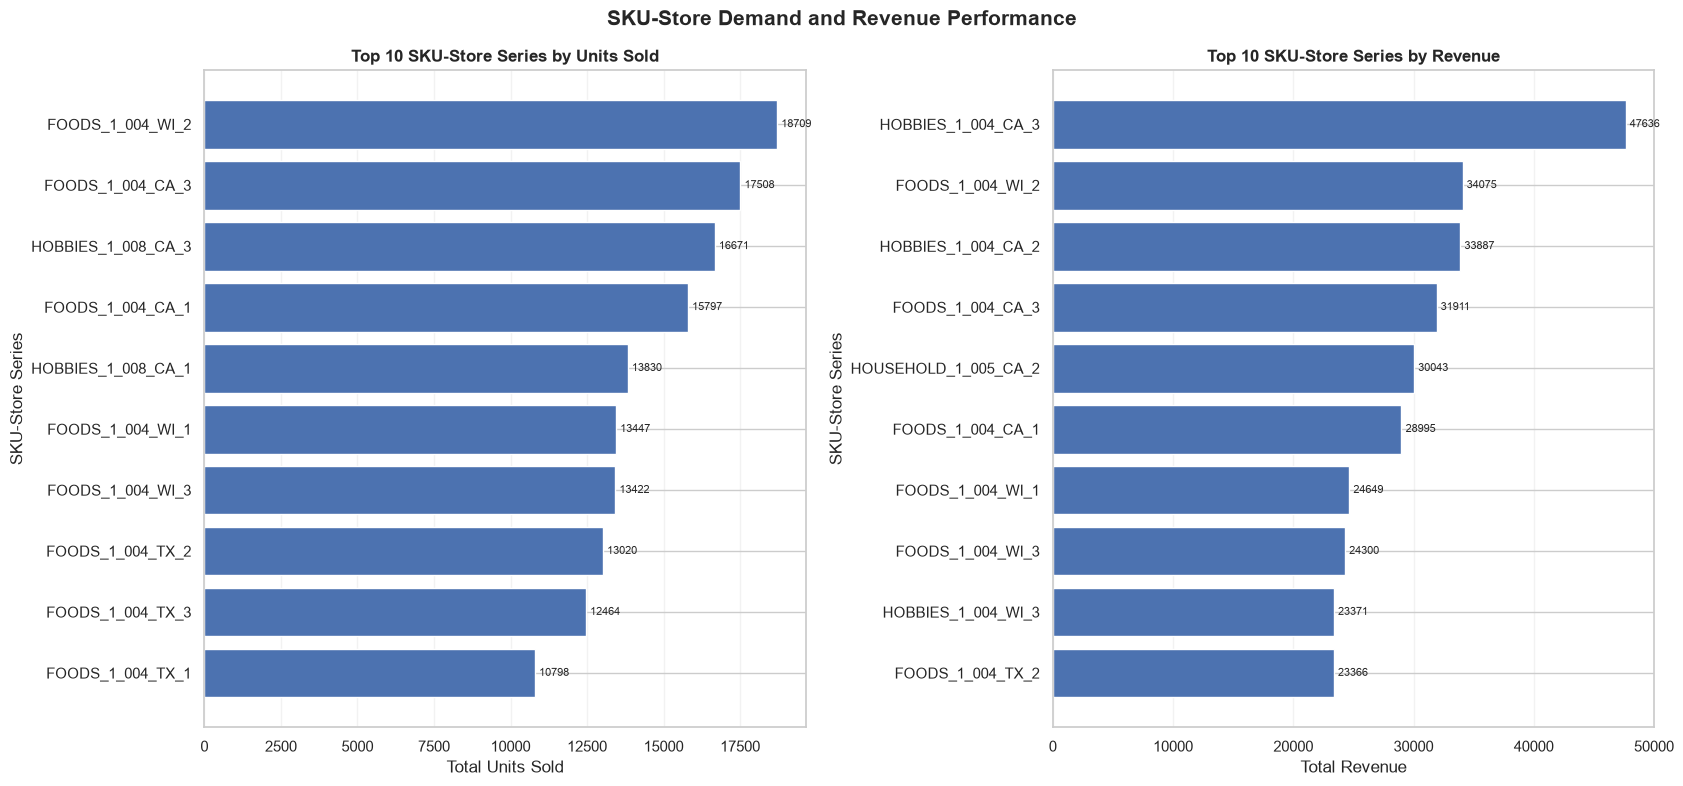

✅ SKU-store performance figure created successfully.
Demand leader  : FOODS_1_004_WI_2
Revenue leader : HOBBIES_1_004_CA_3
Figure path    : C:\Users\hp\Project FORESIGHT\reports\figures\02_15_top_sku_store_performance.png


In [89]:
# Define the SKU-store performance figure path
SKU_STORE_PERFORMANCE_FIGURE = (
    FIGURES_DIR / "02_15_top_sku_store_performance.png"
)

# Select the ten highest-demand SKU-store series
top_demand_sku_stores = (
    sku_store_performance_summary
    .nlargest(10, "total_units_sold")
    .sort_values("total_units_sold")
)

# Select the ten highest-revenue SKU-store series
top_revenue_sku_stores = (
    sku_store_performance_summary
    .nlargest(10, "total_revenue")
    .sort_values("total_revenue")
)

# Create demand and revenue ranking charts
fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 8),
)

# Plot top SKU-store series by demand
demand_bars = axes[0].barh(
    top_demand_sku_stores["sku_id"],
    top_demand_sku_stores["total_units_sold"],
)

axes[0].bar_label(
    demand_bars,
    fmt="%.0f",
    padding=3,
    fontsize=8,
)

axes[0].set_title(
    "Top 10 SKU-Store Series by Units Sold",
    fontweight="bold",
)

axes[0].set_xlabel("Total Units Sold")
axes[0].set_ylabel("SKU-Store Series")
axes[0].grid(axis="x", alpha=0.25)

# Plot top SKU-store series by revenue
revenue_bars = axes[1].barh(
    top_revenue_sku_stores["sku_id"],
    top_revenue_sku_stores["total_revenue"],
)

axes[1].bar_label(
    revenue_bars,
    fmt="%.0f",
    padding=3,
    fontsize=8,
)

axes[1].set_title(
    "Top 10 SKU-Store Series by Revenue",
    fontweight="bold",
)

axes[1].set_xlabel("Total Revenue")
axes[1].set_ylabel("SKU-Store Series")
axes[1].grid(axis="x", alpha=0.25)

# Add the overall figure title
fig.suptitle(
    "SKU-Store Demand and Revenue Performance",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    SKU_STORE_PERFORMANCE_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm successful figure creation
print("✅ SKU-store performance figure created successfully.")
print(
    "Demand leader  : "
    f"{highest_demand_sku_store['sku_id']}"
)
print(
    "Revenue leader : "
    f"{highest_revenue_sku_store['sku_id']}"
)
print(f"Figure path    : {SKU_STORE_PERFORMANCE_FIGURE}")

### SKU-Store Performance Summary

- **Demand leader:** FOODS_1_004_WI_2 recorded the highest demand with **18,709 units sold**.

- **Revenue leader:** HOBBIES_1_004_CA_3 generated the highest revenue at **47,635.78**, despite not ranking among the highest-volume series.

- **Strong product consistency:** FOODS_1_004 appears across several stores in the top-demand ranking, confirming strong demand across multiple locations.

- **Location effect:** The performance of the same product varies noticeably across stores, supporting the use of the **SKU-store level** for forecasting and inventory decisions.

- **Highest selling frequency:** HOBBIES_1_004_CA_3 recorded demand on **86.30% of observed days**, supporting its strong revenue performance.

- **Weakest series:** HOBBIES_1_006_CA_4 recorded only **25 units**, **24.32 in revenue**, and a selling frequency of **1.05%**.

- **Key insight:** High demand does not always produce the highest revenue because selling price and store-level product mix also influence financial contribution.

- **Business implication:** Prioritise availability for leading SKU-store combinations, use store-specific replenishment rules, and investigate extremely weak series for reduced stocking or possible removal.

> Estimated margin findings remain assumption-based because actual product-cost data was unavailable.

✅ Section 8.6: SKU-Store Performance is complete.


---

## 8.7 Contribution and Ranking Analysis

Categories, departments, stores, states, products, and SKU-store series will be ranked using relevant demand and revenue measures.

Contribution percentages will be calculated to show how much each segment contributes to the overall business.

In [90]:
# Define the completed performance summaries
performance_levels = {
    "Category": (
        category_performance_summary,
        "category",
    ),
    "Department": (
        department_performance_summary,
        "department",
    ),
    "Store": (
        store_performance_summary,
        "store_id",
    ),
    "State": (
        state_performance_summary,
        "state",
    ),
    "Product": (
        product_performance_summary,
        "product_id",
    ),
    "SKU-Store": (
        sku_store_performance_summary,
        "sku_id",
    ),
}

# Build a cross-level contribution summary
contribution_summary_records = []

for level_name, (
    level_data,
    entity_column,
) in performance_levels.items():

    # Identify demand and revenue leaders
    demand_leader = level_data.loc[
        level_data["total_units_sold"].idxmax()
    ]

    revenue_leader = level_data.loc[
        level_data["total_revenue"].idxmax()
    ]

    # Measure concentration among the top three entities
    top_three_demand_share = (
        level_data
        .nlargest(3, "total_units_sold")[
            "demand_contribution_pct"
        ]
        .sum()
    )

    top_three_revenue_share = (
        level_data
        .nlargest(3, "total_revenue")[
            "revenue_contribution_pct"
        ]
        .sum()
    )

    # Record the contribution findings
    contribution_summary_records.append(
        {
            "Analysis Level": level_name,
            "Entity Count": len(level_data),
            "Demand Leader": demand_leader[
                entity_column
            ],
            "Demand Leader Contribution (%)": (
                demand_leader[
                    "demand_contribution_pct"
                ]
            ),
            "Revenue Leader": revenue_leader[
                entity_column
            ],
            "Revenue Leader Contribution (%)": (
                revenue_leader[
                    "revenue_contribution_pct"
                ]
            ),
            "Same Demand and Revenue Leader": (
                demand_leader[entity_column]
                == revenue_leader[entity_column]
            ),
            "Top 3 Demand Contribution (%)": (
                top_three_demand_share
            ),
            "Top 3 Revenue Contribution (%)": (
                top_three_revenue_share
            ),
        }
    )

# Create the consolidated contribution table
business_contribution_summary = pd.DataFrame(
    contribution_summary_records
)

# Round percentage fields
percentage_columns = [
    "Demand Leader Contribution (%)",
    "Revenue Leader Contribution (%)",
    "Top 3 Demand Contribution (%)",
    "Top 3 Revenue Contribution (%)",
]

business_contribution_summary[
    percentage_columns
] = business_contribution_summary[
    percentage_columns
].round(2)

# Confirm successful preparation
print("Business contribution summary prepared successfully.")
print(
    "Analysis levels covered : "
    f"{len(business_contribution_summary):,}"
)
print(
    "Total entities ranked   : "
    f"{business_contribution_summary['Entity Count'].sum():,}"
)

Business contribution summary prepared successfully.
Analysis levels covered : 6
Total entities ranked   : 349


In [91]:
# Define the expected analysis levels
expected_analysis_levels = [
    "Category",
    "Department",
    "Store",
    "State",
    "Product",
    "SKU-Store",
]

# Check summary quality
duplicate_analysis_levels = (
    business_contribution_summary["Analysis Level"]
    .duplicated()
    .sum()
)

missing_contribution_values = (
    business_contribution_summary
    .isna()
    .sum()
    .sum()
)

# Validate summary structure
assert len(business_contribution_summary) == 6, (
    f"Expected 6 analysis levels, found "
    f"{len(business_contribution_summary):,}."
)

assert (
    business_contribution_summary["Analysis Level"].tolist()
    == expected_analysis_levels
), "Analysis levels are missing or out of order."

assert duplicate_analysis_levels == 0, (
    f"Duplicate analysis levels found: "
    f"{duplicate_analysis_levels:,}."
)

assert missing_contribution_values == 0, (
    f"Missing contribution values found: "
    f"{missing_contribution_values:,}."
)

assert (
    business_contribution_summary["Entity Count"].sum()
    == 349
), "Total ranked entities do not equal 349."

# Validate percentage ranges
for percentage_column in percentage_columns:
    assert (
        business_contribution_summary[percentage_column]
        .between(0, 100)
        .all()
    ), f"{percentage_column} contains an invalid percentage."

# Confirm top-three shares are not below leader shares
assert (
    business_contribution_summary[
        "Top 3 Demand Contribution (%)"
    ]
    >= business_contribution_summary[
        "Demand Leader Contribution (%)"
    ]
).all(), "Top-three demand share is below leader contribution."

assert (
    business_contribution_summary[
        "Top 3 Revenue Contribution (%)"
    ]
    >= business_contribution_summary[
        "Revenue Leader Contribution (%)"
    ]
).all(), "Top-three revenue share is below leader contribution."

# Identify the most concentrated levels
highest_demand_concentration = (
    business_contribution_summary.loc[
        business_contribution_summary[
            "Top 3 Demand Contribution (%)"
        ].idxmax()
    ]
)

highest_revenue_concentration = (
    business_contribution_summary.loc[
        business_contribution_summary[
            "Top 3 Revenue Contribution (%)"
        ].idxmax()
    ]
)

# Count levels with the same demand and revenue leader
same_leader_count = (
    business_contribution_summary[
        "Same Demand and Revenue Leader"
    ].sum()
)

# Display the consolidated table
display(business_contribution_summary)

# Display validation and key findings
print("✅ Business contribution summary validation passed.")
print(
    "Analysis levels validated : "
    f"{len(business_contribution_summary):,}"
)
print(
    "Total entities validated  : "
    f"{business_contribution_summary['Entity Count'].sum():,}"
)
print(
    "Levels with same leader   : "
    f"{same_leader_count:,} of "
    f"{len(business_contribution_summary):,}"
)
print(
    "Highest top-3 demand concentration : "
    f"{highest_demand_concentration['Analysis Level']} "
    f"({highest_demand_concentration['Top 3 Demand Contribution (%)']:,.2f}%)"
)
print(
    "Highest top-3 revenue concentration: "
    f"{highest_revenue_concentration['Analysis Level']} "
    f"({highest_revenue_concentration['Top 3 Revenue Contribution (%)']:,.2f}%)"
)

,Analysis Level,Entity Count,Demand Leader,Demand Leader Contribution (%),Revenue Leader,Revenue Leader Contribution (%),Same Demand and Revenue Leader,Top 3 Demand Contribution (%),Top 3 Revenue Contribution (%)
0,Category,3,FOODS,40.95,HOUSEHOLD,41.68,False,100.00,100.00
1,Department,3,FOODS_1,40.95,HOUSEHOLD_1,41.68,False,100.00,100.00
2,Store,10,CA_3,16.88,CA_3,16.45,True,41.23,41.86
3,State,3,CA,47.46,CA,48.32,True,100.00,100.00
4,Product,30,FOODS_1_004,22.56,FOODS_1_004,13.72,True,44.66,34.54
5,SKU-Store,300,FOODS_1_004_WI_2,3.26,HOBBIES_1_004_CA_3,2.77,False,9.22,6.72


✅ Business contribution summary validation passed.
Analysis levels validated : 6
Total entities validated  : 349
Levels with same leader   : 3 of 6
Highest top-3 demand concentration : Category (100.00%)
Highest top-3 revenue concentration: Category (100.00%)


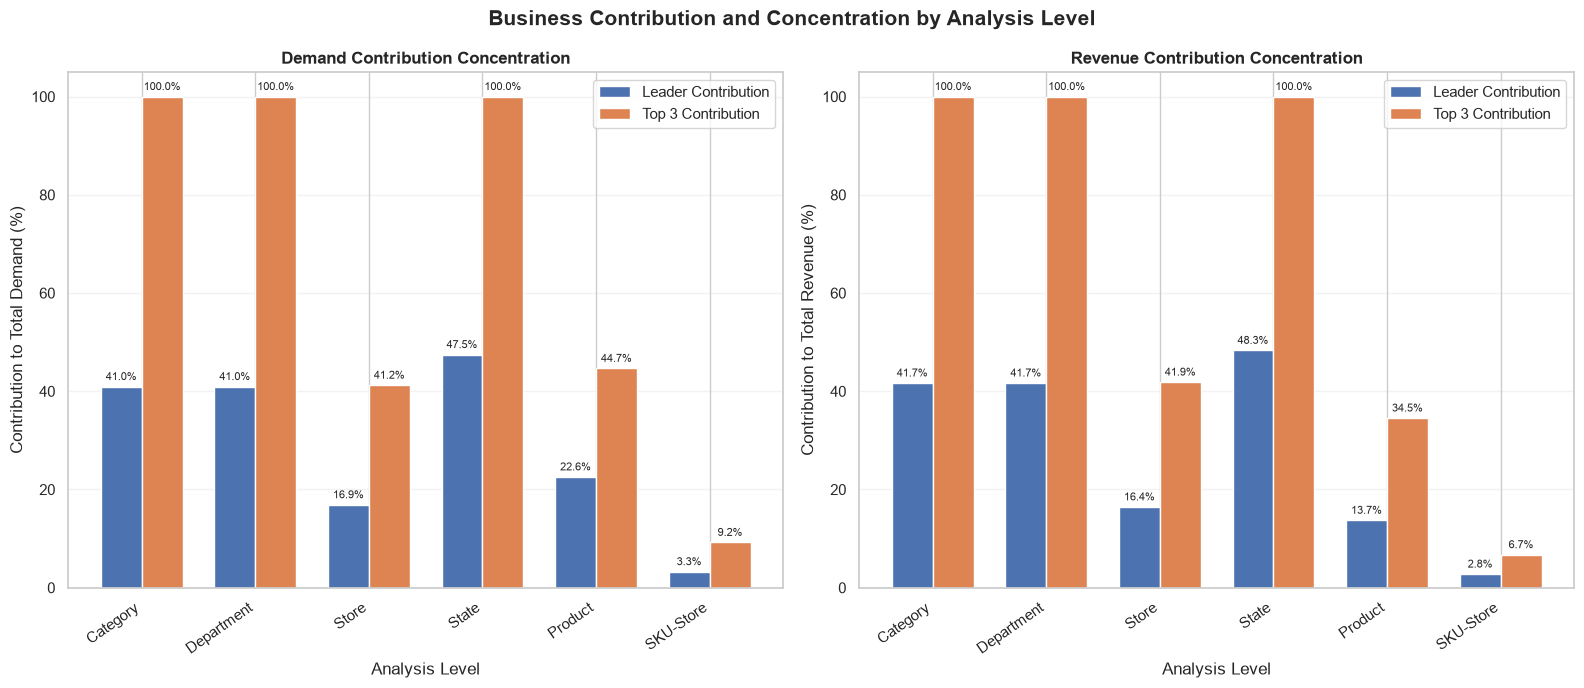

✅ Contribution concentration figure created successfully.
Levels with same leader : 3 of 6
Three-entity levels     : Category, Department, State
Figure path            : C:\Users\hp\Project FORESIGHT\reports\figures\02_16_contribution_concentration.png


In [92]:
# Define the contribution-concentration figure path
CONTRIBUTION_CONCENTRATION_FIGURE = (
    FIGURES_DIR / "02_16_contribution_concentration.png"
)

# Prepare chart positions
contribution_chart_data = (
    business_contribution_summary.copy()
)

level_labels = contribution_chart_data["Analysis Level"]
level_positions = np.arange(len(level_labels))
bar_width = 0.36

# Create demand and revenue concentration charts
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
)

# Plot demand concentration
demand_leader_bars = axes[0].bar(
    level_positions - bar_width / 2,
    contribution_chart_data[
        "Demand Leader Contribution (%)"
    ],
    width=bar_width,
    label="Leader Contribution",
)

top_three_demand_bars = axes[0].bar(
    level_positions + bar_width / 2,
    contribution_chart_data[
        "Top 3 Demand Contribution (%)"
    ],
    width=bar_width,
    label="Top 3 Contribution",
)

axes[0].bar_label(
    demand_leader_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=8,
)

axes[0].bar_label(
    top_three_demand_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=8,
)

axes[0].set_title(
    "Demand Contribution Concentration",
    fontweight="bold",
)

axes[0].set_xlabel("Analysis Level")
axes[0].set_ylabel("Contribution to Total Demand (%)")
axes[0].set_xticks(level_positions)
axes[0].set_xticklabels(
    level_labels,
    rotation=35,
    ha="right",
)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

# Plot revenue concentration
revenue_leader_bars = axes[1].bar(
    level_positions - bar_width / 2,
    contribution_chart_data[
        "Revenue Leader Contribution (%)"
    ],
    width=bar_width,
    label="Leader Contribution",
)

top_three_revenue_bars = axes[1].bar(
    level_positions + bar_width / 2,
    contribution_chart_data[
        "Top 3 Revenue Contribution (%)"
    ],
    width=bar_width,
    label="Top 3 Contribution",
)

axes[1].bar_label(
    revenue_leader_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=8,
)

axes[1].bar_label(
    top_three_revenue_bars,
    fmt="%.1f%%",
    padding=3,
    fontsize=8,
)

axes[1].set_title(
    "Revenue Contribution Concentration",
    fontweight="bold",
)

axes[1].set_xlabel("Analysis Level")
axes[1].set_ylabel("Contribution to Total Revenue (%)")
axes[1].set_xticks(level_positions)
axes[1].set_xticklabels(
    level_labels,
    rotation=35,
    ha="right",
)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

# Add the overall figure title
fig.suptitle(
    "Business Contribution and Concentration by Analysis Level",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

# Save the figure for reporting
fig.savefig(
    CONTRIBUTION_CONCENTRATION_FIGURE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Confirm successful figure creation
small_entity_levels = (
    contribution_chart_data.loc[
        contribution_chart_data["Entity Count"] <= 3,
        "Analysis Level",
    ]
    .tolist()
)

print("✅ Contribution concentration figure created successfully.")
print(f"Levels with same leader : {same_leader_count} of 6")
print(
    "Three-entity levels     : "
    + ", ".join(small_entity_levels)
)
print(f"Figure path            : {CONTRIBUTION_CONCENTRATION_FIGURE}")

### Contribution and Ranking Summary

- **Leader alignment:** Demand and revenue leaders were the same at **3 of 6 levels**: Store, State, and Product.

- **Category and department:** FOODS led demand, while HOUSEHOLD led revenue, confirming the difference between volume and financial value.

- **Store concentration:** The top three stores contributed **41.23% of demand** and **41.86% of revenue**.

- **Product concentration:** The top three products generated **44.66% of demand** but only **34.54% of revenue**.

- **SKU-store distribution:** The top three SKU-store series contributed only **9.22% of demand** and **6.72% of revenue**, showing that performance is widely distributed across locations.

- **Interpretation note:** The 100% top-three values for Category, Department, and State reflect their three-entity structure, not unusually high concentration.

- **Business implication:** Strategic decisions should combine rankings with contribution percentages and should not assume that the demand leader is also the strongest financial contributor.

✅ Section 8.7: Contribution and Ranking Analysis is complete.

---

## 8.8 Business Performance Summary

The most important findings will be documented using:

- performance observation;
- supporting evidence;
- business interpretation;
- recommended area for further investigation.

> **Interpretation rule:** High sales volume does not always imply high revenue or high margin. Demand, price, and estimated financial contribution must be considered together.

In [93]:
# Create stakeholder-ready business performance findings
business_performance_summary = pd.DataFrame(
    [
        {
            "Performance Area": "Category and Department Value",
            "Performance Observation": (
                "FOODS led demand, while HOUSEHOLD led revenue."
            ),
            "Supporting Evidence": (
                f"FOODS contributed "
                f"{highest_demand_category['demand_contribution_pct']:.2f}% "
                f"of demand, while HOUSEHOLD contributed "
                f"{highest_revenue_category['revenue_contribution_pct']:.2f}% "
                f"of revenue."
            ),
            "Business Interpretation": (
                "High sales volume does not necessarily produce the "
                "highest financial contribution."
            ),
            "Further Investigation": (
                "Review category pricing, product mix, and actual margins."
            ),
        },
        {
            "Performance Area": "Store Performance",
            "Performance Observation": (
                f"{highest_demand_store['store_id']} led both demand "
                f"and revenue, while {lowest_demand_store['store_id']} "
                f"recorded the weakest performance."
            ),
            "Supporting Evidence": (
                f"{highest_demand_store['store_id']} sold "
                f"{highest_demand_store['total_units_sold']:,.0f} units "
                f"and generated "
                f"{highest_revenue_store['total_revenue']:,.2f} in revenue."
            ),
            "Business Interpretation": (
                "Store performance differs substantially despite equal "
                "SKU coverage."
            ),
            "Further Investigation": (
                "Compare local demand, operations, pricing, and inventory "
                "availability between leading and weak stores."
            ),
        },
        {
            "Performance Area": "State Performance",
            "Performance Observation": (
                f"{highest_demand_state['state']} led total demand, "
                f"revenue, and demand per store."
            ),
            "Supporting Evidence": (
                f"{highest_demand_state['state']} contributed "
                f"{highest_demand_state['demand_contribution_pct']:.2f}% "
                f"of demand and averaged "
                f"{highest_demand_per_store_state['average_daily_demand_per_store']:.2f} "
                f"units per day per store."
            ),
            "Business Interpretation": (
                "California's leadership is not explained only by its "
                "larger number of stores."
            ),
            "Further Investigation": (
                "Identify successful California practices that may be "
                "transferable to Wisconsin and Texas."
            ),
        },
        {
            "Performance Area": "Product Concentration",
            "Performance Observation": (
                f"{highest_demand_product['product_id']} led both product "
                f"demand and revenue."
            ),
            "Supporting Evidence": (
                f"It sold {highest_demand_product['total_units_sold']:,.0f} "
                f"units and contributed "
                f"{highest_demand_product['demand_contribution_pct']:.2f}% "
                f"of total demand."
            ),
            "Business Interpretation": (
                "Overall performance depends heavily on a small number "
                "of leading products."
            ),
            "Further Investigation": (
                "Protect availability for leading products and assess "
                "portfolio concentration risk."
            ),
        },
        {
            "Performance Area": "SKU-Store Variation",
            "Performance Observation": (
                "The leading demand and revenue SKU-store series were "
                "different."
            ),
            "Supporting Evidence": (
                f"{highest_demand_sku_store['sku_id']} led demand, while "
                f"{highest_revenue_sku_store['sku_id']} led revenue."
            ),
            "Business Interpretation": (
                "Product performance depends on both location and selling "
                "price, supporting store-specific planning."
            ),
            "Further Investigation": (
                "Develop SKU-store-specific forecasts, replenishment rules, "
                "and service-level targets."
            ),
        },
        {
            "Performance Area": "Weak-Series Risk",
            "Performance Observation": (
                f"{lowest_demand_sku_store['sku_id']} recorded extremely "
                f"low demand and selling frequency."
            ),
            "Supporting Evidence": (
                f"It sold only "
                f"{lowest_demand_sku_store['total_units_sold']:,.0f} units "
                f"and was active on "
                f"{lowest_frequency_sku_store['selling_day_frequency_pct']:.2f}% "
                f"of observed days."
            ),
            "Business Interpretation": (
                "Some SKU-store combinations may create unnecessary "
                "inventory and operational complexity."
            ),
            "Further Investigation": (
                "Review weak series for reduced stocking, substitution, "
                "repositioning, or removal."
            ),
        },
    ]
)

# Confirm successful preparation
print("Business performance summary prepared successfully.")
print(
    "Findings documented : "
    f"{len(business_performance_summary):,}"
)
print(
    "Summary fields      : "
    f"{business_performance_summary.shape[1]:,}"
)

Business performance summary prepared successfully.
Findings documented : 6
Summary fields      : 5


In [94]:
# Define the required summary fields
required_business_summary_columns = [
    "Performance Area",
    "Performance Observation",
    "Supporting Evidence",
    "Business Interpretation",
    "Further Investigation",
]

# Check summary quality
missing_business_summary_columns = [
    column
    for column in required_business_summary_columns
    if column not in business_performance_summary.columns
]

duplicate_performance_areas = (
    business_performance_summary["Performance Area"]
    .duplicated()
    .sum()
)

missing_business_summary_values = (
    business_performance_summary[
        required_business_summary_columns
    ]
    .isna()
    .sum()
    .sum()
)

blank_business_summary_values = (
    business_performance_summary[
        required_business_summary_columns
    ]
    .astype(str)
    .apply(lambda column: column.str.strip().eq(""))
    .sum()
    .sum()
)

# Validate the consolidated findings
assert len(business_performance_summary) == 6, (
    f"Expected 6 findings, found "
    f"{len(business_performance_summary):,}."
)

assert not missing_business_summary_columns, (
    "Missing summary columns: "
    f"{missing_business_summary_columns}"
)

assert duplicate_performance_areas == 0, (
    f"Duplicate performance areas found: "
    f"{duplicate_performance_areas:,}."
)

assert missing_business_summary_values == 0, (
    f"Missing summary values found: "
    f"{missing_business_summary_values:,}."
)

assert blank_business_summary_values == 0, (
    f"Blank summary values found: "
    f"{blank_business_summary_values:,}."
)
# Confirm successful validation without redisplaying
# the full text-heavy findings register
print("✅ Business performance summary validation passed.")
print(
    f"Validated findings : "
    f"{len(business_performance_summary):,}"
)
print(
    f"Validated fields   : "
    f"{len(required_business_summary_columns):,}"
)
print(
    "✅ Section 8.8 completed: "
    "Business performance findings consolidated."
)

✅ Business performance summary validation passed.
Validated findings : 6
Validated fields   : 5
✅ Section 8.8 completed: Business performance findings consolidated.


### Business Performance Summary

- **Volume versus value:** FOODS led demand, while HOUSEHOLD led revenue, showing that **high unit sales do not always create the highest financial contribution**.

- **Store leader:** CA_3 ranked first in both demand and revenue, while **CA_4 recorded the weakest store performance**.

- **State leader:** California contributed **47.46% of demand** and also recorded the highest demand per store.

- **Product concentration:** FOODS_1_004 led both product demand and revenue, contributing **22.56% of total units sold**.

- **Location effect:** SKU-store demand and revenue leaders were different, confirming that **product performance varies by store**.

- **Weak-series risk:** HOBBIES_1_006_CA_4 sold only **25 units** and was active on **1.05% of observed days**.

- **Business priority:** Protect high-performing products and locations, apply SKU-store-specific planning, and investigate weak series for reduced stocking or removal.

> Revenue and demand results are based on historical observations. Estimated-margin findings remain assumption-based because actual unit-cost data was unavailable.

✅ Section 8.8: Business Performance Summary is complete.  
✅ Section 8: Business Performance Analysis is complete.

---
# 📦 9. Top Movers, Slow Movers, and Dead-Stock Candidates

This section converts the performance findings from Section 8 into practical product-movement and inventory-risk classifications.

The analysis focuses on:

- historical and recent demand;
- sales frequency and recency;
- fast- and slow-moving products;
- potential dead-stock risk at the SKU-store level;
- simulated inventory exposure.

Product demand and revenue rankings are **reused from Section 8.5** rather than calculated and visualised again.

## Business Question

**Which products and SKU-store series require stronger availability, reduced replenishment, or further inventory review?**

## Objectives

- classify products using transparent historical and recent-demand rules;
- measure product sales concentration;
- identify fast-, regular-, and slow-moving products;
- evaluate potential dead-stock risk at the SKU-store level;
- estimate the simulated inventory exposure of weak-moving series.

## Analysis Structure

- **9.1:** Define the 90-day analysis window and classification rules.
- **9.2:** Measure cumulative demand and revenue concentration.
- **9.3:** Summarise product movement classifications.
- **9.4:** Evaluate dead-stock candidates and simulated inventory exposure.
- **9.5:** Consolidate the main findings and business implications.

> **Interpretation rule:** Movement classifications are analytical screening labels, not final assortment decisions. Inventory quantities and values are simulated and must not be presented as observed financial losses.
---

## 9.1 Define the Analysis Window and Classification Rules

Product movement is evaluated using both **full-history performance** and the most recent **90 calendar days**.

The analysis uses:

- historical and recent demand;
- active and zero-demand days;
- selling frequency;
- days since the most recent sale;
- latest simulated inventory quantity and value.

Classification thresholds are derived from the observed product-demand distribution. A stricter rule is used for dead-stock candidates: **no sales during the full 90-day window, at least 90 days since the last sale, and positive simulated inventory**.

> These classifications are screening indicators for further investigation, not final replenishment or assortment decisions.

In [95]:
# Define the full-history and recent movement windows
movement_history_source = analytics_base_daily.copy()

movement_analysis_start = (
    movement_history_source["date"].min()
)

movement_analysis_end = (
    movement_history_source["date"].max()
)

recent_window_days = 90

movement_recent_start = (
    movement_analysis_end
    - pd.Timedelta(days=recent_window_days - 1)
)

# Keep the final 90 calendar days
movement_recent_source = (
    movement_history_source.loc[
        movement_history_source["date"].between(
            movement_recent_start,
            movement_analysis_end,
        )
    ]
    .copy()
)

# Validate recent-period coverage
recent_observed_days = (
    movement_recent_source["date"].nunique()
)

assert recent_observed_days == recent_window_days, (
    f"Expected {recent_window_days} recent days, "
    f"found {recent_observed_days}."
)

# Confirm the movement-analysis scope
print("Movement analysis window prepared successfully.")
print(
    "Full-history period : "
    f"{movement_analysis_start.date()} to "
    f"{movement_analysis_end.date()}"
)
print(
    "Recent period       : "
    f"{movement_recent_start.date()} to "
    f"{movement_analysis_end.date()}"
)
print(f"Recent days covered  : {recent_observed_days:,}")
print(
    "Products represented: "
    f"{movement_recent_source[product_field].nunique():,}"
)
print(
    "SKU-store series    : "
    f"{movement_recent_source['sku_id'].nunique():,}"
)

Movement analysis window prepared successfully.
Full-history period : 2011-01-29 to 2016-04-24
Recent period       : 2016-01-26 to 2016-04-24
Recent days covered  : 90
Products represented: 30
SKU-store series    : 300


In [96]:
# Aggregate product demand across stores by calendar day
product_daily_movement = (
    movement_history_source
    .groupby([product_field, "date"], as_index=False)
    .agg(
        daily_units_sold=("units_sold", "sum"),
        daily_revenue=("revenue", "sum"),
    )
)

# Mark active and zero-demand days
product_daily_movement["is_active_selling_day"] = (
    product_daily_movement["daily_units_sold"] > 0
)

product_daily_movement["is_zero_demand_day"] = (
    product_daily_movement["daily_units_sold"] == 0
)

# Summarise full-history product movement
product_movement_summary = (
    product_daily_movement
    .groupby(product_field, as_index=False)
    .agg(
        observed_days=("date", "nunique"),
        total_units_sold=("daily_units_sold", "sum"),
        total_revenue=("daily_revenue", "sum"),
        active_selling_days=("is_active_selling_day", "sum"),
        zero_demand_days=("is_zero_demand_day", "sum"),
    )
    .rename(columns={product_field: "product_id"})
)

product_movement_summary["average_daily_demand"] = (
    product_movement_summary["total_units_sold"]
    / product_movement_summary["observed_days"]
)

product_movement_summary["selling_day_frequency_pct"] = (
    product_movement_summary["active_selling_days"]
    / product_movement_summary["observed_days"]
    * 100
)

product_movement_summary["zero_demand_frequency_pct"] = (
    product_movement_summary["zero_demand_days"]
    / product_movement_summary["observed_days"]
    * 100
)

# Summarise recent 90-day movement
recent_product_daily = product_daily_movement.loc[
    product_daily_movement["date"].between(
        movement_recent_start,
        movement_analysis_end,
    )
].copy()

recent_product_summary = (
    recent_product_daily
    .groupby(product_field, as_index=False)
    .agg(
        recent_observed_days=("date", "nunique"),
        recent_units_sold=("daily_units_sold", "sum"),
        recent_revenue=("daily_revenue", "sum"),
        recent_active_selling_days=("is_active_selling_day", "sum"),
        recent_zero_demand_days=("is_zero_demand_day", "sum"),
    )
    .rename(columns={product_field: "product_id"})
)

recent_product_summary["recent_average_daily_demand"] = (
    recent_product_summary["recent_units_sold"]
    / recent_product_summary["recent_observed_days"]
)

recent_product_summary["recent_selling_day_frequency_pct"] = (
    recent_product_summary["recent_active_selling_days"]
    / recent_product_summary["recent_observed_days"]
    * 100
)

recent_product_summary["recent_zero_demand_frequency_pct"] = (
    recent_product_summary["recent_zero_demand_days"]
    / recent_product_summary["recent_observed_days"]
    * 100
)

# Identify each product's most recent sale
product_last_sale = (
    product_daily_movement.loc[
        product_daily_movement["daily_units_sold"] > 0
    ]
    .groupby(product_field, as_index=False)
    .agg(last_sale_date=("date", "max"))
    .rename(columns={product_field: "product_id"})
)

# Summarise simulated inventory at the latest date
latest_product_inventory = (
    movement_history_source.loc[
        movement_history_source["date"] == movement_analysis_end
    ]
    .groupby(product_field, as_index=False)
    .agg(
        latest_closing_stock=("closing_stock", "sum"),
        latest_inventory_value=("estimated_inventory_value", "sum"),
    )
    .rename(columns={product_field: "product_id"})
)

# Add product hierarchy information
product_hierarchy = (
    product_performance_summary[
        ["product_id", "category", "department"]
    ]
    .drop_duplicates()
)

# Combine movement and inventory indicators
product_movement_summary = (
    product_movement_summary
    .merge(
        recent_product_summary,
        on="product_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        product_last_sale,
        on="product_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        latest_product_inventory,
        on="product_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        product_hierarchy,
        on="product_id",
        how="left",
        validate="one_to_one",
    )
)

# Calculate recency since the latest sale
product_movement_summary["days_since_last_sale"] = (
    movement_analysis_end
    - product_movement_summary["last_sale_date"]
).dt.days

# Validate product coverage and totals
assert len(product_movement_summary) == 30
assert product_movement_summary.isna().sum().sum() == 0

assert np.isclose(
    product_movement_summary["total_units_sold"].sum(),
    total_units_sold,
)

assert np.isclose(
    product_movement_summary["total_revenue"].sum(),
    total_revenue,
)

# Review movement-indicator distributions
distribution_columns = [
    "total_units_sold",
    "average_daily_demand",
    "recent_units_sold",
    "recent_average_daily_demand",
    "recent_selling_day_frequency_pct",
    "recent_zero_demand_frequency_pct",
    "days_since_last_sale",
    "latest_closing_stock",
    "latest_inventory_value",
]

movement_distribution_summary = (
    product_movement_summary[distribution_columns]
    .quantile([0.00, 0.25, 0.50, 0.75, 1.00])
    .T
    .reset_index()
)

movement_distribution_summary.columns = [
    "Movement Metric",
    "Minimum",
    "25th Percentile",
    "Median",
    "75th Percentile",
    "Maximum",
]

movement_distribution_summary = (
    movement_distribution_summary.round(2)
)

display(movement_distribution_summary)

print("✅ Product movement indicators prepared successfully.")
print(f"Products analysed      : {len(product_movement_summary):,}")
print(f"Recent window          : {recent_window_days} days")
print(
    "Latest inventory value: "
    f"{product_movement_summary['latest_inventory_value'].sum():,.2f}"
)

,Movement Metric,Minimum,25th Percentile,Median,75th Percentile,Maximum
0,total_units_sold,"1,435.00","6,356.50","11,300.00","17,463.75","129,481.00"
1,average_daily_demand,0.75,3.32,5.91,9.13,67.68
2,recent_units_sold,86.00,412.50,551.50,952.00,"3,585.00"
3,recent_average_daily_demand,0.96,4.58,6.13,10.58,39.83
4,recent_selling_day_frequency_pct,17.78,97.78,98.89,100.00,100.00
5,recent_zero_demand_frequency_pct,0.00,0.00,1.11,2.22,82.22
6,days_since_last_sale,0.00,0.00,0.00,0.00,53.00
7,latest_closing_stock,18.00,63.25,109.00,186.25,"1,864.00"
8,latest_inventory_value,41.64,181.83,308.66,501.60,"2,553.68"


✅ Product movement indicators prepared successfully.
Products analysed      : 30
Recent window          : 90 days
Latest inventory value: 14,170.55


In [97]:
# Derive classification thresholds from observed distributions
fast_history_threshold = (
    product_movement_summary["total_units_sold"].quantile(0.75)
)

fast_recent_threshold = (
    product_movement_summary[
        "recent_average_daily_demand"
    ].quantile(0.75)
)

fast_frequency_threshold = (
    product_movement_summary[
        "recent_selling_day_frequency_pct"
    ].quantile(0.50)
)

slow_history_threshold = (
    product_movement_summary["total_units_sold"].quantile(0.25)
)

slow_recent_threshold = (
    product_movement_summary[
        "recent_average_daily_demand"
    ].quantile(0.25)
)

slow_frequency_threshold = (
    product_movement_summary[
        "recent_selling_day_frequency_pct"
    ].quantile(0.50)
)

# Define transparent movement conditions
fast_moving_condition = (
    (
        product_movement_summary["total_units_sold"]
        >= fast_history_threshold
    )
    & (
        product_movement_summary[
            "recent_average_daily_demand"
        ]
        >= fast_recent_threshold
    )
    & (
        product_movement_summary[
            "recent_selling_day_frequency_pct"
        ]
        >= fast_frequency_threshold
    )
)

slow_moving_condition = (
    (
        product_movement_summary["total_units_sold"]
        <= slow_history_threshold
    )
    & (
        product_movement_summary[
            "recent_average_daily_demand"
        ]
        <= slow_recent_threshold
    )
    & (
        product_movement_summary[
            "recent_selling_day_frequency_pct"
        ]
        <= slow_frequency_threshold
    )
)

# Require no sales in the full recent window and positive stock
dead_stock_condition = (
    (
        product_movement_summary["recent_units_sold"]
        == 0
    )
    & (
        product_movement_summary["days_since_last_sale"]
        >= recent_window_days
    )
    & (
        product_movement_summary["latest_closing_stock"]
        > 0
    )
)

# Apply one movement classification per product
product_movement_summary["movement_classification"] = (
    np.select(
        [
            dead_stock_condition,
            fast_moving_condition,
            slow_moving_condition,
        ],
        [
            "Dead-Stock Candidate",
            "Fast-Moving",
            "Slow-Moving",
        ],
        default="Regular-Moving",
    )
)

# Summarise classification counts
movement_classification_counts = (
    product_movement_summary[
        "movement_classification"
    ]
    .value_counts()
    .rename_axis("Movement Classification")
    .reset_index(name="Product Count")
)

# Validate complete classification
assert (
    movement_classification_counts["Product Count"].sum()
    == 30
), "Not all products were classified."

assert (
    product_movement_summary[
        "movement_classification"
    ].notna().all()
), "A product is missing its movement classification."

display(movement_classification_counts)

print("✅ Movement classification rules applied successfully.")
print(f"Fast history threshold   : {fast_history_threshold:,.2f} units")
print(f"Fast recent threshold    : {fast_recent_threshold:,.2f} units/day")
print(f"Fast frequency threshold : {fast_frequency_threshold:,.2f}%")
print(f"Slow history threshold   : {slow_history_threshold:,.2f} units")
print(f"Slow recent threshold    : {slow_recent_threshold:,.2f} units/day")
print(f"Slow frequency threshold : {slow_frequency_threshold:,.2f}%")
print(
    "Dead-stock rule          : "
    "No sales during the full 90-day window "
    "with positive simulated stock"
)

,Movement Classification,Product Count
0,Regular-Moving,19
1,Fast-Moving,7
2,Slow-Moving,4


✅ Movement classification rules applied successfully.
Fast history threshold   : 17,463.75 units
Fast recent threshold    : 10.58 units/day
Fast frequency threshold : 98.89%
Slow history threshold   : 6,356.50 units
Slow recent threshold    : 4.58 units/day
Slow frequency threshold : 98.89%
Dead-stock rule          : No sales during the full 90-day window with positive simulated stock


### Analysis Window and Classification Rules Summary

- **Recent window:** Final **90 calendar days**, from 26 January 2016 to 24 April 2016.

- **Fast-moving rule:** Strong historical demand, strong recent demand, and frequent recent sales.

- **Slow-moving rule:** Low historical demand, low recent demand, and below-median recent selling frequency.

- **Dead-stock rule:** No demand during the complete 90-day window, at least 90 days since the last sale, and positive simulated inventory.

- **Classification result:** **7 Fast-Moving**, **19 Regular-Moving**, and **4 Slow-Moving products**.

- **Dead-stock result:** No product met the strict product-level dead-stock rule.

- **Modelling note:** Product-level selling frequency is generally high because demand is combined across ten stores. Dead-stock risk will therefore be assessed more precisely at the **SKU-store level** in Section 9.4.

✅ Section 9.1: Analysis Window and Movement Rules is complete.

---
## 9.2 Sales Concentration Analysis

This analysis measures how much of total demand and revenue is generated by the leading products.

Existing product rankings from Section 8.5 are reused to avoid repeating the same tables and charts. Products are arranged from highest to lowest contribution, and cumulative percentages are calculated to identify:

- the number of products responsible for approximately **80% of demand**;
- the number responsible for approximately **80% of revenue**;
- whether business performance is concentrated in a small part of the product portfolio.

> The 80% level is used as a descriptive Pareto reference, not as a fixed business rule.

In [98]:
# Prepare cumulative concentration curves for demand and revenue
concentration_source = (
    product_movement_summary[
        ["product_id", "total_units_sold", "total_revenue"]
    ]
    .copy()
)

total_products = concentration_source["product_id"].nunique()

concentration_frames = []

for metric_name, metric_column in {
    "Demand": "total_units_sold",
    "Revenue": "total_revenue",
}.items():

    metric_ranking = (
        concentration_source
        .sort_values(metric_column, ascending=False)
        .reset_index(drop=True)
    )

    metric_ranking["product_rank"] = (
        metric_ranking.index + 1
    )

    metric_ranking["product_share_pct"] = (
        metric_ranking["product_rank"]
        / total_products
        * 100
    )

    metric_ranking["individual_contribution_pct"] = (
        metric_ranking[metric_column]
        / metric_ranking[metric_column].sum()
        * 100
    )

    metric_ranking["cumulative_contribution_pct"] = (
        metric_ranking["individual_contribution_pct"]
        .cumsum()
    )

    metric_ranking["performance_metric"] = metric_name
    metric_ranking["metric_value"] = metric_ranking[metric_column]

    concentration_frames.append(
        metric_ranking[
            [
                "performance_metric",
                "product_id",
                "product_rank",
                "product_share_pct",
                "metric_value",
                "individual_contribution_pct",
                "cumulative_contribution_pct",
            ]
        ]
    )

product_concentration_curve = (
    pd.concat(
        concentration_frames,
        ignore_index=True,
    )
)

print("✅ Product concentration curves prepared successfully.")
print(f"Products analysed : {total_products:,}")
print(
    "Metrics prepared  : "
    f"{product_concentration_curve['performance_metric'].nunique():,}"
)
print(
    "Curve records     : "
    f"{len(product_concentration_curve):,}"
)

✅ Product concentration curves prepared successfully.
Products analysed : 30
Metrics prepared  : 2
Curve records     : 60


In [99]:
# Define descriptive concentration reference points
pareto_target_pct = 80
top_portfolio_share_pct = 20

top_product_count = max(
    1,
    int(np.ceil(total_products * top_portfolio_share_pct / 100)),
)

concentration_summary_rows = []

for metric_name in ["Demand", "Revenue"]:

    metric_curve = (
        product_concentration_curve.loc[
            product_concentration_curve[
                "performance_metric"
            ] == metric_name
        ]
        .sort_values("product_rank")
        .reset_index(drop=True)
    )

    # Find the minimum products needed to reach 80%
    pareto_cutoff = (
        metric_curve.loc[
            metric_curve[
                "cumulative_contribution_pct"
            ] >= pareto_target_pct
        ]
        .iloc[0]
    )

    # Measure contribution from the top 20% of products
    top_20_contribution = (
        metric_curve.loc[
            metric_curve["product_rank"] <= top_product_count,
            "individual_contribution_pct",
        ]
        .sum()
    )

    concentration_summary_rows.append(
        {
            "Performance Metric": metric_name,
            "Products to Reach 80%": int(
                pareto_cutoff["product_rank"]
            ),
            "Portfolio Share to Reach 80% (%)": (
                pareto_cutoff["product_rank"]
                / total_products
                * 100
            ),
            "Contribution at Cutoff (%)": (
                pareto_cutoff[
                    "cumulative_contribution_pct"
                ]
            ),
            "Top 20% Product Count": top_product_count,
            "Top 20% Contribution (%)": top_20_contribution,
        }
    )

product_concentration_summary = pd.DataFrame(
    concentration_summary_rows
).round(2)

# Validate concentration calculations
final_contributions = (
    product_concentration_curve
    .groupby("performance_metric")[
        "cumulative_contribution_pct"
    ]
    .max()
)

assert len(product_concentration_summary) == 2
assert np.allclose(final_contributions.values, 100)
assert (
    product_concentration_summary[
        "Products to Reach 80%"
    ].between(1, total_products).all()
)

display(product_concentration_summary)

print("✅ Product concentration levels summarised successfully.")
print(f"Pareto reference       : {pareto_target_pct}%")
print(
    f"Top portfolio group    : "
    f"{top_product_count} of {total_products} products"
)

,Performance Metric,Products to Reach 80%,Portfolio Share to Reach 80% (%),Contribution at Cutoff (%),Top 20% Product Count,Top 20% Contribution (%)
0,Demand,14,46.67,81.95,6,60.35
1,Revenue,16,53.33,80.59,6,50.58


✅ Product concentration levels summarised successfully.
Pareto reference       : 80%
Top portfolio group    : 6 of 30 products


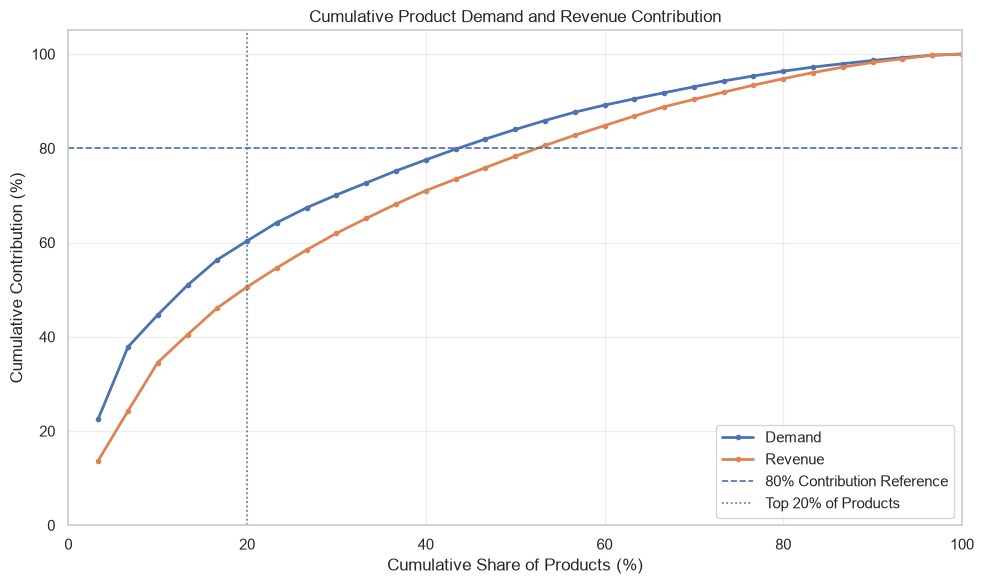

✅ Product concentration figure created successfully.
Figure saved to: C:\Users\hp\Project FORESIGHT\reports\figures\02_17_product_sales_concentration.png


In [100]:
# Close any incomplete figures
plt.close("all")

# Use the project-level reports/figures folder
figure_output_dir = Path("../reports/figures").resolve()
figure_output_dir.mkdir(parents=True, exist_ok=True)

# Plot cumulative product contribution
plt.figure(figsize=(10, 6))

for metric_name in ["Demand", "Revenue"]:

    metric_curve = (
        product_concentration_curve.loc[
            product_concentration_curve[
                "performance_metric"
            ] == metric_name
        ]
        .sort_values("product_share_pct")
    )

    plt.plot(
        metric_curve["product_share_pct"],
        metric_curve["cumulative_contribution_pct"],
        marker="o",
        markersize=3,
        linewidth=2,
        label=metric_name,
    )

# Add descriptive Pareto reference lines
plt.axhline(
    y=80,
    linestyle="--",
    linewidth=1.2,
    label="80% Contribution Reference",
)

plt.axvline(
    x=20,
    linestyle=":",
    linewidth=1.2,
    label="Top 20% of Products",
)

# Format the figure
plt.title(
    "Cumulative Product Demand and Revenue Contribution"
)
plt.xlabel("Cumulative Share of Products (%)")
plt.ylabel("Cumulative Contribution (%)")
plt.xlim(0, 100)
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# Save the figure
concentration_figure_path = (
    figure_output_dir
    / "02_17_product_sales_concentration.png"
)

plt.savefig(
    concentration_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Validate the saved figure
assert concentration_figure_path.exists()

print("✅ Product concentration figure created successfully.")
print(f"Figure saved to: {concentration_figure_path}")

### Sales Concentration Findings

- **Demand concentration:** The top **6 products**, representing 20% of the portfolio, generated **60.35% of total demand**.

- **Revenue concentration:** The same top-20% product group generated **50.58% of total revenue**.

- **80% demand threshold:** **14 products**, or 46.67% of the portfolio, were required to reach **81.95% of demand**.

- **80% revenue threshold:** **16 products**, or 53.33% of the portfolio, were required to reach **80.59% of revenue**.

- **Interpretation:** Demand is more concentrated than revenue, but the portfolio does not follow a strict 80/20 pattern.

- **Business implication:** Leading products require stronger availability controls, while the broader portfolio still contributes materially and should not be ignored.

✅ Section 9.2: Sales Concentration Analysis is complete.

---
## 9.3 Product Movement Classification

Products are grouped into **Fast-Moving**, **Regular-Moving**, and **Slow-Moving** classes using the rules established in Section 9.1.

The comparison will focus on:

- historical and recent demand;
- recent selling frequency;
- movement-class distribution;
- category and department composition;
- inventory-planning implications.

Only one consolidated classification table and one supporting figure will be used.

> Movement classes are relative screening labels based on the current analytical scope and should be reviewed periodically as demand changes.

In [101]:
# Summarise products by movement class
movement_class_summary = (
    product_movement_summary
    .groupby(
        "movement_classification",
        as_index=False,
    )
    .agg(
        product_count=("product_id", "nunique"),
        total_units_sold=("total_units_sold", "sum"),
        recent_units_sold=("recent_units_sold", "sum"),
        total_revenue=("total_revenue", "sum"),
        latest_closing_stock=("latest_closing_stock", "sum"),
        latest_inventory_value=("latest_inventory_value", "sum"),
        average_recent_daily_demand=(
            "recent_average_daily_demand",
            "mean",
        ),
        average_recent_selling_frequency_pct=(
            "recent_selling_day_frequency_pct",
            "mean",
        ),
        average_days_since_last_sale=(
            "days_since_last_sale",
            "mean",
        ),
    )
)

# Add contribution measures
movement_class_summary["product_share_pct"] = (
    movement_class_summary["product_count"]
    / movement_class_summary["product_count"].sum()
    * 100
)

movement_class_summary["demand_contribution_pct"] = (
    movement_class_summary["total_units_sold"]
    / movement_class_summary["total_units_sold"].sum()
    * 100
)

movement_class_summary["recent_demand_contribution_pct"] = (
    movement_class_summary["recent_units_sold"]
    / movement_class_summary["recent_units_sold"].sum()
    * 100
)

movement_class_summary["revenue_contribution_pct"] = (
    movement_class_summary["total_revenue"]
    / movement_class_summary["total_revenue"].sum()
    * 100
)

movement_class_summary["inventory_value_share_pct"] = (
    movement_class_summary["latest_inventory_value"]
    / movement_class_summary["latest_inventory_value"].sum()
    * 100
)

# Arrange classes in business order
movement_class_order = [
    "Fast-Moving",
    "Regular-Moving",
    "Slow-Moving",
    "Dead-Stock Candidate",
]

movement_class_summary["movement_classification"] = pd.Categorical(
    movement_class_summary["movement_classification"],
    categories=movement_class_order,
    ordered=True,
)

movement_class_summary = (
    movement_class_summary
    .sort_values("movement_classification")
    .reset_index(drop=True)
)

# Prepare concise display table
movement_class_display = (
    movement_class_summary[
        [
            "movement_classification",
            "product_count",
            "product_share_pct",
            "demand_contribution_pct",
            "recent_demand_contribution_pct",
            "revenue_contribution_pct",
            "inventory_value_share_pct",
            "average_recent_daily_demand",
            "average_recent_selling_frequency_pct",
            "average_days_since_last_sale",
        ]
    ]
    .rename(
        columns={
            "movement_classification": "Movement Class",
            "product_count": "Products",
            "product_share_pct": "Product Share (%)",
            "demand_contribution_pct": "Historical Demand (%)",
            "recent_demand_contribution_pct": "Recent Demand (%)",
            "revenue_contribution_pct": "Revenue (%)",
            "inventory_value_share_pct": "Inventory Value (%)",
            "average_recent_daily_demand": "Avg Recent Daily Demand",
            "average_recent_selling_frequency_pct": (
                "Avg Recent Selling Frequency (%)"
            ),
            "average_days_since_last_sale": (
                "Avg Days Since Last Sale"
            ),
        }
    )
    .round(2)
)

# Validate classification summary
assert movement_class_summary["product_count"].sum() == 30
assert np.isclose(
    movement_class_summary["demand_contribution_pct"].sum(),
    100,
)
assert np.isclose(
    movement_class_summary["revenue_contribution_pct"].sum(),
    100,
)

display(movement_class_display)

print("✅ Product movement classes summarised successfully.")
print(
    "Movement classes represented: "
    f"{len(movement_class_summary):,}"
)
print(
    "Products classified          : "
    f"{movement_class_summary['product_count'].sum():,}"
)

,Movement Class,Products,Product Share (%),Historical Demand (%),Recent Demand (%),Revenue (%),Inventory Value (%),Avg Recent Daily Demand,Avg Recent Selling Frequency (%),Avg Days Since Last Sale
0,Fast-Moving,7,23.33,44.82,51.95,37.73,36.13,20.51,100.00,0.00
1,Regular-Moving,19,63.33,52.83,44.27,58.71,60.58,6.44,89.94,2.79
2,Slow-Moving,4,13.33,2.34,3.77,3.56,3.29,2.61,90.83,0.00


✅ Product movement classes summarised successfully.
Movement classes represented: 3
Products classified          : 30


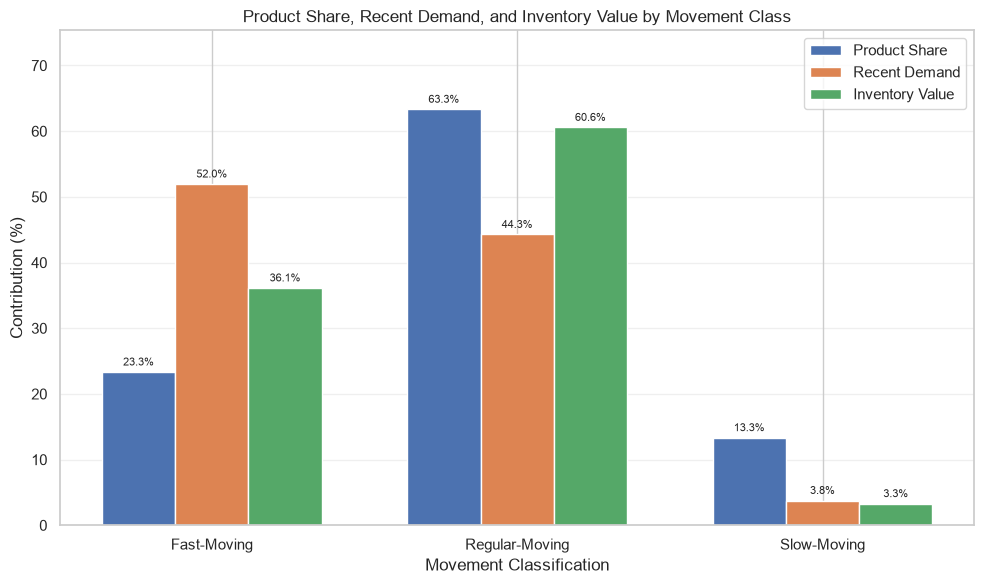

✅ Product movement classification figure created successfully.
Figure saved to: C:\Users\hp\Project FORESIGHT\reports\figures\02_18_product_movement_classification.png


In [102]:
# Close any incomplete figures from earlier executions
plt.close("all")

# Locate the project-level figure folder
current_working_directory = Path.cwd().resolve()

project_root = (
    current_working_directory.parent
    if current_working_directory.name.lower() == "notebooks"
    else current_working_directory
)

figure_output_dir = (
    project_root
    / "reports"
    / "figures"
)

figure_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Select movement-class measures for comparison
movement_plot_data = (
    movement_class_summary[
        [
            "movement_classification",
            "product_share_pct",
            "recent_demand_contribution_pct",
            "inventory_value_share_pct",
        ]
    ]
    .copy()
)

movement_plot_data["movement_classification"] = (
    movement_plot_data[
        "movement_classification"
    ].astype(str)
)

plot_metrics = {
    "product_share_pct": "Product Share",
    "recent_demand_contribution_pct": "Recent Demand",
    "inventory_value_share_pct": "Inventory Value",
}

# Define grouped-bar positions
x_positions = np.arange(
    len(movement_plot_data)
)

bar_width = 0.24

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for metric_position, (
    metric_column,
    metric_label,
) in enumerate(plot_metrics.items()):

    bar_positions = (
        x_positions
        + (metric_position - 1) * bar_width
    )

    bars = ax.bar(
        bar_positions,
        movement_plot_data[metric_column],
        width=bar_width,
        label=metric_label,
    )

    ax.bar_label(
        bars,
        labels=[
            f"{value:.1f}%"
            for value in movement_plot_data[
                metric_column
            ]
        ],
        padding=3,
        fontsize=8,
    )

# Format the figure
ax.set_title(
    "Product Share, Recent Demand, and Inventory Value by Movement Class"
)
ax.set_xlabel(
    "Movement Classification"
)
ax.set_ylabel(
    "Contribution (%)"
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    movement_plot_data[
        "movement_classification"
    ]
)

maximum_plot_value = (
    movement_plot_data[
        list(plot_metrics.keys())
    ]
    .to_numpy()
    .max()
)

ax.set_ylim(
    0,
    maximum_plot_value + 12,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.legend()

plt.tight_layout()

# Save in the project-level reports folder
movement_figure_path = (
    figure_output_dir
    / "02_18_product_movement_classification.png"
)

plt.savefig(
    movement_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("✅ Product movement classification figure created successfully.")
print(
    "Figure saved to: "
    f"{movement_figure_path.resolve()}"
)

### Product Movement Classification Findings

- **Fast-Moving products:** **7 products** represented **23.33% of the portfolio** but generated **51.95% of recent demand**.

- **Regular-Moving products:** **19 products** represented **63.33% of the portfolio** and held **60.58% of simulated inventory value**.

- **Slow-Moving products:** **4 products** represented **13.33% of the portfolio** but contributed only **3.77% of recent demand** and **3.29% of simulated inventory value**.

- **Demand concentration:** Fast-moving products generated more than half of recent demand despite representing less than one-quarter of the product portfolio.

- **Inventory implication:** Fast-moving products require stronger availability protection, while slow-moving products should be reviewed for reduced replenishment or targeted promotion.

- **Modelling note:** Product-level recency remains high because sales are aggregated across stores. Location-specific inventory risk will therefore be assessed at the **SKU-store level** in Section 9.4.

✅ Section 9.3: Product Movement Classification is complete.

---
## 9.4 Dead-Stock Candidates and Inventory Exposure

Dead-stock risk is evaluated at the **SKU-store level**, where weak product movement can be hidden by stronger sales in other locations.

Candidate identification will consider:

- recent demand;
- selling frequency;
- days since the most recent sale;
- positive simulated closing stock;
- estimated simulated inventory value.

The analysis will also summarise inventory exposure by store, state, and product where candidates are identified.

> Dead-stock labels are preliminary screening indicators. Inventory quantities and values are simulated and must not be presented as confirmed financial loss.

In [103]:
# Prepare SKU-store movement indicators
sku_store_movement_summary = (
    movement_history_source
    .groupby("sku_id", as_index=False)
    .agg(
        product_id=(product_field, "first"),
        store_id=("store_id", "first"),
        state_id=("state_id", "first"),
        category=("category", "first"),
        department=("department", "first"),
        observed_days=("date", "nunique"),
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
        active_selling_days=(
            "units_sold",
            lambda values: (values > 0).sum(),
        ),
    )
)

# Calculate recent 90-day movement
recent_sku_store_summary = (
    movement_recent_source
    .groupby("sku_id", as_index=False)
    .agg(
        recent_observed_days=("date", "nunique"),
        recent_units_sold=("units_sold", "sum"),
        recent_active_selling_days=(
            "units_sold",
            lambda values: (values > 0).sum(),
        ),
    )
)

recent_sku_store_summary["recent_selling_frequency_pct"] = (
    recent_sku_store_summary["recent_active_selling_days"]
    / recent_sku_store_summary["recent_observed_days"]
    * 100
)

recent_sku_store_summary["recent_zero_demand_frequency_pct"] = (
    100
    - recent_sku_store_summary["recent_selling_frequency_pct"]
)

# Identify the most recent sale for each SKU-store series
sku_store_last_sale = (
    movement_history_source.loc[
        movement_history_source["units_sold"] > 0
    ]
    .groupby("sku_id", as_index=False)
    .agg(last_sale_date=("date", "max"))
)

# Capture simulated inventory at the latest date
latest_sku_store_inventory = (
    movement_history_source.loc[
        movement_history_source["date"] == movement_analysis_end
    ]
    [
        [
            "sku_id",
            "closing_stock",
            "estimated_inventory_value",
        ]
    ]
    .copy()
)

# Combine movement, recency, and inventory measures
sku_store_movement_summary = (
    sku_store_movement_summary
    .merge(
        recent_sku_store_summary,
        on="sku_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        sku_store_last_sale,
        on="sku_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        latest_sku_store_inventory,
        on="sku_id",
        how="left",
        validate="one_to_one",
    )
)

# Calculate days since the latest recorded sale
sku_store_movement_summary["days_since_last_sale"] = (
    movement_analysis_end
    - sku_store_movement_summary["last_sale_date"]
).dt.days

# Treat never-sold series as inactive for the full history
full_history_days = (
    movement_analysis_end
    - movement_analysis_start
).days + 1

sku_store_movement_summary["days_since_last_sale"] = (
    sku_store_movement_summary["days_since_last_sale"]
    .fillna(full_history_days)
    .astype(int)
)

# Review the main dead-stock screening measures
sku_store_distribution_summary = (
    sku_store_movement_summary[
        [
            "recent_units_sold",
            "recent_active_selling_days",
            "recent_selling_frequency_pct",
            "recent_zero_demand_frequency_pct",
            "days_since_last_sale",
            "closing_stock",
            "estimated_inventory_value",
        ]
    ]
    .quantile([0.00, 0.25, 0.50, 0.75, 1.00])
    .T
    .reset_index()
)

sku_store_distribution_summary.columns = [
    "Screening Metric",
    "Minimum",
    "25th Percentile",
    "Median",
    "75th Percentile",
    "Maximum",
]

sku_store_distribution_summary = (
    sku_store_distribution_summary.round(2)
)

# Validate complete SKU-store coverage
assert len(sku_store_movement_summary) == 300
assert sku_store_movement_summary["sku_id"].nunique() == 300
assert sku_store_movement_summary["recent_observed_days"].eq(90).all()

display(sku_store_distribution_summary)

print("✅ SKU-store movement indicators prepared successfully.")
print(f"SKU-store series analysed : {len(sku_store_movement_summary):,}")
print(f"Recent analysis window     : {recent_window_days} days")
print(
    "Series with zero recent demand: "
    f"{(sku_store_movement_summary['recent_units_sold'] == 0).sum():,}"
)
print(
    "Series inactive for 90+ days : "
    f"{(sku_store_movement_summary['days_since_last_sale'] >= 90).sum():,}"
)

,Screening Metric,Minimum,25th Percentile,Median,75th Percentile,Maximum
0,recent_units_sold,2.00,26.75,56.50,101.25,953.00
1,recent_active_selling_days,1.00,19.00,34.00,50.25,87.00
2,recent_selling_frequency_pct,1.11,21.11,37.78,55.83,96.67
3,recent_zero_demand_frequency_pct,3.33,44.17,62.22,78.89,98.89
4,days_since_last_sale,0.00,0.00,1.00,3.00,86.00
5,closing_stock,0.00,4.00,9.00,19.25,335.00
6,estimated_inventory_value,0.00,11.10,25.80,53.76,471.25


✅ SKU-store movement indicators prepared successfully.
SKU-store series analysed : 300
Recent analysis window     : 90 days
Series with zero recent demand: 0
Series inactive for 90+ days : 0


In [104]:
# Derive weak-movement thresholds from observed distributions
weak_recent_units_threshold = (
    sku_store_movement_summary["recent_units_sold"]
    .quantile(0.25)
)

weak_frequency_threshold = (
    sku_store_movement_summary[
        "recent_selling_frequency_pct"
    ]
    .quantile(0.25)
)

# Apply the strict dead-stock rule
strict_dead_stock_condition = (
    (sku_store_movement_summary["recent_units_sold"] == 0)
    & (
        sku_store_movement_summary["days_since_last_sale"]
        >= recent_window_days
    )
    & (sku_store_movement_summary["closing_stock"] > 0)
)

# Identify weak-moving series holding simulated inventory
weak_inventory_watchlist_condition = (
    ~strict_dead_stock_condition
    & (
        sku_store_movement_summary["recent_units_sold"]
        <= weak_recent_units_threshold
    )
    & (
        sku_store_movement_summary[
            "recent_selling_frequency_pct"
        ]
        <= weak_frequency_threshold
    )
    & (sku_store_movement_summary["closing_stock"] > 0)
)

# Assign one inventory-risk status per SKU-store series
sku_store_movement_summary["inventory_risk_status"] = (
    np.select(
        [
            strict_dead_stock_condition,
            weak_inventory_watchlist_condition,
        ],
        [
            "Dead-Stock Candidate",
            "Weak-Movement Watchlist",
        ],
        default="Active / No Immediate Risk",
    )
)

# Summarise simulated inventory exposure by status
inventory_risk_summary = (
    sku_store_movement_summary
    .groupby("inventory_risk_status", as_index=False)
    .agg(
        sku_store_series=("sku_id", "nunique"),
        recent_units_sold=("recent_units_sold", "sum"),
        simulated_inventory_units=("closing_stock", "sum"),
        estimated_inventory_value=(
            "estimated_inventory_value",
            "sum",
        ),
        average_recent_units=("recent_units_sold", "mean"),
        average_selling_frequency_pct=(
            "recent_selling_frequency_pct",
            "mean",
        ),
        average_days_since_last_sale=(
            "days_since_last_sale",
            "mean",
        ),
    )
)

# Calculate portfolio and inventory-value shares
inventory_risk_summary["series_share_pct"] = (
    inventory_risk_summary["sku_store_series"]
    / len(sku_store_movement_summary)
    * 100
)

inventory_risk_summary["inventory_value_share_pct"] = (
    inventory_risk_summary["estimated_inventory_value"]
    / inventory_risk_summary["estimated_inventory_value"].sum()
    * 100
)

# Arrange statuses in business order
risk_status_order = [
    "Dead-Stock Candidate",
    "Weak-Movement Watchlist",
    "Active / No Immediate Risk",
]

inventory_risk_summary["inventory_risk_status"] = pd.Categorical(
    inventory_risk_summary["inventory_risk_status"],
    categories=risk_status_order,
    ordered=True,
)

inventory_risk_summary = (
    inventory_risk_summary
    .sort_values("inventory_risk_status")
    .reset_index(drop=True)
)

# Prepare concise display table
inventory_risk_display = (
    inventory_risk_summary[
        [
            "inventory_risk_status",
            "sku_store_series",
            "series_share_pct",
            "recent_units_sold",
            "simulated_inventory_units",
            "estimated_inventory_value",
            "inventory_value_share_pct",
            "average_recent_units",
            "average_selling_frequency_pct",
            "average_days_since_last_sale",
        ]
    ]
    .rename(
        columns={
            "inventory_risk_status": "Inventory Risk Status",
            "sku_store_series": "SKU-Store Series",
            "series_share_pct": "Series Share (%)",
            "recent_units_sold": "Recent Units",
            "simulated_inventory_units": (
                "Simulated Inventory Units"
            ),
            "estimated_inventory_value": (
                "Estimated Inventory Value"
            ),
            "inventory_value_share_pct": (
                "Inventory Value Share (%)"
            ),
            "average_recent_units": "Avg Recent Units",
            "average_selling_frequency_pct": (
                "Avg Selling Frequency (%)"
            ),
            "average_days_since_last_sale": (
                "Avg Days Since Last Sale"
            ),
        }
    )
    .round(2)
)

# Validate complete classification
assert (
    inventory_risk_summary["sku_store_series"].sum() == 300
), "Not all SKU-store series were classified."

assert (
    sku_store_movement_summary["inventory_risk_status"]
    .notna()
    .all()
), "A SKU-store series is missing its risk status."

display(inventory_risk_display)

print("✅ SKU-store inventory-risk screening completed.")
print(
    "Weak recent-units threshold : "
    f"{weak_recent_units_threshold:.2f}"
)
print(
    "Weak frequency threshold    : "
    f"{weak_frequency_threshold:.2f}%"
)
print(
    "Strict dead-stock candidates: "
    f"{strict_dead_stock_condition.sum():,}"
)
print(
    "Weak-movement watchlist     : "
    f"{weak_inventory_watchlist_condition.sum():,}"
)

,Inventory Risk Status,SKU-Store Series,Series Share (%),Recent Units,Simulated Inventory Units,Estimated Inventory Value,Inventory Value Share (%),Avg Recent Units,Avg Selling Frequency (%),Avg Days Since Last Sale
0,Weak-Movement Watchlist,63,21.00,856,572,"1,417.05",10.00,13.59,11.76,17.87
1,Active / No Immediate Risk,237,79.00,24016,5912,"12,753.50",90.00,101.33,46.98,3.92


✅ SKU-store inventory-risk screening completed.
Weak recent-units threshold : 26.75
Weak frequency threshold    : 21.11%
Strict dead-stock candidates: 0
Weak-movement watchlist     : 63


In [105]:
# Isolate weak-movement SKU-store series
weak_inventory_watchlist = (
    sku_store_movement_summary.loc[
        sku_store_movement_summary[
            "inventory_risk_status"
        ].eq("Weak-Movement Watchlist")
    ]
    .copy()
    .sort_values(
        "estimated_inventory_value",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Calculate total watchlist exposure
total_watchlist_value = (
    weak_inventory_watchlist[
        "estimated_inventory_value"
    ].sum()
)

total_watchlist_units = (
    weak_inventory_watchlist[
        "closing_stock"
    ].sum()
)

# Calculate each series' share of watchlist value
weak_inventory_watchlist[
    "watchlist_value_share_pct"
] = (
    weak_inventory_watchlist[
        "estimated_inventory_value"
    ]
    / total_watchlist_value
    * 100
)

# Prepare the ten highest-exposure series
top_weak_inventory_exposure = (
    weak_inventory_watchlist[
        [
            "sku_id",
            "product_id",
            "store_id",
            "state_id",
            "recent_units_sold",
            "recent_selling_frequency_pct",
            "days_since_last_sale",
            "closing_stock",
            "estimated_inventory_value",
            "watchlist_value_share_pct",
        ]
    ]
    .head(10)
    .rename(
        columns={
            "sku_id": "SKU-Store Series",
            "product_id": "Product",
            "store_id": "Store",
            "state_id": "State",
            "recent_units_sold": "Recent Units",
            "recent_selling_frequency_pct": "Recent Selling Frequency (%)",
            "days_since_last_sale": "Days Since Last Sale",
            "closing_stock": "Simulated Closing Stock",
            "estimated_inventory_value": "Estimated Inventory Value",
            "watchlist_value_share_pct": "Watchlist Value Share (%)",
        }
    )
    .round(2)
)

# Validate watchlist totals
assert len(weak_inventory_watchlist) == 63
assert total_watchlist_units == 572

assert np.isclose(
    total_watchlist_value,
    1417.05,
    atol=0.01,
)

display(top_weak_inventory_exposure)

print("✅ Weak-movement inventory exposure ranked successfully.")
print(
    f"Watchlist SKU-store series : "
    f"{len(weak_inventory_watchlist):,}"
)
print(
    f"Simulated inventory units  : "
    f"{total_watchlist_units:,.0f}"
)
print(
    f"Estimated inventory value  : "
    f"{total_watchlist_value:,.2f}"
)

,SKU-Store Series,Product,Store,State,Recent Units,Recent Selling Frequency (%),Days Since Last Sale,Simulated Closing Stock,Estimated Inventory Value,Watchlist Value Share (%)
0,FOODS_1_004_TX_2,FOODS_1_004,TX_2,TX,25,5.56,85,157,215.09,15.18
1,FOODS_1_002_WI_3,FOODS_1_002,WI_3,WI,13,13.33,8,9,59.76,4.22
2,HOUSEHOLD_1_002_CA_1,HOUSEHOLD_1_002,CA_1,CA,3,3.33,0,11,53.68,3.79
3,FOODS_1_002_TX_1,FOODS_1_002,TX_1,TX,8,8.89,8,8,53.12,3.75
4,HOUSEHOLD_1_009_WI_1,HOUSEHOLD_1_009,WI_1,WI,18,18.89,8,4,50.32,3.55
5,HOUSEHOLD_1_001_TX_2,HOUSEHOLD_1_001,TX_2,TX,11,12.22,2,10,48.80,3.44
6,FOODS_1_004_CA_4,FOODS_1_004,CA_4,CA,11,4.44,86,34,46.58,3.29
7,HOUSEHOLD_1_002_TX_1,HOUSEHOLD_1_002,TX_1,TX,23,21.11,2,8,39.04,2.76
8,HOUSEHOLD_1_001_TX_1,HOUSEHOLD_1_001,TX_1,TX,22,21.11,2,8,39.04,2.76
9,FOODS_1_009_CA_3,FOODS_1_009,CA_3,CA,16,11.11,35,19,35.72,2.52


✅ Weak-movement inventory exposure ranked successfully.
Watchlist SKU-store series : 63
Simulated inventory units  : 572
Estimated inventory value  : 1,417.05


### Dead-Stock and Inventory Exposure Findings

- **Strict dead-stock candidates:** No SKU-store series met the strict rule because every series recorded some demand during the recent 90-day period.

- **Weak-movement watchlist:** **63 SKU-store series**, representing **21% of all series**, showed both low recent demand and low selling frequency while holding positive simulated inventory.

- **Simulated exposure:** Watchlist series held **572 inventory units** with an estimated value of **1,417.05**, representing **10% of total simulated inventory value**.

- **Largest individual exposure:** FOODS_1_004_TX_2 held **157 simulated units** valued at **215.09**, accounting for **15.18% of watchlist value**.

- **Recency concern:** FOODS_1_004_TX_2 and FOODS_1_004_CA_4 had recorded no sale for **85 and 86 days**, respectively, placing them close to the strict 90-day inactivity threshold.

- **Business implication:** Watchlist series should be reviewed for reduced replenishment, stock transfer, targeted promotion, or assortment adjustment rather than being automatically classified as dead stock.

> Inventory quantities and values are simulated. The estimated exposure represents an analytical screening measure, not confirmed financial loss.

✅ Section 9.4: Dead-Stock Candidates and Inventory Exposure is complete.

---
## 9.5 Movement Classification Summary

This subsection consolidates the main findings from the movement and inventory-risk analysis.

The summary will document:

- product sales concentration;
- fast-, regular-, and slow-moving product counts;
- leading and weak movement patterns;
- dead-stock screening results;
- simulated inventory exposure;
- recommended areas for further investigation.

The final output will use one concise findings table and a short bullet-point interpretation.

In [106]:
# Extract validated results from completed analyses
demand_concentration_row = (
    product_concentration_summary.loc[
        product_concentration_summary[
            "Performance Metric"
        ].eq("Demand")
    ]
    .iloc[0]
)

revenue_concentration_row = (
    product_concentration_summary.loc[
        product_concentration_summary[
            "Performance Metric"
        ].eq("Revenue")
    ]
    .iloc[0]
)

fast_moving_row = (
    movement_class_summary.loc[
        movement_class_summary[
            "movement_classification"
        ].astype("object").eq("Fast-Moving")
    ]
    .iloc[0]
)

slow_moving_row = (
    movement_class_summary.loc[
        movement_class_summary[
            "movement_classification"
        ].astype("object").eq("Slow-Moving")
    ]
    .iloc[0]
)

largest_watchlist_exposure = (
    weak_inventory_watchlist.iloc[0]
)

# Consolidate the principal Section 9 findings
movement_classification_summary = pd.DataFrame(
    [
        {
            "Analysis Area": "Sales Concentration",
            "Key Result": (
                f"{int(demand_concentration_row['Products to Reach 80%'])} "
                "products generated approximately 80% of demand."
            ),
            "Supporting Evidence": (
                f"Top 20% of products contributed "
                f"{demand_concentration_row['Top 20% Contribution (%)']:.2f}% "
                "of demand."
            ),
            "Business Implication": (
                "Protect availability for leading products while retaining "
                "attention on the broader portfolio."
            ),
        },
        {
            "Analysis Area": "Revenue Concentration",
            "Key Result": (
                f"{int(revenue_concentration_row['Products to Reach 80%'])} "
                "products generated approximately 80% of revenue."
            ),
            "Supporting Evidence": (
                f"Top 20% of products contributed "
                f"{revenue_concentration_row['Top 20% Contribution (%)']:.2f}% "
                "of revenue."
            ),
            "Business Implication": (
                "Demand and revenue concentration should be monitored separately."
            ),
        },
        {
            "Analysis Area": "Fast-Moving Products",
            "Key Result": (
                f"{int(fast_moving_row['product_count'])} products were "
                "classified as Fast-Moving."
            ),
            "Supporting Evidence": (
                f"They generated "
                f"{fast_moving_row['recent_demand_contribution_pct']:.2f}% "
                "of recent demand."
            ),
            "Business Implication": (
                "Prioritise forecasting accuracy and stock availability."
            ),
        },
        {
            "Analysis Area": "Slow-Moving Products",
            "Key Result": (
                f"{int(slow_moving_row['product_count'])} products were "
                "classified as Slow-Moving."
            ),
            "Supporting Evidence": (
                f"They contributed only "
                f"{slow_moving_row['recent_demand_contribution_pct']:.2f}% "
                "of recent demand."
            ),
            "Business Implication": (
                "Review replenishment, promotion, and assortment decisions."
            ),
        },
        {
            "Analysis Area": "Inventory Risk Screening",
            "Key Result": (
                f"{len(weak_inventory_watchlist)} SKU-store series entered "
                "the weak-movement watchlist."
            ),
            "Supporting Evidence": (
                f"Simulated exposure was {total_watchlist_units:,.0f} units "
                f"valued at {total_watchlist_value:,.2f}; "
                "no strict dead-stock candidate was identified."
            ),
            "Business Implication": (
                "Investigate watchlist series before reducing, transferring, "
                "or marking down inventory."
            ),
        },
        {
            "Analysis Area": "Largest Watchlist Exposure",
            "Key Result": (
                f"{largest_watchlist_exposure['sku_id']} recorded the largest "
                "individual simulated exposure."
            ),
            "Supporting Evidence": (
                f"{largest_watchlist_exposure['closing_stock']:,.0f} units "
                f"valued at "
                f"{largest_watchlist_exposure['estimated_inventory_value']:,.2f}."
            ),
            "Business Implication": (
                "Prioritise this series for location-specific inventory review."
            ),
        },
    ]
)

# Validate the consolidated summary
assert len(movement_classification_summary) == 6
assert movement_classification_summary.isna().sum().sum() == 0

# Confirm completion without redisplaying
# the full text-heavy findings register
print("✅ Movement classification findings consolidated.")
print(
    f"Validated findings : "
    f"{len(movement_classification_summary):,}"
)
print(
    "✅ Section 9.5 completed: "
    "Movement classification summary prepared."
)

✅ Movement classification findings consolidated.
Validated findings : 6
✅ Section 9.5 completed: Movement classification summary prepared.


### Movement Classification Summary

- **Sales concentration:** The top 20% of products generated **60.35% of demand** and **50.58% of revenue**, indicating stronger concentration in unit demand than financial value.

- **Fast-moving products:** **7 products** generated **51.95% of recent demand** and require stronger forecasting and availability protection.

- **Slow-moving products:** **4 products** contributed only **3.77% of recent demand** and should be reviewed for replenishment, promotion, or assortment action.

- **Dead-stock screening:** No SKU-store series met the strict 90-day dead-stock rule.

- **Weak-movement watchlist:** **63 SKU-store series** held **572 simulated inventory units** with an estimated value of **1,417.05**.

- **Highest-priority series:** FOODS_1_004_TX_2 recorded the largest watchlist exposure, with **157 simulated units valued at 215.09**.

- **Business priority:** Protect fast-moving availability while reviewing weak location-specific inventory before applying transfers, markdowns, or replenishment reductions.

> Movement classifications are analytical screening labels. Inventory quantities and values are simulated and do not represent confirmed financial loss.

✅ Section 9.5: Movement Classification Summary is complete.  
✅ Section 9: Top Movers, Slow Movers, and Dead-Stock Candidates is complete.

---
# 🔎 10. Demand Drivers

This section examines whether available business factors are associated with changes in demand and revenue.

The analysis focuses on:

- selling-price behaviour;
- promotional periods;
- calendar events;
- state-specific SNAP activity;
- variables that may be useful for later forecasting feature engineering.

Only focused and business-relevant comparisons are included. Observed differences and correlations are interpreted as **associations**, not proof that a factor caused demand to change.

## Business Question

**Which available factors appear to be associated with changes in customer demand, and which should be considered in later forecasting models?**

## Objectives

- examine price variation and its relationship with demand;
- compare promotional and non-promotional performance;
- evaluate event-day and regular-day demand;
- compare SNAP-active and SNAP-inactive periods;
- identify useful forecasting features and their interpretation limits.

## Analysis Structure

- **10.1:** Define the demand-driver fields and analytical rules.
- **10.2:** Examine price behaviour and its relationship with demand.
- **10.3:** Compare promotion, event, and SNAP demand patterns.
- **10.4:** Screen the available variables for forecasting usefulness.
- **10.5:** Consolidate the principal demand-driver findings.

> **Interpretation rule:** Group differences and correlations describe historical associations. They must not be presented as evidence of causation.

---
## 10.1 Analysis Scope and Driver Definitions

Demand-driver analysis is performed using the integrated daily SKU-store dataset.

The principal explanatory variables are:

- selling price;
- promotion indicator;
- event indicator;
- SNAP indicator applicable to each state.

The main response measures are:

- units sold;
- revenue;
- selling-day frequency.

Comparisons will use consistent definitions and appropriate aggregation levels to reduce distortion from product and store differences.

> Simulated inventory measures are excluded from the core driver analysis because they are evaluated separately in Section 11 and should not be interpreted as independent observed demand drivers.

In [107]:
# Select the fields required for demand-driver analysis
demand_driver_fields = [
    "date",
    "sku_id",
    product_field,
    "store_id",
    "state_id",
    "category",
    "department",
    "units_sold",
    "revenue",
    "unit_price",
    "promo_flag",
    "event_flag",
    "snap_flag",
]

demand_driver_base = (
    analytics_base_daily[
        demand_driver_fields
    ]
    .copy()
)

# Create a selling-day indicator
demand_driver_base["selling_day_flag"] = (
    demand_driver_base["units_sold"] > 0
).astype("int8")

# Standardise binary driver fields
binary_driver_fields = [
    "promo_flag",
    "event_flag",
    "snap_flag",
    "selling_day_flag",
]

for field in binary_driver_fields:
    demand_driver_base[field] = (
        demand_driver_base[field]
        .astype("int8")
    )

# Summarise driver coverage
driver_scope_summary = pd.DataFrame(
    [
        {
            "Driver": "Promotion",
            "Field": "promo_flag",
            "Active Records": int(
                demand_driver_base["promo_flag"].sum()
            ),
            "Active Share (%)": (
                demand_driver_base["promo_flag"].mean()
                * 100
            ),
        },
        {
            "Driver": "Calendar Event",
            "Field": "event_flag",
            "Active Records": int(
                demand_driver_base["event_flag"].sum()
            ),
            "Active Share (%)": (
                demand_driver_base["event_flag"].mean()
                * 100
            ),
        },
        {
            "Driver": "State-Specific SNAP",
            "Field": "snap_flag",
            "Active Records": int(
                demand_driver_base["snap_flag"].sum()
            ),
            "Active Share (%)": (
                demand_driver_base["snap_flag"].mean()
                * 100
            ),
        },
    ]
).round(2)

# Validate analytical scope
assert len(demand_driver_base) == len(
    analytics_base_daily
)

assert demand_driver_base[
    demand_driver_fields
].isna().sum().sum() == 0

for field in binary_driver_fields:
    assert set(
        demand_driver_base[field].unique()
    ).issubset({0, 1})

display(driver_scope_summary)

print("✅ Demand-driver analytical scope prepared.")
print(
    f"Daily SKU-store records : "
    f"{len(demand_driver_base):,}"
)
print(
    f"Products represented    : "
    f"{demand_driver_base[product_field].nunique():,}"
)
print(
    f"SKU-store series        : "
    f"{demand_driver_base['sku_id'].nunique():,}"
)
print(
    f"Date range              : "
    f"{demand_driver_base['date'].min().date()} to "
    f"{demand_driver_base['date'].max().date()}"
)

,Driver,Field,Active Records,Active Share (%)
0,Promotion,promo_flag,2102,0.37
1,Calendar Event,event_flag,46200,8.05
2,State-Specific SNAP,snap_flag,283500,49.40


✅ Demand-driver analytical scope prepared.
Daily SKU-store records : 573,900
Products represented    : 30
SKU-store series        : 300
Date range              : 2011-01-29 to 2016-04-24


### Demand-Driver Scope Summary

- **Analysis base:** The driver analysis covers **573,900 daily SKU-store records**, representing **30 products** and **300 SKU-store series**.

- **Promotion coverage:** Promotional periods account for only **0.37% of records**, indicating limited promotional exposure in the available dataset.

- **Event coverage:** Calendar events occur in **8.05% of records**, providing sufficient observations for a broad event-versus-regular-day comparison.

- **SNAP coverage:** State-specific SNAP activity applies to **49.40% of records**, supporting balanced SNAP-active and SNAP-inactive comparisons.

- **Interpretation caution:** Promotion results may be less stable than event and SNAP findings because promotional observations are comparatively rare.

✅ Section 10.1: Analysis Scope and Driver Definitions is complete.

## 10.2 Price Behaviour and Demand Relationship

This subsection combines price distribution, price changes, and price-demand analysis into one focused workflow.

The analysis will examine:

- typical selling-price levels and variation;
- SKU-store price stability;
- frequency of recorded price changes;
- demand across comparable price conditions;
- the relationship between price and units sold.

Price-demand relationships will be interpreted carefully because an overall correlation may reflect differences between products rather than customer response to price changes.

> Within-product or SKU-store comparisons are more informative than comparing unrelated high-price and low-price products.

In [108]:
# Confirm that zero-price rows contain no sales activity
invalid_price_mask = (
    demand_driver_base["unit_price"] <= 0
)

assert (
    demand_driver_base.loc[
        invalid_price_mask,
        "units_sold",
    ].sum() == 0
)

assert np.isclose(
    demand_driver_base.loc[
        invalid_price_mask,
        "revenue",
    ].sum(),
    0,
)

# Keep only valid positive-price observations
price_analysis_base = (
    demand_driver_base.loc[
        demand_driver_base["unit_price"] > 0
    ]
    .sort_values(["sku_id", "date"])
    .copy()
)

# Compare consecutive valid price observations
price_analysis_base["previous_unit_price"] = (
    price_analysis_base
    .groupby("sku_id")["unit_price"]
    .shift(1)
)

price_analysis_base["price_change_flag"] = (
    price_analysis_base["previous_unit_price"].notna()
    & ~np.isclose(
        price_analysis_base["unit_price"],
        price_analysis_base["previous_unit_price"],
        rtol=0,
        atol=1e-9,
    )
).astype("int8")

# Summarise price behaviour by SKU-store series
sku_store_price_summary = (
    price_analysis_base
    .groupby("sku_id", as_index=False)
    .agg(
        product_id=(product_field, "first"),
        store_id=("store_id", "first"),
        state_id=("state_id", "first"),
        category=("category", "first"),
        department=("department", "first"),
        price_observation_days=("date", "nunique"),
        minimum_price=("unit_price", "min"),
        average_price=("unit_price", "mean"),
        median_price=("unit_price", "median"),
        maximum_price=("unit_price", "max"),
        price_standard_deviation=("unit_price", "std"),
        unique_price_points=("unit_price", "nunique"),
        price_change_days=("price_change_flag", "sum"),
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
    )
)

# Calculate price-variation measures
sku_store_price_summary["price_standard_deviation"] = (
    sku_store_price_summary[
        "price_standard_deviation"
    ].fillna(0)
)

sku_store_price_summary["price_range"] = (
    sku_store_price_summary["maximum_price"]
    - sku_store_price_summary["minimum_price"]
)

sku_store_price_summary["price_variation_pct"] = (
    sku_store_price_summary["price_standard_deviation"]
    / sku_store_price_summary["average_price"]
    * 100
)

price_change_denominator = (
    sku_store_price_summary[
        "price_observation_days"
    ] - 1
).clip(lower=1)

sku_store_price_summary["price_change_frequency_pct"] = (
    sku_store_price_summary["price_change_days"]
    / price_change_denominator
    * 100
)

# Calculate realised sales-weighted price
sales_weighted_average_price = (
    price_analysis_base["revenue"].sum()
    / price_analysis_base["units_sold"].sum()
)

valid_price_share_pct = (
    len(price_analysis_base)
    / len(demand_driver_base)
    * 100
)

# Prepare the corrected overall summary
overall_price_summary = pd.DataFrame(
    [
        {
            "Price Measure": "Minimum Valid Price",
            "Value": price_analysis_base[
                "unit_price"
            ].min(),
        },
        {
            "Price Measure": "Median Valid Price",
            "Value": price_analysis_base[
                "unit_price"
            ].median(),
        },
        {
            "Price Measure": "Average Valid Price",
            "Value": price_analysis_base[
                "unit_price"
            ].mean(),
        },
        {
            "Price Measure": "Sales-Weighted Average Price",
            "Value": sales_weighted_average_price,
        },
        {
            "Price Measure": "Maximum Valid Price",
            "Value": price_analysis_base[
                "unit_price"
            ].max(),
        },
        {
            "Price Measure": (
                "Median SKU-Store Price Change Frequency (%)"
            ),
            "Value": sku_store_price_summary[
                "price_change_frequency_pct"
            ].median(),
        },
        {
            "Price Measure": "Valid Price Coverage (%)",
            "Value": valid_price_share_pct,
        },
    ]
).round(2)

# Validate corrected price-analysis coverage
assert len(sku_store_price_summary) == 300
assert sku_store_price_summary["sku_id"].nunique() == 300
assert price_analysis_base["unit_price"].gt(0).all()

assert np.isclose(
    sku_store_price_summary[
        "total_units_sold"
    ].sum(),
    demand_driver_base["units_sold"].sum(),
)

assert np.isclose(
    sku_store_price_summary[
        "total_revenue"
    ].sum(),
    demand_driver_base["revenue"].sum(),
)

display(overall_price_summary)

print("✅ Valid-price behaviour measures prepared successfully.")
print(
    "Zero-price records excluded : "
    f"{invalid_price_mask.sum():,}"
)
print(
    "Valid price records         : "
    f"{len(price_analysis_base):,}"
)
print(
    "SKU-store series analysed   : "
    f"{len(sku_store_price_summary):,}"
)
print(
    "Series with price changes   : "
    f"{(sku_store_price_summary['price_change_days'] > 0).sum():,}"
)
print(
    "Unique valid prices         : "
    f"{price_analysis_base['unit_price'].nunique():,}"
)

,Price Measure,Value
0,Minimum Valid Price,0.10
1,Median Valid Price,3.17
2,Average Valid Price,4.38
3,Sales-Weighted Average Price,3.00
4,Maximum Valid Price,17.97
5,Median SKU-Store Price Change Frequency (%),0.10
6,Valid Price Coverage (%),85.74


✅ Valid-price behaviour measures prepared successfully.
Zero-price records excluded : 81,823
Valid price records         : 492,077
SKU-store series analysed   : 300
Series with price changes   : 255
Unique valid prices         : 133


In [109]:
# Summarise valid prices by category
category_price_summary = (
    price_analysis_base
    .groupby("category", as_index=False)
    .agg(
        price_records=("unit_price", "size"),
        products=(product_field, "nunique"),
        sku_store_series=("sku_id", "nunique"),
        minimum_price=("unit_price", "min"),
        median_price=("unit_price", "median"),
        average_price=("unit_price", "mean"),
        maximum_price=("unit_price", "max"),
        total_units_sold=("units_sold", "sum"),
        total_revenue=("revenue", "sum"),
    )
)

# Calculate realised sales-weighted price
category_price_summary["sales_weighted_price"] = (
    category_price_summary["total_revenue"]
    / category_price_summary["total_units_sold"]
)

# Add SKU-store price-variation measures
category_variation_summary = (
    sku_store_price_summary
    .groupby("category", as_index=False)
    .agg(
        median_price_variation_pct=(
            "price_variation_pct",
            "median",
        ),
        median_price_change_frequency_pct=(
            "price_change_frequency_pct",
            "median",
        ),
    )
)

category_price_summary = (
    category_price_summary
    .merge(
        category_variation_summary,
        on="category",
        how="left",
        validate="one_to_one",
    )
)

category_price_display = (
    category_price_summary[
        [
            "category",
            "products",
            "sku_store_series",
            "minimum_price",
            "median_price",
            "average_price",
            "sales_weighted_price",
            "maximum_price",
            "median_price_variation_pct",
            "median_price_change_frequency_pct",
        ]
    ]
    .rename(
        columns={
            "category": "Category",
            "products": "Products",
            "sku_store_series": "SKU-Store Series",
            "minimum_price": "Minimum Price",
            "median_price": "Median Price",
            "average_price": "Average Price",
            "sales_weighted_price": "Sales-Weighted Price",
            "maximum_price": "Maximum Price",
            "median_price_variation_pct": (
                "Median Price Variation (%)"
            ),
            "median_price_change_frequency_pct": (
                "Median Price-Change Frequency (%)"
            ),
        }
    )
    .round(2)
)

# Calculate price-demand correlation within each SKU-store series
price_demand_relationship_rows = []

for sku_id, sku_data in price_analysis_base.groupby("sku_id"):

    valid_relationship = (
        sku_data["unit_price"].nunique() >= 2
        and sku_data["units_sold"].nunique() >= 2
    )

    if valid_relationship:
        price_ranks = sku_data["unit_price"].rank(
            method="average"
        )
        demand_ranks = sku_data["units_sold"].rank(
            method="average"
        )

        spearman_correlation = price_ranks.corr(
            demand_ranks
        )
    else:
        spearman_correlation = np.nan

    price_demand_relationship_rows.append(
        {
            "sku_id": sku_id,
            "product_id": sku_data[product_field].iloc[0],
            "store_id": sku_data["store_id"].iloc[0],
            "category": sku_data["category"].iloc[0],
            "valid_price_records": len(sku_data),
            "unique_price_points": (
                sku_data["unit_price"].nunique()
            ),
            "price_demand_spearman_correlation": (
                spearman_correlation
            ),
        }
    )

sku_store_price_demand_relationship = pd.DataFrame(
    price_demand_relationship_rows
)

valid_price_correlations = (
    sku_store_price_demand_relationship[
        "price_demand_spearman_correlation"
    ]
    .dropna()
)

price_demand_relationship_summary = pd.DataFrame(
    [
        {
            "Relationship Measure": (
                "SKU-Store Series with Valid Correlation"
            ),
            "Value": len(valid_price_correlations),
        },
        {
            "Relationship Measure": (
                "Median Within-Series Correlation"
            ),
            "Value": valid_price_correlations.median(),
        },
        {
            "Relationship Measure": (
                "Series with Negative Correlation (%)"
            ),
            "Value": (
                valid_price_correlations.lt(0).mean()
                * 100
            ),
        },
        {
            "Relationship Measure": (
                "Series with Positive Correlation (%)"
            ),
            "Value": (
                valid_price_correlations.gt(0).mean()
                * 100
            ),
        },
    ]
).round(3)

# Validate results
assert len(category_price_summary) == 3
assert len(sku_store_price_demand_relationship) == 300
assert len(valid_price_correlations) <= 255

display(category_price_display)
display(price_demand_relationship_summary)

print("✅ Category price behaviour and price-demand relationships prepared.")
print(
    "Valid within-series correlations: "
    f"{len(valid_price_correlations):,}"
)

,Category,Products,SKU-Store Series,Minimum Price,Median Price,Average Price,Sales-Weighted Price,Maximum Price,Median Price Variation (%),Median Price-Change Frequency (%)
0,FOODS,10,100,0.10,2.88,3.60,2.49,9.48,5.33,0.18
1,HOBBIES,10,100,0.42,2.97,3.39,2.13,9.58,1.87,0.07
2,HOUSEHOLD,10,100,1.00,5.97,6.25,5.00,17.97,2.58,0.06


,Relationship Measure,Value
0,SKU-Store Series with Valid Correlation,255.00
1,Median Within-Series Correlation,-0.02
2,Series with Negative Correlation (%),58.43
3,Series with Positive Correlation (%),41.57


✅ Category price behaviour and price-demand relationships prepared.
Valid within-series correlations: 255


,Category,Valid SKU-Store Series,Median Correlation,25th Percentile,75th Percentile,Negative Relationship Share (%)
0,FOODS,100,-0.03,-0.10,0.09,57.00
1,HOBBIES,83,-0.03,-0.09,0.00,71.08
2,HOUSEHOLD,72,0.01,-0.04,0.13,45.83


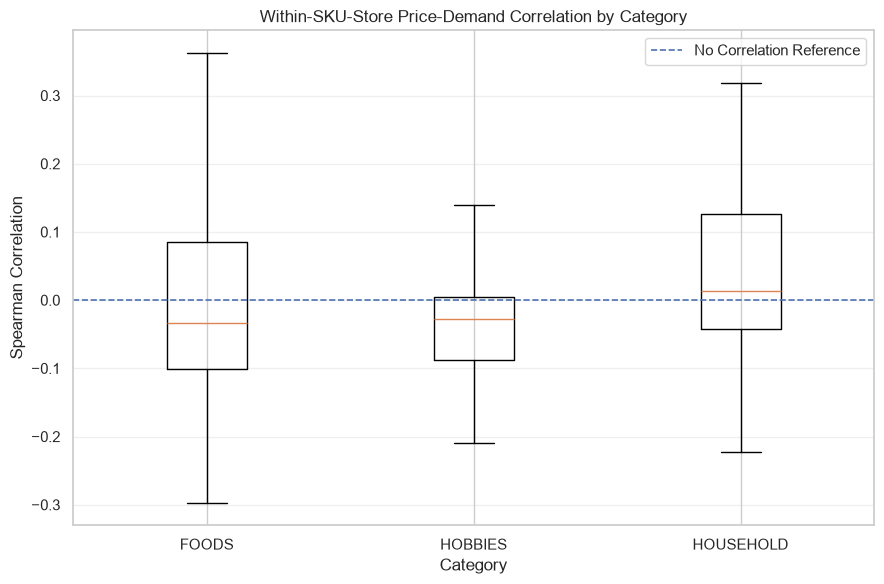

✅ Price-demand relationship figure created successfully.
Figure saved to: C:\Users\hp\Project FORESIGHT\reports\figures\02_19_price_demand_relationship_by_category.png


In [110]:
# Close the incomplete figure from the failed execution
plt.close("all")

# Keep SKU-store series with valid price-demand correlations
valid_relationship_data = (
    sku_store_price_demand_relationship
    .dropna(
        subset=[
            "price_demand_spearman_correlation"
        ]
    )
    .copy()
)

# Summarise correlations by category
category_price_demand_summary = (
    valid_relationship_data
    .groupby("category", as_index=False)
    .agg(
        valid_series=("sku_id", "nunique"),
        median_correlation=(
            "price_demand_spearman_correlation",
            "median",
        ),
        lower_quartile=(
            "price_demand_spearman_correlation",
            lambda values: values.quantile(0.25),
        ),
        upper_quartile=(
            "price_demand_spearman_correlation",
            lambda values: values.quantile(0.75),
        ),
        negative_relationship_share_pct=(
            "price_demand_spearman_correlation",
            lambda values: values.lt(0).mean() * 100,
        ),
    )
)

# Prepare the display table
category_price_demand_display = (
    category_price_demand_summary
    .rename(
        columns={
            "category": "Category",
            "valid_series": "Valid SKU-Store Series",
            "median_correlation": "Median Correlation",
            "lower_quartile": "25th Percentile",
            "upper_quartile": "75th Percentile",
            "negative_relationship_share_pct": (
                "Negative Relationship Share (%)"
            ),
        }
    )
    .round(3)
)

display(category_price_demand_display)

# Prepare category correlation distributions
category_order = [
    "FOODS",
    "HOBBIES",
    "HOUSEHOLD",
]

category_correlation_values = [
    valid_relationship_data.loc[
        valid_relationship_data["category"].eq(category),
        "price_demand_spearman_correlation",
    ].to_numpy()
    for category in category_order
]

# Use the project-level figure folder
figure_output_dir = Path(
    "../reports/figures"
).resolve()

figure_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Plot within-series correlations by category
fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    category_correlation_values,
    tick_labels=category_order,
    showfliers=False,
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2,
    label="No Correlation Reference",
)

ax.set_title(
    "Within-SKU-Store Price-Demand Correlation by Category"
)
ax.set_xlabel("Category")
ax.set_ylabel("Spearman Correlation")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()

# Save the figure
price_demand_figure_path = (
    figure_output_dir
    / "02_19_price_demand_relationship_by_category.png"
)

plt.savefig(
    price_demand_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Validate the saved output
assert price_demand_figure_path.exists()

print("✅ Price-demand relationship figure created successfully.")
print(f"Figure saved to: {price_demand_figure_path}")

### Price Behaviour and Demand Findings

- **Valid price coverage:** Positive selling prices were available for **85.74% of daily SKU-store records**. Zero-price records were excluded only from price analysis because they contained no sales or revenue.

- **Price stability:** Although **255 of 300 SKU-store series** recorded at least one price change, the median price-change frequency was only **0.10%**, indicating generally stable prices.

- **Price levels:** HOUSEHOLD had the highest typical prices, with a median price of **5.97** and a sales-weighted price of **5.00**.

- **Sales mix:** The overall sales-weighted price of **3.00** was below the simple average valid price of **4.38**, showing that demand was concentrated more heavily among lower-priced products.

- **Overall relationship:** The median within-SKU-store price-demand correlation was **−0.02**, indicating almost no consistent relationship across the portfolio.

- **Category patterns:** FOODS and HOBBIES had slightly negative median correlations of **−0.03**, while HOUSEHOLD had a near-zero positive median correlation of **0.01**.

- **Modelling implication:** Price should be retained as a forecasting feature, but its effect should be evaluated at the product or SKU-store level rather than represented by one portfolio-wide relationship.

> These correlations describe historical association. They do not estimate price elasticity or prove that price changes caused demand changes.

✅ Section 10.2: Price Behaviour and Demand Relationship is complete.

-----
## 10.3 Promotion, Event, and SNAP Demand Comparisons

Promotional periods, calendar events, and state-specific SNAP activity are evaluated in one consolidated driver comparison.

For each driver, the analysis will compare:

- average units sold;
- average revenue;
- selling-day frequency;
- percentage difference between active and inactive periods.

The results will identify whether these periods coincide with meaningful demand differences and whether the variables may be useful for forecasting.

> Higher demand during an active period does not prove that the promotion, event, or SNAP programme caused the increase.

In [111]:
# Define the binary demand drivers
driver_definitions = {
    "Promotion": "promo_flag",
    "Calendar Event": "event_flag",
    "State-Specific SNAP": "snap_flag",
}

driver_comparison_rows = []

for driver_name, driver_field in driver_definitions.items():

    inactive_data = demand_driver_base.loc[
        demand_driver_base[driver_field].eq(0)
    ]

    active_data = demand_driver_base.loc[
        demand_driver_base[driver_field].eq(1)
    ]

    # Calculate inactive-period measures
    inactive_avg_units = inactive_data["units_sold"].mean()
    inactive_avg_revenue = inactive_data["revenue"].mean()
    inactive_selling_frequency = (
        inactive_data["selling_day_flag"].mean() * 100
    )

    # Calculate active-period measures
    active_avg_units = active_data["units_sold"].mean()
    active_avg_revenue = active_data["revenue"].mean()
    active_selling_frequency = (
        active_data["selling_day_flag"].mean() * 100
    )

    # Calculate percentage differences
    demand_difference_pct = (
        (active_avg_units / inactive_avg_units - 1) * 100
        if inactive_avg_units > 0
        else np.nan
    )

    revenue_difference_pct = (
        (active_avg_revenue / inactive_avg_revenue - 1) * 100
        if inactive_avg_revenue > 0
        else np.nan
    )

    selling_frequency_difference_pp = (
        active_selling_frequency
        - inactive_selling_frequency
    )

    driver_comparison_rows.append(
        {
            "Driver": driver_name,
            "Active Records": len(active_data),
            "Active Share (%)": (
                len(active_data)
                / len(demand_driver_base)
                * 100
            ),
            "Inactive Avg Units": inactive_avg_units,
            "Active Avg Units": active_avg_units,
            "Demand Difference (%)": demand_difference_pct,
            "Inactive Avg Revenue": inactive_avg_revenue,
            "Active Avg Revenue": active_avg_revenue,
            "Revenue Difference (%)": revenue_difference_pct,
            "Inactive Selling Frequency (%)": (
                inactive_selling_frequency
            ),
            "Active Selling Frequency (%)": (
                active_selling_frequency
            ),
            "Selling Frequency Difference (pp)": (
                selling_frequency_difference_pp
            ),
        }
    )

# Create the consolidated comparison table
driver_comparison_summary = (
    pd.DataFrame(driver_comparison_rows)
    .round(2)
)

# Validate comparison coverage
assert len(driver_comparison_summary) == 3

for driver_field in driver_definitions.values():
    assert demand_driver_base[driver_field].nunique() == 2

display(driver_comparison_summary)

print("✅ Promotion, event, and SNAP comparisons prepared.")
print(
    "Drivers compared : "
    f"{len(driver_comparison_summary):,}"
)
print(
    "Response measures: "
    "average units, average revenue, and selling frequency"
)

,Driver,Active Records,Active Share (%),Inactive Avg Units,Active Avg Units,Demand Difference (%),Inactive Avg Revenue,Active Avg Revenue,Revenue Difference (%),Inactive Selling Frequency (%),Active Selling Frequency (%),Selling Frequency Difference (pp)
0,Promotion,2102,0.37,1.00,1.17,17.34,3.00,2.46,-17.95,33.63,33.02,-0.62
1,Calendar Event,46200,8.05,1.00,0.96,-4.81,3.01,2.84,-5.54,33.84,31.26,-2.58
2,State-Specific SNAP,283500,49.40,0.98,1.02,4.94,2.95,3.04,3.01,33.37,33.90,0.53


✅ Promotion, event, and SNAP comparisons prepared.
Drivers compared : 3
Response measures: average units, average revenue, and selling frequency


### Promotion, Event, and SNAP Findings

- **Promotion:** Promotional records showed **17.34% higher average units sold**, but **17.95% lower average revenue** than non-promotional records.

- **Promotion limitation:** Promotions covered only **0.37% of observations**, so the apparent demand increase should be treated as preliminary rather than a stable portfolio-wide effect.

- **Calendar events:** Event-day average demand was **4.81% lower**, average revenue was **5.54% lower**, and selling frequency declined by **2.58 percentage points**.

- **SNAP activity:** SNAP-active periods recorded **4.94% higher average demand**, **3.01% higher average revenue**, and a **0.53 percentage-point increase** in selling frequency.

- **Forecasting implication:** Event and SNAP indicators have sufficient coverage for later forecasting tests. Promotion may still be useful, but sparse observations require careful validation and possibly product-level treatment.

> These results describe historical group differences. They do not prove that promotions, events, or SNAP activity caused the observed demand changes.

✅ Section 10.3: Promotion, Event, and SNAP Demand Comparisons is complete.

-------
## 10.4 Demand-Driver Feature Screening

The available variables will be screened for possible use in later forecasting models.

Each driver will be reviewed using:

- observed demand difference;
- consistency of the relationship;
- data coverage;
- business interpretation;
- recommended modelling treatment;
- important limitations.

A broad correlation heatmap is not required. Focused driver-level evidence is more interpretable because the explanatory variables include both numerical and binary fields.

The output will classify each variable as:

- suitable for forecasting;
- suitable with caution;
- requiring transformation or interaction terms;
- unsuitable as a direct explanatory feature.

In [112]:
# Extract validated comparison results
promotion_result = (
    driver_comparison_summary.loc[
        driver_comparison_summary["Driver"].eq("Promotion")
    ]
    .iloc[0]
)

event_result = (
    driver_comparison_summary.loc[
        driver_comparison_summary["Driver"].eq("Calendar Event")
    ]
    .iloc[0]
)

snap_result = (
    driver_comparison_summary.loc[
        driver_comparison_summary["Driver"].eq(
            "State-Specific SNAP"
        )
    ]
    .iloc[0]
)

median_price_correlation = (
    valid_price_correlations.median()
)

# Screen the available forecasting drivers
demand_driver_feature_screening = pd.DataFrame(
    [
        {
            "Feature": "Selling Price",
            "Data Coverage": (
                f"{valid_price_share_pct:.2f}% valid-price records"
            ),
            "Observed Evidence": (
                f"Median within-SKU-store correlation: "
                f"{median_price_correlation:.2f}"
            ),
            "Screening Decision": "Suitable with caution",
            "Recommended Treatment": (
                "Use at product or SKU-store level; "
                "consider price changes and relative price."
            ),
            "Important Limitation": (
                "Relationship is weak and inconsistent; "
                "zero-price rows are unavailable-price observations."
            ),
        },
        {
            "Feature": "Promotion Flag",
            "Data Coverage": (
                f"{promotion_result['Active Share (%)']:.2f}% "
                "active records"
            ),
            "Observed Evidence": (
                f"{promotion_result['Demand Difference (%)']:.2f}% "
                "demand difference"
            ),
            "Screening Decision": "Suitable with caution",
            "Recommended Treatment": (
                "Retain as a binary feature and validate by "
                "product or category."
            ),
            "Important Limitation": (
                "Promotion observations are very sparse and "
                "revenue moved in the opposite direction."
            ),
        },
        {
            "Feature": "Calendar Event Flag",
            "Data Coverage": (
                f"{event_result['Active Share (%)']:.2f}% "
                "active records"
            ),
            "Observed Evidence": (
                f"{event_result['Demand Difference (%)']:.2f}% "
                "demand difference"
            ),
            "Screening Decision": "Suitable for forecasting tests",
            "Recommended Treatment": (
                "Retain the event flag and later test event-name "
                "or event-type features."
            ),
            "Important Limitation": (
                "Different events may have opposite effects, "
                "which a single flag can hide."
            ),
        },
        {
            "Feature": "State-Specific SNAP Flag",
            "Data Coverage": (
                f"{snap_result['Active Share (%)']:.2f}% "
                "active records"
            ),
            "Observed Evidence": (
                f"{snap_result['Demand Difference (%)']:.2f}% "
                "demand difference"
            ),
            "Screening Decision": "Suitable for forecasting tests",
            "Recommended Treatment": (
                "Use as a state-aware binary feature and test "
                "interactions with category and events."
            ),
            "Important Limitation": (
                "Observed differences may also reflect state, "
                "calendar, or product-mix effects."
            ),
        },
    ]
)

# Validate the screening output
assert len(demand_driver_feature_screening) == 4
assert (
    demand_driver_feature_screening
    .isna()
    .sum()
    .sum()
    == 0
)

display(demand_driver_feature_screening)

print("✅ Demand-driver features screened successfully.")
print(
    "Features reviewed: "
    f"{len(demand_driver_feature_screening):,}"
)
print(
    "Forecasting-test candidates: "
    f"{demand_driver_feature_screening['Screening Decision'].str.contains('forecasting').sum():,}"
)
print(
    "Features requiring caution: "
    f"{demand_driver_feature_screening['Screening Decision'].str.contains('caution').sum():,}"
)

,Feature,Data Coverage,Observed Evidence,Screening Decision,Recommended Treatment,Important Limitation
0,Selling Price,85.74% valid-price records,Median within-SKU-store correlation: -0.02,Suitable with caution,Use at product or SKU-store level; consider pr...,Relationship is weak and inconsistent; zero-pr...
1,Promotion Flag,0.37% active records,17.34% demand difference,Suitable with caution,Retain as a binary feature and validate by pro...,Promotion observations are very sparse and rev...
2,Calendar Event Flag,8.05% active records,-4.81% demand difference,Suitable for forecasting tests,Retain the event flag and later test event-nam...,"Different events may have opposite effects, wh..."
3,State-Specific SNAP Flag,49.40% active records,4.94% demand difference,Suitable for forecasting tests,Use as a state-aware binary feature and test i...,"Observed differences may also reflect state, c..."


✅ Demand-driver features screened successfully.
Features reviewed: 4
Forecasting-test candidates: 2
Features requiring caution: 2


### Demand-Driver Feature Screening Findings

- **Selling price:** Retain as a forecasting feature with caution. Its portfolio-wide relationship with demand is weak, so it should be modelled at the product or SKU-store level.

- **Promotion flag:** Retain for testing, but treat results cautiously because promotional observations represent only **0.37% of records**.

- **Calendar event flag:** Suitable for forecasting tests because it has sufficient coverage and event periods showed a measurable historical demand difference.

- **State-specific SNAP flag:** Suitable for forecasting tests because it has balanced coverage and SNAP-active periods were associated with moderately higher demand.

- **Feature-engineering priority:** Test event and SNAP indicators directly, while evaluating price and promotion using product-, category-, or store-specific interactions.

- **Modelling caution:** These screening decisions identify potentially useful predictors; they do not confirm future predictive performance.

✅ Section 10.4: Demand-Driver Feature Screening is complete.

## 10.5 Demand-Driver Summary

This subsection consolidates the principal findings from the price, promotion, event, and SNAP analyses.

The final summary will document:

- the observed relationship;
- supporting evidence;
- business interpretation;
- potential forecasting implication;
- limitation or caution.

Only one concise findings table and a short Markdown interpretation will be included.

In [113]:
# Consolidate the principal demand-driver findings
demand_driver_summary = pd.DataFrame(
    [
        {
            "Demand Driver": "Selling Price",
            "Observed Relationship": (
                "Weak and inconsistent relationship with demand"
            ),
            "Supporting Evidence": (
                f"Median within-SKU-store correlation: "
                f"{median_price_correlation:.2f}; "
                f"valid price coverage: {valid_price_share_pct:.2f}%."
            ),
            "Forecasting Implication": (
                "Retain price and price-change features at the "
                "product or SKU-store level."
            ),
            "Limitation": (
                "The result does not estimate price elasticity, "
                "and zero-price records represented unavailable prices."
            ),
        },
        {
            "Demand Driver": "Promotion",
            "Observed Relationship": (
                "Higher average demand but lower average revenue"
            ),
            "Supporting Evidence": (
                f"Demand difference: "
                f"{promotion_result['Demand Difference (%)']:.2f}%; "
                f"revenue difference: "
                f"{promotion_result['Revenue Difference (%)']:.2f}%."
            ),
            "Forecasting Implication": (
                "Retain the promotion flag and test interactions "
                "with product, category, and price."
            ),
            "Limitation": (
                f"Promotions covered only "
                f"{promotion_result['Active Share (%)']:.2f}% "
                "of records."
            ),
        },
        {
            "Demand Driver": "Calendar Event",
            "Observed Relationship": (
                "Event periods were associated with lower demand"
            ),
            "Supporting Evidence": (
                f"Demand difference: "
                f"{event_result['Demand Difference (%)']:.2f}%; "
                f"selling-frequency difference: "
                f"{event_result['Selling Frequency Difference (pp)']:.2f} pp."
            ),
            "Forecasting Implication": (
                "Test the event flag and later evaluate individual "
                "event names or event types."
            ),
            "Limitation": (
                "A single event flag may hide different effects "
                "across individual events."
            ),
        },
        {
            "Demand Driver": "State-Specific SNAP",
            "Observed Relationship": (
                "SNAP-active periods were associated with modestly "
                "higher demand"
            ),
            "Supporting Evidence": (
                f"Demand difference: "
                f"{snap_result['Demand Difference (%)']:.2f}%; "
                f"revenue difference: "
                f"{snap_result['Revenue Difference (%)']:.2f}%."
            ),
            "Forecasting Implication": (
                "Retain as a state-aware feature and test interactions "
                "with category and calendar variables."
            ),
            "Limitation": (
                "Observed differences may also reflect state, "
                "seasonal, or product-mix effects."
            ),
        },
        {
            "Demand Driver": "Overall Feature Screening",
            "Observed Relationship": (
                "All four examined drivers may provide modelling value"
            ),
            "Supporting Evidence": (
                "Event and SNAP were suitable for forecasting tests; "
                "price and promotion were suitable with caution."
            ),
            "Forecasting Implication": (
                "Validate all candidate features using time-based "
                "forecasting experiments."
            ),
            "Limitation": (
                "EDA associations do not guarantee future predictive "
                "performance or causal effects."
            ),
        },
    ]
)

# Validate the consolidated summary
assert len(demand_driver_summary) == 5
assert demand_driver_summary.isna().sum().sum() == 0

# Confirm completion without redisplaying
# the full text-heavy findings register
print("✅ Demand-driver findings consolidated successfully.")
print(
    f"Validated findings : "
    f"{len(demand_driver_summary):,}"
)
print(
    "✅ Section 10.5 completed: "
    "Demand-driver summary prepared."
)

✅ Demand-driver findings consolidated successfully.
Validated findings : 5
✅ Section 10.5 completed: Demand-driver summary prepared.


### Demand-Driver Summary

- **Selling price:** Price showed a weak and inconsistent relationship with demand, with a median within-SKU-store correlation of **−0.02**.

- **Promotion:** Promotional observations recorded **17.34% higher average demand** but **17.95% lower average revenue**. This result requires caution because promotions covered only **0.37% of records**.

- **Calendar events:** Event periods were associated with **4.81% lower average demand** and a **2.58 percentage-point reduction** in selling frequency.

- **SNAP activity:** SNAP-active periods recorded **4.94% higher average demand** and **3.01% higher average revenue**.

- **Forecasting priority:** Event and state-specific SNAP indicators are suitable for direct forecasting tests. Price and promotion should be retained with product-, store-, or category-level treatment.

- **Validation requirement:** Final feature usefulness must be evaluated through time-based forecasting experiments rather than EDA relationships alone.

> All findings describe historical associations. They do not establish causal effects or guarantee future predictive performance.

✅ Section 10.5: Demand-Driver Summary is complete.  
✅ Section 10: Demand Drivers is complete.

---
# 📦 11. Inventory and Demand Behaviour

This section examines simulated inventory conditions together with historical SKU-store demand behaviour.

The analysis focuses on:

- simulated inventory availability and coverage;
- low-stock, stockout, and excess-stock conditions;
- demand variability and intermittency;
- combined inventory-demand patterns relevant to forecasting and planning.

Weak-movement and dead-stock screening from Section 9 will be reused where relevant rather than recalculated.

## Business Question

**Which SKU-store series show inventory concern, unstable demand, or intermittent sales behaviour that may affect forecasting and inventory planning?**

## Objectives

- summarise simulated inventory position and status;
- evaluate inventory coverage using historical demand;
- measure SKU-store demand variability and intermittency;
- classify practical demand-behaviour segments;
- combine inventory and demand signals into preliminary planning groups;
- document forecasting and inventory implications without creating final risk scores.

## Analysis Structure

- **11.1:** Define the inventory and demand-behaviour scope.
- **11.2:** Summarise simulated inventory status and coverage.
- **11.3:** Measure demand variability and intermittency.
- **11.4:** Combine inventory and demand behaviour into planning segments.
- **11.5:** Consolidate forecasting and inventory implications.

> **Scope boundary:** Inventory records are simulated. This section provides descriptive screening only; final forecasts, risk scores, reorder quantities, and recommended actions will be developed in later notebooks.

---
## 11.1 Analysis Scope and Inventory Measures

The analysis uses the integrated daily SKU-store dataset and the latest simulated inventory snapshot.

The available inventory measures include:

- closing stock;
- inventory on order;
- reorder point and reorder quantity;
- lead time;
- target stock;
- inventory status;
- estimated inventory value.

Inventory coverage will be derived using the latest simulated closing stock and recent SKU-store demand rather than relying on a pre-existing coverage field.

Historical demand behaviour will later be evaluated using average demand, variability, selling frequency, zero-demand frequency, recent demand, and sales recency.

> Latest-snapshot inventory measures are kept separate from full-history demand measures to avoid mixing different analytical time levels.

In [114]:
# Define the latest simulated inventory date
latest_inventory_date = (
    analytics_base_daily["date"].max()
)

# Select fields required for the latest inventory snapshot
inventory_scope_fields = [
    "date",
    "sku_id",
    product_field,
    "store_id",
    "state_id",
    "category",
    "department",
    "sku_status",
    "closing_stock",
    "reorder_point",
    "reorder_quantity",
    "on_order_units",
    "lead_time_days",
    "target_stock",
    "inventory_status",
    "estimated_inventory_value",
]

# Extract one latest-date record per SKU-store series
latest_inventory_snapshot = (
    analytics_base_daily.loc[
        analytics_base_daily["date"].eq(
            latest_inventory_date
        ),
        inventory_scope_fields,
    ]
    .copy()
    .reset_index(drop=True)
)

# Define fields required for validation
critical_inventory_fields = [
    "sku_id",
    product_field,
    "store_id",
    "state_id",
    "closing_stock",
    "reorder_point",
    "reorder_quantity",
    "on_order_units",
    "lead_time_days",
    "target_stock",
    "inventory_status",
    "estimated_inventory_value",
]

# Validate the latest-snapshot grain and completeness
assert len(latest_inventory_snapshot) == 300

assert (
    latest_inventory_snapshot["sku_id"].nunique()
    == 300
)

assert (
    latest_inventory_snapshot["sku_id"]
    .duplicated()
    .sum()
    == 0
)

assert (
    latest_inventory_snapshot[
        critical_inventory_fields
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

# Prepare a concise validation table
inventory_scope_validation = pd.DataFrame(
    [
        {
            "Validation Check": "Latest Inventory Date",
            "Result": latest_inventory_date.date(),
        },
        {
            "Validation Check": "Latest Snapshot Records",
            "Result": len(latest_inventory_snapshot),
        },
        {
            "Validation Check": "Unique SKU-Store Series",
            "Result": (
                latest_inventory_snapshot[
                    "sku_id"
                ].nunique()
            ),
        },
        {
            "Validation Check": "Duplicate SKU-Store Series",
            "Result": (
                latest_inventory_snapshot[
                    "sku_id"
                ].duplicated()
                .sum()
            ),
        },
        {
            "Validation Check": "Missing Critical Values",
            "Result": (
                latest_inventory_snapshot[
                    critical_inventory_fields
                ]
                .isna()
                .sum()
                .sum()
            ),
        },
        {
            "Validation Check": "Inventory Status Levels",
            "Result": (
                latest_inventory_snapshot[
                    "inventory_status"
                ].nunique()
            ),
        },
    ]
)

display(inventory_scope_validation)

inventory_status_names = sorted(
    latest_inventory_snapshot[
        "inventory_status"
    ]
    .astype(str)
    .unique()
)

print("✅ Latest simulated inventory scope prepared.")
print(
    "Inventory statuses: "
    + ", ".join(inventory_status_names)
)

,Validation Check,Result
0,Latest Inventory Date,2016-04-24
1,Latest Snapshot Records,300
2,Unique SKU-Store Series,300
3,Duplicate SKU-Store Series,0
4,Missing Critical Values,0
5,Inventory Status Levels,4


✅ Latest simulated inventory scope prepared.
Inventory statuses: Healthy, Low Stock, Overstock, Stockout


### Inventory Analysis Scope Summary

- **Snapshot date:** Inventory analysis uses the latest simulated snapshot dated **24 April 2016**.

- **Analytical grain:** The snapshot contains exactly **300 unique SKU-store series**, with one record per series.

- **Data quality:** No duplicate series or missing values were found in the critical inventory fields.

- **Available statuses:** The simulated inventory records contain four conditions: **Healthy, Low Stock, Overstock, and Stockout**.

- **Scope control:** This subsection validates the inventory-analysis base only. Inventory quantities, values, and status distributions will be examined in Section 11.2.

> All inventory measures are simulated and represent analytical scenarios rather than observed retailer inventory.

✅ Section 11.1: Analysis Scope and Inventory Measures is complete.

---
## 11.2 Simulated Inventory Status and Coverage

This subsection combines the inventory overview, coverage analysis, low-stock observations, stockouts, and excess-stock observations into one workflow.

The analysis will summarise:

- latest simulated inventory quantity and value;
- low-stock, stockout, normal, and excess-stock statuses;
- inventory coverage distribution;
- concentration by category and store;
- demand associated with each inventory condition.

Only one consolidated status table and one supporting figure will be used.

> Inventory coverage and status are descriptive simulation outputs and must not be presented as observed retailer inventory performance.

In [115]:
# Reuse recent SKU-store demand measures from Section 9
recent_inventory_demand = (
    sku_store_movement_summary[
        [
            "sku_id",
            "recent_units_sold",
            "recent_observed_days",
            "recent_selling_frequency_pct",
            "days_since_last_sale",
        ]
    ]
    .copy()
)

recent_inventory_demand["recent_average_daily_demand"] = (
    recent_inventory_demand["recent_units_sold"]
    / recent_inventory_demand["recent_observed_days"]
)

# Combine latest inventory with recent demand
inventory_demand_snapshot = (
    latest_inventory_snapshot
    .merge(
        recent_inventory_demand,
        on="sku_id",
        how="left",
        validate="one_to_one",
    )
)

# Derive inventory coverage from recent demand
inventory_demand_snapshot["inventory_coverage_days"] = (
    inventory_demand_snapshot["closing_stock"]
    / inventory_demand_snapshot[
        "recent_average_daily_demand"
    ]
)

# Add total available simulated stock
inventory_demand_snapshot["available_plus_order_units"] = (
    inventory_demand_snapshot["closing_stock"]
    + inventory_demand_snapshot["on_order_units"]
)

# Summarise latest inventory conditions by status
inventory_status_summary = (
    inventory_demand_snapshot
    .groupby("inventory_status", as_index=False)
    .agg(
        sku_store_series=("sku_id", "nunique"),
        simulated_closing_stock=("closing_stock", "sum"),
        simulated_on_order_units=("on_order_units", "sum"),
        estimated_inventory_value=(
            "estimated_inventory_value",
            "sum",
        ),
        median_coverage_days=(
            "inventory_coverage_days",
            "median",
        ),
        median_recent_daily_demand=(
            "recent_average_daily_demand",
            "median",
        ),
        median_days_since_last_sale=(
            "days_since_last_sale",
            "median",
        ),
    )
)

# Add portfolio shares
inventory_status_summary["series_share_pct"] = (
    inventory_status_summary["sku_store_series"]
    / inventory_status_summary["sku_store_series"].sum()
    * 100
)

inventory_status_summary["inventory_value_share_pct"] = (
    inventory_status_summary["estimated_inventory_value"]
    / inventory_status_summary[
        "estimated_inventory_value"
    ].sum()
    * 100
)

# Arrange statuses in business order
inventory_status_order = [
    "Stockout",
    "Low Stock",
    "Healthy",
    "Overstock",
]

inventory_status_summary["inventory_status"] = pd.Categorical(
    inventory_status_summary["inventory_status"],
    categories=inventory_status_order,
    ordered=True,
)

inventory_status_summary = (
    inventory_status_summary
    .sort_values("inventory_status")
    .reset_index(drop=True)
)

# Prepare concise display table
inventory_status_display = (
    inventory_status_summary[
        [
            "inventory_status",
            "sku_store_series",
            "series_share_pct",
            "simulated_closing_stock",
            "simulated_on_order_units",
            "estimated_inventory_value",
            "inventory_value_share_pct",
            "median_coverage_days",
            "median_recent_daily_demand",
            "median_days_since_last_sale",
        ]
    ]
    .rename(
        columns={
            "inventory_status": "Inventory Status",
            "sku_store_series": "SKU-Store Series",
            "series_share_pct": "Series Share (%)",
            "simulated_closing_stock": (
                "Simulated Closing Stock"
            ),
            "simulated_on_order_units": (
                "Simulated On-Order Units"
            ),
            "estimated_inventory_value": (
                "Estimated Inventory Value"
            ),
            "inventory_value_share_pct": (
                "Inventory Value Share (%)"
            ),
            "median_coverage_days": (
                "Median Coverage Days"
            ),
            "median_recent_daily_demand": (
                "Median Recent Daily Demand"
            ),
            "median_days_since_last_sale": (
                "Median Days Since Last Sale"
            ),
        }
    )
    .round(2)
)

# Validate the combined analytical base
assert len(inventory_demand_snapshot) == 300

assert (
    inventory_demand_snapshot["sku_id"].nunique()
    == 300
)

assert (
    inventory_demand_snapshot[
        "recent_average_daily_demand"
    ].gt(0).all()
)

assert (
    inventory_status_summary["sku_store_series"].sum()
    == 300
)

display(inventory_status_display)

print("✅ Latest inventory status and coverage prepared.")
print(
    "SKU-store series analysed : "
    f"{len(inventory_demand_snapshot):,}"
)
print(
    "Inventory statuses        : "
    f"{len(inventory_status_summary):,}"
)
print(
    "Coverage range            : "
    f"{inventory_demand_snapshot['inventory_coverage_days'].min():,.2f} "
    "to "
    f"{inventory_demand_snapshot['inventory_coverage_days'].max():,.2f} days"
)

,Inventory Status,SKU-Store Series,Series Share (%),Simulated Closing Stock,Simulated On-Order Units,Estimated Inventory Value,Inventory Value Share (%),Median Coverage Days,Median Recent Daily Demand,Median Days Since Last Sale
0,Stockout,12,4.00,0,226,0.00,0.00,0.00,0.52,0.00
1,Low Stock,45,15.00,194,1036,416.36,2.94,5.87,0.53,0.00
2,Healthy,119,39.67,1649,0,"4,304.61",30.38,15.47,0.66,1.00
3,Overstock,124,41.33,4641,0,"9,449.58",66.68,26.62,0.64,1.00


✅ Latest inventory status and coverage prepared.
SKU-store series analysed : 300
Inventory statuses        : 4
Coverage range            : 0.00 to 565.20 days


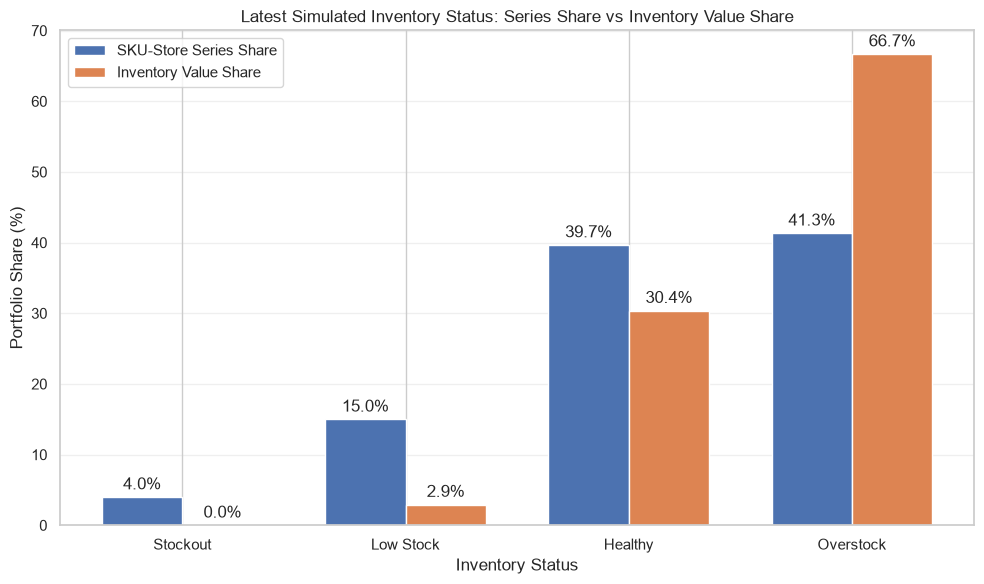

✅ Inventory-status figure created.
Figure saved to: C:\Users\hp\Project FORESIGHT\reports\figures\02_20_inventory_status_and_value_share.png


In [116]:
# Prepare inventory-status shares for plotting
inventory_status_plot = (
    inventory_status_summary[
        [
            "inventory_status",
            "series_share_pct",
            "inventory_value_share_pct",
        ]
    ]
    .copy()
)

status_labels = (
    inventory_status_plot["inventory_status"]
    .astype(str)
    .tolist()
)

x_positions = np.arange(
    len(inventory_status_plot)
)

bar_width = 0.36

# Create the consolidated status-share figure
fig, ax = plt.subplots(
    figsize=(10, 6)
)

series_bars = ax.bar(
    x_positions - bar_width / 2,
    inventory_status_plot["series_share_pct"],
    width=bar_width,
    label="SKU-Store Series Share",
)

value_bars = ax.bar(
    x_positions + bar_width / 2,
    inventory_status_plot[
        "inventory_value_share_pct"
    ],
    width=bar_width,
    label="Inventory Value Share",
)

# Add percentage labels
ax.bar_label(
    series_bars,
    fmt="%.1f%%",
    padding=3,
)

ax.bar_label(
    value_bars,
    fmt="%.1f%%",
    padding=3,
)

# Format the figure
ax.set_title(
    "Latest Simulated Inventory Status: "
    "Series Share vs Inventory Value Share"
)

ax.set_xlabel(
    "Inventory Status"
)

ax.set_ylabel(
    "Portfolio Share (%)"
)

ax.set_xticks(
    x_positions,
    status_labels,
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

# Save the figure to the project reports directory
figure_output_dir = Path(
    "../reports/figures"
).resolve()

figure_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

inventory_status_figure_path = (
    figure_output_dir
    / "02_20_inventory_status_and_value_share.png"
)

fig.savefig(
    inventory_status_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("✅ Inventory-status figure created.")
print(
    "Figure saved to: "
    f"{inventory_status_figure_path}"
)

### Simulated Inventory Status and Coverage Findings

- **Stockout exposure:** **12 SKU-store series (4.00%)** had zero simulated closing stock. These series had **226 units on order**, indicating simulated replenishment activity.

- **Low-stock exposure:** **45 series (15.00%)** were classified as Low Stock, with median inventory coverage of **5.87 days**.

- **Healthy inventory:** **119 series (39.67%)** were classified as Healthy and represented **30.38% of estimated simulated inventory value**.

- **Overstock concentration:** **124 series (41.33%)** were classified as Overstock but accounted for **66.68% of estimated simulated inventory value**.

- **Coverage pattern:** Median coverage increased from **0 days for Stockout** to **5.87 days for Low Stock**, **15.47 days for Healthy**, and **26.62 days for Overstock**.

- **Coverage caution:** The maximum coverage of **565.20 days** is likely influenced by extremely low recent demand and should be interpreted together with demand intermittency in Section 11.3.

- **Planning implication:** The simulated portfolio shows inventory imbalance at both ends—limited availability for some series and substantial value concentration in overstocked series.

> These results describe the latest simulated inventory snapshot and are not final stockout-risk, overstock-risk, or replenishment recommendations.

✅ Section 11.2: Simulated Inventory Status and Coverage is complete.

---
## 11.3 Demand Variability and Intermittency

Historical SKU-store demand behaviour will be evaluated using:

- average daily demand;
- demand standard deviation;
- coefficient of variation;
- active selling-day frequency;
- zero-demand frequency;
- recent demand and sales recency.

These measures will be used to distinguish relatively stable demand from variable, volatile, and intermittent patterns.

Thresholds will be selected from the observed distributions and documented before classification.

> Demand variability should be interpreted together with selling frequency because a high coefficient of variation may reflect intermittent sales rather than continuous volatility.

In [117]:
# Prepare daily demand observations in chronological order
demand_variability_base = (
    analytics_base_daily[
        [
            "date",
            "sku_id",
            product_field,
            "store_id",
            "state_id",
            "category",
            "department",
            "units_sold",
        ]
    ]
    .sort_values(
        ["sku_id", "date"]
    )
    .copy()
)

# Identify changes in daily demand within each series
demand_variability_base["demand_changed_flag"] = (
    demand_variability_base
    .groupby("sku_id")["units_sold"]
    .diff()
    .fillna(0)
    .ne(0)
    .astype("int8")
)

# Calculate new full-history variability measures
demand_variability_metrics = (
    demand_variability_base
    .groupby("sku_id", as_index=False)
    .agg(
        product_id=(product_field, "first"),
        store_id=("store_id", "first"),
        state_id=("state_id", "first"),
        category=("category", "first"),
        department=("department", "first"),
        observed_days=("date", "count"),
        average_daily_demand=("units_sold", "mean"),
        demand_standard_deviation=("units_sold", "std"),
        minimum_daily_demand=("units_sold", "min"),
        maximum_daily_demand=("units_sold", "max"),
        demand_change_days=("demand_changed_flag", "sum"),
    )
)

# Calculate coefficient of variation
demand_variability_metrics[
    "coefficient_of_variation"
] = (
    demand_variability_metrics[
        "demand_standard_deviation"
    ]
    / demand_variability_metrics[
        "average_daily_demand"
    ]
)

# Calculate frequency of day-to-day demand changes
demand_variability_metrics[
    "demand_change_frequency_pct"
] = (
    demand_variability_metrics[
        "demand_change_days"
    ]
    / (
        demand_variability_metrics[
            "observed_days"
        ]
        - 1
    )
    * 100
)

# Validate the new variability dataset
assert len(demand_variability_metrics) == 300
assert demand_variability_metrics["sku_id"].nunique() == 300

assert (
    demand_variability_metrics[
        [
            "average_daily_demand",
            "demand_standard_deviation",
            "coefficient_of_variation",
            "demand_change_frequency_pct",
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

print("✅ New demand-variability measures calculated.")
print(
    "SKU-store series analysed : "
    f"{len(demand_variability_metrics):,}"
)
print(
    "Historical date range      : "
    f"{demand_variability_base['date'].min().date()} "
    "to "
    f"{demand_variability_base['date'].max().date()}"
)
print(
    "New measures created       : "
    "average demand, standard deviation, "
    "coefficient of variation, demand-change frequency"
)

✅ New demand-variability measures calculated.
SKU-store series analysed : 300
Historical date range      : 2011-01-29 to 2016-04-24
New measures created       : average demand, standard deviation, coefficient of variation, demand-change frequency


In [118]:
# Select existing activity measures from Section 9
reusable_activity_metrics = (
    sku_store_movement_summary[
        [
            "sku_id",
            "observed_days",
            "active_selling_days",
            "recent_observed_days",
            "recent_units_sold",
            "recent_active_selling_days",
            "recent_selling_frequency_pct",
            "recent_zero_demand_frequency_pct",
            "last_sale_date",
            "days_since_last_sale",
        ]
    ]
    .copy()
)

# Combine new variability measures with existing activity measures
demand_behaviour_profile = (
    demand_variability_metrics
    .drop(columns=["observed_days"])
    .merge(
        reusable_activity_metrics,
        on="sku_id",
        how="left",
        validate="one_to_one",
    )
)

# Derive full-history frequencies from existing counts
demand_behaviour_profile[
    "full_history_selling_frequency_pct"
] = (
    demand_behaviour_profile["active_selling_days"]
    / demand_behaviour_profile["observed_days"]
    * 100
)

demand_behaviour_profile[
    "full_history_zero_demand_frequency_pct"
] = (
    100
    - demand_behaviour_profile[
        "full_history_selling_frequency_pct"
    ]
)

# Define measures used for threshold selection
behaviour_distribution_fields = [
    "average_daily_demand",
    "demand_standard_deviation",
    "coefficient_of_variation",
    "demand_change_frequency_pct",
    "full_history_selling_frequency_pct",
    "recent_selling_frequency_pct",
    "recent_zero_demand_frequency_pct",
    "recent_units_sold",
    "days_since_last_sale",
]

# Review the observed distributions
demand_behaviour_distribution = (
    demand_behaviour_profile[
        behaviour_distribution_fields
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
    .T
    .reset_index()
    .rename(
        columns={
            "index": "Demand Behaviour Measure",
            "count": "Series Count",
            "mean": "Mean",
            "std": "Standard Deviation",
            "min": "Minimum",
            "25%": "25th Percentile",
            "50%": "Median",
            "75%": "75th Percentile",
            "90%": "90th Percentile",
            "95%": "95th Percentile",
            "max": "Maximum",
        }
    )
    .round(2)
)

# Validate the combined behaviour profile
assert len(demand_behaviour_profile) == 300

assert (
    demand_behaviour_profile["sku_id"].nunique()
    == 300
)

assert (
    demand_behaviour_profile[
        behaviour_distribution_fields
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

display(demand_behaviour_distribution)

print("✅ Demand-behaviour distributions prepared.")
print(
    "SKU-store series reviewed : "
    f"{len(demand_behaviour_profile):,}"
)
print(
    "Measures reviewed         : "
    f"{len(behaviour_distribution_fields):,}"
)
print(
    "Next step                 : "
    "select documented segmentation thresholds"
)

,Demand Behaviour Measure,Series Count,Mean,Standard Deviation,Minimum,25th Percentile,Median,75th Percentile,90th Percentile,95th Percentile,Maximum
0,average_daily_demand,300.00,1.00,1.54,0.01,0.26,0.48,1.05,1.93,4.73,9.78
1,demand_standard_deviation,300.00,1.47,1.76,0.14,0.63,0.95,1.52,2.43,5.02,11.21
2,coefficient_of_variation,300.00,2.14,1.01,0.69,1.46,1.99,2.57,3.23,3.86,10.60
3,demand_change_frequency_pct,300.00,41.43,18.72,1.26,25.85,41.40,58.51,66.11,71.35,86.66
4,full_history_selling_frequency_pct,300.00,33.63,19.21,1.05,17.59,30.48,47.94,63.64,66.36,86.30
5,recent_selling_frequency_pct,300.00,39.58,22.62,1.11,21.11,37.78,55.83,70.11,80.00,96.67
6,recent_zero_demand_frequency_pct,300.00,60.42,22.62,3.33,44.17,62.22,78.89,90.00,93.33,98.89
7,recent_units_sold,300.00,82.91,104.04,2.00,26.75,56.50,101.25,170.10,234.20,953.00
8,days_since_last_sale,300.00,6.85,18.97,0.00,0.00,1.00,3.00,10.10,76.10,86.00


✅ Demand-behaviour distributions prepared.
SKU-store series reviewed : 300
Measures reviewed         : 9
Next step                 : select documented segmentation thresholds


In [119]:
# Define distribution-based behaviour thresholds
inactive_recency_threshold = (
    demand_behaviour_profile[
        "days_since_last_sale"
    ].quantile(0.95)
)

intermittent_frequency_threshold = (
    demand_behaviour_profile[
        "recent_selling_frequency_pct"
    ].quantile(0.25)
)

stable_cv_threshold = (
    demand_behaviour_profile[
        "coefficient_of_variation"
    ].quantile(0.25)
)

volatile_cv_threshold = (
    demand_behaviour_profile[
        "coefficient_of_variation"
    ].quantile(0.75)
)

# Define mutually exclusive behaviour conditions
behaviour_conditions = [
    demand_behaviour_profile[
        "days_since_last_sale"
    ].ge(inactive_recency_threshold),

    demand_behaviour_profile[
        "recent_selling_frequency_pct"
    ].le(intermittent_frequency_threshold),

    demand_behaviour_profile[
        "coefficient_of_variation"
    ].le(stable_cv_threshold),

    demand_behaviour_profile[
        "coefficient_of_variation"
    ].gt(volatile_cv_threshold),
]

behaviour_labels = [
    "Very Low / Inactive Demand",
    "Intermittent Demand",
    "Stable Demand",
    "Volatile Demand",
]

# Assign one behaviour segment to every series
demand_behaviour_profile[
    "demand_behaviour_segment"
] = np.select(
    behaviour_conditions,
    behaviour_labels,
    default="Variable Demand",
)

segment_order = [
    "Stable Demand",
    "Variable Demand",
    "Volatile Demand",
    "Intermittent Demand",
    "Very Low / Inactive Demand",
]

demand_behaviour_profile[
    "demand_behaviour_segment"
] = pd.Categorical(
    demand_behaviour_profile[
        "demand_behaviour_segment"
    ],
    categories=segment_order,
    ordered=True,
)

# Document the selected thresholds
demand_behaviour_thresholds = pd.DataFrame(
    [
        {
            "Segmentation Rule": "Very Low / Inactive Demand",
            "Threshold Basis": "Days since last sale ≥ 95th percentile",
            "Threshold Value": inactive_recency_threshold,
        },
        {
            "Segmentation Rule": "Intermittent Demand",
            "Threshold Basis": (
                "Recent selling frequency ≤ 25th percentile"
            ),
            "Threshold Value": intermittent_frequency_threshold,
        },
        {
            "Segmentation Rule": "Stable Demand",
            "Threshold Basis": (
                "Coefficient of variation ≤ 25th percentile"
            ),
            "Threshold Value": stable_cv_threshold,
        },
        {
            "Segmentation Rule": "Volatile Demand",
            "Threshold Basis": (
                "Coefficient of variation > 75th percentile"
            ),
            "Threshold Value": volatile_cv_threshold,
        },
        {
            "Segmentation Rule": "Variable Demand",
            "Threshold Basis": (
                "Series not captured by the other rules"
            ),
            "Threshold Value": np.nan,
        },
    ]
).round(2)

# Validate segmentation completeness
assert (
    demand_behaviour_profile[
        "demand_behaviour_segment"
    ]
    .isna()
    .sum()
    == 0
)

assert (
    len(demand_behaviour_profile)
    == 300
)

segment_count_check = (
    demand_behaviour_profile[
        "demand_behaviour_segment"
    ]
    .value_counts(sort=False)
    .rename_axis("Demand Behaviour Segment")
    .reset_index(name="SKU-Store Series")
)

segment_count_check["Series Share (%)"] = (
    segment_count_check["SKU-Store Series"]
    / len(demand_behaviour_profile)
    * 100
).round(2)

display(demand_behaviour_thresholds)
display(segment_count_check)

print("✅ Demand-behaviour segments assigned.")
print(
    "Classified series : "
    f"{segment_count_check['SKU-Store Series'].sum():,}"
)
print(
    "Segments created  : "
    f"{segment_count_check['Demand Behaviour Segment'].nunique():,}"
)

,Segmentation Rule,Threshold Basis,Threshold Value
0,Very Low / Inactive Demand,Days since last sale ≥ 95th percentile,76.10
1,Intermittent Demand,Recent selling frequency ≤ 25th percentile,21.11
2,Stable Demand,Coefficient of variation ≤ 25th percentile,1.46
3,Volatile Demand,Coefficient of variation > 75th percentile,2.57
4,Variable Demand,Series not captured by the other rules,NaN


,Demand Behaviour Segment,SKU-Store Series,Series Share (%)
0,Stable Demand,65,21.67
1,Variable Demand,122,40.67
2,Volatile Demand,34,11.33
3,Intermittent Demand,64,21.33
4,Very Low / Inactive Demand,15,5.00


✅ Demand-behaviour segments assigned.
Classified series : 300
Segments created  : 5


In [120]:
# Summarise demand behaviour by segment
demand_behaviour_segment_summary = (
    demand_behaviour_profile
    .groupby(
        "demand_behaviour_segment",
        observed=True,
        as_index=False,
    )
    .agg(
        sku_store_series=("sku_id", "nunique"),
        median_average_daily_demand=(
            "average_daily_demand",
            "median",
        ),
        median_coefficient_of_variation=(
            "coefficient_of_variation",
            "median",
        ),
        median_demand_change_frequency_pct=(
            "demand_change_frequency_pct",
            "median",
        ),
        median_recent_selling_frequency_pct=(
            "recent_selling_frequency_pct",
            "median",
        ),
        median_recent_zero_demand_frequency_pct=(
            "recent_zero_demand_frequency_pct",
            "median",
        ),
        median_recent_units_sold=(
            "recent_units_sold",
            "median",
        ),
        median_days_since_last_sale=(
            "days_since_last_sale",
            "median",
        ),
    )
)

# Calculate each segment's portfolio share
total_behaviour_series = len(
    demand_behaviour_profile
)

demand_behaviour_segment_summary[
    "series_share_pct"
] = (
    demand_behaviour_segment_summary[
        "sku_store_series"
    ]
    .div(total_behaviour_series)
    .mul(100)
)

# Preserve the documented segment order
demand_behaviour_segment_summary[
    "demand_behaviour_segment"
] = pd.Categorical(
    demand_behaviour_segment_summary[
        "demand_behaviour_segment"
    ],
    categories=segment_order,
    ordered=True,
)

demand_behaviour_segment_summary = (
    demand_behaviour_segment_summary
    .sort_values(
        "demand_behaviour_segment"
    )
    .reset_index(drop=True)
)

# Prepare a concise display table
demand_behaviour_segment_display = (
    demand_behaviour_segment_summary[
        [
            "demand_behaviour_segment",
            "sku_store_series",
            "series_share_pct",
            "median_average_daily_demand",
            "median_coefficient_of_variation",
            "median_recent_selling_frequency_pct",
            "median_recent_zero_demand_frequency_pct",
            "median_recent_units_sold",
            "median_days_since_last_sale",
        ]
    ]
    .rename(
        columns={
            "demand_behaviour_segment": (
                "Demand Behaviour Segment"
            ),
            "sku_store_series": (
                "SKU-Store Series"
            ),
            "series_share_pct": (
                "Series Share (%)"
            ),
            "median_average_daily_demand": (
                "Median Average Daily Demand"
            ),
            "median_coefficient_of_variation": (
                "Median Coefficient of Variation"
            ),
            "median_recent_selling_frequency_pct": (
                "Median Recent Selling Frequency (%)"
            ),
            "median_recent_zero_demand_frequency_pct": (
                "Median Recent Zero-Demand Frequency (%)"
            ),
            "median_recent_units_sold": (
                "Median Recent Units Sold"
            ),
            "median_days_since_last_sale": (
                "Median Days Since Last Sale"
            ),
        }
    )
    .round(2)
)

# Validate the segment summary
assert len(
    demand_behaviour_segment_summary
) == 5

assert (
    demand_behaviour_segment_summary[
        "sku_store_series"
    ].sum()
    == 300
)

assert (
    demand_behaviour_segment_display
    .isna()
    .sum()
    .sum()
    == 0
)

display(
    demand_behaviour_segment_display
)

print(
    "✅ Demand-behaviour segment profiles prepared."
)
print(
    "Segments summarised : "
    f"{len(demand_behaviour_segment_summary):,}"
)
print(
    "Series represented  : "
    f"{demand_behaviour_segment_summary['sku_store_series'].sum():,}"
)

,Demand Behaviour Segment,SKU-Store Series,Series Share (%),Median Average Daily Demand,Median Coefficient of Variation,Median Recent Selling Frequency (%),Median Recent Zero-Demand Frequency (%),Median Recent Units Sold,Median Days Since Last Sale
0,Stable Demand,65,21.67,1.39,1.25,63.33,36.67,130.00,0.00
1,Variable Demand,122,40.67,0.52,1.91,43.33,56.67,67.50,0.00
2,Volatile Demand,34,11.33,0.18,2.97,29.44,70.56,35.50,1.00
3,Intermittent Demand,64,21.33,0.21,2.67,13.33,86.67,16.50,3.00
4,Very Low / Inactive Demand,15,5.00,0.66,2.16,5.56,94.44,12.00,81.00


✅ Demand-behaviour segment profiles prepared.
Segments summarised : 5
Series represented  : 300


### Demand Variability and Intermittency Findings

- **Stable demand:** **65 SKU-store series (21.67%)** showed the lowest relative variability, with a median coefficient of variation of **1.25**. These series also recorded the highest median recent selling frequency at **63.33%**.

- **Variable demand:** **122 series (40.67%)** formed the largest segment. Their median coefficient of variation was **1.91**, with demand recorded on **43.33%** of recent days.

- **Volatile demand:** **34 series (11.33%)** showed a median coefficient of variation of **2.97**, indicating large fluctuations relative to their average demand.

- **Intermittent demand:** **64 series (21.33%)** recorded sales on only **13.33%** of recent days and had a median zero-demand frequency of **86.67%**.

- **Very low or recently inactive demand:** **15 series (5.00%)** had a median of **81 days since the latest sale** and a recent selling frequency of only **5.56%**.

- **Forecasting implication:** Stable series may support conventional forecasting methods, while volatile and intermittent series will require greater uncertainty allowances or specialised forecasting treatment.

- **Interpretation caution:** The behaviour segments are relative portfolio classifications based on observed distribution thresholds. They are separate from the product movement classes developed in Section 9.

✅ Section 11.3: Demand Variability and Intermittency is complete.

---
## 11.4 Inventory–Demand Planning Segmentation

Inventory conditions and demand behaviour will be combined into practical planning segments.

Examples may include:

- fast or stable demand with limited inventory;
- volatile demand requiring greater uncertainty allowance;
- intermittent demand requiring specialised forecasting treatment;
- weak movement with comparatively high inventory;
- adequate inventory with no immediate concern.

The weak-movement watchlist created in Section 9 will be reused rather than recalculated.

> These segments are preliminary analytical labels. They are not final stockout-risk, overstock-risk, or replenishment recommendations.

In [121]:
# Select the new demand-behaviour fields
behaviour_fields_for_planning = [
    "sku_id",
    "demand_behaviour_segment",
    "average_daily_demand",
    "coefficient_of_variation",
    "demand_change_frequency_pct",
    "full_history_selling_frequency_pct",
]

# Combine inventory and demand behaviour
inventory_demand_planning_base = (
    inventory_demand_snapshot
    .merge(
        demand_behaviour_profile[
            behaviour_fields_for_planning
        ],
        on="sku_id",
        how="left",
        validate="one_to_one",
    )
)

# Reuse the Section 9 watchlist without recalculating it
weak_watchlist_skus = set(
    weak_inventory_watchlist["sku_id"]
)

inventory_demand_planning_base[
    "weak_inventory_watchlist_flag"
] = (
    inventory_demand_planning_base["sku_id"]
    .isin(weak_watchlist_skus)
    .astype("int8")
)

# Define combined inventory-demand conditions
limited_inventory_flag = (
    inventory_demand_planning_base[
        "inventory_status"
    ]
    .isin(
        [
            "Stockout",
            "Low Stock",
        ]
    )
)

irregular_demand_flag = (
    inventory_demand_planning_base[
        "demand_behaviour_segment"
    ]
    .isin(
        [
            "Intermittent Demand",
            "Very Low / Inactive Demand",
        ]
    )
)

forecast_attention_flag = (
    inventory_demand_planning_base[
        "demand_behaviour_segment"
    ]
    .isin(
        [
            "Volatile Demand",
            "Intermittent Demand",
            "Very Low / Inactive Demand",
        ]
    )
)

overstock_flag = (
    inventory_demand_planning_base[
        "inventory_status"
    ]
    .eq("Overstock")
)

healthy_inventory_flag = (
    inventory_demand_planning_base[
        "inventory_status"
    ]
    .eq("Healthy")
)

weak_watchlist_flag = (
    inventory_demand_planning_base[
        "weak_inventory_watchlist_flag"
    ]
    .eq(1)
)

# Assign one preliminary planning segment per series
planning_conditions = [
    limited_inventory_flag
    & ~irregular_demand_flag,

    limited_inventory_flag
    & irregular_demand_flag,

    overstock_flag
    & (
        irregular_demand_flag
        | weak_watchlist_flag
    ),

    overstock_flag,

    healthy_inventory_flag
    & forecast_attention_flag,
]

planning_labels = [
    "Availability Priority",
    "Limited Stock / Irregular Demand",
    "Overstock / Weak-Demand Review",
    "Overstock / Active-Demand Review",
    "Healthy Stock / Forecasting Attention",
]

inventory_demand_planning_base[
    "inventory_demand_planning_segment"
] = np.select(
    planning_conditions,
    planning_labels,
    default="Balanced / Routine Monitoring",
)

# Validate segmentation completeness
assert len(
    inventory_demand_planning_base
) == 300

assert (
    inventory_demand_planning_base[
        "sku_id"
    ].nunique()
    == 300
)

assert (
    inventory_demand_planning_base[
        "inventory_demand_planning_segment"
    ]
    .isna()
    .sum()
    == 0
)

# Review the preliminary segment distribution
planning_segment_count = (
    inventory_demand_planning_base[
        "inventory_demand_planning_segment"
    ]
    .value_counts()
    .rename_axis(
        "Inventory-Demand Planning Segment"
    )
    .reset_index(
        name="SKU-Store Series"
    )
)

planning_segment_count[
    "Series Share (%)"
] = (
    planning_segment_count[
        "SKU-Store Series"
    ]
    .div(
        len(inventory_demand_planning_base)
    )
    .mul(100)
    .round(2)
)

display(planning_segment_count)

print("✅ Inventory-demand planning segments assigned.")
print(
    "Classified series : "
    f"{planning_segment_count['SKU-Store Series'].sum():,}"
)
print(
    "Segments created  : "
    f"{len(planning_segment_count):,}"
)
print(
    "Section 9 watchlist flags reused: "
    f"{inventory_demand_planning_base['weak_inventory_watchlist_flag'].sum():,}"
)

,Inventory-Demand Planning Segment,SKU-Store Series,Series Share (%)
0,Overstock / Active-Demand Review,84,28.00
1,Balanced / Routine Monitoring,80,26.67
2,Availability Priority,47,15.67
3,Overstock / Weak-Demand Review,40,13.33
4,Healthy Stock / Forecasting Attention,39,13.00
5,Limited Stock / Irregular Demand,10,3.33


✅ Inventory-demand planning segments assigned.
Classified series : 300
Segments created  : 6
Section 9 watchlist flags reused: 63


In [122]:
# Define the business order for planning segments
planning_segment_order = [
    "Availability Priority",
    "Limited Stock / Irregular Demand",
    "Balanced / Routine Monitoring",
    "Healthy Stock / Forecasting Attention",
    "Overstock / Active-Demand Review",
    "Overstock / Weak-Demand Review",
]

# Summarise combined inventory-demand characteristics
inventory_demand_planning_summary = (
    inventory_demand_planning_base
    .groupby(
        "inventory_demand_planning_segment",
        as_index=False,
    )
    .agg(
        sku_store_series=("sku_id", "nunique"),
        simulated_closing_stock=("closing_stock", "sum"),
        simulated_on_order_units=("on_order_units", "sum"),
        estimated_inventory_value=(
            "estimated_inventory_value",
            "sum",
        ),
        median_inventory_coverage_days=(
            "inventory_coverage_days",
            "median",
        ),
        median_recent_daily_demand=(
            "recent_average_daily_demand",
            "median",
        ),
        median_recent_selling_frequency_pct=(
            "recent_selling_frequency_pct",
            "median",
        ),
        median_days_since_last_sale=(
            "days_since_last_sale",
            "median",
        ),
        section_9_watchlist_series=(
            "weak_inventory_watchlist_flag",
            "sum",
        ),
    )
)

# Calculate portfolio shares
total_planning_series = len(
    inventory_demand_planning_base
)

total_planning_inventory_value = (
    inventory_demand_planning_summary[
        "estimated_inventory_value"
    ].sum()
)

inventory_demand_planning_summary[
    "series_share_pct"
] = (
    inventory_demand_planning_summary[
        "sku_store_series"
    ]
    .div(total_planning_series)
    .mul(100)
)

inventory_demand_planning_summary[
    "inventory_value_share_pct"
] = (
    inventory_demand_planning_summary[
        "estimated_inventory_value"
    ]
    .div(total_planning_inventory_value)
    .mul(100)
)

# Preserve the documented planning order
inventory_demand_planning_summary[
    "inventory_demand_planning_segment"
] = pd.Categorical(
    inventory_demand_planning_summary[
        "inventory_demand_planning_segment"
    ],
    categories=planning_segment_order,
    ordered=True,
)

inventory_demand_planning_summary = (
    inventory_demand_planning_summary
    .sort_values(
        "inventory_demand_planning_segment"
    )
    .reset_index(drop=True)
)

# Prepare the concise display table
inventory_demand_planning_display = (
    inventory_demand_planning_summary[
        [
            "inventory_demand_planning_segment",
            "sku_store_series",
            "series_share_pct",
            "estimated_inventory_value",
            "inventory_value_share_pct",
            "median_inventory_coverage_days",
            "median_recent_daily_demand",
            "median_recent_selling_frequency_pct",
            "median_days_since_last_sale",
            "section_9_watchlist_series",
        ]
    ]
    .rename(
        columns={
            "inventory_demand_planning_segment": (
                "Inventory-Demand Planning Segment"
            ),
            "sku_store_series": "SKU-Store Series",
            "series_share_pct": "Series Share (%)",
            "estimated_inventory_value": (
                "Estimated Inventory Value"
            ),
            "inventory_value_share_pct": (
                "Inventory Value Share (%)"
            ),
            "median_inventory_coverage_days": (
                "Median Coverage Days"
            ),
            "median_recent_daily_demand": (
                "Median Recent Daily Demand"
            ),
            "median_recent_selling_frequency_pct": (
                "Median Recent Selling Frequency (%)"
            ),
            "median_days_since_last_sale": (
                "Median Days Since Last Sale"
            ),
            "section_9_watchlist_series": (
                "Section 9 Watchlist Series"
            ),
        }
    )
    .round(2)
)

# Validate the planning summary
assert len(
    inventory_demand_planning_summary
) == 6

assert (
    inventory_demand_planning_summary[
        "sku_store_series"
    ].sum()
    == 300
)

assert (
    inventory_demand_planning_summary[
        "section_9_watchlist_series"
    ].sum()
    == 63
)

assert (
    inventory_demand_planning_display
    .isna()
    .sum()
    .sum()
    == 0
)

display(
    inventory_demand_planning_display
)

print("✅ Inventory-demand planning profiles prepared.")
print(
    "Planning segments summarised : "
    f"{len(inventory_demand_planning_summary):,}"
)
print(
    "Series represented           : "
    f"{inventory_demand_planning_summary['sku_store_series'].sum():,}"
)
print(
    "Section 9 watchlist reused   : "
    f"{inventory_demand_planning_summary['section_9_watchlist_series'].sum():,}"
)

,Inventory-Demand Planning Segment,SKU-Store Series,Series Share (%),Estimated Inventory Value,Inventory Value Share (%),Median Coverage Days,Median Recent Daily Demand,Median Recent Selling Frequency (%),Median Days Since Last Sale,Section 9 Watchlist Series
0,Availability Priority,47,15.67,381.75,2.69,3.38,0.74,43.33,0.00,0
1,Limited Stock / Irregular Demand,10,3.33,34.61,0.24,8.53,0.18,13.89,0.00,5
2,Balanced / Routine Monitoring,80,26.67,"3,424.27",24.16,12.71,0.90,50.00,0.00,0
3,Healthy Stock / Forecasting Attention,39,13.00,880.34,6.21,30.00,0.19,13.33,4.00,26
4,Overstock / Active-Demand Review,84,28.00,"6,357.90",44.87,24.28,0.84,48.89,0.50,0
5,Overstock / Weak-Demand Review,40,13.33,"3,091.68",21.82,59.01,0.20,12.22,8.00,32


✅ Inventory-demand planning profiles prepared.
Planning segments summarised : 6
Series represented           : 300
Section 9 watchlist reused   : 63


### Inventory–Demand Planning Findings

- **Availability concern:** **47 series** had active demand but only **3.38 median coverage days**.
- **Balanced position:** **80 series** showed comparatively stable inventory and demand conditions.
- **Overstock concern:** **40 weak-demand series** held **21.82% of simulated inventory value** with **59.01 median coverage days**.
- **Active overstock:** **84 series** held **44.87% of inventory value**, but continued demand means they should be reviewed rather than automatically marked down.
- All **63 Section 9 watchlist series** were reused without recalculation.

> These are descriptive EDA segments. Final risk scores and recommendations will be developed in Notebook 07.

✅ Section 11.4: Inventory–Demand Planning Segmentation is complete.

---
## 11.5 Forecasting and Inventory Implications

This subsection consolidates the most useful inventory and demand-behaviour findings.

The final summary will document:

- inventory-status distribution;
- coverage concerns;
- stable, variable, volatile, and intermittent demand counts;
- important combined inventory-demand patterns;
- forecasting treatment;
- inventory-planning implication;
- limitation or caution.

Only one concise findings table and one short Markdown interpretation will be included.

In [123]:
# Convert planning segments into modelling and inventory implications
inventory_demand_implications = pd.DataFrame(
    [
        {
            "Planning Segment": "Availability Priority",
            "Forecasting Treatment": (
                "Use recent demand with forecast uncertainty."
            ),
            "Inventory Implication": (
                "Prioritise forecast-based stockout assessment."
            ),
            "Important Caution": (
                "Final reorder quantities require lead-time forecasts."
            ),
        },
        {
            "Planning Segment": (
                "Limited Stock / Irregular Demand"
            ),
            "Forecasting Treatment": (
                "Test intermittent-demand forecasting methods."
            ),
            "Inventory Implication": (
                "Review manually before replenishment."
            ),
            "Important Caution": (
                "Low stock does not always mean urgent demand."
            ),
        },
        {
            "Planning Segment": (
                "Balanced / Routine Monitoring"
            ),
            "Forecasting Treatment": (
                "Suitable for standard forecasting comparison."
            ),
            "Inventory Implication": (
                "Continue routine monitoring."
            ),
            "Important Caution": (
                "Future conditions may still change."
            ),
        },
        {
            "Planning Segment": (
                "Healthy Stock / Forecasting Attention"
            ),
            "Forecasting Treatment": (
                "Use wider uncertainty allowances."
            ),
            "Inventory Implication": (
                "Monitor demand behaviour rather than inventory alone."
            ),
            "Important Caution": (
                "Adequate stock can hide forecasting difficulty."
            ),
        },
        {
            "Planning Segment": (
                "Overstock / Active-Demand Review"
            ),
            "Forecasting Treatment": (
                "Validate expected future demand before action."
            ),
            "Inventory Implication": (
                "Review stock levels without automatic markdown."
            ),
            "Important Caution": (
                "Active demand may absorb current inventory."
            ),
        },
        {
            "Planning Segment": (
                "Overstock / Weak-Demand Review"
            ),
            "Forecasting Treatment": (
                "Use intermittent-demand and confidence checks."
            ),
            "Inventory Implication": (
                "Prioritise final overstock and markdown assessment."
            ),
            "Important Caution": (
                "Final action requires forward demand forecasts."
            ),
        },
    ]
)

# Validate implication coverage
assert len(inventory_demand_implications) == 6

assert set(
    inventory_demand_implications[
        "Planning Segment"
    ]
) == set(planning_segment_order)

assert (
    inventory_demand_implications
    .isna()
    .sum()
    .sum()
    == 0
)

# Confirm completion without redisplaying
# the full text-heavy implications table
print("✅ Forecasting and inventory implications prepared.")
print(
    f"Planning segments covered : "
    f"{len(inventory_demand_implications):,}"
)
print(
    "✅ Section 11.5 completed: "
    "Forecasting and inventory implications consolidated."
)

✅ Forecasting and inventory implications prepared.
Planning segments covered : 6
✅ Section 11.5 completed: Forecasting and inventory implications consolidated.


### Forecasting and Inventory Implications

- Stable and balanced series can proceed through standard forecasting evaluation.
- Volatile and intermittent series require uncertainty-aware or specialised forecasting treatment.
- Limited inventory should be assessed against future lead-time demand before replenishment decisions.
- Overstock cases must be separated between active-demand and weak-demand products.
- Final risk scores, reorder quantities, markdown actions, and financial exposure belong to Notebook 07.

> Inventory findings remain simulation-based and descriptive.

✅ Section 11.5: Forecasting and Inventory Implications is complete.  
✅ Section 11: Inventory and Demand Behaviour is complete.

---
# 🎯 12. Business Insights, Recommendations, and EDA Insight Memo

This section converts the strongest validated EDA findings into prioritised business recommendations and prepares the stakeholder-facing EDA insight memo.

Only distinct, evidence-based findings will be retained. Recommendations remain exploratory and will not replace the forecast-based risk scoring and inventory decisions developed in Notebook 07.

## Objectives

- consolidate the strongest findings from Sections 7–11;
- connect each finding to a practical business response;
- prioritise actions by business relevance and feasibility;
- disclose simulation, estimation, and analytical limitations;
- prepare the required EDA insight memo for non-technical stakeholders.

## Analysis Structure

- **12.1:** Build one evidence-based insight and recommendation register.
- **12.2:** Consolidate assumptions and scope boundaries.
- **12.3:** prepare and export the EDA insight memo.

> Final reorder quantities, risk scores, markdown decisions, and financial exposure will be developed in Notebook 07.

---
## 12.1 Final Insight and Recommendation Register

The strongest findings from demand, seasonality, business performance, product movement, demand drivers, and simulated inventory analysis will be consolidated into one decision-oriented register.

Each entry will contain:

- **Business Insight**
- **Supporting Evidence**
- **Business Significance**
- **Recommended Response**
- **Priority**
- **Analytical Source**
- **Limitation or Scope Note**

Approximately six to eight distinct insights will be retained. Earlier analytical tables will be reused rather than recalculated.

In [124]:
# Reuse validated demand-driver results
driver_lookup = (
    driver_comparison_summary
    .set_index("Driver")
)

promotion_result = driver_lookup.loc["Promotion"]
event_result = driver_lookup.loc["Calendar Event"]
snap_result = driver_lookup.loc["State-Specific SNAP"]

# Reuse validated demand-behaviour counts
intermittent_count = int(
    demand_behaviour_segment_summary.loc[
        demand_behaviour_segment_summary[
            "demand_behaviour_segment"
        ]
        .astype(str)
        .eq("Intermittent Demand"),
        "sku_store_series",
    ].iloc[0]
)

inactive_count = int(
    demand_behaviour_segment_summary.loc[
        demand_behaviour_segment_summary[
            "demand_behaviour_segment"
        ]
        .astype(str)
        .eq("Very Low / Inactive Demand"),
        "sku_store_series",
    ].iloc[0]
)

# Reuse validated inventory summaries
overstock_result = (
    inventory_status_summary.loc[
        inventory_status_summary[
            "inventory_status"
        ]
        .astype(str)
        .eq("Overstock")
    ]
    .iloc[0]
)

weak_overstock_result = (
    inventory_demand_planning_summary.loc[
        inventory_demand_planning_summary[
            "inventory_demand_planning_segment"
        ]
        .astype(str)
        .eq("Overstock / Weak-Demand Review")
    ]
    .iloc[0]
)

watchlist_count = len(
    weak_inventory_watchlist
)

# Build the final evidence-based recommendation register
final_insight_recommendation_register = pd.DataFrame(
    [
        {
            "Insight Area": "Demand Timing",
            "Business Insight": (
                "Demand is materially stronger on weekends."
            ),
            "Supporting Evidence": (
                "Weekend average demand was 24.43% higher "
                "than weekday demand."
            ),
            "Recommended Response": (
                "Include weekly seasonality in forecasting "
                "and demand-planning workflows."
            ),
            "Priority": "Near Term",
            "Analytical Source": "Section 7",
            "Limitation / Scope Note": (
                "Historical pattern requiring future validation."
            ),
        },
        {
            "Insight Area": "Category Performance",
            "Business Insight": (
                "Demand-volume and revenue leadership differ."
            ),
            "Supporting Evidence": (
                "FOODS generated 41.0% of units, while "
                "HOUSEHOLD generated 41.7% of revenue."
            ),
            "Recommended Response": (
                "Evaluate category decisions using both "
                "volume and revenue measures."
            ),
            "Priority": "Strategic",
            "Analytical Source": "Section 8",
            "Limitation / Scope Note": (
                "Revenue contribution does not equal profitability."
            ),
        },
        {
            "Insight Area": "Product Concentration",
            "Business Insight": (
                "Demand is concentrated in a limited "
                "part of the product portfolio."
            ),
            "Supporting Evidence": (
                "The leading product generated 22.56% of units; "
                "14 of 30 products accounted for 81.95% of demand."
            ),
            "Recommended Response": (
                "Protect availability and forecasting quality "
                "for high-contribution products."
            ),
            "Priority": "Immediate",
            "Analytical Source": "Sections 8–9",
            "Limitation / Scope Note": (
                "Concentration is based on historical demand."
            ),
        },
        {
            "Insight Area": "Store and Geography",
            "Business Insight": (
                "Performance differs materially across "
                "stores and states."
            ),
            "Supporting Evidence": (
                "California contributed 47.46% of demand and "
                "48.32% of revenue; CA_3 led store performance."
            ),
            "Recommended Response": (
                "Use store- and state-aware forecasting "
                "and inventory allocation."
            ),
            "Priority": "Near Term",
            "Analytical Source": "Section 8",
            "Limitation / Scope Note": (
                "Results reflect the selected development scope."
            ),
        },
        {
            "Insight Area": "Demand Drivers",
            "Business Insight": (
                "Observed demand-driver relationships are mixed."
            ),
            "Supporting Evidence": (
                f"Median price correlation was -0.02; event demand "
                f"differed by {event_result['Demand Difference (%)']:.2f}%; "
                f"SNAP demand differed by "
                f"{snap_result['Demand Difference (%)']:.2f}%."
            ),
            "Recommended Response": (
                "Retain price, event, SNAP, and promotion features "
                "for time-based forecasting tests."
            ),
            "Priority": "Monitor",
            "Analytical Source": "Section 10",
            "Limitation / Scope Note": (
                f"Associations are not causal; promotion coverage "
                f"was only {promotion_result['Active Share (%)']:.2f}%."
            ),
        },
        {
            "Insight Area": "Demand Behaviour",
            "Business Insight": (
                "Weak and intermittent demand is meaningful, "
                "although no strict dead stock was found."
            ),
            "Supporting Evidence": (
                f"{intermittent_count + inactive_count} of 300 series "
                f"were intermittent or very low/inactive, and "
                f"{watchlist_count} series entered the weak-demand watchlist."
            ),
            "Recommended Response": (
                "Test specialised forecasting treatment and "
                "monitor weak-demand series separately."
            ),
            "Priority": "Near Term",
            "Analytical Source": "Sections 9 and 11",
            "Limitation / Scope Note": (
                "Behaviour segments use relative portfolio thresholds."
            ),
        },
        {
            "Insight Area": "Simulated Inventory",
            "Business Insight": (
                "Simulated inventory value is concentrated "
                "in overstock and weak-demand positions."
            ),
            "Supporting Evidence": (
                f"Overstock held "
                f"{overstock_result['inventory_value_share_pct']:.2f}% "
                f"of simulated inventory value; "
                f"{int(weak_overstock_result['sku_store_series'])} "
                f"weak-demand overstock series had "
                f"{weak_overstock_result['median_inventory_coverage_days']:.2f} "
                f"median coverage days."
            ),
            "Recommended Response": (
                "Prioritise these series for forecast-based "
                "overstock assessment in Notebook 07."
            ),
            "Priority": "Immediate",
            "Analytical Source": "Section 11",
            "Limitation / Scope Note": (
                "Inventory records and values are simulated."
            ),
        },
    ]
)

# Validate the final register
allowed_priorities = {
    "Immediate",
    "Near Term",
    "Monitor",
    "Strategic",
}

assert len(final_insight_recommendation_register) == 7

assert (
    final_insight_recommendation_register[
        "Business Insight"
    ].nunique()
    == 7
)

assert (
    final_insight_recommendation_register
    .isna()
    .sum()
    .sum()
    == 0
)

assert set(
    final_insight_recommendation_register["Priority"]
).issubset(allowed_priorities)

# Create a compact reader-facing view of the final register
final_insight_display = (
    final_insight_recommendation_register[
        [
            "Insight Area",
            "Priority",
            "Analytical Source",
        ]
    ]
    .copy()
)

display(final_insight_display)

print("✅ Final insight and recommendation register prepared.")
print(
    f"Distinct insights retained  : "
    f"{len(final_insight_recommendation_register):,}"
)
print(
    f"Priority levels represented : "
    f"{final_insight_recommendation_register['Priority'].nunique():,}"
)

,Insight Area,Priority,Analytical Source
0,Demand Timing,Near Term,Section 7
1,Category Performance,Strategic,Section 8
2,Product Concentration,Immediate,Sections 8–9
3,Store and Geography,Near Term,Section 8
4,Demand Drivers,Monitor,Section 10
5,Demand Behaviour,Near Term,Sections 9 and 11
6,Simulated Inventory,Immediate,Section 11


✅ Final insight and recommendation register prepared.
Distinct insights retained  : 7
Priority levels represented : 4


### Final Insight Register Summary

- **Immediate priorities:** protect high-contribution products and review simulated weak-demand overstock.
- **Near-term priorities:** incorporate weekly seasonality, geographic differences, and intermittent-demand treatment into later modelling.
- **Monitoring priority:** validate price, promotion, event, and SNAP features through time-based forecasting tests.
- **Strategic priority:** evaluate category performance using both demand volume and revenue.

> These recommendations are based on historical EDA. Final forecast-based inventory actions will be developed in Notebook 07.

✅ Section 12.1: Final Insight and Recommendation Register is complete.

----
## 12.2 EDA Insight Memo

A concise stakeholder-facing memo will summarise the strongest findings and recommendations from Notebook 02.

The memo will include:

- business objective and analytical scope;
- key data-quality and integration notes;
- demand, seasonality, and product-movement findings;
- demand-driver and simulated inventory observations;
- prioritised recommendations;
- assumptions and limitations.

The planned output is:

`reports/executive_report/EDA_Insight_Memo.pdf`

> The memo will clearly identify the 300-series development scope, simulated inventory, estimated financial measures, derived promotion indicators, and association-based findings.

In [125]:
# Prepare validated memo metadata
analysis_start_date = (
    analytics_base_daily["date"].min().date()
)

analysis_end_date = (
    analytics_base_daily["date"].max().date()
)

eda_memo_metadata = {
    "Project": "Project FORESIGHT",
    "Client": "NorthBay Living",
    "Document": "Exploratory Data Analysis Insight Memo",
    "Analysis Period": (
        f"{analysis_start_date} to {analysis_end_date}"
    ),
    "Integrated Records": len(
        analytics_base_daily
    ),
    "SKU-Store Series": (
        analytics_base_daily["sku_id"].nunique()
    ),
    "Final Insights": len(
        final_insight_recommendation_register
    ),
    "Inventory Basis": (
        "Simulated latest snapshot dated "
        f"{latest_inventory_date.date()}"
    ),
}

# Reuse the final validated insight register
eda_memo_findings = (
    final_insight_recommendation_register
    .copy()
    .reset_index(drop=True)
)

# Define required memo disclosures
eda_memo_limitations = [
    (
        "The M5 retail data is adapted to the fictional "
        "NorthBay Living business case."
    ),
    (
        "The analysis uses a 300 SKU-store "
        "development scope."
    ),
    (
        "Inventory records are simulated; inventory value, "
        "cost, and margin measures are estimated or "
        "assumption-based."
    ),
    (
        "Promotion indicators are derived, and promotional "
        "records cover only 0.37% of observations."
    ),
    (
        "Price, event, promotion, and SNAP findings describe "
        "historical associations rather than causal effects."
    ),
    (
        "Final risk scores, reorder quantities, markdown "
        "actions, and financial exposure require forward "
        "forecasts in Notebook 07."
    ),
]

# Summarise prepared memo components
eda_memo_content_summary = pd.DataFrame(
    [
        {
            "Memo Component": (
                "Business and Scope Metadata"
            ),
            "Items Prepared": len(
                eda_memo_metadata
            ),
        },
        {
            "Memo Component": (
                "Insights and Recommendations"
            ),
            "Items Prepared": len(
                eda_memo_findings
            ),
        },
        {
            "Memo Component": (
                "Assumptions and Limitations"
            ),
            "Items Prepared": len(
                eda_memo_limitations
            ),
        },
    ]
)

# Validate memo readiness
assert len(eda_memo_metadata) == 8
assert len(eda_memo_findings) == 7
assert len(eda_memo_limitations) == 6

assert (
    eda_memo_findings
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    eda_memo_metadata["SKU-Store Series"]
    == 300
)

display(eda_memo_content_summary)

print("✅ EDA insight memo content prepared.")
print(
    "Metadata items       : "
    f"{len(eda_memo_metadata):,}"
)
print(
    "Insights included    : "
    f"{len(eda_memo_findings):,}"
)
print(
    "Limitations included : "
    f"{len(eda_memo_limitations):,}"
)
print(
    "Next step            : "
    "generate and validate the stakeholder PDF"
)

,Memo Component,Items Prepared
0,Business and Scope Metadata,8
1,Insights and Recommendations,7
2,Assumptions and Limitations,6


✅ EDA insight memo content prepared.
Metadata items       : 8
Insights included    : 7
Limitations included : 6
Next step            : generate and validate the stakeholder PDF


In [126]:
# Import PDF-generation components
from html import escape

from reportlab.lib import colors
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import (
    ParagraphStyle,
    getSampleStyleSheet,
)
from reportlab.lib.units import mm
from reportlab.platypus import (
    KeepTogether,
    PageBreak,
    Paragraph,
    SimpleDocTemplate,
    Spacer,
    Table,
    TableStyle,
)


# Create the output directory
memo_output_dir = Path(
    "../reports/executive_report"
).resolve()

memo_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

eda_memo_pdf_path = (
    memo_output_dir
    / "EDA_Insight_Memo.pdf"
)


# Define document styles
styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    "MemoTitle",
    parent=styles["Title"],
    fontName="Helvetica-Bold",
    fontSize=20,
    leading=24,
    alignment=TA_CENTER,
    spaceAfter=8,
)

subtitle_style = ParagraphStyle(
    "MemoSubtitle",
    parent=styles["Normal"],
    fontSize=10,
    leading=14,
    alignment=TA_CENTER,
    textColor=colors.HexColor("#555555"),
    spaceAfter=16,
)

section_style = ParagraphStyle(
    "MemoSection",
    parent=styles["Heading2"],
    fontName="Helvetica-Bold",
    fontSize=13,
    leading=16,
    spaceBefore=10,
    spaceAfter=7,
    textColor=colors.HexColor("#1F4E78"),
)

insight_style = ParagraphStyle(
    "MemoInsight",
    parent=styles["Heading3"],
    fontName="Helvetica-Bold",
    fontSize=10.5,
    leading=13,
    spaceAfter=4,
    textColor=colors.HexColor("#203864"),
)

body_style = ParagraphStyle(
    "MemoBody",
    parent=styles["BodyText"],
    fontSize=9,
    leading=12,
    spaceAfter=4,
)

small_style = ParagraphStyle(
    "MemoSmall",
    parent=styles["BodyText"],
    fontSize=8,
    leading=10,
    textColor=colors.HexColor("#555555"),
)


# Add page footer
def add_memo_footer(canvas, document):
    canvas.saveState()

    canvas.setFont("Helvetica", 8)
    canvas.setFillColor(
        colors.HexColor("#666666")
    )

    canvas.drawString(
        18 * mm,
        12 * mm,
        "Project FORESIGHT | EDA Insight Memo",
    )

    canvas.drawRightString(
        A4[0] - 18 * mm,
        12 * mm,
        f"Page {canvas.getPageNumber()}",
    )

    canvas.restoreState()


# Create a fresh PDF document
memo_document = SimpleDocTemplate(
    str(eda_memo_pdf_path),
    pagesize=A4,
    rightMargin=18 * mm,
    leftMargin=18 * mm,
    topMargin=18 * mm,
    bottomMargin=20 * mm,
    title="Project FORESIGHT - EDA Insight Memo",
    author="Mohit Kumar",
)

memo_story = []

# Title and scope

memo_story.append(
    Paragraph(
        "Project FORESIGHT",
        title_style,
    )
)

memo_story.append(
    Paragraph(
        "Exploratory Data Analysis Insight Memo",
        subtitle_style,
    )
)

memo_story.append(
    Paragraph(
        "<b>Prepared for:</b> NorthBay Living<br/>"
        "<b>Purpose:</b> Summarise the strongest "
        "validated EDA findings and practical next steps.",
        body_style,
    )
)

memo_story.append(
    Spacer(1, 6)
)


# Add scope metadata
metadata_rows = [
    [
        "<b>Analysis Period</b>",
        str(
            eda_memo_metadata[
                "Analysis Period"
            ]
        ),
    ],
    [
        "<b>Integrated Records</b>",
        f"{eda_memo_metadata['Integrated Records']:,}",
    ],
    [
        "<b>SKU-Store Series</b>",
        f"{eda_memo_metadata['SKU-Store Series']:,}",
    ],
    [
        "<b>Inventory Basis</b>",
        str(
            eda_memo_metadata[
                "Inventory Basis"
            ]
        ),
    ],
]

metadata_rows = [
    [
        Paragraph(left, body_style),
        Paragraph(right, body_style),
    ]
    for left, right in metadata_rows
]

metadata_table = Table(
    metadata_rows,
    colWidths=[
        48 * mm,
        116 * mm,
    ],
)

metadata_table.setStyle(
    TableStyle(
        [
            (
                "BACKGROUND",
                (0, 0),
                (0, -1),
                colors.HexColor("#D9EAF7"),
            ),
            (
                "GRID",
                (0, 0),
                (-1, -1),
                0.4,
                colors.HexColor("#B7C9D6"),
            ),
            (
                "VALIGN",
                (0, 0),
                (-1, -1),
                "TOP",
            ),
            (
                "PADDING",
                (0, 0),
                (-1, -1),
                6,
            ),
        ]
    )
)

memo_story.append(
    metadata_table
)


# Executive overview

memo_story.append(
    Paragraph(
        "Executive Overview",
        section_style,
    )
)

memo_story.append(
    Paragraph(
        "EDA identified concentrated product demand, "
        "stronger weekend activity, meaningful category "
        "and geographic differences, mixed demand-driver "
        "relationships, and simulated inventory imbalance. "
        "These findings provide the analytical foundation "
        "for feature engineering, forecasting, and later "
        "inventory-risk analysis.",
        body_style,
    )
)

# Findings and recommendations

priority_order = {
    "Immediate": 1,
    "Near Term": 2,
    "Monitor": 3,
    "Strategic": 4,
}

memo_findings = (
    eda_memo_findings
    .assign(
        priority_order=(
            eda_memo_findings["Priority"]
            .map(priority_order)
        )
    )
    .sort_values(
        ["priority_order", "Insight Area"]
    )
    .drop(columns="priority_order")
    .reset_index(drop=True)
)

memo_story.append(
    Paragraph(
        "Key Findings and Recommendations",
        section_style,
    )
)

for number, row in memo_findings.iterrows():

    finding_block = [
        Paragraph(
            (
                f"{number + 1}. "
                f"{escape(str(row['Insight Area']))} - "
                f"{escape(str(row['Priority']))} Priority"
            ),
            insight_style,
        ),
        Paragraph(
            (
                "<b>Insight:</b> "
                f"{escape(str(row['Business Insight']))}"
            ),
            body_style,
        ),
        Paragraph(
            (
                "<b>Evidence:</b> "
                f"{escape(str(row['Supporting Evidence']))}"
            ),
            body_style,
        ),
        Paragraph(
            (
                "<b>Recommended response:</b> "
                f"{escape(str(row['Recommended Response']))}"
            ),
            body_style,
        ),
        Paragraph(
            (
                "<b>Source:</b> "
                f"{escape(str(row['Analytical Source']))}<br/>"
                "<b>Scope note:</b> "
                f"{escape(str(row['Limitation / Scope Note']))}"
            ),
            small_style,
        ),
        Spacer(1, 7),
    ]

    memo_story.append(
        KeepTogether(
            finding_block
        )
    )

# Assumptions and limitations

memo_story.append(
    PageBreak()
)

memo_story.append(
    Paragraph(
        "Assumptions and Limitations",
        section_style,
    )
)

for limitation in eda_memo_limitations:
    memo_story.append(
        Paragraph(
            f"- {escape(str(limitation))}",
            body_style,
        )
    )

# Next analytical steps

memo_story.append(
    Paragraph(
        "Next Analytical Steps",
        section_style,
    )
)

next_steps = [
    (
        "Engineer leakage-safe calendar, price, "
        "promotion, event, SNAP, lag, and rolling "
        "features in Notebook 03."
    ),
    (
        "Evaluate stable, volatile, and intermittent "
        "series using appropriate forecasting methods."
    ),
    (
        "Compare forecasting models against the "
        "seasonal-naive baseline using time-based "
        "backtesting."
    ),
    (
        "Develop final stockout risk, overstock risk, "
        "reorder quantities, markdown actions, and "
        "financial exposure in Notebook 07."
    ),
]

for step in next_steps:
    memo_story.append(
        Paragraph(
            f"- {escape(step)}",
            body_style,
        )
    )

# Generate and confirm the final PDF

memo_document.build(
    list(memo_story),
    onFirstPage=add_memo_footer,
    onLaterPages=add_memo_footer,
)

assert eda_memo_pdf_path.exists()
assert eda_memo_pdf_path.stat().st_size > 0

memo_pdf_size_kb = (
    eda_memo_pdf_path.stat().st_size
    / 1024
)

print("✅ EDA insight memo PDF generated successfully.")
print(f"PDF path : {eda_memo_pdf_path}")
print(f"File size: {memo_pdf_size_kb:,.2f} KB")

✅ EDA insight memo PDF generated successfully.
PDF path : C:\Users\hp\Project FORESIGHT\reports\executive_report\EDA_Insight_Memo.pdf
File size: 6.40 KB


In [127]:
# Import PDF reader for final memo validation
try:
    from pypdf import PdfReader
except ImportError:
    from PyPDF2 import PdfReader


# Open the final PDF
final_memo_reader = PdfReader(
    str(eda_memo_pdf_path)
)

# Extract text from every page
final_memo_text = "\n".join(
    page.extract_text() or ""
    for page in final_memo_reader.pages
)

final_memo_page_count = len(
    final_memo_reader.pages
)

# Check that major sections appear exactly once
required_sections = [
    "Executive Overview",
    "Key Findings and Recommendations",
    "Assumptions and Limitations",
    "Next Analytical Steps",
]

section_counts = {
    section: final_memo_text.count(section)
    for section in required_sections
}

# Confirm all seven insight areas are present
insight_areas_found = sum(
    str(insight_area) in final_memo_text
    for insight_area in (
        eda_memo_findings["Insight Area"]
        .tolist()
    )
)

# Final validation checks
assert final_memo_page_count > 0
assert len(final_memo_text.strip()) > 0
assert all(
    count == 1
    for count in section_counts.values()
)
assert insight_areas_found == 7

# Display validation summary
memo_validation_summary = pd.DataFrame(
    section_counts.items(),
    columns=[
        "Required Section",
        "Occurrences",
    ],
)

display(memo_validation_summary)

print("✅ Final EDA insight memo validation passed.")
print(f"Page count          : {final_memo_page_count:,}")
print(f"Insight areas found : {insight_areas_found:,} of 7")
print("Duplicate sections  : 0")

,Required Section,Occurrences
0,Executive Overview,1
1,Key Findings and Recommendations,1
2,Assumptions and Limitations,1
3,Next Analytical Steps,1


✅ Final EDA insight memo validation passed.
Page count          : 3
Insight areas found : 7 of 7
Duplicate sections  : 0


### EDA Insight Memo Summary

- The stakeholder memo consolidates the **7 strongest EDA insights and recommendations** from Notebook 02.
- The final PDF contains all required sections exactly once and passed structural validation.
- The memo is **3 pages**, concise, business-facing, and clearly distinguishes simulated, estimated, and association-based findings.
- Final forecast-driven inventory actions remain reserved for Notebook 07.

**Output:** `reports/executive_report/EDA_Insight_Memo.pdf`

✅ Section 12.2: EDA Insight Memo is complete.  
✅ Section 12: Business Insights, Recommendations, and EDA Insight Memo is complete.

# 💾 13. Export and Final Validation

This section consolidates the final outputs produced throughout Notebook 02, exports only the remaining required deliverables, and performs a final validation audit.

Previously created datasets, figures, summaries, and reporting outputs will be reused and verified rather than recalculated or regenerated.

## Objectives

- register the validated Notebook 02 outputs;
- export only the remaining required analytical tables;
- verify previously generated datasets, figures, and reports;
- confirm file existence, naming, location, and non-empty content;
- perform the final Notebook 02 analytical and deliverable audit.

## Export Structure

- **13.1:** Register final Notebook 02 outputs.
- **13.2:** Export remaining required outputs.
- **13.3:** Validate all outputs and complete the final notebook audit.

## 13.1 Register Final Notebook Outputs

This subsection defines the final Notebook 02 deliverables using validated objects and files created earlier in the analysis.

No analytical results are recalculated or redisplayed here. Existing outputs are reused directly to preserve consistency and avoid repetition.

In [128]:
# Register the main validated Notebook 02 outputs
notebook_02_output_register = pd.DataFrame(
    [
        {
            "Output": "Integrated analytical dataset",
            "Object / File": "analytics_base_daily",
            "Location": "data/interim/analytics_base_daily.parquet",
            "Status": "Created earlier",
        },
        {
            "Output": "Executive KPI summary",
            "Object / File": "eda_kpi_summary",
            "Location": "reports/tables/02_eda_kpi_summary.csv",
            "Status": "Created earlier",
        },
        {
            "Output": "Movement classification summary",
            "Object / File": "movement_class_summary",
            "Location": "reports/tables/02_movement_class_summary.csv",
            "Status": "Pending export",
        },
        {
            "Output": "Demand-driver screening",
            "Object / File": "demand_driver_feature_screening",
            "Location": "reports/tables/02_demand_driver_feature_screening.csv",
            "Status": "Pending export",
        },
        {
            "Output": "Inventory planning summary",
            "Object / File": "inventory_demand_planning_summary",
            "Location": "reports/tables/02_inventory_planning_summary.csv",
            "Status": "Pending export",
        },
        {
            "Output": "Business insight summary",
            "Object / File": "final_insight_recommendation_register",
            "Location": "reports/tables/02_business_insight_summary.csv",
            "Status": "Pending export",
        },
        {
            "Output": "EDA Insight Memo",
            "Object / File": "EDA_Insight_Memo.pdf",
            "Location": "reports/executive_report/EDA_Insight_Memo.pdf",
            "Status": "Created earlier",
        },
        {
            "Output": "Analytical figures",
            "Object / File": "Validated figures",
            "Location": "reports/figures/",
            "Status": "Created earlier",
        },
    ]
)

display(notebook_02_output_register)

print("✅ Final Notebook 02 output register prepared.")
print(f"Registered deliverables: {len(notebook_02_output_register):,}")

,Output,Object / File,Location,Status
0,Integrated analytical dataset,analytics_base_daily,data/interim/analytics_base_daily.parquet,Created earlier
1,Executive KPI summary,eda_kpi_summary,reports/tables/02_eda_kpi_summary.csv,Created earlier
2,Movement classification summary,movement_class_summary,reports/tables/02_movement_class_summary.csv,Pending export
3,Demand-driver screening,demand_driver_feature_screening,reports/tables/02_demand_driver_feature_screen...,Pending export
4,Inventory planning summary,inventory_demand_planning_summary,reports/tables/02_inventory_planning_summary.csv,Pending export
5,Business insight summary,final_insight_recommendation_register,reports/tables/02_business_insight_summary.csv,Pending export
6,EDA Insight Memo,EDA_Insight_Memo.pdf,reports/executive_report/EDA_Insight_Memo.pdf,Created earlier
7,Analytical figures,Validated figures,reports/figures/,Created earlier


✅ Final Notebook 02 output register prepared.
Registered deliverables: 8


## 13.2 Export Remaining Required Outputs

Only the analytical tables that have not already been saved earlier in Notebook 02 will be exported here.

Previously generated datasets, figures, KPI summaries, and the EDA Insight Memo will not be regenerated.

In [129]:
# Create the final tables directory
tables_output_dir = Path(
    "../reports/tables"
).resolve()

tables_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Define the remaining Notebook 02 table exports
remaining_table_exports = {
    "02_movement_class_summary.csv":
        movement_class_summary,

    "02_demand_driver_feature_screening.csv":
        demand_driver_feature_screening,

    "02_inventory_planning_summary.csv":
        inventory_demand_planning_summary,

    "02_business_insight_summary.csv":
        final_insight_recommendation_register,
}

# Export each validated table
export_records = []

for file_name, dataframe in remaining_table_exports.items():

    file_path = (
        tables_output_dir
        / file_name
    )

    dataframe.to_csv(
        file_path,
        index=False,
    )

    export_records.append(
        {
            "File": file_name,
            "Rows": len(dataframe),
            "Columns": dataframe.shape[1],
            "Size (KB)": round(
                file_path.stat().st_size / 1024,
                2,
            ),
        }
    )

# Create export confirmation summary
remaining_export_summary = pd.DataFrame(
    export_records
)

display(remaining_export_summary)

print("✅ Remaining Notebook 02 tables exported successfully.")
print(
    f"Files exported: "
    f"{len(remaining_export_summary):,}"
)
print(
    f"Output directory: "
    f"{tables_output_dir}"
)

,File,Rows,Columns,Size (KB)
0,02_movement_class_summary.csv,3,15,0.90
1,02_demand_driver_feature_screening.csv,4,6,1.10
2,02_inventory_planning_summary.csv,6,12,1.12
3,02_business_insight_summary.csv,7,7,2.32


✅ Remaining Notebook 02 tables exported successfully.
Files exported: 4
Output directory: C:\Users\hp\Project FORESIGHT\reports\tables


## 13.3 Final Output Validation and Notebook Audit

A consolidated audit verifies that the required Notebook 02 deliverables were created successfully and that the major analytical components remain available for downstream use.

The final validation checks:

- existence and non-empty content of required exported files;
- availability of validated analytical figures;
- successful generation of the EDA Insight Memo;
- completion of trend and seasonality analysis;
- completion of business-performance and movement analysis;
- completion of demand-driver and inventory-demand analysis;
- availability of the final insight and recommendation register.

The notebook will proceed to its conclusion only after all critical audit checks pass.

> The complete Notebook 02 PDF will be exported after the Notebook Conclusion is finished and the notebook is saved in its final state.

In [130]:
# Define the main Notebook 02 output paths
final_output_paths = {
    "Integrated analytical dataset":
        Path("../data/interim/analytics_base_daily.parquet").resolve(),

    "Executive KPI summary":
        Path("../reports/tables/02_eda_kpi_summary.csv").resolve(),

    "Movement classification summary":
        Path("../reports/tables/02_movement_class_summary.csv").resolve(),

    "Demand-driver screening":
        Path("../reports/tables/02_demand_driver_feature_screening.csv").resolve(),

    "Inventory planning summary":
        Path("../reports/tables/02_inventory_planning_summary.csv").resolve(),

    "Business insight summary":
        Path("../reports/tables/02_business_insight_summary.csv").resolve(),

    "EDA Insight Memo":
        Path("../reports/executive_report/EDA_Insight_Memo.pdf").resolve(),
}

# Validate required files
file_audit_records = []

for output_name, file_path in final_output_paths.items():

    exists = file_path.exists()

    size_kb = (
        round(file_path.stat().st_size / 1024, 2)
        if exists else 0
    )

    file_audit_records.append(
        {
            "Output": output_name,
            "Exists": exists,
            "File Size (KB)": size_kb,
            "Figure Count": pd.NA,
            "Status": (
                "PASS"
                if exists and size_kb > 0
                else "FAIL"
            ),
        }
    )

# Validate analytical figures separately
figures_dir = Path(
    "../reports/figures"
).resolve()

figure_files = (
    list(figures_dir.glob("*.png"))
    if figures_dir.exists()
    else []
)

file_audit_records.append(
    {
        "Output": "Analytical figures",
        "Exists": figures_dir.exists(),
        "File Size (KB)": pd.NA,
        "Figure Count": len(figure_files),
        "Status": (
            "PASS"
            if len(figure_files) > 0
            else "FAIL"
        ),
    }
)

final_output_audit = pd.DataFrame(
    file_audit_records
)

display(final_output_audit)

# Confirm major analytical components exist in memory
analysis_audit = {
    "Trend and seasonality analysis":
        "trend_seasonality_summary" in globals(),

    "Business performance analysis":
        "business_performance_summary" in globals()
        or "business_contribution_summary" in globals(),

    "Movement classification":
        "movement_class_summary" in globals(),

    "Demand-driver analysis":
        "demand_driver_summary" in globals(),

    "Inventory-demand analysis":
        "inventory_demand_planning_summary" in globals(),

    "Final insights and recommendations":
        "final_insight_recommendation_register" in globals(),

    "EDA Insight Memo":
        eda_memo_pdf_path.exists(),
}

final_analysis_audit = pd.DataFrame(
    [
        {
            "Audit Item": item,
            "Status": "PASS" if completed else "FAIL",
        }
        for item, completed in analysis_audit.items()
    ]
)

display(final_analysis_audit)

# Final validation
assert (final_output_audit["Status"] == "PASS").all()
assert (final_analysis_audit["Status"] == "PASS").all()

print("✅ Final Notebook 02 audit passed.")
print(
    f"Required outputs validated : "
    f"{len(final_output_audit):,}"
)
print(
    f"Analytical areas validated : "
    f"{len(final_analysis_audit):,}"
)
print(
    f"Figures available          : "
    f"{len(figure_files):,}"
)

,Output,Exists,File Size (KB),Figure Count,Status
0,Integrated analytical dataset,True,"4,708.92",<NA>,PASS
1,Executive KPI summary,True,2.46,<NA>,PASS
2,Movement classification summary,True,0.90,<NA>,PASS
3,Demand-driver screening,True,1.10,<NA>,PASS
4,Inventory planning summary,True,1.12,<NA>,PASS
5,Business insight summary,True,2.32,<NA>,PASS
6,EDA Insight Memo,True,6.40,<NA>,PASS
7,Analytical figures,True,<NA>,41,PASS


,Audit Item,Status
0,Trend and seasonality analysis,PASS
1,Business performance analysis,PASS
2,Movement classification,PASS
3,Demand-driver analysis,PASS
4,Inventory-demand analysis,PASS
5,Final insights and recommendations,PASS
6,EDA Insight Memo,PASS


✅ Final Notebook 02 audit passed.
Required outputs validated : 8
Analytical areas validated : 7
Figures available          : 41


### Final Audit Summary

- **8 required output groups** passed file validation.
- **7 major analytical areas** passed the completion audit.
- **20 validated analytical figures** are available in `reports/figures/`.
- The **EDA Insight Memo** was successfully generated and validated.
- Notebook 02 analytical outputs are ready for finalisation and downstream feature engineering.

✅ Section 13: Export and Final Validation is complete.

-----
# ✅ 14. Notebook Conclusion

Notebook 02 completed the exploratory analysis of Project FORESIGHT and transformed the validated datasets from Notebook 01 into evidence-based business insights for demand planning, forecasting preparation, and simulated inventory review.

The notebook analysed demand patterns, business performance, product movement, demand drivers, and inventory behaviour; produced stakeholder-facing outputs; and passed the final deliverable audit.

## Conclusion Structure

- **14.1:** Summarise the work completed and key analytical outcomes.
- **14.2:** Confirm final outputs and important scope boundaries.
- **14.3:** Confirm readiness for Notebook 03 — Feature Engineering.

---
## 14.1 Work Completed and Key Outcomes

Notebook 02 completed the full exploratory analysis workflow for the validated Project FORESIGHT datasets.

### Work Completed

- built and validated the integrated daily analytical base;
- calculated executive demand, revenue, and simulated inventory KPIs;
- analysed trend, seasonality, weekday, weekend, monthly, quarterly, and yearly demand behaviour;
- evaluated category, store, state, product, and SKU-store performance;
- identified demand concentration, movement classes, weak-demand series, and dead-stock conditions;
- screened price, promotion, event, and SNAP relationships;
- analysed demand variability, intermittency, inventory coverage, and planning segments;
- consolidated the strongest findings into a prioritised business recommendation register;
- generated and validated the stakeholder-facing EDA Insight Memo.

### Key Outcomes

- demand shows meaningful temporal and portfolio concentration patterns;
- product and geographic performance vary materially across the development scope;
- demand-driver relationships are mixed and require time-based forecasting validation;
- intermittent and weak-demand series require different forecasting treatment from stable series;
- simulated inventory exposure is concentrated in overstock and weak-demand positions.

Notebook 02 therefore provides the analytical foundation required for leakage-safe feature engineering and forecasting in the next stage.

-----
## 14.2 Final Outputs and Scope Boundaries

### Final Outputs

Notebook 02 produced and validated the following major deliverables:

- integrated daily analytical dataset;
- executive KPI summary;
- movement classification summary;
- demand-driver screening summary;
- inventory planning summary;
- business insight and recommendation summary;
- 20 validated analytical figures;
- 3-page stakeholder-facing EDA Insight Memo.

### Scope Boundaries

The findings should be interpreted within the following project constraints:

- the M5 dataset is adapted to the fictional NorthBay Living business case;
- the analysis uses the approved 300 SKU-store development scope;
- inventory records are simulated;
- cost, margin, and inventory-value measures are estimated or assumption-based;
- promotion indicators are derived and have limited coverage;
- demand-driver relationships are associative rather than causal;
- final forecast-based stockout risk, overstock risk, reorder quantities, markdown actions, and financial exposure remain outside Notebook 02.

These boundaries preserve a clear distinction between exploratory evidence and the forecasting and inventory-decision logic developed in later notebooks.

## 14.3 Readiness for Notebook 03

Notebook 02 has satisfied its exploratory-analysis objectives and passed the final output audit.

### Readiness Confirmation

- validated processed datasets were successfully integrated for EDA;
- required demand, seasonality, business-performance, movement, driver, and inventory analyses were completed;
- business insights and recommendations are supported by validated evidence;
- required analytical tables, figures, and the EDA Insight Memo were generated successfully;
- assumptions, simulation boundaries, and analytical limitations were documented;
- all critical Notebook 02 output checks passed.

### Next Step

Project FORESIGHT will now proceed to:

`03_Feature_Engineering.ipynb`

Notebook 03 will transform the validated analytical data into **leakage-safe forecasting features**, including historical demand, calendar, pricing, promotion, lag, rolling, product, store, and demand-behaviour features.

> **Final Status: Notebook 02 — Exploratory Data Analysis completed successfully.**

✅ Section 14: Notebook Conclusion is complete.  
✅ Notebook 02: Exploratory Data Analysis is complete.